# Scientific Article Companion (Read This First)
- Purpose: This notebook is the single source of truth for the scientific article. All paper-critical evidence must be visible in notebook outputs (tables printed in cells), not only in exported files.
- Execution order (high level):
  - Core pipeline: P0 -> P1 -> P2 -> P3 -> P4 -> P5.* -> P6 -> P7.* -> P8 -> P9 -> P9.1 -> P10 -> P11.* -> P12 -> P13 -> P14 / P14.1 / P14.2 -> P15.* -> P16 -> P17.* (including P17.6 unified benchmark pack) -> P18 -> P19.* -> P20 -> P21 -> P21b -> P21c.
  - Policy/fairness branch: P22 -> P23 -> P24 -> P25 -> P26 -> P27 -> P28 -> P28.1 -> P28.2.
  - Critical dependencies: run P14.2 before P17.*; run P9.1 before P17.6 if you want the non-temporal benchmark included; run P17-P20 before P21/P21b/P21c; run P25-P27 before P28.*.
- Evidence policy for the paper: every key result must be printed in the producing cell, with model variant, horizon, split, and sample size.
- Artifact provenance: after each export, print path, shape/dtypes (tables) or dimensions/format (figures); include the decisions/params used to produce the artifact.
- Documentation rule: every decision (model choice, hyperparameters, operating point, policy contract, horizon, filtering) must be stated in markdown or printed values in the corresponding P{n}.

# Mathematical Definitions (Discrete-Time Survival, Policy, Fairness)
- Discrete-time hazard: $h_i(t) = P(T_i = t, \Delta_i = 1 \mid T_i \ge t, X_i(t))$.
- Survival from hazard: $S_i(t) = \prod_{j=1}^{t} (1 - h_i(j))$.
- Event-by-horizon label used in benchmark sections: $Y_i^{(T)} = \mathbb{1}\{\Delta_i=1,\ T_i \le T\}$.
- Horizon event probability from a model: $\hat{p}_i^{(T)} = P(T_i \le T \mid \cdot) = 1-\hat{S}_i(T)$.
- Horizon discrimination metric: $\mathrm{AUC}_T = \mathrm{AUC}(Y_i^{(T)},\hat{p}_i^{(T)})$.
- Censoring survival: $G(t)=P(C\ge t)$, with IPCW weight $w_i(t)=\mathbb{1}\{T_i\ge t\}/G(t)$ (capped in practice for stability).
- IPCW Brier at horizon $T$: $\mathrm{BS}_{IPCW}(T)=\frac{1}{n}\sum_i w_i(T)(Y_i^{(T)}-\hat{p}_i^{(T)})^2$.
- Integrated Brier (discrete horizon range): $\mathrm{IBS}(0{:}T)=\frac{1}{T+1}\sum_{t=0}^{T}\mathrm{BS}_{IPCW}(t)$.
- Cox time-varying baseline (P9): $\lambda_i(t\mid x)=\lambda_0(t)\exp(x_i(t)^\top\beta)$.
- Non-temporal enrollment baseline (P9.1): RSF-first predicts $\hat{p}_i^{(T)}$ using enrollment-level features only (no weekly trajectory inputs).
- Unified benchmark logic (P17.6): compare temporal hazard family vs non-temporal enrollment family on aligned horizons $T_{policy}$ and $T_{eval}$.
- Fairness gap: $\Delta_{gap}=\theta_{group1}-\theta_{group0}$ for the chosen metric $\theta$ at fixed operating conditions.

In [4]:
# Export logging hooks: tables and figures (auto-print)

from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

# Guard to avoid double-patching (prevents recursion)
if not hasattr(pd.DataFrame, "_orig_to_csv_logged"):
    pd.DataFrame._orig_to_csv_logged = pd.DataFrame.to_csv

def to_csv_with_log(self, path_or_buf, *args, sample_rows=5, **kwargs):
    """Wrap DataFrame.to_csv to always print path, shape, columns, and a small sample."""
    try:
        if isinstance(path_or_buf, (str, os.PathLike)):
            p = Path(path_or_buf)
            p.parent.mkdir(parents=True, exist_ok=True)
            res = pd.DataFrame._orig_to_csv_logged(self, p, *args, **kwargs)
            n_sample = min(sample_rows, len(self))
            print(f"[TABLE] saved: {p} | shape={self.shape}")
            print(f"columns: {list(self.columns)}")
            if n_sample > 0:
                print(f"sample (n={n_sample}):")
                print(self.head(n_sample))
            return res
    except Exception as e:
        print(f"[TABLE] logging fallback: {e}")
    return pd.DataFrame._orig_to_csv_logged(self, path_or_buf, *args, **kwargs)

pd.DataFrame.to_csv = to_csv_with_log

if not hasattr(plt, "_orig_savefig_logged"):
    plt._orig_savefig_logged = plt.savefig

def savefig_with_log(fname, *args, **kwargs):
    """Wrap plt.savefig to log figure path and dimensions."""
    _orig_savefig = plt._orig_savefig_logged
    res = _orig_savefig(fname, *args, **kwargs)
    try:
        if isinstance(fname, (str, os.PathLike)):
            p = Path(fname)
            fig = plt.gcf()
            dpi = kwargs.get("dpi", fig.get_dpi())
            w, h = fig.get_size_inches()
            px_w, px_h = int(round(w * dpi)), int(round(h * dpi))
            print(f"[FIGURE] saved: {p} | size_in=({w:.2f}, {h:.2f}) | dpi={dpi} | approx_px=({px_w}x{px_h})")
    except Exception as e:
        print(f"[FIGURE] logging fallback for {fname}: {e}")
    return res

plt.savefig = savefig_with_log


# Data Card & Ethical Notes

## Scope and research objective
- **Goal**: estimate weekly dropout hazard, support timing-aware intervention simulation, and evaluate fairness trade-offs under operational policy scenarios.
- **Target population**: enrollments in OULAD (`id_student x code_module x code_presentation`) represented as student-week rows after expansion.
- **Primary use**: educational analytics for early risk monitoring and policy stress-testing, not automated high-stakes individual sanctioning.

## Data provenance and structure
- **Source**: OULAD CSV files loaded in P1 (`studentInfo`, `studentVle`, `assessments`, `studentAssessment`, `studentRegistration`, `studentVle`, `courses`, `vle`).
- **Unit of analysis**: enrollment-level records are integrated in P2, then transformed into person-period weekly observations in P4.
- **Outcome framing**: event and censoring logic are formalized in P3-P4; hazard is modeled at weekly granularity.

## Temporal design and leakage controls
- **Temporal pipeline**: features are generated with week-aware logic (P5), train/test split is time-aware (P6), and hazard estimation is discrete-time (P7+).
- **Leakage prevention**: feature builders avoid forward-looking information by restricting to information available up to each week.
- **Censoring treatment**: IPCW modules estimate and apply censoring-related weights where required, with diagnostics and sensitivity checks.

## Modeling story (ML + educational analytics)
- **Baseline hazard track**: calibrated discrete-time hazard model for weekly dropout probability.
- **IPCW track**: weighted training/calibration path to reduce bias under informative censoring assumptions.
- **Benchmark track**: non-temporal baseline comparisons to test whether temporal hazard modeling adds practical value.
- **Policy track**: intervention simulations (P12-P14) propagate weekly state transitions to quantify survival gains and side effects.
- **Fairness track**: subgroup and gap diagnostics (P22-P28) evaluate whether policy/model gains are distributed equitably.

## Ethical and governance notes
- **Privacy**: data are anonymized; no re-identification attempts are allowed.
- **Human oversight**: model outputs should support educators, not replace contextual human judgment.
- **Risk of misuse**: avoid ranking students for punitive action; predictions can encode structural inequities present in historical behavior.
- **Reporting discipline**: subgroup analyses should avoid small-cell disclosure and should be communicated with uncertainty.

## Assumptions and limitations
- **Assumptions**: correct event/censoring specification, stable data-generating process within evaluated windows, and sufficient overlap for weighted estimation.
- **Limitations**: observational data, potential unmeasured confounding, and sensitivity of conclusions to horizon, calibration quality, and policy parameterization.

## Decisions
- **Dataset construction decisions**: exclusions, joins, deduplication rules, and missing-data handling.
- **Temporal decisions**: week definition, horizon choices (`T_policy`, `T_eval`), and split/cutoff criteria.
- **Feature decisions**: inclusion/removal of static and dynamic covariates, recency/streak parameterization, and transformation choices.
- **Model decisions**: algorithm family, hyperparameters, class-imbalance strategy, and weighting caps.
- **Calibration decisions**: method, folds/grouping, weighting policy, and calibration diagnostics accepted as pass criteria.
- **Policy decisions**: trigger thresholds, intervention intensity, mechanism assumptions, and scenario set.
- **Fairness decisions**: group definitions, gap metrics, uncertainty procedure, and mitigation responses.
- **Reproducibility decisions**: random seeds, artifact versioning, table/figure exports, and run-time environment notes.


# Cell Header Template & Decision Logging
- Every cell should start with a short header aligned to what the code actually does.
- Log all decisions and parameter values in either the header or explicit prints (seeds, horizons, thresholds, hyperparameters, policy choices, filters, feature set variants).

```
# P{n}[.x][-vY]: short purpose
# Inputs: expected vars/files (from P{k}); splits/horizons
# Outputs: vars created; files/figures saved (path)
# Decisions/Params: seeds, T_policy/T_eval, thresholds, hyperparams, policy variant, feature set, filters
# Execution: run after P{…}; assumptions (non-informative censoring, no leakage)
```

- Keep paths and variant names verbatim with the code to stay consistent.
- When a decision is made dynamically (e.g., best threshold), print the chosen value and why (metric optimized, horizon).

# P0 — Enviroment Prep

In [5]:
import pandas as pd
import numpy as np
import os
import shutil
from pathlib import Path
import requests
import zipfile

In [6]:
BASE_PATH = Path.cwd()
ZIP_FILENAME = "anonymisedData.zip"
EXTRACT_CHECK_DIR = "content"
DATASET_URL = "https://analyse.kmi.open.ac.uk/open-dataset/download"

ZIP_PATH = BASE_PATH / ZIP_FILENAME
EXTRACT_PATH = BASE_PATH / EXTRACT_CHECK_DIR

def download_dataset():
    """
    Downloads the OULAD zip file if it does not already exist in the current directory.
    """
    if ZIP_PATH.exists():
        print(f"File {ZIP_FILENAME} already exists. Skipping download.")
        return

    print(f"Starting download of {ZIP_FILENAME}...")
    
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }

    try:
        response = requests.get(DATASET_URL, headers=headers, stream=True)
        response.raise_for_status()

        with open(ZIP_PATH, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"Download completed: {ZIP_PATH}")

    except requests.exceptions.RequestException as e:
        print(f"Error during download: {e}")
        if ZIP_PATH.exists():
            ZIP_PATH.unlink()

def extract_dataset():
    """
    Extracts the zip file into a newly created 'content' directory.
    """
    if EXTRACT_PATH.exists() and any(EXTRACT_PATH.iterdir()):
        print(f"Directory '{EXTRACT_CHECK_DIR}' already exists and is not empty. Skipping extraction.")
        return

    if not ZIP_PATH.exists():
        print(f"Extraction aborted: {ZIP_FILENAME} not found.")
        return

    print(f"Extracting {ZIP_FILENAME} into '{EXTRACT_CHECK_DIR}' directory...")
    
    try:
        EXTRACT_PATH.mkdir(parents=True, exist_ok=True)
        
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            # Files will be extracted directly into /opt/prefect-repo/.../content/
            zip_ref.extractall(EXTRACT_PATH)
            
        print(f"Extraction completed successfully in: {EXTRACT_PATH}")

    except zipfile.BadZipFile:
        print(f"Error: {ZIP_FILENAME} is corrupted.")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")

In [7]:
download_dataset()
extract_dataset()

File anonymisedData.zip already exists. Skipping download.
Directory 'content' already exists and is not empty. Skipping extraction.


In [8]:
#Delete output dir
target_name = "outputs_v2"
    
# Resolve the path relative to the current working directory (notebook location)
# Pathlib handles slash directions for Windows and Linux automatically
target_path = Path.cwd() / target_name

try:
    if target_path.exists() and target_path.is_dir():
        # shutil.rmtree removes a directory and all its contents
        shutil.rmtree(target_path)
        print(f"Directory '{target_name}' successfully deleted at: {target_path}")
    else:
        print(f"Directory '{target_name}' not found at: {target_path}")
        
except Exception as e:
    print(f"Error while deleting directory: {e}")

Directory 'outputs_v2' not found at: /workspaces/TCS_Students_Dropout_v3/outputs_v2


# P1 — Data Import and Loading (OULAD CSV Sources)

In [9]:
studentInfo = pd.read_csv("content/studentInfo.csv")
studentVle = pd.read_csv("content/studentVle.csv")
assessments = pd.read_csv("content/assessments.csv")
studentAssessment = pd.read_csv("content/studentAssessment.csv")
studentRegistration = pd.read_csv("content/studentRegistration.csv")

# P2 — Unit of Analysis and Core Integration (Enrollment-Level Dataset)

In [10]:
# ==============================================================
# P2 — Unit of Analysis and Core Integration (Enrollment-Level Dataset)
# --------------------------------------------------------------
# Purpose:
#   Define the unit of analysis as an enrollment (student × module × presentation),
#   and integrate administrative unregistration timing from studentRegistration
#   into studentInfo using the shared enrollment keys.
#
# Outputs:
#   - KEYS: enrollment identifiers
#   - enrollments: one row per enrollment with final_result and date_unregistration
# ==============================================================

KEYS = ["id_student", "code_module", "code_presentation"]

# Keep only the columns needed for the enrollment-level backbone
enrollments = studentInfo[KEYS + ["final_result"]].copy()

# Merge unregistration timing (date_unregistration) from studentRegistration
enrollments = enrollments.merge(
    studentRegistration[KEYS + ["date_unregistration"]],
    on=KEYS,
    how="left"
)

# Sanity check: ensure one row per enrollment
enrollments = enrollments.drop_duplicates(subset=KEYS).reset_index(drop=True)

print("=== P2 — Enrollment-level backbone ===")
print("Rows (enrollments):", len(enrollments))
print("Unique enrollments:", enrollments[KEYS].drop_duplicates().shape[0])
print("Columns:", list(enrollments.columns))

=== P2 — Enrollment-level backbone ===
Rows (enrollments): 32593
Unique enrollments: 32593
Columns: ['id_student', 'code_module', 'code_presentation', 'final_result', 'date_unregistration']


# P2.1 — Guardrails: Prevent Duplicate Columns at the Source

In [11]:
# ==============================================================
# P2.1 — Guardrails: Prevent Duplicate Columns at the Source
# --------------------------------------------------------------
# Purpose:
#   Prevent duplicate columns from being introduced by merges/joins/selections.
#   This block provides:
#     (1) assert_no_duplicate_columns(df, name)
#     (2) safe_merge(left, right, on, how, validate, right_keep_cols, ...)
#
# Contract:
#   - This block DOES NOT "fix" duplicates silently.
#   - If duplicates appear, it FAILS FAST with a clear diagnostic,
#     so we can correct the upstream merge that created them.
#
# How to use (incrementally):
#   - After any critical merge:
#       assert_no_duplicate_columns(df, "df_name_after_merge")
#   - Prefer replacing pd.merge(...) with safe_merge(...)
# ==============================================================

import pandas as pd

def assert_no_duplicate_columns(df: pd.DataFrame, name: str) -> None:
    """
    Fail-fast if df contains duplicate column names.
    Prints a compact diagnostic to locate the source merge quickly.
    """
    cols = list(df.columns)
    dups = pd.Index(cols)[pd.Index(cols).duplicated()].unique().tolist()
    if dups:
        # Show positions of duplicated columns
        pos = {c: [i for i, cc in enumerate(cols) if cc == c] for c in dups}
        raise ValueError(
            f"[{name}][FATAL] Duplicate columns detected: {dups}\n"
            f"[{name}][DETAIL] Column index positions: {pos}\n"
            f"[{name}][HINT] A prior merge likely introduced the same column twice.\n"
            f"         Fix by restricting right-side columns in the merge."
        )

def safe_merge(
    left: pd.DataFrame,
    right: pd.DataFrame,
    *,
    on,
    how: str = "left",
    validate: str | None = None,
    suffixes: tuple[str, str] = ("__L", "__R"),
    right_keep_cols: list[str] | None = None,
    name: str = "safe_merge",
) -> pd.DataFrame:
    """
    Merge wrapper that prevents accidental duplicate columns.

    Parameters:
      - on: join keys
      - validate: pandas merge validate string ('1:1','m:1','1:m','m:m')
      - right_keep_cols: list of columns to keep from right INCLUDING keys.
        If provided, right is reduced to those columns before merge.
        This is the main mechanism to prevent collisions.
      - suffixes: set to explicit non-default suffixes so collisions are visible.

    Behavior:
      - Fails if duplicate columns exist in inputs or output.
      - Fails if output contains any '__L'/'__R' suffixed columns (means collision happened).
    """
    assert_no_duplicate_columns(left, f"{name}:left_input")
    assert_no_duplicate_columns(right, f"{name}:right_input")

    # Reduce right-side columns to prevent collisions
    if right_keep_cols is not None:
        missing = [c for c in right_keep_cols if c not in right.columns]
        if missing:
            raise KeyError(f"[{name}][FATAL] right_keep_cols missing in right: {missing}")
        right_use = right.loc[:, right_keep_cols].copy()
    else:
        right_use = right

    out = left.merge(
        right_use,
        on=on,
        how=how,
        validate=validate,
        suffixes=suffixes,
    )

    # Fail if suffixes appear (collision)
    bad = [c for c in out.columns if c.endswith(suffixes[0]) or c.endswith(suffixes[1])]
    if bad:
        raise ValueError(
            f"[{name}][FATAL] Merge produced suffixed columns (collision detected): {bad}\n"
            f"[{name}][HINT] Restrict right_keep_cols so you do not bring overlapping columns."
        )

    assert_no_duplicate_columns(out, f"{name}:output")
    return out

print("=== P2.1 — Guardrails loaded ===")
print("Functions available: assert_no_duplicate_columns(), safe_merge()")
print("=== P2.1 DONE ===")

=== P2.1 — Guardrails loaded ===
Functions available: assert_no_duplicate_columns(), safe_merge()
=== P2.1 DONE ===


# P2.2 — Column-List Guardrail (Prevent Duplicate Columns by Construction)

In [13]:
# ==============================================================
# P2.2 — Column-List Guardrail (Prevent Duplicate Columns by Construction)
# --------------------------------------------------------------
# Purpose:
#   Prevent duplicate columns created by *lists*, e.g. KEYS + ["code_module", ...]
#   which silently duplicates columns because KEYS already contains them.
#
# Why this matters:
#   - Pandas groupby fails with: "Grouper for 'code_module' not 1-dimensional"
#     when a DataFrame has duplicate column names.
#
# Provides:
#   - uniq_cols(cols): returns a de-duplicated list preserving order
#   - safe_select(df, cols, name): selects columns safely + fails fast if duplicates arise
#
# Contract:
#   - Use uniq_cols() anytime you build a list like KEYS + [...]
#   - Use safe_select() anytime you slice df[...] with a dynamic list
# ==============================================================

import pandas as pd

def uniq_cols(cols: list[str]) -> list[str]:
    """
    Deduplicate a column-name list while preserving first occurrence order.
    """
    seen = set()
    out = []
    for c in cols:
        if c not in seen:
            out.append(c)
            seen.add(c)
    return out

def safe_select(df: pd.DataFrame, cols: list[str], name: str = "safe_select") -> pd.DataFrame:
    """
    Select columns with:
      (1) de-duplicated list
      (2) missing-column check
      (3) post-check for duplicate columns in output
    """
    cols_u = uniq_cols(list(cols))
    missing = [c for c in cols_u if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}][FATAL] Missing columns: {missing}")

    out = df.loc[:, cols_u].copy()
    assert_no_duplicate_columns(out, f"{name}:output")  # from P2.1
    return out

print("=== P2.2 — Column-list guardrail loaded ===")
print("Functions available: uniq_cols(), safe_select()")
print("=== P2.2 DONE ===")

=== P2.2 — Column-list guardrail loaded ===
Functions available: uniq_cols(), safe_select()
=== P2.2 DONE ===


# P3 — Event Definition, Censoring, and Final Time (Withdrawn as the Event)

In [14]:
# ==============================================================
# P3 — Event Definition, Censoring, and Final Time (Withdrawn)
# --------------------------------------------------------------
# SINGLE SOURCE OF TRUTH (aligned with P4):
#   event_withdrawn = 1  iff  final_result == "Withdrawn"
#                         AND date_unregistration is observed (and valid)
#
# Discrete-time (weekly) time variables:
#   t_event_week     = floor(date_unregistration / 7)   only if event_withdrawn==1
#   t_last_obs_week  = last observed VLE interaction week (>=0); if none, 0
#   t_final_week     = t_event_week if event occurred, else t_last_obs_week (right-censored)
#
# Output:
#   enrollments_eventtime  (enrollment-level table with event/time columns)
# ==============================================================

import numpy as np
import pandas as pd

INFO_RESULT_COL = "final_result"
REG_DATE_COL = "date_unregistration"
VLE_DATE_COL = "date"

# ------------------------------
# 0) Preconditions / sanity
# ------------------------------
if "enrollments" not in globals():
    raise ValueError("P3: 'enrollments' not found. Run P1/P2 first.")

if "studentVle" not in globals():
    raise ValueError("P3: 'studentVle' not found. Run P1/P2 first.")

required_cols_enr = KEYS + [INFO_RESULT_COL, REG_DATE_COL]
missing_enr = [c for c in required_cols_enr if c not in enrollments.columns]
if missing_enr:
    raise ValueError(f"P3: enrollments missing required columns: {missing_enr}")

required_cols_vle = KEYS + [VLE_DATE_COL]
missing_vle = [c for c in required_cols_vle if c not in studentVle.columns]
if missing_vle:
    raise ValueError(f"P3: studentVle missing required columns: {missing_vle}")

# Ensure 1 row per enrollment key before attaching times
dup_enr = enrollments.duplicated(subset=KEYS, keep=False)
if dup_enr.any():
    ndup = int(dup_enr.sum())
    raise ValueError(
        f"P3: duplicated enrollments detected (n={ndup}). "
        f"Fix upstream merges/dedup before computing event times."
    )

enrollments = enrollments.copy()

# ------------------------------
# 1) Clean/validate date_unregistration
# ------------------------------
# Treat negative unregistration days as invalid (not observed)
enrollments.loc[enrollments[REG_DATE_COL] < 0, REG_DATE_COL] = np.nan

# ------------------------------
# 2) Compute last observed VLE week (t_last_obs_week)
# ------------------------------
vle_tmp = studentVle[KEYS + [VLE_DATE_COL]].copy()

# Drop missing dates and negative day indices
vle_tmp = vle_tmp.dropna(subset=[VLE_DATE_COL])
vle_tmp = vle_tmp[vle_tmp[VLE_DATE_COL] >= 0]

if len(vle_tmp) == 0:
    # If there is no VLE activity after filtering, everyone is censored at week 0.
    enrollments["t_last_obs_week"] = 0
else:
    # Convert day index to discrete week index
    vle_tmp["week"] = np.floor(vle_tmp[VLE_DATE_COL] / 7.0).astype(int)
    vle_tmp.loc[vle_tmp["week"] < 0, "week"] = 0

    vle_last = (
        vle_tmp.groupby(KEYS)["week"]
        .max()
        .reset_index()
        .rename(columns={"week": "t_last_obs_week"})
    )

    # Merge VLE last-week info back to enrollments
    enrollments = enrollments.merge(vle_last, on=KEYS, how="left")

    # SAFEGUARD: ensure the column exists even if merge produced no new column (edge cases)
    if "t_last_obs_week" not in enrollments.columns:
        enrollments["t_last_obs_week"] = 0
    else:
        enrollments["t_last_obs_week"] = enrollments["t_last_obs_week"].fillna(0)

    enrollments["t_last_obs_week"] = enrollments["t_last_obs_week"].astype(int)

# ------------------------------
# 3) Define the ONLY event: Withdrawn with observed unregistration date
# ------------------------------
is_withdrawn = (
    enrollments[INFO_RESULT_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("withdrawn")
)

has_valid_unreg = enrollments[REG_DATE_COL].notna()

# Single source of truth event definition (must match P4 concept)
enrollments["event_withdrawn"] = (is_withdrawn & has_valid_unreg).astype(int)

# ------------------------------
# 4) Event week (t_event_week) — ONLY for event==1 (nullable Int64)
# ------------------------------
# IMPORTANT: np.where returns a NumPy array; convert to pandas Series before casting to "Int64".
t_event_week_arr = np.where(
    enrollments["event_withdrawn"].eq(1),
    np.floor(enrollments[REG_DATE_COL] / 7.0),
    np.nan
)
enrollments["t_event_week"] = pd.Series(t_event_week_arr, index=enrollments.index).astype("Int64")

# ------------------------------
# 5) Final week (t_final_week): event time if event, else censoring time
# ------------------------------
enrollments["t_final_week"] = np.where(
    enrollments["event_withdrawn"].eq(1),
    enrollments["t_event_week"].astype("Int64"),
    enrollments["t_last_obs_week"]
)

enrollments["t_final_week"] = pd.to_numeric(enrollments["t_final_week"], errors="coerce").fillna(0).astype(int)
enrollments.loc[enrollments["t_final_week"] < 0, "t_final_week"] = 0

# ------------------------------
# 6) Integrity checks
# ------------------------------
bad1 = enrollments[(enrollments["event_withdrawn"] == 1) & (enrollments["t_event_week"].isna())]
if len(bad1) > 0:
    raise ValueError(f"P3 integrity fail: event_withdrawn==1 but t_event_week is NA (n={len(bad1)})")

bad2 = enrollments[(enrollments["event_withdrawn"] == 0) & (enrollments["t_event_week"].notna())]
if len(bad2) > 0:
    raise ValueError(f"P3 integrity fail: t_event_week present but event_withdrawn==0 (n={len(bad2)})")

# ------------------------------
# 7) Summary prints (auditing)
# ------------------------------
print("=== P3 — Event/Censoring Summary (Aligned with P4 Single Event Definition) ===")
print("N_enrollments:", int(len(enrollments)))
print("N_unique_students:", int(enrollments["id_student"].nunique()))
print("N_events_withdrawn:", int(enrollments["event_withdrawn"].sum()))
print("Event rate:", round(float(enrollments["event_withdrawn"].mean()), 6))
print("max_t_last_obs_week:", int(enrollments["t_last_obs_week"].max()) if "t_last_obs_week" in enrollments.columns else 0)
print("max_t_final_week:", int(enrollments["t_final_week"].max()))

# Diagnostic only (NOT used as event): Withdrawn label but missing unregistration date
n_withdrawn_missing_unreg = int((is_withdrawn & ~has_valid_unreg).sum())
print("N_withdrawn_missing_unreg (censored under P4 definition):", n_withdrawn_missing_unreg)

# ------------------------------
# 8) Output
# ------------------------------
enrollments_eventtime = enrollments.copy()
print("P3 OK: enrollments_eventtime created. Columns =", len(enrollments_eventtime.columns))

=== P3 — Event/Censoring Summary (Aligned with P4 Single Event Definition) ===
N_enrollments: 32593
N_unique_students: 28785
N_events_withdrawn: 7387
Event rate: 0.226644
max_t_last_obs_week: 38
max_t_final_week: 63
N_withdrawn_missing_unreg (censored under P4 definition): 2769
P3 OK: enrollments_eventtime created. Columns = 9


# P4 — Person-Period Weekly Frame (Discrete-Time Survival Dataset)

In [15]:
# ==============================================================
# P4 — Person-Period Weekly Frame (Discrete-Time Survival Dataset)
# --------------------------------------------------------------
# IMPORTANT: P4 MUST NOT redefine the event. It consumes P3 output:
#   enrollments_eventtime with:
#     - event_withdrawn (single source of truth)
#     - t_event_week (only when event_withdrawn==1)
#     - t_last_obs_week
#     - t_final_week (event time if event, else censoring time)
#
# Output:
#   person_period_weekly  (one row per enrollment-week)
# ==============================================================

import numpy as np
import pandas as pd

# ------------------------------
# 0) Preconditions
# ------------------------------
if "enrollments_eventtime" not in globals():
    raise ValueError("P4: enrollments_eventtime not found. Run P3 first.")

required_cols = KEYS + [
    "event_withdrawn",
    "t_event_week",
    "t_last_obs_week",
    "t_final_week",
    "final_result",
    "date_unregistration",
]
missing = [c for c in required_cols if c not in enrollments_eventtime.columns]
if missing:
    raise ValueError(f"P4: missing required columns from P3: {missing}")

base = enrollments_eventtime[required_cols].copy()

# Ensure one row per enrollment key (avoid accidental duplication upstream)
dup = base.duplicated(subset=KEYS, keep=False)
if dup.any():
    ndup = int(dup.sum())
    raise ValueError(
        f"P4: duplicated enrollments detected in P3 output (n={ndup}). "
        f"Fix upstream merges/dedup before expanding."
    )

# Coerce types defensively
base["event_withdrawn"] = base["event_withdrawn"].astype(int)

# Integrity: event <-> t_event_week consistency (must already hold from P3)
bad1 = base[(base["event_withdrawn"] == 1) & (base["t_event_week"].isna())]
if len(bad1) > 0:
    raise ValueError(f"P4: event_withdrawn==1 but t_event_week is NA (n={len(bad1)})")

bad2 = base[(base["event_withdrawn"] == 0) & (base["t_event_week"].notna())]
if len(bad2) > 0:
    raise ValueError(f"P4: t_event_week present but event_withdrawn==0 (n={len(bad2)})")

# t_final_week must be non-negative integer
base["t_final_week"] = pd.to_numeric(base["t_final_week"], errors="coerce").fillna(0).astype(int)
if (base["t_final_week"] < 0).any():
    raise ValueError("P4: negative t_final_week detected (should not happen).")

# ------------------------------
# 1) Expand each enrollment into weeks 0..t_final_week
# ------------------------------
repeats = (base["t_final_week"].to_numpy() + 1).astype(int)

if (repeats <= 0).any():
    # repeats=0 would mean t_final_week=-1 (should not happen after checks), but keep explicit
    raise ValueError("P4: non-positive repeats detected; check t_final_week logic.")

idx = np.repeat(np.arange(len(base)), repeats)

person_period_weekly = base.iloc[idx].reset_index(drop=True)

# Create week sequence efficiently (per enrollment)
person_period_weekly["week"] = np.concatenate([np.arange(r, dtype=int) for r in repeats])

# ------------------------------
# 2) Create discrete-time event indicator in person-period frame
# ------------------------------
# event=1 only at week == t_event_week for enrollments with event_withdrawn==1
person_period_weekly["event"] = 0

# Use Int64 to compare safely with NAs
t_event = person_period_weekly["t_event_week"].astype("Int64")

mask_event = (person_period_weekly["event_withdrawn"] == 1) & (t_event.notna()) & (person_period_weekly["week"] == t_event)
person_period_weekly.loc[mask_event, "event"] = 1

# ------------------------------
# 3) Hard integrity checks (must pass)
# ------------------------------
# (a) Exactly one event row per event enrollment
event_counts = (
    person_period_weekly.groupby(KEYS, as_index=False)["event"]
    .sum()
    .rename(columns={"event": "n_events"})
)

bad_multi = event_counts[event_counts["n_events"] > 1]
if len(bad_multi) > 0:
    raise ValueError(f"P4 integrity fail: multiple events per enrollment (n={len(bad_multi)})")

# Enrollments that should have an event must have exactly one event row
should_have = base[base["event_withdrawn"] == 1][KEYS].merge(event_counts, on=KEYS, how="left")
should_have["n_events"] = should_have["n_events"].fillna(0).astype(int)
bad_zero = should_have[should_have["n_events"] != 1]
if len(bad_zero) > 0:
    raise ValueError(f"P4 integrity fail: event enrollments missing event row (n={len(bad_zero)})")

# (b) No rows after the event week for event enrollments
# Because we expand only to t_final_week and t_final_week==t_event_week for events, this should be impossible.
# Still assert explicitly.
post_event = person_period_weekly[
    (person_period_weekly["event_withdrawn"] == 1)
    & (t_event.notna())
    & (person_period_weekly["week"] > t_event)
]
if len(post_event) > 0:
    raise ValueError(f"P4 integrity fail: rows after event detected (n={len(post_event)})")

# ------------------------------
# 4) Summary / audit table
# ------------------------------
summary_p4 = pd.DataFrame([{
    "N_enrollments": int(len(base)),
    "N_unique_students": int(base["id_student"].nunique()),
    "N_events_withdrawn": int(base["event_withdrawn"].sum()),
    "Event_rate": float(base["event_withdrawn"].mean()) if len(base) else 0.0,
    "N_person_period_rows": int(len(person_period_weekly)),
    "max_t_last_obs_week": int(base["t_last_obs_week"].max()) if len(base) else 0,
    "max_t_final_week": int(base["t_final_week"].max()) if len(base) else 0,
}])

print("=== P4 SUMMARY (Single Event Definition Preserved) ===")
display(summary_p4)

# person_period_weekly is now your discrete-time survival dataset

=== P4 SUMMARY (Single Event Definition Preserved) ===


,N_enrollments,N_unique_students,N_events_withdrawn,Event_rate,N_person_period_rows,max_t_last_obs_week,max_t_final_week
0,32593,28785,7387,0.226644,775295,38,63


# P5 — Feature Construction: Time-Varying \(Z_i(t)\) and Static \(X_i\)

In [16]:
# ==============================================================
# P5 — Feature Construction (Zi(t), Xi)
# --------------------------------------------------------------
# Purpose:
#   Build covariates for discrete-time hazard modeling:
#   - Time-varying features Zi(t): derived from studentVle, aggregated by enrollment-week.
#   - Static features Xi: derived from studentInfo (enrollment-level attributes).
#
# Minimal design (academically defensible and easy to extend):
#   Zi(t): total_clicks_it
#   Xi:   studied_credits, num_of_prev_attempts, (optional) demographics
#
# Output:
#   - pp_features: person_period_weekly enriched with Zi(t) and Xi
# ==============================================================

# ------------------------------
# 1) Time-varying Zi(t): weekly VLE activity
# ------------------------------
# We aggregate 'sum_click' by enrollment-week (week = floor(date/7)).
vle_weekly = studentVle[KEYS + ["date", "sum_click"]].copy()
vle_weekly["week"] = np.floor(vle_weekly["date"] / 7).astype(int)
vle_weekly["week"] = vle_weekly["week"].clip(lower=0)

Z_weekly = (
    vle_weekly.groupby(KEYS + ["week"])["sum_click"]
    .sum()
    .reset_index()
    .rename(columns={"sum_click": "total_clicks"})
)

# ------------------------------
# 2) Static Xi: baseline enrollment attributes
# ------------------------------
# Keep this minimal for now; you can add demographics later.
X_cols = ["studied_credits", "num_of_prev_attempts", "highest_education", "age_band", "gender"]
X_cols = [c for c in X_cols if c in studentInfo.columns]

X_static = studentInfo[KEYS + X_cols].drop_duplicates(subset=KEYS).copy()

# ------------------------------
# 3) Merge into person-period
# ------------------------------
pp_features = person_period_weekly.merge(Z_weekly, on=KEYS + ["week"], how="left")
pp_features["total_clicks"] = pp_features["total_clicks"].fillna(0)

pp_features = pp_features.merge(X_static, on=KEYS, how="left")

print("=== P5 — Feature Merge Summary ===")
print("pp_features rows:", len(pp_features))
print("Missing total_clicks (should be 0):", int(pp_features["total_clicks"].isna().sum()))
print("Example columns:", list(pp_features.columns)[:20])

=== P5 — Feature Merge Summary ===
pp_features rows: 775295
Missing total_clicks (should be 0): 0
Example columns: ['id_student', 'code_module', 'code_presentation', 'event_withdrawn', 't_event_week', 't_last_obs_week', 't_final_week', 'final_result', 'date_unregistration', 'week', 'event', 'total_clicks', 'studied_credits', 'num_of_prev_attempts', 'highest_education', 'age_band', 'gender']


# P5.1 — Recency and Streak (Time-Varying Features, PRE-SPLIT)


In [17]:
# ==============================================================
# P5.1 — Recency and Streak (Time-Varying Features, PRE-SPLIT)
# --------------------------------------------------------------
# Purpose:
#   Materialize recency/streak on pp_features BEFORE any split/model step.
#   This avoids the "recency/streak missing in pp_train" failures in P7.2+.
#
# Requires:
#   - pp_features (from P5)
#   - KEYS
#   - total_clicks
#
# Produces:
#   - pp_features['activity_flag','recency','streak']
# ==============================================================

import numpy as np
import pandas as pd

required = ["pp_features", "KEYS"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P5.1 missing required objects: {missing}")

if "total_clicks" not in pp_features.columns:
    raise KeyError("P5.1 requires 'total_clicks' in pp_features (from P5 merge).")

pp_features = (
    pp_features.sort_values(KEYS + ["week"])
    .reset_index(drop=True)
    .copy()
)

pp_features["activity_flag"] = (pd.to_numeric(pp_features["total_clicks"], errors="coerce").fillna(0.0) > 0).astype(int)

recency_arr = np.zeros(len(pp_features), dtype=int)
streak_arr  = np.zeros(len(pp_features), dtype=int)

for _, g in pp_features.groupby(KEYS, sort=False):
    idx = g.index.to_numpy()
    a = g["activity_flag"].to_numpy(dtype=int)

    r = np.zeros(len(a), dtype=int)
    s = np.zeros(len(a), dtype=int)

    for i in range(len(a)):
        if i == 0:
            r[i] = 0 if a[i] == 1 else 1
            s[i] = 1 if a[i] == 1 else 0
        else:
            if a[i] == 1:
                r[i] = 0
                s[i] = s[i - 1] + 1
            else:
                r[i] = r[i - 1] + 1
                s[i] = 0

    recency_arr[idx] = r
    streak_arr[idx]  = s

pp_features["recency"] = recency_arr
pp_features["streak"]  = streak_arr

# hard sanity checks
bad1 = pp_features[(pp_features["activity_flag"] == 1) & (pp_features["recency"] != 0)]
bad2 = pp_features[(pp_features["activity_flag"] == 1) & (pp_features["streak"] < 1)]

print("=== P5.1 — Recency/Streak materialized (PRE-SPLIT) ===")
print("pp_features rows:", len(pp_features))
print("recency min/med/max:", int(pp_features["recency"].min()), float(pp_features["recency"].median()), int(pp_features["recency"].max()))
print("streak  min/med/max:", int(pp_features["streak"].min()), float(pp_features["streak"].median()), int(pp_features["streak"].max()))
print("Sanity: activity_flag=1 but recency!=0 rows:", len(bad1))
print("Sanity: activity_flag=1 but streak<1 rows:", len(bad2))
print("=== P5.1 DONE ===")

=== P5.1 — Recency/Streak materialized (PRE-SPLIT) ===
pp_features rows: 775295
recency min/med/max: 0 0.0 42
streak  min/med/max: 0 2.0 39
Sanity: activity_flag=1 but recency!=0 rows: 0
Sanity: activity_flag=1 but streak<1 rows: 0
=== P5.1 DONE ===


# P5.2 — Weekly Assessment Submissions (Zi(t): submitted_this_week)


In [18]:
# ==============================================================
# P5.2-v3 — Weekly Assessment Submissions (Zi(t): submitted_this_week) [ROBUST MERGE]
# --------------------------------------------------------------
# Purpose:
#   Create a weekly time-varying covariate that captures whether an enrollment
#   submitted at least one assessment in week t:
#
#       submitted_this_week_i(t) = 1 if any assessment submission exists in week t
#                                 0 otherwise
#
# Robustness fix (v3):
#   - Prevent merge suffix collisions if pp_features already has a prior
#     submitted_this_week column from previous runs.
#   - Drop any existing submitted_this_week / *_x / *_y before merge.
#
# Data sources (OULAD):
#   - studentAssessment.csv : submissions by student and assessment
#   - assessments.csv       : maps id_assessment -> (code_module, code_presentation)
#
# Requires:
#   - KEYS
#   - pp_features
#   - studentAssessment, assessments
#
# Output:
#   - Updates pp_features with column: submitted_this_week (int in {0,1})
#   - Prints diagnostics to paste back into chat
# ==============================================================

import numpy as np
import pandas as pd

print("=== P5.2-v3 — Building submitted_this_week (Zi(t)) ===")

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required_objs = ["KEYS", "pp_features", "studentAssessment", "assessments"]
missing_objs = [o for o in required_objs if o not in globals()]
if missing_objs:
    raise NameError(f"P5.2-v3 missing required objects: {missing_objs}")

sa_required = ["id_student", "id_assessment", "date_submitted"]
as_required = ["id_assessment", "code_module", "code_presentation"]

sa_missing = [c for c in sa_required if c not in studentAssessment.columns]
as_missing = [c for c in as_required if c not in assessments.columns]

if sa_missing:
    raise KeyError(
        "P5.2-v3: studentAssessment missing required columns: "
        f"{sa_missing}\nAvailable: {list(studentAssessment.columns)}"
    )
if as_missing:
    raise KeyError(
        "P5.2-v3: assessments missing required columns: "
        f"{as_missing}\nAvailable: {list(assessments.columns)}"
    )

pp_missing = [c for c in (list(KEYS) + ["week"]) if c not in pp_features.columns]
if pp_missing:
    raise KeyError(
        "P5.2-v3: pp_features missing required columns: "
        f"{pp_missing}\nAvailable: {list(pp_features.columns)}"
    )

# ------------------------------
# 1) Drop any pre-existing submitted_this_week columns (avoid merge suffixes)
# ------------------------------
to_drop = [c for c in pp_features.columns if c == "submitted_this_week" or c.startswith("submitted_this_week_")]
dropped = []
if to_drop:
    pp_features = pp_features.drop(columns=to_drop).copy()
    dropped = to_drop

print("[P5.2-v3][INFO] Dropped pre-existing columns:", dropped if dropped else "NONE")

# ------------------------------
# 2) Build submission records with enrollment keys
# ------------------------------
sa = studentAssessment[["id_student", "id_assessment", "date_submitted"]].copy()
asmt = assessments[["id_assessment", "code_module", "code_presentation"]].copy()

subm = sa.merge(asmt, on="id_assessment", how="left", validate="m:1")

n_missing_keys = int(subm["code_module"].isna().sum() + subm["code_presentation"].isna().sum())
if n_missing_keys > 0:
    print(f"[P5.2-v3][WARN] Missing module/presentation after merge: {n_missing_keys}")

# ------------------------------
# 3) Compute submission week (only valid submissions)
# ------------------------------
subm["date_submitted"] = pd.to_numeric(subm["date_submitted"], errors="coerce")
valid = subm["date_submitted"].notna() & (subm["date_submitted"] >= 0)

subm_valid = subm.loc[
    valid, ["id_student", "code_module", "code_presentation", "date_submitted"]
].copy()

subm_valid["week"] = np.floor(subm_valid["date_submitted"] / 7.0).astype(int)
subm_valid.loc[subm_valid["week"] < 0, "week"] = 0

# ------------------------------
# 4) Aggregate to enrollment-week: binary submitted_this_week
# ------------------------------
weekly_subm = (
    subm_valid
    .assign(submitted_this_week=1)
    .groupby(KEYS + ["week"], as_index=False)["submitted_this_week"]
    .max()
)

if "submitted_this_week" not in weekly_subm.columns:
    raise RuntimeError("P5.2-v3: weekly_subm did not contain 'submitted_this_week' after aggregation (unexpected).")

# ------------------------------
# 5) Merge into pp_features
# ------------------------------
pp_features = pp_features.merge(
    weekly_subm,
    on=KEYS + ["week"],
    how="left",
    validate="m:1"
)

# After merge, the column MUST exist
if "submitted_this_week" not in pp_features.columns:
    raise KeyError(
        "P5.2-v3: merge did not create 'submitted_this_week'. "
        f"Columns now include: {[c for c in pp_features.columns if 'submitted_this_week' in c]}"
    )

pp_features["submitted_this_week"] = (
    pd.to_numeric(pp_features["submitted_this_week"], errors="coerce")
    .fillna(0)
    .astype(int)
)

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS (paste back)
# ------------------------------
rate = float(pp_features["submitted_this_week"].mean())
n1 = int(pp_features["submitted_this_week"].sum())
nrows = int(len(pp_features))

print("\n=== P5.2-v3 — Diagnostics ===")
print("[pp_features]")
print("rows:", nrows)
print("submitted_this_week sum:", n1)
print("submitted_this_week mean:", rate)

wk_tab = (
    pp_features
    .groupby("week", as_index=False)
    .agg(
        n_rows=("submitted_this_week", "size"),
        n_submitted=("submitted_this_week", "sum"),
        rate=("submitted_this_week", "mean"),
    )
    .sort_values("week")
)

print("\n[By-week snapshot (head)]")
print(wk_tab.head(10).to_string(index=False))

print("\n[By-week snapshot (tail)]")
print(wk_tab.tail(10).to_string(index=False))

print("\n[Column check]")
print("submitted_this_week in pp_features:", "submitted_this_week" in pp_features.columns)

print("=== P5.2-v3 DONE ===")

=== P5.2-v3 — Building submitted_this_week (Zi(t)) ===
[P5.2-v3][INFO] Dropped pre-existing columns: NONE

=== P5.2-v3 — Diagnostics ===
[pp_features]
rows: 775295
submitted_this_week sum: 148617
submitted_this_week mean: 0.19169090475238457

[By-week snapshot (head)]
 week  n_rows  n_submitted     rate
    0   32593          659 0.020219
    1   28633         2308 0.080606
    2   27396        10405 0.379800
    3   26956         7974 0.295815
    4   26363         4858 0.184273
    5   25843         3280 0.126920
    6   25459         5881 0.230999
    7   25010         8733 0.349180
    8   24554         5912 0.240775
    9   24160         5182 0.214487

[By-week snapshot (tail)]
 week  n_rows  n_submitted  rate
   54       1            0   0.0
   55       1            0   0.0
   56       1            0   0.0
   57       1            0   0.0
   58       1            0   0.0
   59       1            0   0.0
   60       1            0   0.0
   61       1            0   0.0
   62      

# P6 — Temporal Holdout by Event Time (cutoff_event_week)

In [19]:
# ==============================================================
# P6-Tsplitv2 (v2.2) — Enrollment-level Stratified Temporal Split (Paper-ready)
# --------------------------------------------------------------
# COMPLETE replacement for P6.
#
# Split unit: enrollment (KEYS)
# Strata:
#   - event_withdrawn (0/1)
#   - time bucket of:
#       * t_event_week  (if event_withdrawn==1)
#       * t_final_week  (if event_withdrawn==0)
#
# Keeps the P6 contract:
#   - enroll_train_keys, enroll_test_keys
#   - pp_train, pp_test (filtered from pp_features)
# ==============================================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# ------------------------------
# 0) Enrollment backbone
# ------------------------------
enr = (
    enrollments_eventtime[KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

enr["event_withdrawn"] = pd.to_numeric(enr["event_withdrawn"], errors="raise").astype(int)

# t_event_week can be NA for censored; keep numeric with NaN allowed
enr["t_event_week"] = pd.to_numeric(enr["t_event_week"], errors="coerce")
enr["t_final_week"] = pd.to_numeric(enr["t_final_week"], errors="raise").astype(int)

# Assert: events must have observed t_event_week
mask_event = (enr["event_withdrawn"] == 1)
n_missing_event_time = int(enr.loc[mask_event, "t_event_week"].isna().sum())
if n_missing_event_time > 0:
    raise ValueError(f"P6-Tsplitv2: event enrollments with missing t_event_week: n={n_missing_event_time}")

# ------------------------------
# 1) time_for_split WITHOUT np.where (avoids casting NA to int)
# ------------------------------
time_for_split = enr["t_final_week"].to_numpy(dtype=int).copy()
time_for_split[mask_event.to_numpy()] = enr.loc[mask_event, "t_event_week"].astype(int).to_numpy(dtype=int)
enr["time_for_split"] = time_for_split.astype(int)

# ------------------------------
# 2) Temporal buckets (quantile-based, strict)
# ------------------------------
q = 4  # 4 buckets
qs = np.linspace(0.0, 1.0, q + 1)
edges = np.quantile(enr["time_for_split"].to_numpy(dtype=float), qs)
edges = np.unique(np.round(edges).astype(int))
edges = np.sort(edges)

# Strict requirement: need at least 2 bins => >=3 edges
if len(edges) < 3:
    raise ValueError(f"P6-Tsplitv2: quantile bucket edges collapsed (edges={edges.tolist()}). Increase q or use fixed edges.")

enr["time_bucket"] = pd.cut(
    enr["time_for_split"],
    bins=edges,
    include_lowest=True,
    right=True,
    labels=False,
).astype(int)

enr["stratum"] = enr["event_withdrawn"].astype(str) + "_B" + enr["time_bucket"].astype(str)

# ------------------------------
# 3) Stratified sampling into TEST
# ------------------------------
test_size = 0.30
test_indices = []

for s, g in enr.groupby("stratum", sort=True):
    n = len(g)
    if n <= 1:
        continue
    n_test = int(round(test_size * n))
    n_test = max(1, min(n - 1, n_test))
    idx = g.index.to_numpy()
    pick = rng.choice(idx, size=n_test, replace=False)
    test_indices.append(pick)

test_indices = np.concatenate(test_indices) if len(test_indices) > 0 else np.array([], dtype=int)

is_test = np.zeros(len(enr), dtype=bool)
is_test[test_indices] = True

enroll_test_keys = enr.loc[is_test, KEYS].drop_duplicates().copy()
enroll_train_keys = enr.loc[~is_test, KEYS].drop_duplicates().copy()

# ------------------------------
# 4) Filter person-period dataset (keep P6 contract)
# ------------------------------
pp_train = pp_features.merge(enroll_train_keys, on=KEYS, how="inner")
pp_test  = pp_features.merge(enroll_test_keys,  on=KEYS, how="inner")

# ------------------------------
# 5) Diagnostics (paste into chat)
# ------------------------------
def _summ(name, df_keys):
    df = enr.merge(df_keys, on=KEYS, how="inner")
    return {
        "split": name,
        "n_enrollments": int(df.shape[0]),
        "event_rate": float(df["event_withdrawn"].mean()),
        "time_med": float(df["time_for_split"].median()),
        "time_p25": float(df["time_for_split"].quantile(0.25)),
        "time_p75": float(df["time_for_split"].quantile(0.75)),
        "tfinal_med": float(df["t_final_week"].median()),
        "tevent_med_events_only": float(df.loc[df["event_withdrawn"] == 1, "t_event_week"].median())
            if int(df["event_withdrawn"].sum()) > 0 else np.nan,
        "n_events": int(df["event_withdrawn"].sum()),
    }

summ_train = _summ("train", enroll_train_keys)
summ_test = _summ("test", enroll_test_keys)

bal = (
    enr.assign(split=np.where(is_test, "test", "train"))
      .groupby(["split", "stratum"], as_index=False)
      .agg(n=("stratum","size"),
           event_rate=("event_withdrawn","mean"),
           time_med=("time_for_split","median"))
)

print("=== P6-Tsplitv2 — Enrollment Stratified Temporal Split (v2.2) ===")
print("[Config]")
print("test_size:", test_size)
print("q_buckets:", q, "| edges:", edges.tolist())

print("\n[Summary]")
print(pd.DataFrame([summ_train, summ_test]).to_string(index=False))

print("\n[Balance by stratum (top 20 rows)]")
print(bal.sort_values(["stratum","split"]).head(20).to_string(index=False))

print("\n[Person-period rows/events]")
print("Train rows:", len(pp_train), " | Train event rows:", int(pp_train["event"].sum()))
print("Test  rows:", len(pp_test),  " | Test  event rows:", int(pp_test["event"].sum()))
print("Train week min/max:", int(pp_train["week"].min()), int(pp_train["week"].max()))
print("Test  week min/max:", int(pp_test["week"].min()),  int(pp_test["week"].max()))

print("\n[Outputs created]")
print("enroll_train_keys:", enroll_train_keys.shape)
print("enroll_test_keys :", enroll_test_keys.shape)
print("Total enrollments:", int(enroll_train_keys.shape[0] + enroll_test_keys.shape[0]))
print("=== P6-Tsplitv2 DONE ===")

=== P6-Tsplitv2 — Enrollment Stratified Temporal Split (v2.2) ===
[Config]
test_size: 0.3
q_buckets: 4 | edges: [0, 8, 31, 34, 63]

[Summary]
split  n_enrollments  event_rate  time_med  time_p25  time_p75  tfinal_med  tevent_med_events_only  n_events
train          22815    0.226649      31.0       8.0      34.0        31.0                     9.0      5171
 test           9778    0.226631      31.0       8.0      34.0        31.0                     9.0      2216

[Balance by stratum (top 20 rows)]
split stratum    n  event_rate  time_med
 test    0_B0 1448         0.0       0.0
train    0_B0 3378         0.0       0.0
 test    0_B1 1375         0.0      25.0
train    0_B1 3209         0.0      25.0
 test    0_B2 2756         0.0      33.0
train    0_B2 6431         0.0      33.0
 test    0_B3 1983         0.0      37.0
train    0_B3 4626         0.0      37.0
 test    1_B0 1082         1.0       2.0
train    1_B0 2525         1.0       2.0
 test    1_B1 1079         1.0      18.0
tra

# P7 — Discrete-Time Hazard Model (Revised: Class Imbalance + Nonlinear Time)

# P7.0 — Impact Map (Conditional IPCW refresh)

- Why: replace marginal $G(t)$ with conditional $G(t\mid X_t)$ so censoring weights respect time-varying covariates (recency, streak, submissions, course/run).
- Inputs: pp_train/pp_test (person-period), enrollments_eventtime, train/test key splits, hazard feature lists.
- Outputs: conditional censoring survival per row (`G_hat_cens`), IPCW weights (`ipcw_w`), per-week G summaries/figure, weighted hazard model + calibration.
- Downstream: P7.2/P7.3 use conditional weights; P11 Brier/ECE use IPCW weights; P17 metrics/report pack consume conditional G and weights.

# P7.x - IPCW impact map (before revisions)

- P7-v3: baseline hazard (calibrated logistic regression) on `pp_train` and `pp_test`.
- P7.2-v3: conditional censoring estimation (`G_hat_cens`) and IPCW weights (`ipcw_w`).
- P7.3-v7: IPCW calibration path (OOF GroupKFold + Platt), exporting `hazard_model_ipcw` artifacts.
- P11-v2: grouped calibrators consumed downstream for active hazard selection.
- P12-P14: policy simulation uses hazard variants and must know which source is active (`no_ipcw` vs `ipcw_train`).


In [20]:
# ==============================================================
# P7-v3 — Discrete-Time Hazard Model (NO leakage) + submitted_this_week
# --------------------------------------------------------------
# Purpose:
#   Fit the discrete-time hazard model on the person-period frame using a
#   leakage-safe feature set, now including the time-varying covariate:
#       submitted_this_week (binary Zi(t))
#
# Key constraints:
#   - DO NOT use event/t_event_week/t_final_week/t_last_obs_week/date_unregistration
#   - Keep modeling comparable to prior versions (logistic baseline)
#
# Requires:
#   - pp_train, pp_test
#   - KEYS
#   - Columns expected in pp_*: week, total_clicks, recency, streak,
#     studied_credits, num_of_prev_attempts, submitted_this_week,
#     code_module, code_presentation, highest_education, age_band, gender
#
# Outputs:
#   - hazard_model (calibrated)
#   - pp_train['hazard_hat'], pp_test['hazard_hat']
#   - Prints diagnostics for audit
# ==============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

print("=== P7-v3 — Temporal-Safe Discrete-Time Hazard Model (+ submitted_this_week) ===")

# ------------------------------
# 0) Preconditions
# ------------------------------
required_objs = ["pp_train", "pp_test", "KEYS"]
missing = [o for o in required_objs if o not in globals()]
if missing:
    raise NameError(f"P7-v3 missing required objects: {missing}")

# Explicitly require submitted_this_week now
for df_name in ["pp_train", "pp_test"]:
    df = globals()[df_name]
    if "submitted_this_week" not in df.columns:
        raise KeyError(f"P7-v3 requires 'submitted_this_week' in {df_name}. Run P5.2-v3 first.")

# ------------------------------
# 1) Define leakage-safe feature set (assert columns exist)
# ------------------------------
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration", "final_result",
    "hazard_hat", "S_hat", "S0_hat", "S_shock_hat", "S_mech_hat",
}

# Numeric (time-varying + static) — include submitted_this_week
numeric_features = [
    "total_clicks",
    "studied_credits",
    "num_of_prev_attempts",
    "recency",
    "streak",
    "submitted_this_week",
]

# Categorical (baseline attrs + course/run id + week as flexible baseline)
categorical_features = [
    "week",
    "code_module",
    "code_presentation",
    "highest_education",
    "age_band",
    "gender",
]

def _check_cols(df: pd.DataFrame, cols: list, df_name: str):
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise KeyError(f"P7-v3: {df_name} missing required columns: {miss}")

_check_cols(pp_train, numeric_features + categorical_features + ["event"], "pp_train")
_check_cols(pp_test,  numeric_features + categorical_features + ["event"], "pp_test")

# ------------------------------
# 2) Build preprocessing pipeline
# ------------------------------
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=True, with_std=True), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

base = LogisticRegression(
    solver="liblinear",
    max_iter=4000,
    class_weight="balanced",
    random_state=42,
)

pipe = Pipeline([("pre", pre), ("lr", base)])

# ------------------------------
# 3) Fit + predict (GROUPED CV calibration at enrollment level)
# ------------------------------
X_train = pp_train[numeric_features + categorical_features]
y_train = pp_train["event"].astype(int).to_numpy()

X_test = pp_test[numeric_features + categorical_features]
y_test = pp_test["event"].astype(int).to_numpy()

# Grouped splits (enrollment-level) to avoid leakage across the same student-module-run
groups_train = (
    pp_train[KEYS]
    .astype(str)
    .agg("|".join, axis=1)
    .to_numpy()
)
gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train, y_train, groups=groups_train))

hazard_model = CalibratedClassifierCV(
    estimator=pipe,
    method="sigmoid",
    cv=cv_splits,
    ensemble=False,
)

hazard_model.fit(X_train, y_train)

p_train = hazard_model.predict_proba(X_train)[:, 1].astype(float)
p_test  = hazard_model.predict_proba(X_test)[:, 1].astype(float)

# Clip for stability downstream
p_train = np.clip(p_train, 1e-12, 1 - 1e-12)
p_test  = np.clip(p_test, 1e-12, 1 - 1e-12)

pp_train["hazard_hat"] = p_train
pp_test["hazard_hat"] = p_test

auc_train = float(roc_auc_score(y_train, p_train))
auc_test  = float(roc_auc_score(y_test,  p_test))

# ------------------------------
# 4) REQUIRED TEXT OUTPUTS
# ------------------------------
print("[AUC row-level]")
print("AUC_train:", auc_train)
print("AUC_test :", auc_test)

print("\n[Hazard range]")
print("train min/max:", float(pp_train["hazard_hat"].min()), float(pp_train["hazard_hat"].max()))
print("test  min/max:", float(pp_test["hazard_hat"].min()),  float(pp_test["hazard_hat"].max()))

print("\n[submitted_this_week prevalence]")
print("train mean:", float(pp_train["submitted_this_week"].mean()), " sum:", int(pp_train["submitted_this_week"].sum()))
print("test  mean:", float(pp_test["submitted_this_week"].mean()),  " sum:", int(pp_test["submitted_this_week"].sum()))

print("\n[Feature lists used]")
print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

print("=== P7-v3 DONE ===")

=== P7-v3 — Temporal-Safe Discrete-Time Hazard Model (+ submitted_this_week) ===


: 

# P7.1 — Stronger Discrete-Time Learner (Gradient Boosting; optional baseline)


In [230]:
# ==============================================================
# P7.1-v2 — Stronger Discrete-Time Learner (HistGB; NO sparse)
# --------------------------------------------------------------
# Fix for your crash:
#   HistGradientBoostingClassifier does NOT accept sparse matrices.
#   Therefore we MUST avoid OneHotEncoder(sparse) and instead use:
#     - OrdinalEncoder for categoricals (dense)
#     - pass categorical feature indices to HistGB
#
# Constraints:
#   - NO leakage: exclude event/time-to-event/date/hazard_hat fields
#   - Grouped CV calibration at enrollment level (GroupKFold)
#     implemented via PRECOMPUTED SPLITS (sklearn groups routing-safe)
#
# Requires:
#   - pp_train, pp_test, KEYS
#
# Exports:
#   - outputs_v2/tables/table_gb_baseline_metrics.csv
# ==============================================================

import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

# ------------------------------
# 0) Preconditions
# ------------------------------
required = ["pp_train", "pp_test", "KEYS"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P7.1-v2 missing required objects: {missing}")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

pp_train_local = pp_train.copy()
pp_test_local  = pp_test.copy()

# ------------------------------
# 1) Feature set (NO leakage)
# ------------------------------
FORBIDDEN = {
    # labels / outcomes
    "event", "event_withdrawn",
    # time-to-event / censoring
    "t_event_week", "t_last_obs_week", "t_final_week",
    # raw unregistration date
    "date_unregistration",
    # model outputs (avoid leakage)
    "hazard_hat", "S_hat", "logS_hat", "log1m_h",
    "hazard_0", "hazard_1", "hazard_1_shock", "hazard_1_mech",
    "S0_hat", "S_shock_hat", "S_mech_hat",
}

# Candidate sets (aligned with your project style)
# IMPORTANT: 'week' is categorical here to avoid polynomial extrapolation
candidate_numeric = ["total_clicks", "studied_credits", "num_of_prev_attempts"]
candidate_categorical = ["week", "code_module", "code_presentation", "highest_education", "age_band", "gender"]

num_cols = [c for c in candidate_numeric if c in pp_train_local.columns and c not in FORBIDDEN]
cat_cols = [c for c in candidate_categorical if c in pp_train_local.columns and c not in FORBIDDEN]

if len(num_cols) == 0 and len(cat_cols) == 0:
    raise ValueError("P7.1-v2: no usable features after NO-leakage filtering.")

print("=== P7.1-v2 — Feature set (NO leakage) ===")
print("GB type: HistGradientBoostingClassifier")
print("numeric:", num_cols)
print("categorical:", cat_cols)

# ------------------------------
# 2) Enrollment-level grouping (for GroupKFold)
# ------------------------------
def _enroll_id(df: pd.DataFrame) -> pd.Series:
    return (
        df[KEYS[0]].astype(str) + "|" +
        df[KEYS[1]].astype(str) + "|" +
        df[KEYS[2]].astype(str)
    )

groups_train = _enroll_id(pp_train_local).to_numpy()

# Build precomputed GroupKFold splits (routing-safe)
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(pp_train_local, pp_train_local["event"].astype(int).to_numpy(), groups=groups_train))

# ------------------------------
# 3) Preprocess: Impute + Ordinal encode categoricals (DENSE)
# ------------------------------
# Numeric: median imputation (dense)
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# Categorical: impute missing + ordinal encode unknowns safely
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.0,  # force dense output from ColumnTransformer
)

# After ColumnTransformer, feature order is [num_cols..., cat_cols...]
cat_feature_indices = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

# ------------------------------
# 4) Model: HistGB with categorical support
# ------------------------------
gb = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    random_state=42,
    categorical_features=cat_feature_indices if len(cat_cols) > 0 else None,
)

pipe = Pipeline([
    ("pre", pre),
    ("gb", gb),
])

# Calibrate with grouped CV (precomputed splits)
gb_model_cal = CalibratedClassifierCV(
    estimator=pipe,
    method="sigmoid",
    cv=splits,         # <-- critical: avoids sklearn groups routing issues
    ensemble=False,
)

# ------------------------------
# 5) Fit + diagnostics
# ------------------------------
X_train = pp_train_local[num_cols + cat_cols]
y_train = pp_train_local["event"].astype(int).to_numpy()
X_test  = pp_test_local[num_cols + cat_cols]
y_test  = pp_test_local["event"].astype(int).to_numpy()

gb_model_cal.fit(X_train, y_train)

p_tr = gb_model_cal.predict_proba(X_train)[:, 1].astype(float)
p_te = gb_model_cal.predict_proba(X_test)[:, 1].astype(float)

auc_train = float(roc_auc_score(y_train, p_tr))
auc_test  = float(roc_auc_score(y_test, p_te))

# ------------------------------
# 6) Export
# ------------------------------
df_out = pd.DataFrame([{
    "model": "HistGB_ordinal_cats_grouped_calibration",
    "auc_train_row": auc_train,
    "auc_test_row": auc_test,
    "n_numeric": len(num_cols),
    "n_categorical": len(cat_cols),
    "numeric_cols": "|".join(num_cols),
    "categorical_cols": "|".join(cat_cols),
    "cv_type": "GroupKFold(enrollment) precomputed splits",
    "n_splits": 5,
}])

p_csv = os.path.join(TABLE_DIR, "table_gb_baseline_metrics.csv")
df_out.to_csv(p_csv, index=False)

print("\n=== P7.1-v2 — Strong baseline (HistGB) ===")
print("AUC_train(row-level):", auc_train)
print("AUC_test (row-level):", auc_test)
print("\n[Export]")
print(p_csv)
print("=== P7.1-v2 DONE ===")

=== P7.1-v2 — Feature set (NO leakage) ===
GB type: HistGradientBoostingClassifier
numeric: ['total_clicks', 'studied_credits', 'num_of_prev_attempts']
categorical: ['week', 'code_module', 'code_presentation', 'highest_education', 'age_band', 'gender']
[TABLE] saved: outputs_v2/tables/table_gb_baseline_metrics.csv | shape=(1, 9)
columns: ['model', 'auc_train_row', 'auc_test_row', 'n_numeric', 'n_categorical', 'numeric_cols', 'categorical_cols', 'cv_type', 'n_splits']
sample (n=1):
                                     model  auc_train_row  auc_test_row  \
0  HistGB_ordinal_cats_grouped_calibration       0.854801      0.836226   

   n_numeric  n_categorical  \
0          3              6   

                                        numeric_cols  \
0  total_clicks|studied_credits|num_of_prev_attempts   

                                    categorical_cols  \
0  week|code_module|code_presentation|highest_edu...   

                                     cv_type  n_splits  
0  GroupKFold(enr

In [231]:
# ==============================================================
# P7.2-v3 — Conditional IPCW Discrete-Time Hazard Model (G(t|X_t))
# --------------------------------------------------------------
# Changes vs v2:
#   - Estimate censoring survival conditionally: train a discrete-time censoring model
#     on TRAIN (person-period), then compute per-row G_hat_cens(t|X_t).
#   - Attach IPCW weights: ipcw_w = 1 / max(G_hat_cens, g_min_ipcw).
#   - Refit hazard_model_ipcw using conditional weights (no change to architecture).
#   - Export per-week G summaries + figure for audit.
#
# Outputs:
#   - pp_train/pp_test columns: G_hat_cens, ipcw_w, hazard_hat_ipcw_raw
#   - hazard_model_ipcw (fitted), cens_model (fitted)
#   - Exports: outputs_v2/tables/table_ipcw_censoring_G_train.csv,
#              outputs_v2/figures/fig_ipcw_censoring_G_train.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

# ------------------------------
# 0) Preconditions
# ------------------------------
req = ["KEYS", "enrollments_eventtime", "enroll_train_keys", "enroll_test_keys", "pp_train", "pp_test"]
missing = [k for k in req if k not in globals()]
if missing:
    raise NameError(f"P7.2-v3 missing required objects: {missing}")

for df_name in ["pp_train", "pp_test"]:
    df = globals()[df_name]
    for c in ["event", "week"]:
        if c not in df.columns:
            raise KeyError(f"P7.2-v3 requires '{c}' in {df_name}")

need_cols_enr = KEYS + ["event_withdrawn", "t_final_week"]
miss_cols = [c for c in need_cols_enr if c not in enrollments_eventtime.columns]
if miss_cols:
    raise KeyError(f"P7.2-v3 missing columns in enrollments_eventtime: {miss_cols}")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

g_min_ipcw = 0.05
EPS = 1e-12

# ------------------------------
# 1) Build censoring person-period frames (TRAIN/TEST)
# ------------------------------
use_cols = KEYS + ["event_withdrawn", "t_final_week"]

enr_train = (
    enrollments_eventtime.merge(enroll_train_keys, on=KEYS, how="inner")
    .loc[:, use_cols]
    .drop_duplicates(subset=KEYS)
    .copy()
)

enr_test = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, use_cols]
    .drop_duplicates(subset=KEYS)
    .copy()
)

def _prep_enr(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["event_withdrawn"] = pd.to_numeric(out["event_withdrawn"], errors="raise").astype(int)
    out["t_final_week"] = pd.to_numeric(out["t_final_week"], errors="coerce").fillna(0).astype(int)
    out.loc[out["t_final_week"] < 0, "t_final_week"] = 0
    return out

enr_train = _prep_enr(enr_train)
enr_test = _prep_enr(enr_test)

def _resolve_col(df: pd.DataFrame, base: str) -> pd.Series:
    """Return column by name, tolerating merge suffixes; prefer right-merge (_y) first."""
    if base in df.columns:
        return df[base]
    yname = base + "_y"
    xname = base + "_x"
    if yname in df.columns:
        return df[yname]
    if xname in df.columns:
        return df[xname]
    cand = [c for c in df.columns if c.startswith(base + "_")]
    if len(cand) >= 1:
        return df[cand[0]]
    raise KeyError(f"P7.2-v3: column '{base}' missing after merge; columns={list(df.columns)}")

def build_cens_frame(pp: pd.DataFrame, enr: pd.DataFrame) -> pd.DataFrame:
    df = pp.merge(enr, on=KEYS, how="left")
    df["week"] = pd.to_numeric(df["week"], errors="raise").astype(int)
    df["t_final_week"] = pd.to_numeric(_resolve_col(df, "t_final_week"), errors="raise").astype(int)
    df = df.loc[df["week"] <= df["t_final_week"]].copy()
    df["event_withdrawn"] = pd.to_numeric(_resolve_col(df, "event_withdrawn"), errors="raise").astype(int)
    df["cens_event"] = ((df["event_withdrawn"] == 0) & (df["week"] == df["t_final_week"])).astype(int)
    return df

pp_cens_train = build_cens_frame(pp_train, enr_train)
pp_cens_test = build_cens_frame(pp_test, enr_test)

# ------------------------------
# 2) Censoring model G(t|X_t)
# ------------------------------
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration", "hazard_hat", "hazard_hat_ipcw_raw", "ipcw_w",
}

candidate_numeric_cens = ["total_clicks", "studied_credits", "num_of_prev_attempts", "recency", "streak", "submitted_this_week"]
candidate_categorical_cens = ["week", "code_module", "code_presentation", "highest_education", "age_band", "gender"]

num_cols_cens = [c for c in candidate_numeric_cens if c in pp_cens_train.columns and c not in FORBIDDEN]
cat_cols_cens = [c for c in candidate_categorical_cens if c in pp_cens_train.columns and c not in FORBIDDEN]

if len(num_cols_cens) + len(cat_cols_cens) == 0:
    raise ValueError("P7.2-v3: no usable censoring features after leakage filter")

num_pipe_cens = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

cat_pipe_cens = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

pre_cens = ColumnTransformer(
    transformers=[
        ("num", num_pipe_cens, num_cols_cens),
        ("cat", cat_pipe_cens, cat_cols_cens),
    ],
    remainder="drop",
)

cens_lr = LogisticRegression(
    solver="saga",
    C=1.0,
    max_iter=8000,
    tol=1e-3,
    class_weight="balanced",
    random_state=42,
)

cens_model = Pipeline([("pre", pre_cens), ("lr", cens_lr)])

X_cens_tr = pp_cens_train[num_cols_cens + cat_cols_cens]
y_cens_tr = pp_cens_train["cens_event"].astype(int).to_numpy()

cens_model.fit(X_cens_tr, y_cens_tr)

pp_cens_train["cens_hazard_hat"] = np.clip(cens_model.predict_proba(X_cens_tr)[:, 1].astype(float), EPS, 1 - EPS)
pp_cens_test["cens_hazard_hat"] = np.clip(
    cens_model.predict_proba(pp_cens_test[num_cols_cens + cat_cols_cens])[:, 1].astype(float),
    EPS,
    1 - EPS,
)

# ------------------------------
# 3) Compute conditional G_hat_cens and ipcw_w
# ------------------------------

def add_G_hat(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(KEYS + ["week"]).copy()
    df["log1m_cens"] = np.log1p(-df["cens_hazard_hat"])
    df["logG_hat"] = df["log1m_cens"].groupby([df[k] for k in KEYS]).cumsum()
    df["G_hat_cens"] = np.exp(df["logG_hat"])
    df["ipcw_w"] = (1.0 / np.maximum(df["G_hat_cens"], g_min_ipcw)).astype(float)
    return df

pp_cens_train = add_G_hat(pp_cens_train)
pp_cens_test = add_G_hat(pp_cens_test)

# merge back into pp_train/pp_test
pp_train = pp_train.drop(columns=["G_hat_cens", "ipcw_w"], errors="ignore")
pp_test = pp_test.drop(columns=["G_hat_cens", "ipcw_w"], errors="ignore")

pp_train = pp_train.merge(
    pp_cens_train[KEYS + ["week", "G_hat_cens", "ipcw_w"]], on=KEYS + ["week"], how="left", validate="m:1"
)
pp_test = pp_test.merge(
    pp_cens_test[KEYS + ["week", "G_hat_cens", "ipcw_w"]], on=KEYS + ["week"], how="left", validate="m:1"
)

if pp_train[["G_hat_cens", "ipcw_w"]].isna().any().any():
    raise ValueError("P7.2-v3: missing G_hat_cens or ipcw_w after merge into pp_train")
if pp_test[["G_hat_cens", "ipcw_w"]].isna().any().any():
    raise ValueError("P7.2-v3: missing G_hat_cens or ipcw_w after merge into pp_test")

# ------------------------------
# 4) Summaries + export G table/figure (TRAIN)
# ------------------------------

dfG = (
    pp_cens_train
    .groupby("week")
    .agg(
        G_hat_mean=("G_hat_cens", "mean"),
        G_hat_median=("G_hat_cens", "median"),
        G_hat_p10=("G_hat_cens", lambda x: float(np.quantile(x, 0.10))),
        G_hat_p90=("G_hat_cens", lambda x: float(np.quantile(x, 0.90))),
    )
    .reset_index()
)

pG = os.path.join(TABLE_DIR, "table_ipcw_censoring_G_train.csv")
dfG.to_csv(pG, index=False)

pGfig = os.path.join(FIG_DIR, "fig_ipcw_censoring_G_train.png")
plt.figure()
plt.plot(dfG["week"], dfG["G_hat_mean"], marker="o", label="mean G_hat_cens")
plt.plot(dfG["week"], dfG["G_hat_median"], linestyle="--", label="median")
plt.axhline(g_min_ipcw, linestyle=":", color="red", label="g_min_ipcw")
plt.xlabel("Week")
plt.ylabel("G_hat_cens (TRAIN)")
plt.legend()
plt.tight_layout()
plt.savefig(pGfig, dpi=200)
plt.close()

# ------------------------------
# 5) Hazard model with conditional IPCW weights
# ------------------------------
FORBIDDEN_HZ = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration", "final_result",
    "hazard_hat", "gb_hazard_hat", "hazard_hat_ipcw_raw",
    "S_hat", "logS_hat", "log1m_h",
    "S0_hat", "S_shock_hat", "S_mech_hat",
    "ipcw_w", "G_hat_cens",
}

candidate_numeric = ["total_clicks", "studied_credits", "num_of_prev_attempts", "recency", "streak", "submitted_this_week"]
candidate_categorical = ["week", "code_module", "code_presentation", "highest_education", "age_band", "gender"]

num_cols = [c for c in candidate_numeric if c in pp_train.columns and c not in FORBIDDEN_HZ]
cat_cols = [c for c in candidate_categorical if c in pp_train.columns and c not in FORBIDDEN_HZ]

if len(num_cols) + len(cat_cols) == 0:
    raise ValueError("P7.2-v3: no usable hazard features after leakage filter")

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

lr = LogisticRegression(
    solver="saga",
    C=2.0,
    max_iter=12000,
    tol=1e-3,
    random_state=42,
)

hazard_model_ipcw = Pipeline(steps=[("pre", pre), ("lr", lr)])

Xtr = pp_train[num_cols + cat_cols]
ytr = pp_train["event"].astype(int).to_numpy()
wtr = pp_train["ipcw_w"].astype(float).to_numpy()

Xte = pp_test[num_cols + cat_cols]
yte = pp_test["event"].astype(int).to_numpy()

hazard_model_ipcw.fit(Xtr, ytr, lr__sample_weight=wtr)

p_tr = np.clip(hazard_model_ipcw.predict_proba(Xtr)[:, 1].astype(float), EPS, 1 - EPS)
p_te = np.clip(hazard_model_ipcw.predict_proba(Xte)[:, 1].astype(float), EPS, 1 - EPS)

pp_train["hazard_hat_ipcw_raw"] = p_tr
pp_test["hazard_hat_ipcw_raw"] = p_te

aoc = lambda y, p: float(roc_auc_score(y, p))
auc_tr = aoc(ytr, p_tr)
auc_te = aoc(yte, p_te)

# Convergence audit
try:
    n_iter = int(hazard_model_ipcw.named_steps["lr"].n_iter_[0])
except Exception:
    n_iter = None

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P7.2-v3 — Conditional IPCW-weighted hazard model ===")
print("[TRAIN censoring model]")
print("g_min_ipcw :", g_min_ipcw)
print("censoring features -> num:", num_cols_cens)
print("censoring features -> cat:", cat_cols_cens)
print("cens_event rate (train):", float(pp_cens_train["cens_event"].mean()))

print("\n[Row weights]")
print("ipcw_w train min/median/max:", float(np.min(wtr)), float(np.median(wtr)), float(np.max(wtr)))

print("\n[Hazard feature set]")
print("numeric:", num_cols)
print("categorical:", cat_cols)

print("\n[Convergence]")
print("n_iter_ (saga):", n_iter, "| max_iter:", lr.max_iter, "| tol:", lr.tol, "| C:", lr.C)

print("\n[AUC row-level (IPCW-weighted fit; predictions uncalibrated)]")
print("AUC_train:", auc_tr)
print("AUC_test :", auc_te)

print("\n[hazard_hat_ipcw_raw range]")
print("train min/max:", float(np.min(p_tr)), float(np.max(p_tr)))
print("test  min/max:", float(np.min(p_te)), float(np.max(p_te)))

print("\n[G_hat_cens summary export]")
print("G_table_csv:", pG)
print("G_fig_png  :", pGfig)
print("=== P7.2-v3 DONE ===")

[TABLE] saved: outputs_v2/tables/table_ipcw_censoring_G_train.csv | shape=(64, 5)
columns: ['week', 'G_hat_mean', 'G_hat_median', 'G_hat_p10', 'G_hat_p90']
sample (n=5):
   week  G_hat_mean  G_hat_median  G_hat_p10  G_hat_p90
0     0    0.215104      0.155223   0.062922   0.426483
1     1    0.189774      0.127334   0.048456   0.406639
2     2    0.163814      0.105418   0.034620   0.365206
3     3    0.142176      0.087461   0.025278   0.325399
4     4    0.124841      0.073689   0.018502   0.293219
[FIGURE] saved: outputs_v2/figures/fig_ipcw_censoring_G_train.png | size_in=(6.40, 4.80) | dpi=200 | approx_px=(1280x960)
=== P7.2-v3 — Conditional IPCW-weighted hazard model ===
[TRAIN censoring model]
g_min_ipcw : 0.05
censoring features -> num: ['total_clicks', 'studied_credits', 'num_of_prev_attempts', 'recency', 'streak', 'submitted_this_week']
censoring features -> cat: ['week', 'code_module', 'code_presentation', 'highest_education', 'age_band', 'gender']
cens_event rate (train): 0.

# P7.2.1 — Export IPCW feature lists (required by P7.3+)


In [232]:
# ==============================================================
# P7.2.1 — Export IPCW feature lists (required by P7.3+)
# --------------------------------------------------------------
# Purpose:
#   Ensure the IPCW feature lists exist as GLOBALS:
#     - num_cols_ipcw
#     - cat_cols_ipcw
#     - X_cols_ipcw
#
# This block is the "contract" between P7.2 and P7.3.
#
# Requires:
#   - pp_train (must already include the chosen feature columns)
# ==============================================================

# ---------- Preconditions ----------
required = ["pp_train"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P7.2.1 missing required objects: {missing}")

# ---------- SOURCE OF TRUTH (match your IPCW model features) ----------
# These are EXACTLY the lists you printed earlier in P7.2-v3.
# If you changed your IPCW model feature set, edit only these two lists.

num_cols_ipcw = [
    "total_clicks",
    "studied_credits",
    "num_of_prev_attempts",
    "recency",
    "streak",
    "submitted_this_week",
]

cat_cols_ipcw = [
    "week",
    "code_module",
    "code_presentation",
    "highest_education",
    "age_band",
    "gender",
]

# ---------- Validate existence in pp_train ----------
miss_num = [c for c in num_cols_ipcw if c not in pp_train.columns]
miss_cat = [c for c in cat_cols_ipcw if c not in pp_train.columns]
if miss_num or miss_cat:
    raise KeyError(
        "P7.2.1 feature mismatch vs pp_train. Missing:\n"
        f"  numeric_missing={miss_num}\n"
        f"  categorical_missing={miss_cat}\n"
        "Fix upstream feature engineering / merges before calibration."
    )

X_cols_ipcw = num_cols_ipcw + cat_cols_ipcw

print("=== P7.2.1 — IPCW feature lists exported ===")
print("num_cols_ipcw:", num_cols_ipcw)
print("cat_cols_ipcw:", cat_cols_ipcw)
print("X_cols_ipcw  :", X_cols_ipcw)
print("=== P7.2.1 DONE ===")

=== P7.2.1 — IPCW feature lists exported ===
num_cols_ipcw: ['total_clicks', 'studied_credits', 'num_of_prev_attempts', 'recency', 'streak', 'submitted_this_week']
cat_cols_ipcw: ['week', 'code_module', 'code_presentation', 'highest_education', 'age_band', 'gender']
X_cols_ipcw  : ['total_clicks', 'studied_credits', 'num_of_prev_attempts', 'recency', 'streak', 'submitted_this_week', 'week', 'code_module', 'code_presentation', 'highest_education', 'age_band', 'gender']
=== P7.2.1 DONE ===


# P7.3 — IPCW Calibration (REPORTABLE; GroupKFold OOF + Platt)

In [233]:
# ==============================================================
# P7.3-v7 — IPCW Calibration (OOF GroupKFold + Platt) [DETERMINISTIC KEYS]
# --------------------------------------------------------------
# Goal:
#   - Produce stable calibrated probabilities for the IPCW-weighted hazard model
#   - Avoid sklearn sample_weight routing issues inside CalibratedClassifierCV
#   - Export Platt parameters with FIXED names:
#       platt_a_ipcw, platt_b_ipcw
#
# Requires:
#   - pp_train, pp_test with: event, ipcw_w, KEYS columns, and X_cols_ipcw
#   - hazard_model_ipcw (Pipeline with ('pre','lr') where lr supports sample_weight)
#   - num_cols_ipcw, cat_cols_ipcw, X_cols_ipcw
#
# Outputs:
#   - platt_a_ipcw, platt_b_ipcw
#   - hazard_ipcw_predict_proba callable (optional helper)
#   - Calibration bins/metrics/figure exports
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

EPS = 1e-12

# ------------------------------
# Preconditions
# ------------------------------
required = ["pp_train", "pp_test", "KEYS", "hazard_model_ipcw", "num_cols_ipcw", "cat_cols_ipcw", "X_cols_ipcw"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P7.3-v7 missing required objects: {missing}")

X_cols = list(X_cols_ipcw)

# ------------------------------
# 1) Build group key (enrollment-level)
# ------------------------------
def _group_key(df: pd.DataFrame) -> np.ndarray:
    return df[KEYS].astype(str).agg("|".join, axis=1).to_numpy()

Xtr = pp_train[X_cols].copy()
ytr = pp_train["event"].astype(int).to_numpy()
wtr = pp_train["ipcw_w"].astype(float).to_numpy()
groups = _group_key(pp_train)

# ------------------------------
# 2) OOF predictions (GroupKFold) with proper weight routing
# ------------------------------
gkf = GroupKFold(n_splits=5)

p_oof = np.full(len(pp_train), np.nan, dtype=float)

for fold, (tr_idx, va_idx) in enumerate(gkf.split(Xtr, ytr, groups=groups), start=1):
    base = clone(hazard_model_ipcw)

    # Pipeline weight routing: lr__sample_weight (because last step is 'lr')
    base.fit(Xtr.iloc[tr_idx], ytr[tr_idx], lr__sample_weight=wtr[tr_idx])

    p = base.predict_proba(Xtr.iloc[va_idx])[:, 1].astype(float)
    p_oof[va_idx] = np.clip(p, EPS, 1 - EPS)

if np.isnan(p_oof).any():
    raise ValueError(f"P7.3-v7: OOF has NaNs. n_nan={int(np.isnan(p_oof).sum())}")

# ------------------------------
# 3) Fit Platt scaling on OOF logits: sigmoid(a*logit(p)+b)
# ------------------------------
def _logit(p: np.ndarray) -> np.ndarray:
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))

z = _logit(p_oof).reshape(-1, 1)

# Weighted logistic regression for Platt (y ~ z)
platt = LogisticRegression(solver="lbfgs", max_iter=2000)
platt.fit(z, ytr, sample_weight=wtr)

platt_a_ipcw = float(platt.coef_.ravel()[0])
platt_b_ipcw = float(platt.intercept_.ravel()[0])

def _platt_apply(p: np.ndarray) -> np.ndarray:
    z = _logit(p)
    s = 1.0 / (1.0 + np.exp(-(platt_a_ipcw * z + platt_b_ipcw)))
    return np.clip(s, EPS, 1 - EPS)

# ------------------------------
# 4) Refit base model on ALL train (weighted), then calibrate preds via Platt
# ------------------------------
hazard_model_ipcw_fitted = clone(hazard_model_ipcw)
hazard_model_ipcw_fitted.fit(Xtr, ytr, lr__sample_weight=wtr)

p_train_raw = hazard_model_ipcw_fitted.predict_proba(pp_train[X_cols])[:, 1].astype(float)
p_test_raw  = hazard_model_ipcw_fitted.predict_proba(pp_test[X_cols])[:, 1].astype(float)

p_train = _platt_apply(p_train_raw)
p_test  = _platt_apply(p_test_raw)

auc_train = float(roc_auc_score(pp_train["event"].astype(int), p_train))
auc_test  = float(roc_auc_score(pp_test["event"].astype(int),  p_test))

# ------------------------------
# 5) Calibration bins + ECE (TEST)
# ------------------------------
def calibration_bins(y: np.ndarray, p: np.ndarray, n_bins: int = 15) -> pd.DataFrame:
    y = y.astype(int)
    p = p.astype(float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    rows = []
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        m = (p >= lo) & (p < hi) if b < (n_bins - 1) else (p >= lo) & (p <= hi)
        n = int(m.sum())
        if n == 0:
            rows.append((b, 0, lo, hi, np.nan, np.nan, np.nan))
            continue
        mean_pred = float(p[m].mean())
        emp = float(y[m].mean())
        rows.append((b, n, lo, hi, mean_pred, emp, abs(mean_pred - emp)))
    return pd.DataFrame(rows, columns=["bin", "n", "p_min", "p_max", "mean_pred", "empirical_rate", "abs_gap"])

def ece_from_bins(df: pd.DataFrame) -> float:
    n_total = float(df["n"].sum())
    if n_total <= 0:
        return float("nan")
    return float(((df["n"] / n_total) * df["abs_gap"].fillna(0.0)).sum())

y_test = pp_test["event"].astype(int).to_numpy()

# Brier
brier_test = float(np.mean((p_test - y_test) ** 2))

bins_df = calibration_bins(y_test, p_test, n_bins=15)
ece_test = ece_from_bins(bins_df)

# ------------------------------
# 6) Exports
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

bins_csv = os.path.join(TABLE_DIR, "table_calibration_ipcw_bins_test.csv")
metrics_csv = os.path.join(TABLE_DIR, "table_calibration_ipcw_metrics.csv")
fig_png = os.path.join(FIG_DIR, "fig_calibration_ipcw_reliability_test.png")

bins_df.to_csv(bins_csv, index=False)

metrics_df = pd.DataFrame(
    [
        ("AUC_train", auc_train),
        ("AUC_test", auc_test),
        ("Brier_test", brier_test),
        ("ECE_test", ece_test),
        ("n_bins", 15.0),
        ("cv_type", "GroupKFold(enrollment) OOF + Platt"),
        ("platt_a_ipcw", platt_a_ipcw),
        ("platt_b_ipcw", platt_b_ipcw),
    ],
    columns=["metric", "value"],
)
metrics_df.to_csv(metrics_csv, index=False)

df_plot = bins_df.loc[bins_df["n"] > 0].copy()
plt.figure()
plt.plot(df_plot["mean_pred"], df_plot["empirical_rate"], marker="o", linestyle="-")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Empirical event rate (bin)")
plt.title("IPCW Calibration (Reliability) — TEST (OOF GroupKFold + Platt)")
plt.tight_layout()
plt.savefig(fig_png, dpi=200)
plt.close()

# Optional helper callable for later blocks
def hazard_ipcw_predict_proba(X: pd.DataFrame) -> np.ndarray:
    raw = hazard_model_ipcw_fitted.predict_proba(X[X_cols])[:, 1].astype(float)
    return _platt_apply(raw)

# ------------------------------
# REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P7.3-v7 — IPCW Calibration (OOF GroupKFold + Platt) ===")
print("[Platt params exported]")
print("platt_a_ipcw:", platt_a_ipcw)
print("platt_b_ipcw:", platt_b_ipcw)

print("\n[AUC row-level (calibrated)]")
print("AUC_train:", auc_train)
print("AUC_test :", auc_test)

print("\n[Calibration metrics — TEST]")
print("Brier_test:", brier_test)
print("ECE_test  :", ece_test)
print("n_bins    :", 15)

print("\n[Exports]")
print("bins_csv   :", bins_csv)
print("metrics_csv:", metrics_csv)
print("fig_png    :", fig_png)
print("=== P7.3-v7 DONE ===")

[TABLE] saved: outputs_v2/tables/table_calibration_ipcw_bins_test.csv | shape=(15, 7)
columns: ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap']
sample (n=5):
   bin       n     p_min     p_max  mean_pred  empirical_rate   abs_gap
0    0  230057  0.000000  0.066667   0.007989        0.008607  0.000618
1    1    1911  0.066667  0.133333   0.086572        0.099948  0.013375
2    2     280  0.133333  0.200000   0.161327        0.071429  0.089898
3    3     103  0.200000  0.266667   0.231359        0.126214  0.105146
4    4      48  0.266667  0.333333   0.296257        0.083333  0.212924
[TABLE] saved: outputs_v2/tables/table_calibration_ipcw_metrics.csv | shape=(8, 2)
columns: ['metric', 'value']
sample (n=5):
       metric     value
0   AUC_train  0.835483
1    AUC_test  0.839466
2  Brier_test  0.009208
3    ECE_test  0.000931
4      n_bins      15.0
[FIGURE] saved: outputs_v2/figures/fig_calibration_ipcw_reliability_test.png | size_in=(6.40, 4.80) | dpi=200 | appr

In [234]:
# ==============================================================
# P7.3.0 — Kernel Snapshot (after P7.3)
# --------------------------------------------------------------
# Purpose:
#   Show exactly which Platt-related variables exist in globals()
#   so P7.3.1 can be written without guessing.
# ==============================================================

import numpy as np

print("=== P7.3.0 — Kernel Snapshot (after P7.3) ===")

keys = sorted([k for k in globals().keys() if ("platt" in k.lower()) or (k in ["a","b","A","B"])])
print("[Globals keys matching platt/a/b]")
print(keys)

def _peek(name):
    if name not in globals():
        return "MISSING"
    v = globals()[name]
    t = type(v).__name__
    # summarize shape/size if array-like
    try:
        arr = np.asarray(v)
        return f"type={t} | np.shape={arr.shape} | repr={repr(v)[:120]}"
    except Exception:
        return f"type={t} | repr={repr(v)[:120]}"

for name in ["platt_a","platt_b","platt_params","a","b","A","B"]:
    print(f"{name}: {_peek(name)}")

print("=== P7.3.0 DONE ===")

=== P7.3.0 — Kernel Snapshot (after P7.3) ===
[Globals keys matching platt/a/b]
['_apply_platt_from_raw', '_fit_platt_from_raw', '_platt_apply', 'a', 'b', 'platt', 'platt_a', 'platt_a_ipcw', 'platt_b', 'platt_b_ipcw']
platt_a: type=float | np.shape=() | repr=0.9624038615400873
platt_b: type=float | np.shape=() | repr=-0.16132664730068075
platt_params: MISSING
a: type=ndarray | np.shape=(1,) | repr=array([0])
b: type=DataFrame | np.shape=(11, 9) | repr=    bin       n     p_min     p_max  mean_pred  empirical_rate   abs_gap  \
0     0  104100  0.000000  0.066667   0.0072
A: MISSING
B: MISSING
=== P7.3.0 DONE ===


In [235]:
# ==============================================================
# P7.4-v2 - Hazard with IPCW in training (no_ipcw vs ipcw_train)
# --------------------------------------------------------------
# Purpose:
#   - Address informative censoring during model fitting by applying IPCW on TRAIN.
#   - Keep the baseline no-IPCW track available for direct comparison.
#   - Avoid sklearn sample_weight routing warnings by using explicit weighted fit
#     + manual Platt calibration (instead of CalibratedClassifierCV).
# ============================================================== 

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("=== P7.4-v2 - IPCW-weighted hazard training (train-only, warning-free) ===")

# ------------------------------
# 0) Preconditions
# ------------------------------
req = ["pp_train", "pp_test", "KEYS", "numeric_features", "categorical_features"]
missing = [k for k in req if k not in globals()]
if missing:
    raise NameError(f"P7.4-v2 missing required objects: {missing}")

for c in ["G_hat_cens", "event"]:
    if c not in pp_train.columns:
        raise KeyError(f"P7.4-v2 requires '{c}' in pp_train. Run P7.2-v3 first.")
if "hazard_hat" not in pp_train.columns:
    raise KeyError("P7.4-v2 requires baseline hazard_hat from P7-v3.")

# ------------------------------
# 1) IPCW weight setup (train)
# ------------------------------
eps_ipcw_train = 1e-6
w_caps = [20.0, 50.0, 100.0]
w_cap_main = 50.0

G_train = pd.to_numeric(pp_train["G_hat_cens"], errors="coerce")
if G_train.isna().any():
    raise ValueError("P7.4-v2: G_hat_cens has NaNs in pp_train.")

w_raw = 1.0 / np.maximum(G_train.to_numpy(dtype=float), eps_ipcw_train)

weight_rows = []
for cap in w_caps:
    w_cap = np.minimum(w_raw, cap)
    row = {
        "w_cap": float(cap),
        "eps_ipcw": eps_ipcw_train,
        "n": int(len(w_cap)),
        "min": float(w_cap.min()),
        "median": float(np.median(w_cap)),
        "p95": float(np.quantile(w_cap, 0.95)),
        "p99": float(np.quantile(w_cap, 0.99)),
        "max": float(w_cap.max()),
        "frac_clipped": float((w_raw > cap).mean()),
        "n_clipped": int((w_raw > cap).sum()),
        "frac_G_lt_1e-3": float((G_train < 1e-3).mean()),
        "frac_G_lt_1e-2": float((G_train < 1e-2).mean()),
    }
    weight_rows.append(row)

weights_df = pd.DataFrame(weight_rows)

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

w_summary_csv = os.path.join(TABLE_DIR, "table_ipcw_weights_summary_train.csv")
weights_df.to_csv(w_summary_csv, index=False)

w_main = np.minimum(w_raw, w_cap_main)
pp_train["ipcw_w_train"] = w_main

fig_w = os.path.join(FIG_DIR, "fig_ipcw_weights_distribution_train.png")
plt.figure()
plt.hist(w_raw, bins=50, alpha=0.6, label="w_raw")
plt.hist(w_main, bins=50, alpha=0.6, label=f"w_cap_main={w_cap_main:g}")
plt.axvline(w_cap_main, color="red", linestyle=":", label="w_cap_main")
plt.xlabel("IPCW weight")
plt.ylabel("Count")
plt.title("IPCW weights - train (raw vs capped)")
plt.legend()
plt.tight_layout()
plt.savefig(fig_w, dpi=200)
plt.close()

# ------------------------------
# 2) Helpers (metrics + calibration)
# ------------------------------
EPS = 1e-12


def brier_score(y_true: np.ndarray, p: np.ndarray) -> float:
    y_true = y_true.astype(int)
    return float(np.mean((y_true - p) ** 2))


def calibration_bins(y_true: np.ndarray, p: np.ndarray, n_bins: int = 15) -> pd.DataFrame:
    y_true = y_true.astype(int)
    p = np.clip(p.astype(float), 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(p, edges, right=False) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)
    rows = []
    for b in range(n_bins):
        m = bin_id == b
        n = int(m.sum())
        if n == 0:
            rows.append((b, 0, edges[b], edges[b + 1], np.nan, np.nan, np.nan))
            continue
        mean_pred = float(np.mean(p[m]))
        emp_rate = float(np.mean(y_true[m]))
        rows.append((b, n, edges[b], edges[b + 1], mean_pred, emp_rate, abs(mean_pred - emp_rate)))
    return pd.DataFrame(rows, columns=["bin", "n", "p_min", "p_max", "mean_pred", "empirical_rate", "abs_gap"])


def ece_from_bins(df_bins: pd.DataFrame) -> float:
    n_total = float(df_bins["n"].sum())
    if n_total <= 0:
        return float("nan")
    return float((df_bins["n"] / n_total * df_bins["abs_gap"].fillna(0.0)).sum())


def _logit(p: np.ndarray) -> np.ndarray:
    p = np.clip(p.astype(float), EPS, 1 - EPS)
    return np.log(p / (1 - p))


def _fit_platt_from_raw(raw_p: np.ndarray, y: np.ndarray, w: np.ndarray) -> tuple[float, float]:
    z = _logit(raw_p).reshape(-1, 1)
    lr = LogisticRegression(
        solver="lbfgs",
        C=1e6,
        max_iter=4000,
        random_state=42,
    )
    lr.fit(z, y.astype(int), sample_weight=w.astype(float))
    a = float(lr.coef_[0, 0])
    b = float(lr.intercept_[0])
    return a, b


def _apply_platt_from_raw(raw_p: np.ndarray, a: float, b: float) -> np.ndarray:
    z = _logit(raw_p)
    p = 1.0 / (1.0 + np.exp(-(a * z + b)))
    return np.clip(p.astype(float), EPS, 1 - EPS)


class IPCWTrainCalibrator:
    """Wraps fitted base pipeline + Platt parameters with predict_proba(X)."""

    def __init__(self, base_model, a: float, b: float):
        self.base_model = base_model
        self.a = float(a)
        self.b = float(b)

    def predict_proba(self, X):
        raw = np.clip(self.base_model.predict_proba(X)[:, 1].astype(float), EPS, 1 - EPS)
        p1 = _apply_platt_from_raw(raw, self.a, self.b)
        p0 = 1.0 - p1
        return np.vstack([p0, p1]).T


# ------------------------------
# 3) Data and features (same columns as P7-v3)
# ------------------------------
X_cols_dt = list(numeric_features + categorical_features)

for df_name in ["pp_train", "pp_test"]:
    df = globals()[df_name]
    miss = [c for c in X_cols_dt if c not in df.columns]
    if miss:
        raise KeyError(f"P7.4-v2: {df_name} missing required columns: {miss}")

X_train = pp_train[X_cols_dt]
y_train = pp_train["event"].astype(int).to_numpy()
X_test = pp_test[X_cols_dt]
y_test = pp_test["event"].astype(int).to_numpy()

# Baseline already materialized (hazard_hat)
p_train_base = np.clip(pp_train["hazard_hat"].astype(float).to_numpy(), EPS, 1 - EPS)
p_test_base = np.clip(pp_test["hazard_hat"].astype(float).to_numpy(), EPS, 1 - EPS)


# ------------------------------
# 4) IPCW training/evaluation function (cap sensitivity)
# ------------------------------
def fit_ipcw(cap: float, save_preds: bool = False):
    w_use = np.minimum(w_raw, cap)

    pre = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(with_mean=True, with_std=True), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ],
        remainder="drop",
    )

    base_lr = LogisticRegression(
        solver="liblinear",
        max_iter=4000,
        class_weight="balanced",
        random_state=42,
    )

    pipe = Pipeline([("pre", pre), ("lr", base_lr)])
    pipe.fit(X_train, y_train, lr__sample_weight=w_use)

    p_tr_raw = np.clip(pipe.predict_proba(X_train)[:, 1].astype(float), EPS, 1 - EPS)
    p_te_raw = np.clip(pipe.predict_proba(X_test)[:, 1].astype(float), EPS, 1 - EPS)

    try:
        a_platt, b_platt = _fit_platt_from_raw(p_tr_raw, y_train, w_use)
    except Exception as e:
        print(f"[WARN] P7.4-v2 Platt fit failed at cap={cap:g}; using identity calibration. Error: {e}")
        a_platt, b_platt = 1.0, 0.0

    p_tr = _apply_platt_from_raw(p_tr_raw, a_platt, b_platt)
    p_te = _apply_platt_from_raw(p_te_raw, a_platt, b_platt)

    auc_tr = float(roc_auc_score(y_train, p_tr))
    auc_te = float(roc_auc_score(y_test, p_te))
    brier_te = brier_score(y_test, p_te)
    bins_te = calibration_bins(y_test, p_te, n_bins=15)
    ece_te = ece_from_bins(bins_te)

    calibrator = IPCWTrainCalibrator(pipe, a_platt, b_platt)

    if save_preds:
        pp_train["hazard_hat_ipcwtrain"] = p_tr
        pp_test["hazard_hat_ipcwtrain"] = p_te
        globals()["hazard_model_ipcwtrain"] = calibrator
        globals()["hazard_calibrator_gcv_ipcwtrain"] = calibrator
        globals()["hazard_calibrator_rs_ipcwtrain"] = calibrator

        bins_path = os.path.join(TABLE_DIR, "table_calibration_ipcwtrain_bins_test.csv")
        bins_te.to_csv(bins_path, index=False)

        metrics_path = os.path.join(TABLE_DIR, "table_calibration_ipcwtrain_metrics.csv")
        pd.DataFrame(
            [
                ("AUC_train", auc_tr),
                ("AUC_test", auc_te),
                ("Brier_test", brier_te),
                ("ECE_test", ece_te),
                ("n_bins", 15.0),
                ("w_cap", cap),
                ("eps_ipcw", eps_ipcw_train),
                ("platt_a", a_platt),
                ("platt_b", b_platt),
            ],
            columns=["metric", "value"],
        ).to_csv(metrics_path, index=False)

        fig_cal = os.path.join(FIG_DIR, "fig_calibration_reliability_test_ipcwtrain.png")
        df_plot = bins_te.loc[bins_te["n"] > 0].copy()
        plt.figure()
        plt.plot(df_plot["mean_pred"], df_plot["empirical_rate"], marker="o", linestyle="-")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("Mean predicted probability (bin)")
        plt.ylabel("Empirical event rate (bin)")
        plt.title("Calibration (Reliability) - TEST (IPCW train)")
        plt.tight_layout()
        plt.savefig(fig_cal, dpi=200)
        plt.close()

    return {
        "model_label": f"ipcw_train_cap{cap:g}",
        "w_cap": float(cap),
        "eps_ipcw": eps_ipcw_train,
        "auc_train": auc_tr,
        "auc_test": auc_te,
        "brier_test": brier_te,
        "ece_test": ece_te,
        "frac_clipped": float((w_raw > cap).mean()),
    }


# ------------------------------
# 5) Main run (selected cap) + sensitivity
# ------------------------------
metrics_rows = []

# Baseline row
bins_base = calibration_bins(y_test, p_test_base, n_bins=15)
metrics_rows.append(
    {
        "model_label": "baseline_no_ipcw",
        "w_cap": np.nan,
        "eps_ipcw": np.nan,
        "auc_train": float(roc_auc_score(y_train, p_train_base)),
        "auc_test": float(roc_auc_score(y_test, p_test_base)),
        "brier_test": brier_score(y_test, p_test_base),
        "ece_test": ece_from_bins(bins_base),
        "frac_clipped": 0.0,
    }
)

# Sensitivity caps
for cap in w_caps:
    save = bool(cap == w_cap_main)
    m = fit_ipcw(cap=cap, save_preds=save)
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows)
model_cmp_csv = os.path.join(TABLE_DIR, "table_model_comparison_ipcw_vs_noipcw.csv")
metrics_df.to_csv(model_cmp_csv, index=False)

# ------------------------------
# 6) Logs
# ------------------------------
print("[Weights - cap summary]")
print(weights_df)

print("\n[Weights - main cap stats]")
print(weights_df.loc[weights_df["w_cap"] == w_cap_main].to_dict(orient="records")[0])

print("\n[Model comparison]")
print(metrics_df)

print("\nArtifacts:")
print("weights summary :", w_summary_csv)
print("weights figure  :", fig_w)
print("model cmp table :", model_cmp_csv)
print("calib bins ipcw :", os.path.join(TABLE_DIR, "table_calibration_ipcwtrain_bins_test.csv"))
print("calib fig ipcw  :", os.path.join(FIG_DIR, "fig_calibration_reliability_test_ipcwtrain.png"))
print("=== P7.4-v2 DONE ===")


=== P7.4-v2 - IPCW-weighted hazard training (train-only, warning-free) ===
[TABLE] saved: outputs_v2/tables/table_ipcw_weights_summary_train.csv | shape=(3, 12)
columns: ['w_cap', 'eps_ipcw', 'n', 'min', 'median', 'p95', 'p99', 'max', 'frac_clipped', 'n_clipped', 'frac_G_lt_1e-3', 'frac_G_lt_1e-2']
sample (n=3):
   w_cap  eps_ipcw       n  min     median    p95    p99    max  frac_clipped  \
0   20.0  0.000001  542878  1.0  20.000000   20.0   20.0   20.0      0.656426   
1   50.0  0.000001  542878  1.0  47.436463   50.0   50.0   50.0      0.491713   
2  100.0  0.000001  542878  1.0  47.436463  100.0  100.0  100.0      0.390937   

   n_clipped  frac_G_lt_1e-3  frac_G_lt_1e-2  
0     356359         0.18608        0.390937  
1     266940         0.18608        0.390937  
2     212231         0.18608        0.390937  
[FIGURE] saved: outputs_v2/figures/fig_ipcw_weights_distribution_train.png | size_in=(6.40, 4.80) | dpi=200 | approx_px=(1280x960)
[TABLE] saved: outputs_v2/tables/table_cal

# P7.3.1 — IPCW Platt aliases (compatibility layer)


In [236]:
# ==============================================================
# P7.3.1-v2 — IPCW Platt aliases created (NO DeprecationWarning)
# --------------------------------------------------------------
# Purpose:
#   Stabilize Platt parameters under consistent names so downstream
#   blocks never "guess" variable names.
#
# Source of truth in THIS notebook (after P7.3):
#   - platt_a_ipcw
#   - platt_b_ipcw
#
# Outputs:
#   - platt_a, platt_b   (float)
#   - a, b               (float)  [legacy aliases]
#   - prints types/values + finite checks
# ==============================================================

import numpy as np

def _to_float_scalar(x, name: str) -> float:
    """
    Convert x to a Python float safely.
    - If x is a numpy scalar -> float(x)
    - If x is a numpy ndarray with a single element -> float(x.item())
    - If x is already Python number -> float(x)
    Otherwise raise (no silent coercion).
    """
    if x is None:
        raise ValueError(f"P7.3.1-v2: '{name}' is None.")
    if isinstance(x, (float, int, np.floating, np.integer)):
        return float(x)
    if isinstance(x, np.ndarray):
        if x.size != 1:
            raise ValueError(f"P7.3.1-v2: '{name}' is ndarray with size={x.size}, expected size=1.")
        return float(x.item())
    # last resort: try float(), but still fail loudly if not possible
    try:
        return float(x)
    except Exception as e:
        raise ValueError(f"P7.3.1-v2: cannot convert '{name}' (type={type(x)}) to float.") from e

required = ["platt_a_ipcw", "platt_b_ipcw"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P7.3.1-v2 missing required objects: {missing} (run P7.3 first).")

# source
src_a = globals()["platt_a_ipcw"]
src_b = globals()["platt_b_ipcw"]

# normalize
platt_a = _to_float_scalar(src_a, "platt_a_ipcw")
platt_b = _to_float_scalar(src_b, "platt_b_ipcw")

# write aliases
a = platt_a
b = platt_b
globals()["platt_a"] = platt_a
globals()["platt_b"] = platt_b
globals()["a"] = a
globals()["b"] = b

print("=== P7.3.1-v2 — IPCW Platt aliases created (NO WARNING) ===")
print("[Source vars]")
print("platt_a_ipcw:", type(src_a).__name__, "| repr:", repr(src_a))
print("platt_b_ipcw:", type(src_b).__name__, "| repr:", repr(src_b))

print("\n[Aliases written as Python floats]")
print("platt_a:", platt_a, "| type:", type(platt_a).__name__)
print("platt_b:", platt_b, "| type:", type(platt_b).__name__)
print("a      :", a,       "| type:", type(a).__name__)
print("b      :", b,       "| type:", type(b).__name__)

print("\n[Sanity]")
print("np.isfinite(platt_a), np.isfinite(platt_b):", bool(np.isfinite(platt_a)), bool(np.isfinite(platt_b)))
print("=== P7.3.1-v2 DONE ===")

=== P7.3.1-v2 — IPCW Platt aliases created (NO WARNING) ===
[Source vars]
platt_a_ipcw: float | repr: 0.9624038615400873
platt_b_ipcw: float | repr: -0.16132664730068075

[Aliases written as Python floats]
platt_a: 0.9624038615400873 | type: float
platt_b: -0.16132664730068075 | type: float
a      : 0.9624038615400873 | type: float
b      : -0.16132664730068075 | type: float

[Sanity]
np.isfinite(platt_a), np.isfinite(platt_b): True True
=== P7.3.1-v2 DONE ===


# P7.4 — Materialize hazard_hat_ipcw 

In [237]:
# ==============================================================
# P7.4-v4 — Materialize hazard_hat_ipcw into pp_train/pp_test (STRICT)
# --------------------------------------------------------------
# Requires:
#   - pp_train, pp_test
#   - X_cols_ipcw
#   - hazard_model_ipcw_fitted
#   - platt_a_ipcw, platt_b_ipcw
#
# Output:
#   - pp_train['hazard_hat_ipcw']
#   - pp_test ['hazard_hat_ipcw']
# ==============================================================

import numpy as np
from sklearn.metrics import roc_auc_score

required = ["pp_train", "pp_test", "X_cols_ipcw", "hazard_model_ipcw_fitted", "platt_a_ipcw", "platt_b_ipcw"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P7.4-v4 missing required objects: {missing}")

EPS = 1e-12
X_cols = list(X_cols_ipcw)

def _logit(p):
    p = np.clip(p, EPS, 1 - EPS)
    return np.log(p / (1 - p))

def _platt_apply(p):
    z = _logit(p)
    s = 1.0 / (1.0 + np.exp(-(float(platt_a_ipcw) * z + float(platt_b_ipcw))))
    return np.clip(s, EPS, 1 - EPS)

p_tr_raw = hazard_model_ipcw_fitted.predict_proba(pp_train[X_cols])[:, 1].astype(float)
p_te_raw = hazard_model_ipcw_fitted.predict_proba(pp_test[X_cols])[:, 1].astype(float)

pp_train["hazard_hat_ipcw"] = _platt_apply(p_tr_raw)
pp_test["hazard_hat_ipcw"] = _platt_apply(p_te_raw)

auc_train = float(roc_auc_score(pp_train["event"].astype(int), pp_train["hazard_hat_ipcw"]))
auc_test  = float(roc_auc_score(pp_test["event"].astype(int),  pp_test["hazard_hat_ipcw"]))

print("=== P7.4-v4 — hazard_hat_ipcw materialized (calibrated) ===")
print("AUC_train:", auc_train)
print("AUC_test :", auc_test)
print("train min/max:", float(pp_train["hazard_hat_ipcw"].min()), float(pp_train["hazard_hat_ipcw"].max()))
print("test  min/max:", float(pp_test["hazard_hat_ipcw"].min()), float(pp_test["hazard_hat_ipcw"].max()))
print("=== P7.4-v4 DONE ===")

=== P7.4-v4 — hazard_hat_ipcw materialized (calibrated) ===
AUC_train: 0.8354830684290305
AUC_test : 0.8394664715157028
train min/max: 2.4048632671391433e-12 0.7873502092871676
test  min/max: 2.4048632671391433e-12 0.45478795405535916
=== P7.4-v4 DONE ===


# P8 — Survival Curves from Discrete-Time Hazards

In [238]:
# ==============================================================
# P8 — Survival Reconstruction from Discrete-Time Hazards
# --------------------------------------------------------------
# Purpose:
#   Convert predicted discrete-time hazards (hazard_hat)
#   into survival trajectories S_i(t) while respecting:
#       - at-risk structure
#       - censoring
#       - time-to-first-event logic
#
# Core definition:
#   S_i(t) = ∏_{k ≤ t} (1 − ĥ_{ik})
#
# Numerical stability:
#   log S_i(t) = Σ log(1 − ĥ_{ik})
#
# Critical corrections vs prior versions:
#   - Survival computed ONLY within valid person-period rows
#   - No extrapolation beyond t_final_week
#   - Baseline survival at fixed T computed only among
#     enrollments at risk at T
# ==============================================================

import numpy as np
import pandas as pd

EPS = 1e-12
KEYS = ["id_student", "code_module", "code_presentation"]

# --------------------------------------------------------------
# 1) Ensure hazard_hat is bounded
# --------------------------------------------------------------

pp_test_surv = pp_test.copy()

pp_test_surv["hazard_hat"] = (
    pp_test_surv["hazard_hat"]
    .astype(float)
    .clip(EPS, 1 - EPS)
)

# --------------------------------------------------------------
# 2) Compute log survival within enrollment
# --------------------------------------------------------------

pp_test_surv = pp_test_surv.sort_values(KEYS + ["week"])

pp_test_surv["log1m_h"] = np.log1p(-pp_test_surv["hazard_hat"])

pp_test_surv["logS_hat"] = (
    pp_test_surv
    .groupby(KEYS)["log1m_h"]
    .cumsum()
)

pp_test_surv["S_hat"] = np.exp(pp_test_surv["logS_hat"])

# --------------------------------------------------------------
# 3) Enrollment-level final survival
# --------------------------------------------------------------

enroll_surv_test = (
    pp_test_surv
    .groupby(KEYS)
    .tail(1)
    .reset_index(drop=True)
)

# --------------------------------------------------------------
# 4) Baseline survival at fixed horizon T
# --------------------------------------------------------------

T_fixed = 18

# Only enrollments that are at risk at week T
at_risk_T = pp_test_surv[pp_test_surv["week"] == T_fixed]

# Important: some enrollments end before T (short courses or early events)
# We only compute baseline survival among those actually observed at T

mean_S_T = at_risk_T["S_hat"].mean()
median_S_T = at_risk_T["S_hat"].median()

# --------------------------------------------------------------
# 5) Diagnostics
# --------------------------------------------------------------

print("=== P8 SURVIVAL DIAGNOSTICS ===")
print("Total enrollments (test):", enroll_surv_test.shape[0])
print("Event rate (test):", round(enroll_surv_test["event"].mean(), 4))

print("\nHazard distribution:")
print(pp_test_surv["hazard_hat"].describe())

print(f"\nSurvival at T={T_fixed} (only at-risk enrollments):")
print("Mean S(T):", mean_S_T)
print("Median S(T):", median_S_T)

print("\nFinal-week survival (all enrollments):")
print("Mean final S:", enroll_surv_test["S_hat"].mean())
print("Median final S:", enroll_surv_test["S_hat"].median())
print("Min final S:", enroll_surv_test["S_hat"].min())
print("Max final S:", enroll_surv_test["S_hat"].max())

=== P8 SURVIVAL DIAGNOSTICS ===
Total enrollments (test): 9778
Event rate (test): 0.2266

Hazard distribution:
count    2.324170e+05
mean     9.472294e-03
std      1.939959e-02
min      1.000000e-12
25%      2.094623e-03
50%      5.073298e-03
75%      1.084432e-02
max      6.796595e-01
Name: hazard_hat, dtype: float64

Survival at T=18 (only at-risk enrollments):
Mean S(T): 0.8476023313945542
Median S(T): 0.8716502230846107

Final-week survival (all enrollments):
Mean final S: 0.821433435242479
Median final S: 0.8523698170818887
Min final S: 2.6366504095215055e-05
Max final S: 0.9987294828258912


# P9 — Baseline Model (Cox Time-Varying, Start–Stop Format)

In [239]:
# ==============================================================
# P9 — Baseline Cox Model (Time-Varying, Start–Stop)
# --------------------------------------------------------------
# Purpose:
#   Fit a minimal Cox time-varying baseline using start–stop intervals derived
#   from the person-period dataset.
#
# Note on evaluation:
#   CoxTimeVaryingFitter does not expose concordance_index_ in some lifelines
#   versions. For a minimal baseline, we will:
#     (i) report the compact HR table (primary baseline output), and
#     (ii) optionally compute a simple in-sample concordance using predicted
#          partial hazards at the enrollment level (approximation).
#
# Outputs:
#   - cox_model (fitted)
#   - cox_hr_table (compact hazard ratio table)
# ==============================================================

import numpy as np
import pandas as pd
from lifelines import CoxTimeVaryingFitter

# ------------------------------
# 1) Build a unique enrollment id
# ------------------------------
def add_enrollment_id(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["enrollment_id"] = (
        out["id_student"].astype(str)
        + "|" + out["code_module"].astype(str)
        + "|" + out["code_presentation"].astype(str)
    )
    return out

def to_start_stop(pp: pd.DataFrame) -> pd.DataFrame:
    df = add_enrollment_id(pp)
    df["start"] = df["week"].astype(int)
    df["stop"] = df["week"].astype(int) + 1
    return df

cox_train = to_start_stop(pp_train)
cox_test  = to_start_stop(pp_test)

# ------------------------------
# 2) Numeric covariates only
# ------------------------------
covariates = ["week", "week_sq", "total_clicks", "studied_credits", "num_of_prev_attempts"]
covariates = [c for c in covariates if c in cox_train.columns]

cox_train = cox_train[["enrollment_id", "start", "stop", "event"] + covariates].copy()

for c in covariates:
    cox_train[c] = pd.to_numeric(cox_train[c], errors="coerce")

cox_train = cox_train.dropna(subset=covariates).reset_index(drop=True)

# ------------------------------
# 3) Fit Cox time-varying
# ------------------------------
cox_model = CoxTimeVaryingFitter(penalizer=0.01)
cox_model.fit(
    cox_train,
    id_col="enrollment_id",
    start_col="start",
    stop_col="stop",
    event_col="event",
    show_progress=False
)

print("=== P9 — Cox Time-Varying Baseline ===")
print("Covariates:", covariates)

# ------------------------------
# 4) Compact HR table (primary baseline output)
# ------------------------------
cox_hr_table = cox_model.summary.copy()
cox_hr_table["HR"] = np.exp(cox_hr_table["coef"])

display(
    cox_hr_table[["coef", "se(coef)", "p", "HR"]]
    .sort_values("p")
    .head(10)
)

# ------------------------------
# 5) Optional: simple in-sample concordance proxy (enrollment-level)
# ------------------------------
# We compute a risk score per enrollment as the mean partial hazard across its intervals.
# This is not a full time-dependent C-index, but provides a compact discrimination proxy.
cox_train_scored = cox_train.copy()
cox_train_scored["partial_hazard"] = cox_model.predict_partial_hazard(cox_train_scored).values

enroll_risk = (
    cox_train_scored.groupby("enrollment_id", as_index=False)
    .agg(
        risk_score=("partial_hazard", "mean"),
        event=("event", "max"),
        stop=("stop", "max"),
    )
)

# Simple discrimination proxy: AUC of risk_score vs event (not a survival C-index)
# This stays aligned with "minimal baseline" and avoids heavy survival evaluation machinery.
from sklearn.metrics import roc_auc_score
auc_proxy = roc_auc_score(enroll_risk["event"], enroll_risk["risk_score"])

print("\nBaseline discrimination proxy (train AUC on enrollment risk_score):", round(float(auc_proxy), 4))

=== P9 — Cox Time-Varying Baseline ===
Covariates: ['week', 'total_clicks', 'studied_credits', 'num_of_prev_attempts']


,coef,se(coef),p,HR
covariate,,,,
total_clicks,-2.646154e-03,0.000115,1.788501e-116,0.997357
studied_credits,3.455976e-03,0.000244,1.545319e-45,1.003462
num_of_prev_attempts,4.446023e-02,0.020917,3.353752e-02,1.045463
week,-7.294831e-16,0.001319,1.000000e+00,1.000000



Baseline discrimination proxy (train AUC on enrollment risk_score): 0.5932


# P9.1 — Non-Temporal Baseline (Enrollment-Level RSF Benchmark)

In [240]:
# ==============================================================
# P9.1-v1 — Non-Temporal Enrollment Baseline (RSF-first)
# --------------------------------------------------------------
# Purpose:
#   Add a strong non-temporal benchmark at enrollment level to complement
#   temporal discrete-time and Cox baselines.
#
# Strategy:
#   1) Build one row per enrollment with static/baseline attributes.
#   2) Train Random Survival Forest (RSF) if scikit-survival is available.
#   3) If RSF is unavailable, fallback to RandomForestClassifier and report it
#      explicitly as a fallback benchmark.
#
# Outputs (source of truth):
#   - outputs_v2/tables/table_non_temporal_rsf_metrics.csv
#   - outputs_v2/tables/table_non_temporal_rsf_predictions_test.csv
#   - outputs_v2/tables/table_non_temporal_rsf_calibration_teval.csv
#   - outputs_v2/figures/fig_non_temporal_rsf_calibration_teval.png
#   - outputs_v2/figures/fig_non_temporal_rsf_feature_importance_top15.png (if available)
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# ------------------------------
# 0) Preconditions + constants
# ------------------------------
required = ["KEYS", "enrollments_eventtime", "studentInfo"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P9.1-v1 missing required objects: {missing}")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

T_policy_local = int(globals().get("T_policy", 18))
T_eval_local = int(globals().get("T_eval_metrics", max(T_policy_local, 30)))

# ------------------------------
# 1) Build enrollment-level table
# ------------------------------
base_cols = KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]
missing_base = [c for c in base_cols if c not in enrollments_eventtime.columns]
if missing_base:
    raise KeyError(f"P9.1-v1 missing columns in enrollments_eventtime: {missing_base}")

enr = (
    enrollments_eventtime[base_cols]
    .drop_duplicates(subset=KEYS)
    .copy()
)

enr["event_withdrawn"] = pd.to_numeric(enr["event_withdrawn"], errors="coerce").fillna(0).astype(int)
enr["t_event_week"] = pd.to_numeric(enr["t_event_week"], errors="coerce")
enr["t_final_week"] = pd.to_numeric(enr["t_final_week"], errors="coerce").fillna(0).astype(int)

static_candidates = [
    "studied_credits", "num_of_prev_attempts", "highest_education",
    "age_band", "gender", "disability", "imd_band", "region"
]
static_cols = [c for c in static_candidates if c in studentInfo.columns]

static_df = (
    studentInfo[KEYS + static_cols]
    .drop_duplicates(subset=KEYS)
    .copy()
)

enr = enr.merge(static_df, on=KEYS, how="left", validate="1:1")

# Add course/run identifiers as non-temporal features
for c in ["code_module", "code_presentation"]:
    if c not in enr.columns and c in KEYS:
        # Already present via KEYS in enrollments_eventtime
        pass

num_candidates = ["studied_credits", "num_of_prev_attempts"]
cat_candidates = ["code_module", "code_presentation", "highest_education", "age_band", "gender", "disability", "imd_band", "region"]

num_cols = [c for c in num_candidates if c in enr.columns]
cat_cols = [c for c in cat_candidates if c in enr.columns]
feature_cols = num_cols + cat_cols

if len(feature_cols) == 0:
    raise ValueError("P9.1-v1: no non-temporal features available for training.")

# ------------------------------
# 2) Train/test enrollment split
# ------------------------------
if "enroll_train_keys" in globals() and "enroll_test_keys" in globals():
    train_keys = enroll_train_keys[KEYS].drop_duplicates().copy()
    test_keys = enroll_test_keys[KEYS].drop_duplicates().copy()
elif "pp_train" in globals() and "pp_test" in globals():
    train_keys = pp_train[KEYS].drop_duplicates().copy()
    test_keys = pp_test[KEYS].drop_duplicates().copy()
else:
    raise NameError(
        "P9.1-v1 requires enroll_train_keys/enroll_test_keys or pp_train/pp_test to define split."
    )

train_df = enr.merge(train_keys, on=KEYS, how="inner", validate="1:1").copy()
test_df = enr.merge(test_keys, on=KEYS, how="inner", validate="1:1").copy()

if train_df.empty or test_df.empty:
    raise ValueError("P9.1-v1: empty train/test enrollment split after merge.")

# Event-by-horizon labels (enrollment-level)
def event_by_horizon(df: pd.DataFrame, T: int) -> np.ndarray:
    t_event = pd.to_numeric(df["t_event_week"], errors="coerce").astype(float).fillna(np.inf).to_numpy(dtype=float)
    e = df["event_withdrawn"].astype(int).to_numpy()
    return ((e == 1) & (t_event <= T)).astype(int)

y_test_policy = event_by_horizon(test_df, T_policy_local)
y_test_eval = event_by_horizon(test_df, T_eval_local)

# ------------------------------
# 3) Preprocess
# ------------------------------
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe),
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

X_train = pre.fit_transform(train_df[feature_cols])
X_test = pre.transform(test_df[feature_cols])

# Observed time for survival setup: event time if event, otherwise censoring time
time_train = np.where(
    train_df["event_withdrawn"].astype(int).to_numpy() == 1,
    pd.to_numeric(train_df["t_event_week"], errors="coerce").fillna(train_df["t_final_week"]).to_numpy(dtype=float),
    pd.to_numeric(train_df["t_final_week"], errors="coerce").to_numpy(dtype=float),
)
time_train = np.maximum(time_train, 1.0)

event_train = train_df["event_withdrawn"].astype(int).to_numpy().astype(bool)

# ------------------------------
# 4) RSF-first fit (with fallback)
# ------------------------------
model_impl = None
model_name = None
feature_importances = None
risk_test = None
p_test_policy = None
p_test_eval = None

try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.util import Surv

    y_train_surv = Surv.from_arrays(event=event_train, time=time_train)

    rsf = RandomSurvivalForest(
        n_estimators=300,
        min_samples_split=20,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42,
    )
    rsf.fit(X_train, y_train_surv)

    sf_test = rsf.predict_survival_function(X_test, return_array=False)

    def event_prob_at_t(sf_list, T: int) -> np.ndarray:
        vals = []
        for sf in sf_list:
            s = float(sf(T))
            vals.append(np.clip(1.0 - s, 1e-12, 1 - 1e-12))
        return np.asarray(vals, dtype=float)

    p_test_policy = event_prob_at_t(sf_test, T_policy_local)
    p_test_eval = event_prob_at_t(sf_test, T_eval_local)
    risk_test = rsf.predict(X_test).astype(float)

    feature_importances = getattr(rsf, "feature_importances_", None)
    model_name = "random_survival_forest"
    model_impl = "sksurv"

except Exception as ex:
    # Fallback keeps notebook runnable when scikit-survival is not available.
    rf = RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, train_df["event_withdrawn"].astype(int).to_numpy())

    p_any = rf.predict_proba(X_test)[:, 1].astype(float)
    p_test_policy = np.clip(p_any, 1e-12, 1 - 1e-12)
    p_test_eval = np.clip(p_any, 1e-12, 1 - 1e-12)
    risk_test = p_any.copy()

    feature_importances = getattr(rf, "feature_importances_", None)
    model_name = "rf_classifier_fallback"
    model_impl = f"sklearn_fallback_no_sksurv ({type(ex).__name__})"

# ------------------------------
# 5) Metrics + evidence tables
# ------------------------------
def safe_auc(y_true: np.ndarray, p: np.ndarray) -> float:
    if len(np.unique(y_true)) < 2:
        return float("nan")
    return float(roc_auc_score(y_true, p))

auc_policy = safe_auc(y_test_policy, p_test_policy)
auc_eval = safe_auc(y_test_eval, p_test_eval)
brier_policy = float(np.mean((y_test_policy - p_test_policy) ** 2))
brier_eval = float(np.mean((y_test_eval - p_test_eval) ** 2))

metrics_df = pd.DataFrame([
    ("model_name", model_name),
    ("implementation", model_impl),
    ("T_policy", float(T_policy_local)),
    ("T_eval_metrics", float(T_eval_local)),
    ("n_train_enrollments", float(len(train_df))),
    ("n_test_enrollments", float(len(test_df))),
    ("n_features_numeric", float(len(num_cols))),
    ("n_features_categorical", float(len(cat_cols))),
    ("AUC_event_by_T_policy", auc_policy),
    ("AUC_event_by_T_eval", auc_eval),
    ("Brier_event_by_T_policy", brier_policy),
    ("Brier_event_by_T_eval", brier_eval),
], columns=["metric", "value"])

pred_df = test_df[KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]].copy()
pred_df["y_event_by_T_policy"] = y_test_policy
pred_df["y_event_by_T_eval"] = y_test_eval
pred_df["p_event_by_T_policy"] = p_test_policy
pred_df["p_event_by_T_eval"] = p_test_eval
pred_df["risk_score"] = risk_test

# Calibration-by-decile at T_eval
ranked = pred_df[["y_event_by_T_eval", "p_event_by_T_eval"]].copy()
ranked["rank"] = ranked["p_event_by_T_eval"].rank(method="first")
ranked["decile"] = pd.qcut(ranked["rank"], q=10, labels=False)
calib_df = (
    ranked.groupby("decile", as_index=False)
    .agg(
        n=("y_event_by_T_eval", "size"),
        mean_pred=("p_event_by_T_eval", "mean"),
        empirical_rate=("y_event_by_T_eval", "mean"),
    )
)
calib_df["abs_gap"] = (calib_df["mean_pred"] - calib_df["empirical_rate"]).abs()

p_metrics = os.path.join(TABLE_DIR, "table_non_temporal_rsf_metrics.csv")
p_preds = os.path.join(TABLE_DIR, "table_non_temporal_rsf_predictions_test.csv")
p_calib = os.path.join(TABLE_DIR, "table_non_temporal_rsf_calibration_teval.csv")
metrics_df.to_csv(p_metrics, index=False)
pred_df.to_csv(p_preds, index=False)
calib_df.to_csv(p_calib, index=False)

# ------------------------------
# 6) Figures for paper/evidence
# ------------------------------
fig_cal = os.path.join(FIG_DIR, "fig_non_temporal_rsf_calibration_teval.png")
plt.figure()
plt.plot(calib_df["mean_pred"], calib_df["empirical_rate"], marker="o", linestyle="-")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability (decile)")
plt.ylabel("Empirical event rate by T_eval")
plt.title("Non-temporal baseline calibration at T_eval")
plt.tight_layout()
plt.savefig(fig_cal, dpi=200)
plt.close()

p_feat = os.path.join(FIG_DIR, "fig_non_temporal_rsf_feature_importance_top15.png")
if feature_importances is not None:
    try:
        feat_names = pre.get_feature_names_out()
    except Exception:
        feat_names = np.array([f"f{i}" for i in range(len(feature_importances))])

    k = min(15, len(feature_importances))
    top_idx = np.argsort(feature_importances)[-k:][::-1]

    fi_df = pd.DataFrame({
        "feature": np.asarray(feat_names)[top_idx],
        "importance": np.asarray(feature_importances)[top_idx],
    })

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
    plt.xlabel("Importance")
    plt.title("Top non-temporal baseline feature importances")
    plt.tight_layout()
    plt.savefig(p_feat, dpi=200)
    plt.close()
else:
    p_feat = "not_available"

# ------------------------------
# 7) Required console outputs (source of truth)
# ------------------------------
print("=== P9.1-v1 — Non-Temporal Enrollment Baseline (RSF-first) ===")
print("[Model]")
print("model_name     :", model_name)
print("implementation :", model_impl)
print("\n[Horizon setup]")
print("T_policy       :", T_policy_local)
print("T_eval_metrics :", T_eval_local)
print("\n[Data split]")
print("n_train_enrollments:", len(train_df))
print("n_test_enrollments :", len(test_df))
print("n_features_numeric :", len(num_cols), "->", num_cols)
print("n_features_categorical:", len(cat_cols), "->", cat_cols)
print("\n[Metrics]")
print(metrics_df.to_string(index=False))
print("\n[Calibration deciles @ T_eval]")
print(calib_df.to_string(index=False))
print("\n[Artifacts]")
print("metrics_table      :", p_metrics)
print("predictions_table  :", p_preds)
print("calibration_table  :", p_calib)
print("calibration_figure :", fig_cal)
print("feature_importance :", p_feat)
print("=== P9.1-v1 DONE ===")

[TABLE] saved: outputs_v2/tables/table_non_temporal_rsf_metrics.csv | shape=(12, 2)
columns: ['metric', 'value']
sample (n=5):
                metric                                             value
0           model_name                            rf_classifier_fallback
1       implementation  sklearn_fallback_no_sksurv (ModuleNotFoundError)
2             T_policy                                              18.0
3       T_eval_metrics                                              37.0
4  n_train_enrollments                                           22815.0
[TABLE] saved: outputs_v2/tables/table_non_temporal_rsf_predictions_test.csv | shape=(9778, 11)
columns: ['id_student', 'code_module', 'code_presentation', 'event_withdrawn', 't_event_week', 't_final_week', 'y_event_by_T_policy', 'y_event_by_T_eval', 'p_event_by_T_policy', 'p_event_by_T_eval', 'risk_score']
sample (n=5):
   id_student code_module code_presentation  event_withdrawn  t_event_week  \
0       32885         AAA         

# P10 - Recency/Streak Audit (NO-OP; already materialized in P5.1)


In [241]:
# ==============================================================
# P10-v2 — Recency/Streak Audit (NO-OP; already materialized in P5.1)
# --------------------------------------------------------------
# Purpose:
#   Keep P10 numbering for the notebook narrative, but do NOT recompute.
#   Just verify pp_train/pp_test contain the required columns.
#
# Requires:
#   - pp_train, pp_test (from P6)
#   - recency, streak (should exist via P5.1)
# ==============================================================

import pandas as pd

required = ["pp_train", "pp_test"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P10-v2 missing required objects: {missing}")

need_cols = ["recency", "streak", "activity_flag"]
miss_train = [c for c in need_cols if c not in pp_train.columns]
miss_test  = [c for c in need_cols if c not in pp_test.columns]
if miss_train or miss_test:
    raise KeyError(
        "P10-v2 expected recency/streak/activity_flag to already exist.\n"
        f"Missing in pp_train: {miss_train}\n"
        f"Missing in pp_test : {miss_test}\n"
        "Fix: ensure P5.1 runs before P6."
    )

print("=== P10-v2 — Recency/Streak Audit ===")
print("Train rows:", len(pp_train), " Test rows:", len(pp_test))

print("Recency min/median/max (train):",
      int(pp_train["recency"].min()),
      float(pp_train["recency"].median()),
      int(pp_train["recency"].max()))
print("Streak  min/median/max (train):",
      int(pp_train["streak"].min()),
      float(pp_train["streak"].median()),
      int(pp_train["streak"].max()))

bad1 = pp_train[(pp_train["activity_flag"] == 1) & (pp_train["recency"] != 0)]
bad2 = pp_train[(pp_train["activity_flag"] == 1) & (pp_train["streak"] < 1)]
print("Sanity (train): activity_flag=1 but recency!=0 rows:", len(bad1))
print("Sanity (train): activity_flag=1 but streak<1 rows:", len(bad2))
print("=== P10-v2 DONE ===")

=== P10-v2 — Recency/Streak Audit ===
Train rows: 542878  Test rows: 232417
Recency min/median/max (train): 0 0.0 42
Streak  min/median/max (train): 0 2.0 39
Sanity (train): activity_flag=1 but recency!=0 rows: 0
Sanity (train): activity_flag=1 but streak<1 rows: 0
=== P10-v2 DONE ===


# P11 — Calibration Report (REPORTABLE; GROUPED CV by enrollment)

In [12]:
# ==============================================================
# P11-v2 — Calibration Report (REPORTABLE; GROUPED CV by enrollment)
# --------------------------------------------------------------
# Fix:
#   - Precompute GroupKFold splits (train/test indices) using enrollment groups
#   - Pass the split list directly to CalibratedClassifierCV(cv=split_list)
#   - Avoids the sklearn routing issue where groups are not forwarded to cv.split()
#
# Expected notebook objects from earlier steps (P1–P10):
#   - KEYS = ["id_student","code_module","code_presentation"]
#   - pp_train, pp_test (person-period DataFrames)
#   - numeric_features, categorical_features (feature lists)
#
# Outputs (exports):
#   - outputs_v2/tables/table_calibration_bins_test.csv
#   - outputs_v2/tables/table_calibration_metrics.csv
#   - outputs_v2/figures/fig_calibration_reliability_test.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

# ------------------------------
# 0) Preconditions
# ------------------------------
required = ["KEYS", "pp_train", "pp_test", "numeric_features", "categorical_features"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P11-v2 missing required objects: {missing}")

for df_name in ["pp_train", "pp_test"]:
    df = globals()[df_name]
    for col in ["event", "week"]:
        if col not in df.columns:
            raise KeyError(f"P11-v2 requires '{df_name}' to contain column '{col}'.")

# Make sure features exist
num_cols = [c for c in list(numeric_features) if c in pp_train.columns]
cat_cols = [c for c in list(categorical_features) if c in pp_train.columns]

if len(num_cols) == 0 and len(cat_cols) == 0:
    raise ValueError("P11-v2: No features found from numeric_features/categorical_features in pp_train.")

# Defensive anti-leak filter (should already be clean, but we enforce)
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration",
    "hazard_hat", "S_hat", "S0_hat", "S_shock_hat", "S_mech_hat",
}
num_cols = [c for c in num_cols if c not in FORBIDDEN]
cat_cols = [c for c in cat_cols if c not in FORBIDDEN]

if len(num_cols) == 0 and len(cat_cols) == 0:
    raise ValueError("P11-v2: All features removed by FORBIDDEN filter. Check feature lists.")

# Ensure week_sq if expected
if "week_sq" in numeric_features and "week_sq" not in pp_train.columns:
    pp_train = pp_train.copy()
    pp_test = pp_test.copy()
    pp_train["week_sq"] = pp_train["week"] ** 2
    pp_test["week_sq"] = pp_test["week"] ** 2
    if "week_sq" in numeric_features and "week_sq" not in num_cols:
        num_cols.append("week_sq")

X_cols = num_cols + cat_cols

# ------------------------------
# 1) Output dirs
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------
# 2) Enrollment-level groups (KEYS concat)
# ------------------------------
def _make_groups(df: pd.DataFrame) -> np.ndarray:
    return (
        df[KEYS]
        .astype(str)
        .agg("|".join, axis=1)
        .to_numpy()
    )

groups_train = _make_groups(pp_train)

# ------------------------------
# 3) Preprocess + base estimator
# ------------------------------
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop",
)

base_lr = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)

base_model = Pipeline([("pre", pre), ("lr", base_lr)])

# ------------------------------
# 4) GROUPED CV splits (FIX)
# ------------------------------
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

X_train = pp_train[X_cols]
y_train = pp_train["event"].astype(int).to_numpy()

# Precompute splits so CalibratedClassifierCV doesn't need groups routing
cv_splits = list(gkf.split(X_train, y_train, groups_train))
if len(cv_splits) != n_splits:
    raise ValueError(f"P11-v2: unexpected number of CV splits. got={len(cv_splits)} expected={n_splits}")

# ------------------------------
# 5) Calibrated model (sigmoid) with grouped CV splits
# ------------------------------
hazard_calibrator_gcv = CalibratedClassifierCV(
    estimator=base_model,
    method="sigmoid",
    cv=cv_splits,
)

hazard_calibrator_gcv.fit(X_train, y_train)

# Store for downstream (compatibility)
hazard_calibrator_rs = hazard_calibrator_gcv

# ------------------------------
# 6) Predictions + AUC diagnostics
# ------------------------------
p_train = hazard_calibrator_gcv.predict_proba(pp_train[X_cols])[:, 1].astype(float)
p_test = hazard_calibrator_gcv.predict_proba(pp_test[X_cols])[:, 1].astype(float)

auc_train = float(roc_auc_score(pp_train["event"].astype(int), p_train))
auc_test = float(roc_auc_score(pp_test["event"].astype(int), p_test))

# ------------------------------
# 7) Calibration metrics on TEST: Brier + ECE + bins
# ------------------------------
def brier_score(y_true: np.ndarray, p: np.ndarray) -> float:
    y_true = y_true.astype(int)
    return float(np.mean((y_true - p) ** 2))

def calibration_bins(y_true: np.ndarray, p: np.ndarray, n_bins: int = 15) -> pd.DataFrame:
    y_true = y_true.astype(int)
    p = np.clip(p.astype(float), 0.0, 1.0)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(p, edges, right=False) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    rows = []
    for b in range(n_bins):
        mask = (bin_id == b)
        n = int(mask.sum())
        if n == 0:
            rows.append((b, 0, edges[b], edges[b+1], np.nan, np.nan, np.nan))
            continue
        mean_pred = float(np.mean(p[mask]))
        emp_rate = float(np.mean(y_true[mask]))
        abs_gap = float(abs(mean_pred - emp_rate))
        rows.append((b, n, edges[b], edges[b+1], mean_pred, emp_rate, abs_gap))

    return pd.DataFrame(rows, columns=["bin", "n", "p_min", "p_max", "mean_pred", "empirical_rate", "abs_gap"])

def ece_from_bins(df_bins: pd.DataFrame) -> float:
    n_total = float(df_bins["n"].sum())
    if n_total <= 0:
        return np.nan
    return float((df_bins["n"] / n_total * df_bins["abs_gap"]).sum())

y_test = pp_test["event"].astype(int).to_numpy()
brier_test = brier_score(y_test, p_test)

n_bins = 15
bins_df = calibration_bins(y_test, p_test, n_bins=n_bins)
ece_test = ece_from_bins(bins_df)

# ------------------------------
# 8) Reliability diagram (TEST)
# ------------------------------
fig_path = os.path.join(FIG_DIR, "fig_calibration_reliability_test.png")

df_plot = bins_df.loc[bins_df["n"] > 0].copy()

plt.figure(figsize=(6.4, 4.8))
plt.plot(df_plot["mean_pred"], df_plot["empirical_rate"], marker="o", linestyle="-", linewidth=1.8, markersize=4, color="#1f77b4", label="Empirical reliability (test bins)")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="#ff7f0e", label="Ideal calibration (y = x)")
plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Empirical event rate (bin)")
plt.title("Calibration (Reliability) — TEST (Grouped CV: GroupKFold splits)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.35)
plt.legend(loc="best", frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.close()

# ------------------------------
# 9) Exports
# ------------------------------
bins_csv = os.path.join(TABLE_DIR, "table_calibration_bins_test.csv")
metrics_csv = os.path.join(TABLE_DIR, "table_calibration_metrics.csv")

bins_df.to_csv(bins_csv, index=False)

metrics_df = pd.DataFrame(
    [
        ("AUC_train", auc_train),
        ("AUC_test", auc_test),
        ("Brier_test", brier_test),
        ("ECE_test", ece_test),
        ("n_bins", float(n_bins)),
        ("calibration_cv_splits", float(n_splits)),
        ("calibration_cv_type", "GroupKFold(enrollment) via precomputed splits"),
        ("n_features_numeric", float(len(num_cols))),
        ("n_features_categorical", float(len(cat_cols))),
    ],
    columns=["metric", "value"],
)
metrics_df.to_csv(metrics_csv, index=False)

# ------------------------------
# 10) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P11-v2 — Calibration Report (REPORTABLE; GROUPED CV) ===")
print("[AUC row-level]")
print("AUC_train:", auc_train)
print("AUC_test :", auc_test)

print("\n[Calibration metrics — TEST]")
print("Brier_test:", brier_test)
print("ECE_test  :", ece_test)
print("n_bins    :", n_bins)

print("\n[Grouped CV calibration]")
print("cv_type   : GroupKFold (enrollment-level)")
print("n_splits  :", n_splits)
print("cv_impl   : precomputed splits (fix for sklearn groups routing)")
print("group_key : KEYS concatenation")

print("\n[Bins head]")
print(bins_df.head(10).to_string(index=False))

print("\n[Exports]")
print("bins_csv   :", bins_csv)
print("metrics_csv:", metrics_csv)
print("fig_png    :", fig_path)
print("=== P11-v2 DONE ===")

NameError: P11-v2 missing required objects: ['pp_train', 'pp_test', 'numeric_features', 'categorical_features']

# P11.1 — Materialize calibrated hazard_hat into pp_train / pp_test

In [243]:
# ==============================================================
# P11.1 — Materialize calibrated hazard_hat into pp_train / pp_test
# --------------------------------------------------------------
# Purpose:
#   P12+ expects pp_train/pp_test to contain 'hazard_hat'.
#   After P11-v2 we have hazard_calibrator_rs; this block writes:
#     - pp_train['hazard_hat']
#     - pp_test ['hazard_hat']
#
# Requires:
#   - hazard_calibrator_rs (from P11-v2)
#   - pp_train, pp_test
#   - numeric_features, categorical_features, KEYS (for feature columns)
#
# Outputs:
#   - Prints ranges + AUC check (should match P11-v2 closely)
# ==============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

required = ["hazard_calibrator_rs", "pp_train", "pp_test", "numeric_features", "categorical_features", "KEYS"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P11.1 missing required objects: {missing}")

# Rebuild feature column list exactly like P11-v2 used (no leakage)
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration",
    "hazard_hat", "S_hat", "S0_hat", "S_shock_hat", "S_mech_hat",
}

num_cols = [c for c in list(numeric_features) if c in pp_train.columns and c not in FORBIDDEN]
cat_cols = [c for c in list(categorical_features) if c in pp_train.columns and c not in FORBIDDEN]

# Ensure week_sq if expected and exists in the feature list
if "week_sq" in numeric_features and "week_sq" not in pp_train.columns:
    pp_train = pp_train.copy()
    pp_test = pp_test.copy()
    pp_train["week_sq"] = pp_train["week"] ** 2
    pp_test["week_sq"] = pp_test["week"] ** 2
    if "week_sq" not in num_cols:
        num_cols.append("week_sq")

X_cols = num_cols + cat_cols
if len(X_cols) == 0:
    raise ValueError("P11.1: no feature columns available to compute hazard_hat.")

# Predict calibrated hazards
p_tr = hazard_calibrator_rs.predict_proba(pp_train[X_cols])[:, 1].astype(float)
p_te = hazard_calibrator_rs.predict_proba(pp_test[X_cols])[:, 1].astype(float)

# Clip to avoid 0/1 (stability for cumprod later)
p_tr = np.clip(p_tr, 1e-12, 1 - 1e-12)
p_te = np.clip(p_te, 1e-12, 1 - 1e-12)

pp_train["hazard_hat"] = p_tr
pp_test["hazard_hat"] = p_te

# Diagnostics
auc_train = float(roc_auc_score(pp_train["event"].astype(int), pp_train["hazard_hat"]))
auc_test = float(roc_auc_score(pp_test["event"].astype(int), pp_test["hazard_hat"]))

print("=== P11.1 — hazard_hat materialized ===")
print("[Shapes]")
print("pp_train:", pp_train.shape, "| pp_test:", pp_test.shape)

print("\n[hazard_hat range]")
print("train min/max:", float(pp_train["hazard_hat"].min()), float(pp_train["hazard_hat"].max()))
print("test  min/max:", float(pp_test["hazard_hat"].min()), float(pp_test["hazard_hat"].max()))

print("\n[AUC check (should be close to P11-v2)]")
print("AUC_train:", auc_train)
print("AUC_test :", auc_test)

print("=== P11.1 DONE ===")

=== P11.1 — hazard_hat materialized ===
[Shapes]
pp_train: (542878, 28) | pp_test: (232417, 27)

[hazard_hat range]
train min/max: 1e-12 0.9248880777547503
test  min/max: 1e-12 0.6794415803018788

[AUC check (should be close to P11-v2)]
AUC_train: 0.8358500884891436
AUC_test : 0.8395774755908261
=== P11.1 DONE ===


In [244]:
# ==============================================================
# P11.2 - Active hazard selection (baseline vs ipcw_train)
# --------------------------------------------------------------
# Selects which calibrated hazard feeds P12+: baseline (no IPCW) or ipcw_train.
# Preserves hazard_hat_noipcw and sets hazard_calibrator_rs to the active model.
# ==============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

hazard_source = "ipcw_train"  # options: "ipcw_train", "baseline"

required = ["pp_train", "pp_test", "numeric_features", "categorical_features"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P11.2 missing required objects: {missing}")

X_cols = list(numeric_features + categorical_features)


def _ensure_cols(df: pd.DataFrame, cols):
    miss = [c for c in cols if c not in df.columns]
    if miss:
        raise KeyError(f"P11.2: missing columns in df: {miss}")


for df_name in ["pp_train", "pp_test"]:
    df = globals()[df_name]
    _ensure_cols(df, ["hazard_hat"])
    if "hazard_hat_noipcw" not in df.columns:
        df["hazard_hat_noipcw"] = df["hazard_hat"]


def _materialize(col_name: str, calibrator):
    _ensure_cols(pp_train, X_cols)
    _ensure_cols(pp_test, X_cols)
    if (col_name not in pp_train.columns) or (col_name not in pp_test.columns):
        p_tr = calibrator.predict_proba(pp_train[X_cols])[:, 1].astype(float)
        p_te = calibrator.predict_proba(pp_test[X_cols])[:, 1].astype(float)
        pp_train[col_name] = p_tr
        pp_test[col_name] = p_te
    pp_train[col_name] = np.clip(pp_train[col_name].astype(float), 1e-12, 1 - 1e-12)
    pp_test[col_name] = np.clip(pp_test[col_name].astype(float), 1e-12, 1 - 1e-12)


if hazard_source == "ipcw_train":
    if "hazard_calibrator_gcv_ipcwtrain" not in globals():
        raise NameError("P11.2: missing hazard_calibrator_gcv_ipcwtrain (run P7.4-v2).")
    calibrator_sel = hazard_calibrator_gcv_ipcwtrain
    pred_col = "hazard_hat_ipcwtrain"
    _materialize(pred_col, calibrator_sel)
elif hazard_source == "baseline":
    if "hazard_calibrator_gcv" not in globals():
        raise NameError("P11.2: missing hazard_calibrator_gcv (run P11-v2).")
    calibrator_sel = hazard_calibrator_gcv
    pred_col = "hazard_hat_noipcw"
    _materialize(pred_col, calibrator_sel)
else:
    raise ValueError("P11.2: hazard_source must be 'ipcw_train' or 'baseline'.")

pp_train["hazard_hat"] = pp_train[pred_col].astype(float)
pp_test["hazard_hat"] = pp_test[pred_col].astype(float)

hazard_calibrator_active = calibrator_sel
hazard_calibrator_rs = calibrator_sel

auc_train = float(roc_auc_score(pp_train["event"].astype(int), pp_train["hazard_hat"]))
auc_test = float(roc_auc_score(pp_test["event"].astype(int), pp_test["hazard_hat"]))

print(f"=== P11.2 - active hazard: {hazard_source} ===")
print("hazard_hat column :", pred_col)
print("AUC_train (active):", auc_train)
print("AUC_test  (active):", auc_test)
print("pp_train shape    :", pp_train.shape)
print("pp_test shape     :", pp_test.shape)


=== P11.2 - active hazard: ipcw_train ===
hazard_hat column : hazard_hat_ipcwtrain
AUC_train (active): 0.8350153849193052
AUC_test  (active): 0.8404845466472504
pp_train shape    : (542878, 29)
pp_test shape     : (232417, 28)


# P12 — Deterministic Policy Definition (Anchored Recency Trigger)

In [245]:
# ==============================================================
# P12 — Deterministic Policy Definition (Anchored Recency Trigger)
# --------------------------------------------------------------
# Anchored trigger (Kay & Bostock, 2023 — "The Power of the Nudge"):
#   - Flag if no LMS engagement in the last 7 days.
#   - In a weekly person-period frame, this maps to: recency >= 1 week.
#
# Notebook compatibility:
#   - The notebook defines `policy_params` in P12 (it does not exist before this cell).
#   - The notebook recomputes `pp_test_surv` from `pp_test` so survival contains
#     the latest time-varying features.
#
# Robustness:
#   - If `recency` / `streak` are missing in `pp_test` (e.g., fresh kernel),
#     this cell computes them from weekly activity (total_clicks > 0) using the
#     same logic as P10.
#
# Outputs:
#   - pp_test_surv (with logS_hat and S_hat)
#   - policy_trigger (enrollment-level t_star)
#   - pp_policy (pp_test_surv merged with t_star)
#   - policy_params (includes anchored trigger fields)
#
# REQUIRED TEXT OUTPUTS:
#   This block prints sanity-check outputs that should be captured and saved.
# ==============================================================

import numpy as np
import pandas as pd

# ------------------------------
# 0) Anchored policy threshold
# ------------------------------
r_star = 1  # anchored: 7 days without engagement ≈ recency >= 1 week

# ------------------------------
# 1) Defensive checks (match notebook variables)
# ------------------------------
try:
    _ = pp_test
except NameError as e:
    raise NameError("P12 expects `pp_test` to exist (created upstream).") from e

required_cols = KEYS + ["week", "hazard_hat", "total_clicks"]
missing = [c for c in required_cols if c not in pp_test.columns]
if missing:
    raise KeyError(f"P12 requires columns missing from pp_test: {missing}")

pp_test_local = pp_test.copy()
pp_test_local["week"] = pd.to_numeric(pp_test_local["week"], errors="coerce").fillna(0).astype(int)
pp_test_local["total_clicks"] = pd.to_numeric(pp_test_local["total_clicks"], errors="coerce").fillna(0.0).astype(float)

# ------------------------------
# 2) Ensure recency/streak exist (compute here if missing)
# ------------------------------
if ("recency" not in pp_test_local.columns) or ("streak" not in pp_test_local.columns):
    # Same definition as P10:
    #   activity_flag = 1 if total_clicks > 0
    #   recency increments on inactivity; resets to 0 on activity
    #   streak increments on consecutive activity; resets to 0 on inactivity
    pp_tmp = (
        pp_test_local.sort_values(KEYS + ["week"])
        .reset_index(drop=True)
        .copy()
    )
    pp_tmp["activity_flag"] = (pp_tmp["total_clicks"] > 0).astype(int)

    recency_arr = np.zeros(len(pp_tmp), dtype=int)
    streak_arr  = np.zeros(len(pp_tmp), dtype=int)

    for _, g in pp_tmp.groupby(KEYS, sort=False):
        idx = g.index.to_numpy()
        a = g["activity_flag"].to_numpy()

        r = np.zeros(len(a), dtype=int)
        s = np.zeros(len(a), dtype=int)

        for i in range(len(a)):
            if i == 0:
                r[i] = 0 if a[i] == 1 else 1
                s[i] = 1 if a[i] == 1 else 0
            else:
                if a[i] == 1:
                    r[i] = 0
                    s[i] = s[i - 1] + 1
                else:
                    r[i] = r[i - 1] + 1
                    s[i] = 0

        recency_arr[idx] = r
        streak_arr[idx]  = s

    pp_tmp["recency"] = recency_arr
    pp_tmp["streak"]  = streak_arr

    # Bring recency/streak back to pp_test_local
    pp_test_local = pp_tmp.drop(columns=["activity_flag"], errors="ignore")
else:
    pp_test_local["recency"] = pd.to_numeric(pp_test_local["recency"], errors="coerce").fillna(0).astype(int)
    pp_test_local["streak"]  = pd.to_numeric(pp_test_local["streak"], errors="coerce").fillna(0).astype(int)

# ------------------------------
# 3) Recompute survival on pp_test (log-space) so it contains recency/streak
# ------------------------------
EPS = 1e-12

def add_log_survival(pp: pd.DataFrame, keys=KEYS, week_col="week", hazard_col="hazard_hat") -> pd.DataFrame:
    pp = pp.sort_values(keys + [week_col]).copy()
    h = pp[hazard_col].astype(float).clip(EPS, 1.0 - EPS)
    pp["log1m_h"] = np.log1p(-h)
    pp["logS_hat"] = pp["log1m_h"].groupby([pp[k] for k in keys]).cumsum()
    pp["S_hat"] = np.exp(pp["logS_hat"])
    return pp

pp_test_surv = add_log_survival(pp_test_local)
pp_policy_base = pp_test_surv.copy()

# ------------------------------
# 4) Compute trigger time t_star per enrollment (anchored r_star)
# ------------------------------
trigger_rows = pp_policy_base.loc[pp_policy_base["recency"] >= r_star].copy()

policy_trigger = (
    trigger_rows.sort_values(KEYS + ["week"])
    .groupby(KEYS, as_index=False)
    .first()[KEYS + ["week"]]
    .rename(columns={"week": "t_star"})
)

pp_policy = pp_policy_base.merge(policy_trigger, on=KEYS, how="left")

# ------------------------------
# 5) Define policy_params (created here in this notebook)
# ------------------------------
policy_params = {
    "r_star": int(r_star),
    "trigger_anchor_study": "Kay & Bostock (2023) — The Power of the Nudge: Technology Driving Persistence",
    "trigger_anchor_definition": "flag if no LMS engagement in last 7 days (≈ recency>=1 week)",
    "trigger_frequency": "weekly",
    "recency_definition": "weeks since last active week (activity_flag = 1 if total_clicks>0)",
    "recency_proxy_col": "total_clicks",
}

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
n_triggered = int(len(policy_trigger))
n_total = int(pp_policy_base[KEYS].drop_duplicates().shape[0])

print("=== P12 — Policy Trigger Summary (Anchored to Kay & Bostock, 2023) ===")
print("[Anchors]")
print("trigger_anchor_study:", policy_params["trigger_anchor_study"])
print("trigger rule:", policy_params["trigger_anchor_definition"])
print("r_star:", r_star)

print("\n[Coverage]")
print("Enrollments (test):", n_total)
print("Triggered enrollments:", n_triggered)
print("Trigger rate:", round(n_triggered / max(n_total, 1), 6))

# sanity: recency availability and distribution
rec = pp_policy_base["recency"].astype(int)
print("\n[Recency distribution (rows)]")
print("min/median/max:", int(rec.min()), int(rec.median()), int(rec.max()))

# t_star distribution
if n_triggered > 0:
    print("\n[t_star distribution among triggered enrollments]")
    print("min/median/max:",
          int(policy_trigger["t_star"].min()),
          float(policy_trigger["t_star"].median()),
          int(policy_trigger["t_star"].max()))
else:
    print("\nNo enrollments triggered the policy under the current r_star.")

# quick sample
sample = (
    pp_policy.loc[pp_policy["t_star"].notna(), KEYS + ["week", "total_clicks", "recency", "streak", "t_star"]]
    .sort_values(KEYS + ["week"])
)
sample = sample[sample["week"] == sample["t_star"]].head(10)
print("\n[Sample enrollments at trigger week (first 10 rows)]")
print(sample.to_string(index=False))

=== P12 — Policy Trigger Summary (Anchored to Kay & Bostock, 2023) ===
[Anchors]
trigger_anchor_study: Kay & Bostock (2023) — The Power of the Nudge: Technology Driving Persistence
trigger rule: flag if no LMS engagement in last 7 days (≈ recency>=1 week)
r_star: 1

[Coverage]
Enrollments (test): 9778
Triggered enrollments: 8387
Trigger rate: 0.857742

[Recency distribution (rows)]
min/median/max: 0 0 32

[t_star distribution among triggered enrollments]
min/median/max: 0 4.0 37

[Sample enrollments at trigger week (first 10 rows)]
 id_student code_module code_presentation  week  total_clicks  recency  streak  t_star
       8462         DDD             2013J     9           0.0        1       0     9.0
       8462         DDD             2014J     0           0.0        1       0     0.0
      23629         BBB             2013B     4           0.0        1       0     4.0
      23798         BBB             2013J     7           0.0        1       0     7.0
      24391         GGG    

# P13.0 — Policy Impact Map (stateful propagation)

- Summary: dynamic policy simulation now propagates engagement covariates across weeks and logs both mechanism-aware and shock-only counterfactuals; this block is the source for P14 trajectories, P15 metadata, and RQ2/RQ3 deltas.
- Inputs: pp_policy_base + policy_trigger + policy_spec/policy_effect_params, hazard model with predict_proba, feature columns X_cols.
- Outputs: refreshed pp_policy with counterfactual covariates and hazards, covariate delta/overwrite summaries (tables + figure), activation QA printouts.
- QA gates (fail-fast): missing models/features, zero-trigger coverage, model mismatch to hazard_hat, NaNs/invalid hazards, no evidence of covariate propagation.
- Downstream: P14 trajectories (deltaS tables/figures), P14.1 support tables, P14b sensitivity grid, P17 metrics; shock-only remains the ablation baseline.

# P13 — Policy Impact Mechanism (stateful covariate propagation + shock ablation)


In [1]:
# ==============================================================
# P13-v7 — Policy Impact (stateful covariate propagation + shock ablation)
# --------------------------------------------------------------
# Purpose:
#   - Recompute counterfactual hazards with *stateful* covariate propagation
#     (recency/streak/total_clicks update over time) for the mechanism-aware
#     policy, plus a shock-only ablation.
#   - Persist counterfactual covariates for downstream QA/exports.
#   - Export covariate delta/overwrite diagnostics.
#
# Inputs:
#   - pp_policy_base, policy_trigger, policy_params, X_cols, KEYS
#   - policy_effect_params OR policy_spec['effect'] (optional; otherwise anchored defaults)
#
# Outputs:
#   - pp_policy with: hazard_0, hazard_1_shock, hazard_1_mech, policy_active,
#     boost_factor, total_clicks_cf, recency_cf, streak_cf
#   - tables: table_policy_activation_summary.csv,
#             table_policy_covariate_overwrites.csv,
#             table_policy_covariate_deltas_by_week.csv
#   - figure: fig_policy_covariate_deltas_by_week.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== P13-v7 — START (stateful propagation) ===")

# ------------------------------
# 0) Preconditions (fail fast, no guessing)
# ------------------------------
REQ_OBJS = ["pp_policy_base", "policy_trigger", "policy_params", "X_cols", "KEYS"]
missing = [k for k in REQ_OBJS if k not in globals()]
if missing:
    raise NameError(f"P13-v7 missing required objects: {missing}")

pp0 = pp_policy_base.copy()

# Required columns in pp_policy_base
REQ_COLS = list(KEYS) + ["week", "hazard_hat", "total_clicks", "recency", "streak"]
miss_cols = [c for c in REQ_COLS if c not in pp0.columns]
if miss_cols:
    raise KeyError(f"P13-v7 requires columns missing from pp_policy_base: {miss_cols}")

# policy_trigger must have t_star
if "t_star" not in policy_trigger.columns:
    raise KeyError("P13-v7 requires policy_trigger['t_star'] (run P12 trigger first).")

# ------------------------------
# 1) Resolve effect parameters (policy_spec > policy_effect_params > anchored defaults)
# ------------------------------
if "policy_spec" in globals() and isinstance(globals().get("policy_spec"), dict):
    eff_src = globals()["policy_spec"].get("effect", {})
    src_effect = "policy_spec.effect"
elif "policy_effect_params" in globals() and isinstance(globals().get("policy_effect_params"), dict):
    eff_src = globals()["policy_effect_params"]
    src_effect = "policy_effect_params"
else:
    eff_src = {
        "W": 2,
        "alpha_week0": 0.35,
        "alpha_week1": 0.10,
        "decay_type": "kb2023_step_2w",
        "window_exclusive_upper": True,
        "delta_shock_ablation": 0.20,
    }
    src_effect = "anchored_defaults_kb2023"
    print(f"[P13-v7][INFO] effect params not found; using anchored defaults ({src_effect}).")

REQ_EFF = ["W", "alpha_week0", "alpha_week1", "decay_type", "window_exclusive_upper", "delta_shock_ablation"]
miss_eff = [k for k in REQ_EFF if k not in eff_src]
if miss_eff:
    raise KeyError(f"P13-v7 requires effect params keys missing: {miss_eff}")

W = int(eff_src["W"])
alpha_week0 = float(eff_src["alpha_week0"])
alpha_week1 = float(eff_src["alpha_week1"])
decay_type = str(eff_src["decay_type"])
USE_EXCLUSIVE_UPPER = bool(eff_src["window_exclusive_upper"])
DELTA_SHOCK = float(eff_src["delta_shock_ablation"])

EPS = 1e-12

# ------------------------------
# 2) Merge trigger and enforce typing
# ------------------------------
pp0["week"] = pd.to_numeric(pp0["week"], errors="raise").astype(int)
pp0["hazard_hat"] = pd.to_numeric(pp0["hazard_hat"], errors="raise").astype(float).clip(EPS, 1 - EPS)
pp0["total_clicks"] = pd.to_numeric(pp0["total_clicks"], errors="coerce").fillna(0.0).astype(float)
pp0["recency"] = pd.to_numeric(pp0["recency"], errors="coerce").fillna(0).astype(int)
pp0["streak"] = pd.to_numeric(pp0["streak"], errors="coerce").fillna(0).astype(int)

pp = pp0.merge(policy_trigger[list(KEYS) + ["t_star"]], on=KEYS, how="left", validate="m:1")

n_total_enr = int(pp[list(KEYS)].drop_duplicates().shape[0])
n_trig_enr = int(pp.loc[pp["t_star"].notna(), list(KEYS)].drop_duplicates().shape[0])
print(f"[P13-v7][OK] Injected t_star into pp_policy_base. Enrollments with a trigger: {n_trig_enr} / {n_total_enr}")

# ------------------------------
# 3) Identify the hazard model that reproduces hazard_hat (NO GUESS)
# ------------------------------
CAND_NAMES = [
    "hazard_model",
    "hazard_calibrator_rs",
    "hazard_calibrator_gcv",
    "hazard_scorer",
    "gb_model_cal",
    "hazard_model_ipcw_fitted",
    "hazard_model_ipcw",
]

cand = []
for name in CAND_NAMES:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, "predict_proba") and callable(getattr(obj, "predict_proba")):
            cand.append((name, obj))

for k in list(globals().keys()):
    obj = globals()[k]
    if k in [x[0] for x in cand]:
        continue
    if hasattr(obj, "predict_proba") and callable(getattr(obj, "predict_proba")):
        cand.append((k, obj))

if len(cand) == 0:
    raise NameError("P13-v7 could not find any fitted model with predict_proba() in globals().")

pp_sample = pp.sample(n=min(20000, len(pp)), random_state=42).copy()
X_cols_local = list(X_cols)

miss_X = [c for c in X_cols_local if c not in pp_sample.columns]
if miss_X:
    raise KeyError(f"P13-v7: X_cols missing from pp_policy_base: {miss_X}")

y_ref = pd.to_numeric(pp_sample["hazard_hat"], errors="coerce").astype(float).to_numpy()
if np.isnan(y_ref).any():
    raise ValueError("P13-v7: hazard_hat has NaNs in sample; cannot match models.")

from numpy.linalg import norm

def _prepare_X(model, Xdf, cols):
    base = Xdf.loc[:, cols]
    if hasattr(model, "feature_names_in_"):
        try:
            return base.loc[:, model.feature_names_in_]
        except Exception:
            return base
    return base.to_numpy()

def _pred(model, Xdf):
    X_use = _prepare_X(model, Xdf, X_cols_local)
    p = model.predict_proba(X_use)[:, 1].astype(float)
    return np.clip(p, EPS, 1 - EPS)

scores = []
for name, model in cand:
    try:
        p = _pred(model, pp_sample[X_cols_local])
        mae = float(np.mean(np.abs(p - y_ref)))
        mx = float(np.max(np.abs(p - y_ref)))
        scores.append((mae, mx, name, model))
    except Exception:
        scores.append((np.inf, np.inf, name, None))

scores_sorted = sorted(scores, key=lambda t: (t[0], t[1]))
best_mae, best_mx, best_name, best_model = scores_sorted[0]
if best_model is None or not np.isfinite(best_mae):
    bad = [(mae, mx, name) for (mae, mx, name, m) in scores_sorted[:10]]
    raise RuntimeError(f"P13-v7: No candidate model could score predictions. Top attempts: {bad}")

print("\n[P13-v7][MODEL MATCH]")
print("Selected model name:", best_name)
print("MAE(pred, hazard_hat) on sample:", best_mae)
print("MAX|pred-hazard_hat| on sample:", best_mx)

# ------------------------------
# 4) Compute policy_active + boost_factor
# ------------------------------
pp["hazard_0"] = pd.to_numeric(pp["hazard_hat"], errors="raise").astype(float).clip(EPS, 1 - EPS)

if USE_EXCLUSIVE_UPPER:
    pp["policy_active"] = (
        pp["t_star"].notna()
        & (pp["week"] >= pp["t_star"])
        & (pp["week"] < (pp["t_star"] + W))
    ).astype(int)
else:
    pp["policy_active"] = (
        pp["t_star"].notna()
        & (pp["week"] >= pp["t_star"])
        & (pp["week"] <= (pp["t_star"] + W))
    ).astype(int)

if "event" in pp.columns:
    pp.loc[pd.to_numeric(pp["event"], errors="coerce").fillna(0).astype(int) == 1, "policy_active"] = 0

active_mask = pp["policy_active"].astype(int) == 1

w_int = (pp["week"] - pp["t_star"]).astype(float)
w_int = pd.to_numeric(w_int, errors="coerce").fillna(-999).astype(int)

bf = pd.Series(1.0, index=pp.index, dtype=float)
if decay_type == "kb2023_step_2w":
    bf.loc[active_mask & (w_int == 0)] = 1.0 + alpha_week0
    bf.loc[active_mask & (w_int == 1)] = 1.0 + alpha_week1
elif decay_type == "flat":
    bf.loc[active_mask] = 1.0 + alpha_week0
else:
    raise ValueError(f"P13-v7: unsupported decay_type='{decay_type}'")

pp["boost_factor"] = bf

# ------------------------------
# 5) Stateful counterfactual covariates
# ------------------------------
pp["total_clicks_base"] = pp["total_clicks"].astype(float)
pp["recency_base"] = pp["recency"].astype(int)
pp["streak_base"] = pp["streak"].astype(int)

pp["total_clicks_cf"] = pp["total_clicks_base"]
pp.loc[active_mask, "total_clicks_cf"] = (
    pp.loc[active_mask, "total_clicks_base"] * pp.loc[active_mask, "boost_factor"]
).astype(float)

pp["activity_cf"] = (pp["total_clicks_cf"] > 0).astype(int)

pp = pp.sort_values(list(KEYS) + ["week"]).reset_index(drop=True)
rec_cf = np.zeros(len(pp), dtype=int)
str_cf = np.zeros(len(pp), dtype=int)

for _, g in pp.groupby(KEYS, sort=False):
    idx = g.index.to_numpy()
    a = g["activity_cf"].to_numpy(dtype=int)

    r = np.zeros(len(a), dtype=int)
    s = np.zeros(len(a), dtype=int)

    for i in range(len(a)):
        if i == 0:
            r[i] = 0 if a[i] == 1 else 1
            s[i] = 1 if a[i] == 1 else 0
        else:
            if a[i] == 1:
                r[i] = 0
                s[i] = s[i - 1] + 1
            else:
                r[i] = r[i - 1] + 1
                s[i] = 0

    rec_cf[idx] = r
    str_cf[idx] = s

pp["recency_cf"] = rec_cf
pp["streak_cf"] = str_cf

# ------------------------------
# 6) Plug-in recomputation of hazard under counterfactual covariates
# ------------------------------
Xcf = pp[X_cols_local].copy()

if "total_clicks" in X_cols_local:
    Xcf["total_clicks"] = pp["total_clicks_cf"].astype(float)
if "recency" in X_cols_local:
    Xcf["recency"] = pp["recency_cf"].astype(int)
if "streak" in X_cols_local:
    Xcf["streak"] = pp["streak_cf"].astype(int)
if "week_sq" in X_cols_local and "week_sq" not in Xcf.columns:
    Xcf["week_sq"] = (pp["week"].astype(int) ** 2)

p_mech = _pred(best_model, Xcf)
pp["hazard_1_mech"] = p_mech

pp["hazard_1_shock"] = (pp["hazard_0"] * (1.0 - DELTA_SHOCK)).astype(float).clip(EPS, 1 - EPS)

# ------------------------------
# 7) Covariate deltas/overwrites + exports
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# deltas
pp["delta_total_clicks"] = pp["total_clicks_cf"] - pp["total_clicks_base"]
pp["delta_recency"] = pp["recency_cf"] - pp["recency_base"]
pp["delta_streak"] = pp["streak_cf"] - pp["streak_base"]

is_changed_clicks = np.abs(pp["delta_total_clicks"]) > 1e-9
is_changed_rec = pp["delta_recency"] != 0
is_changed_str = pp["delta_streak"] != 0

# aggregate by week
agg = pp.groupby("week", as_index=False).agg({
    "policy_active": "mean",
    "delta_total_clicks": "mean",
    "delta_recency": "mean",
    "delta_streak": "mean",
    "hazard_0": "size",
    "t_star": lambda x: x.notna().mean(),
})
agg = agg.rename(columns={"policy_active": "policy_active_rate", "hazard_0": "n_rows", "t_star": "trigger_rate"})

p_deltas = os.path.join(TABLE_DIR, "table_policy_covariate_deltas_by_week.csv")
agg.to_csv(p_deltas, index=False)

# overwrites summary
propagation_mask = (~active_mask) & (is_changed_rec | is_changed_str | is_changed_clicks)

row_over = {
    "rows_total": int(len(pp)),
    "rows_active": int(active_mask.sum()),
    "rows_changed_total_clicks": int(is_changed_clicks.sum()),
    "rows_changed_recency": int(is_changed_rec.sum()),
    "rows_changed_streak": int(is_changed_str.sum()),
    "rows_changed_nonactive": int(propagation_mask.sum()),
    "frac_changed_total_clicks": float(is_changed_clicks.mean()),
    "frac_changed_recency": float(is_changed_rec.mean()),
    "frac_changed_streak": float(is_changed_str.mean()),
    "frac_changed_nonactive": float(propagation_mask.mean()),
}

df_over = pd.DataFrame([row_over])
p_over = os.path.join(TABLE_DIR, "table_policy_covariate_overwrites.csv")
df_over.to_csv(p_over, index=False)

# activation summary
row_act = {
    "effect_params_source": src_effect,
    "W": W,
    "alpha_week0": alpha_week0,
    "alpha_week1": alpha_week1,
    "decay_type": decay_type,
    "window_exclusive_upper": int(USE_EXCLUSIVE_UPPER),
    "delta_shock_ablation": DELTA_SHOCK,
    "n_enrollments_total": n_total_enr,
    "n_enrollments_triggered": n_trig_enr,
    "trigger_rate_enrollment": float(n_trig_enr / max(n_total_enr, 1)),
    "n_rows_total": int(len(pp)),
    "n_rows_active": int(active_mask.sum()),
    "active_rate_rows": float(active_mask.mean()),
}

df_act = pd.DataFrame([row_act])
p_act = os.path.join(TABLE_DIR, "table_policy_activation_summary.csv")
df_act.to_csv(p_act, index=False)

# figure
p_fig_cov = os.path.join(FIG_DIR, "fig_policy_covariate_deltas_by_week.png")
plt.figure()
plt.plot(agg["week"], agg["delta_total_clicks"], marker="o", label="Δ total_clicks")
plt.plot(agg["week"], agg["delta_recency"], marker="o", label="Δ recency")
plt.plot(agg["week"], agg["delta_streak"], marker="o", label="Δ streak")
plt.axvline(W, linestyle=":", label="W")
plt.xlabel("Week")
plt.ylabel("Mean Δ (cf - base)")
plt.title("Policy-induced covariate deltas by week (stateful)")
plt.legend()
plt.tight_layout()
plt.savefig(p_fig_cov, dpi=200)
plt.close()

# ------------------------------
# 8) REQUIRED TEXT OUTPUTS (paste back)
# ------------------------------
n_active_rows = int(active_mask.sum())
n_rows = int(len(pp))
n_active_enr = int(pp.loc[active_mask, list(KEYS)].drop_duplicates().shape[0])

print("\n=== P13-v7 — Policy Impact Summary ===")
print("[Trigger anchor]")
print("anchor_study:", policy_params.get("trigger_anchor_study"))
print("trigger_rule:", policy_params.get("trigger_anchor_definition"))
print("r_star:", policy_params.get("r_star"))

print("\n[Effect params]")
print("source:", src_effect)
print("W (weeks):", W)
print("alpha_week0:", alpha_week0, "| alpha_week1:", alpha_week1)
print("decay_type:", decay_type)
print("window_exclusive_upper:", USE_EXCLUSIVE_UPPER)
print("delta_shock_ablation:", DELTA_SHOCK)

print("\n[Activation]")
print(f"Rows with policy_active=1: {n_active_rows} / {n_rows} ({n_active_rows/max(n_rows,1):.6f})")
print(f"Enrollments affected at least once: {n_active_enr} / {n_total_enr} ({n_active_enr/max(n_total_enr,1):.6f})")

if n_active_rows > 0:
    bf_act = pp.loc[active_mask, "boost_factor"].astype(float)
    print("\n[Boost factor — active rows]")
    print("boost_factor mean:", float(bf_act.mean()))
    print("boost_factor min :", float(bf_act.min()))
    print("boost_factor max :", float(bf_act.max()))

print("\n[Hazard ranges]")
print("hazard_0: min={:.12f} max={:.12f}".format(float(pp["hazard_0"].min()), float(pp["hazard_0"].max())))
print("hazard_1_shock: min={:.12f} max={:.12f}".format(float(pp["hazard_1_shock"].min()), float(pp["hazard_1_shock"].max())))
print("hazard_1_mech:  min={:.12f} max={:.12f}".format(float(pp["hazard_1_mech"].min()), float(pp["hazard_1_mech"].max())))

if n_active_rows > 0:
    h0 = pp.loc[active_mask, "hazard_0"].astype(float)
    hs = pp.loc[active_mask, "hazard_1_shock"].astype(float)
    hm = pp.loc[active_mask, "hazard_1_mech"].astype(float)
    print("\n[Active-only mean hazard]")
    print("mean(hazard_0)      :", float(h0.mean()))
    print("mean(hazard_1_shock):", float(hs.mean()), "| mean ratio shock:", float((hs / h0).mean()))
    print("mean(hazard_1_mech) :", float(hm.mean()), "| mean ratio mech :", float((hm / h0).mean()))

print("\n[Propagation checks]")
print("rows changed (total_clicks):", int(is_changed_clicks.sum()))
print("rows changed (recency)     :", int(is_changed_rec.sum()))
print("rows changed (streak)      :", int(is_changed_str.sum()))
print("rows changed outside active:", int(propagation_mask.sum()))

# Export pp_policy for downstream (P14 expects pp_policy with hazards)
pp_policy = pp.copy()

print("\n[Exports]")
print("activation summary :", p_act)
print("overwrites summary :", p_over)
print("deltas by week     :", p_deltas)
print("figure deltas      :", p_fig_cov)

print("\n=== P13-v7 DONE ===")

=== P13-v7 — START (stateful propagation) ===


NameError: P13-v7 missing required objects: ['pp_policy_base', 'policy_trigger', 'policy_params', 'X_cols', 'KEYS']

In [ ]:
# ==============================================================
# P11.2 - Robust calibration tail check (NO smoothing / no makeup)
# --------------------------------------------------------------
# Goal:
##   - Keep the original P11 figure untouched.
#   - Add an auditable robust view for high-risk tail instability:
#       * quantile bins (more balanced n per bin)
#       * Wilson CI95 per bin
#       * deterministic merge of only the last bins when n is too small
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = ["y_test", "p_test", "TABLE_DIR", "FIG_DIR"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P11.2 missing required objects: {missing}. Run P11-v2 first.")

def _wilson_ci(k: int, n: int, z: float = 1.96):
    if n <= 0:
        return np.nan, np.nan
    phat = k / n
    denom = 1.0 + (z ** 2) / n
    center = (phat + (z ** 2) / (2.0 * n)) / denom
    half = (z / denom) * np.sqrt((phat * (1.0 - phat) / n) + ((z ** 2) / (4.0 * n * n)))
    lo = max(0.0, center - half)
    hi = min(1.0, center + half)
    return float(lo), float(hi)

def calibration_bins_quantile(y_true: np.ndarray, p: np.ndarray, n_bins: int = 12) -> pd.DataFrame:
    y = y_true.astype(int)
    p = np.clip(p.astype(float), 0.0, 1.0)

    # Quantile bins reduce sparse tails without changing observed outcomes.
    q = pd.qcut(p, q=n_bins, labels=False, duplicates="drop")
    if pd.isna(q).all():
        edges = np.linspace(0.0, 1.0, n_bins + 1)
        q = np.digitize(p, edges, right=False) - 1
        q = np.clip(q, 0, n_bins - 1)
        q = pd.Series(q)
    else:
        q = pd.Series(q.astype(int))

    rows = []
    for b in sorted(q.dropna().unique()):
        mask = (q == b).to_numpy()
        n = int(mask.sum())
        if n <= 0:
            continue
        positives = int(y[mask].sum())
        mean_pred = float(np.mean(p[mask]))
        emp_rate = float(positives / n)
        abs_gap = float(abs(mean_pred - emp_rate))
        p_min = float(np.min(p[mask]))
        p_max = float(np.max(p[mask]))
        ci_low, ci_high = _wilson_ci(positives, n)
        rows.append({
            "bin": int(b),
            "n": n,
            "positives": positives,
            "p_min": p_min,
            "p_max": p_max,
            "mean_pred": mean_pred,
            "empirical_rate": emp_rate,
            "abs_gap": abs_gap,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
        })

    out = pd.DataFrame(rows).sort_values("mean_pred").reset_index(drop=True)
    out["bin"] = np.arange(len(out), dtype=int)
    return out

def merge_sparse_tail_bins(df_bins: pd.DataFrame, min_tail_n: int = 80) -> pd.DataFrame:
    if df_bins.empty:
        return df_bins.copy()

    work = df_bins.copy().sort_values("mean_pred").reset_index(drop=True)

    # Merge only from the high-risk tail to avoid masking central calibration.
    while len(work) > 1 and int(work.loc[len(work) - 1, "n"]) < int(min_tail_n):
        i_prev = len(work) - 2
        i_last = len(work) - 1
        a = work.loc[i_prev].copy()
        b = work.loc[i_last].copy()
        n_new = int(a["n"] + b["n"])
        pos_new = int(a["positives"] + b["positives"])

        mean_pred_new = float((a["mean_pred"] * a["n"] + b["mean_pred"] * b["n"]) / n_new)
        emp_rate_new = float(pos_new / n_new)
        abs_gap_new = float(abs(mean_pred_new - emp_rate_new))
        ci_low_new, ci_high_new = _wilson_ci(pos_new, n_new)

        merged = {
            "bin": int(a["bin"]),
            "n": n_new,
            "positives": pos_new,
            "p_min": float(min(a["p_min"], b["p_min"])),
            "p_max": float(max(a["p_max"], b["p_max"])),
            "mean_pred": mean_pred_new,
            "empirical_rate": emp_rate_new,
            "abs_gap": abs_gap_new,
            "ci95_low": ci_low_new,
            "ci95_high": ci_high_new,
        }

        work = pd.concat([work.iloc[:-2], pd.DataFrame([merged])], ignore_index=True)
        work = work.sort_values("mean_pred").reset_index(drop=True)

    work["bin"] = np.arange(len(work), dtype=int)
    return work

def ece_from_bins(df_bins: pd.DataFrame) -> float:
    n_total = float(df_bins["n"].sum())
    if n_total <= 0:
        return np.nan
    return float(((df_bins["n"] / n_total) * df_bins["abs_gap"]).sum())

n_bins_robust = 12
min_tail_n = 80
bins_q_raw = calibration_bins_quantile(y_test, p_test, n_bins=n_bins_robust)
bins_q_robust = merge_sparse_tail_bins(bins_q_raw, min_tail_n=min_tail_n)
ece_robust = ece_from_bins(bins_q_robust)

bins_q_raw_csv = os.path.join(TABLE_DIR, "table_calibration_bins_test_quantile_raw.csv")
bins_q_robust_csv = os.path.join(TABLE_DIR, "table_calibration_bins_test_robust.csv")
metrics_robust_csv = os.path.join(TABLE_DIR, "table_calibration_metrics_robust.csv")
fig_robust_path = os.path.join(FIG_DIR, "fig_calibration_reliability_test_robust.png")

bins_q_raw.to_csv(bins_q_raw_csv, index=False)
bins_q_robust.to_csv(bins_q_robust_csv, index=False)

pd.DataFrame(
    [
        ("n_bins_quantile_raw", float(n_bins_robust)),
        ("n_bins_after_tail_merge", float(len(bins_q_robust))),
        ("min_tail_n_rule", float(min_tail_n)),
        ("ECE_test_robust", ece_robust),
    ],
    columns=["metric", "value"],
).to_csv(metrics_robust_csv, index=False)

df_plot = bins_q_robust.copy()
yerr = np.vstack([
    df_plot["empirical_rate"] - df_plot["ci95_low"],
    df_plot["ci95_high"] - df_plot["empirical_rate"],
])

plt.figure(figsize=(7.0, 5.2))
plt.errorbar(
    df_plot["mean_pred"],
    df_plot["empirical_rate"],
    yerr=yerr,
    fmt="o-",
    linewidth=1.8,
    markersize=5,
    capsize=3,
    color="#1f77b4",
    label="Quantile-bin reliability (with Wilson CI95)",
)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, color="#ff7f0e", label="Ideal calibration (y = x)")

for _, r in df_plot.iterrows():
    plt.annotate(
        f"n={int(r['n'])}",
        (r["mean_pred"], r["empirical_rate"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=7,
        alpha=0.85,
    )

plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Empirical event rate (bin)")
plt.title("Calibration (Reliability) - TEST (Quantile bins + CI95 + tail merge)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.35)
plt.legend(loc="best", frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig(fig_robust_path, dpi=220)
plt.close()

print("=== P11.2 - Robust calibration tail check ===")
print("No smoothing applied. Rules: quantile bins + Wilson CI95 + deterministic tail merge.")
print("rows_raw      :", len(bins_q_raw), "| rows_robust:", len(bins_q_robust))
print("ece_robust    :", ece_robust)
print("bins_raw_csv  :", bins_q_raw_csv)
print("bins_robust   :", bins_q_robust_csv)
print("metrics_robust:", metrics_robust_csv)
print("fig_robust    :", fig_robust_path)
print("=== P11.2 DONE ===")

# P13.1 — Policy Propagation QA (stateful covariates)


In [247]:
# ==============================================================
# P13.1 — Policy Propagation QA (stateful covariates)
# --------------------------------------------------------------
# Purpose:
#   - Verify that the policy actually overwrote covariates and that changes
#     propagate beyond the active window (non-active rows differ from baseline).
#   - Export a compact propagation QA table.
#
# Requires:
#   - pp_policy (from P13-v7) with base vs cf covariates and hazards
#   - KEYS
#
# Exports:
#   - outputs_v2/tables/table_policy_covariate_propagation_checks.csv
# ==============================================================
import os
import numpy as np
import pandas as pd

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

required = ["pp_policy", "KEYS"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P13.1 missing required objects: {missing}")

need_cols = [
    "policy_active",
    "hazard_0", "hazard_1_shock", "hazard_1_mech",
    "total_clicks_base", "recency_base", "streak_base",
    "total_clicks_cf", "recency_cf", "streak_cf",
]
missing_cols = [c for c in need_cols if c not in pp_policy.columns]
if missing_cols:
    raise KeyError(f"P13.1 missing required columns in pp_policy: {missing_cols}")

df = pp_policy.copy()

active = df["policy_active"].astype(int) == 1

# change flags
chg_clicks = (df["total_clicks_cf"] - df["total_clicks_base"]).abs() > 1e-9
chg_rec = df["recency_cf"] != df["recency_base"]
chg_str = df["streak_cf"] != df["streak_base"]

chg_any = chg_clicks | chg_rec | chg_str
chg_nonactive = (~active) & chg_any

if not chg_any.any():
    raise ValueError("P13.1 propagation check failed: no covariate changes detected.")

# hazard deltas on changed rows
haz_delta_mech = (df.loc[chg_any, "hazard_1_mech"] - df.loc[chg_any, "hazard_0"]).astype(float)
haz_delta_shock = (df.loc[chg_any, "hazard_1_shock"] - df.loc[chg_any, "hazard_0"]).astype(float)

def _summ(series):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    return {
        "mean": float(s.mean()),
        "p50": float(s.median()),
        "p95": float(s.quantile(0.95)),
        "max": float(s.max()),
    }

row = {
    "rows_total": int(len(df)),
    "rows_active": int(active.sum()),
    "rows_changed_any": int(chg_any.sum()),
    "rows_changed_nonactive": int(chg_nonactive.sum()),
    "frac_changed_any": float(chg_any.mean()),
    "frac_changed_nonactive": float(chg_nonactive.mean()),
    "frac_changed_clicks": float(chg_clicks.mean()),
    "frac_changed_recency": float(chg_rec.mean()),
    "frac_changed_streak": float(chg_str.mean()),
    "hazard_delta_mech_mean": float(haz_delta_mech.mean()),
    "hazard_delta_mech_p95": float(haz_delta_mech.quantile(0.95)),
    "hazard_delta_shock_mean": float(haz_delta_shock.mean()),
    "hazard_delta_shock_p95": float(haz_delta_shock.quantile(0.95)),
}

p_out = os.path.join(TABLE_DIR, "table_policy_covariate_propagation_checks.csv")
pd.DataFrame([row]).to_csv(p_out, index=False)

print("=== P13.1 — Policy Propagation QA ===")
print("[Covariate change fractions — expect >0]")
print("any change        :", row["frac_changed_any"])
print("non-active change :", row["frac_changed_nonactive"])
print("total_clicks change:", row["frac_changed_clicks"])
print("recency change    :", row["frac_changed_recency"])
print("streak change     :", row["frac_changed_streak"])

print("\n[Hazard deltas on changed rows]")
print("mean Δhazard (mech):", row["hazard_delta_mech_mean"], "| p95:", row["hazard_delta_mech_p95"])
print("mean Δhazard (shock):", row["hazard_delta_shock_mean"], "| p95:", row["hazard_delta_shock_p95"])

print("\n[Export]")
print(p_out)
print("=== P13.1 DONE ===")


[TABLE] saved: outputs_v2/tables/table_policy_covariate_propagation_checks.csv | shape=(1, 13)
columns: ['rows_total', 'rows_active', 'rows_changed_any', 'rows_changed_nonactive', 'frac_changed_any', 'frac_changed_nonactive', 'frac_changed_clicks', 'frac_changed_recency', 'frac_changed_streak', 'hazard_delta_mech_mean', 'hazard_delta_mech_p95', 'hazard_delta_shock_mean', 'hazard_delta_shock_p95']
sample (n=1):
   rows_total  rows_active  rows_changed_any  rows_changed_nonactive  \
0      232417        15190              4816                       0   

   frac_changed_any  frac_changed_nonactive  frac_changed_clicks  \
0          0.020721                     0.0             0.020721   

   frac_changed_recency  frac_changed_streak  hazard_delta_mech_mean  \
0                   0.0                  0.0               -0.000265   

   hazard_delta_mech_p95  hazard_delta_shock_mean  hazard_delta_shock_p95  
0               0.001777                -0.001719               -0.000281  
=== P13

# P14 — Counterfactual Trajectories and Structural Contrast 

In [2]:
# ==============================================================
# P14-v4.0 — Trajectories Builder (SOURCE: pp_policy; NO pph dependency)
# --------------------------------------------------------------
# Purpose:
#   Materialize the P14 trajectory objects REQUIRED downstream:
#     - pp_traj  : row-level survival trajectories on TEST support
#     - weekly   : week-level mean survival and deltaS curves
#     - horizons : horizon table at T_policy and T_eval
#     - T_policy, T_eval : integers
#
# Source-of-truth inputs (must exist already):
#   - KEYS
#   - pp_policy with columns:
#       KEYS + ['week','hazard_0','hazard_1_mech','hazard_1_shock']
#   - enrollments_eventtime with columns:
#       KEYS + ['t_final_week']
#   - enroll_test_keys (TEST enrollments)
#
# Notes:
#   - This block recomputes survival trajectories deterministically from hazards.
#   - It does NOT export artifacts; exports are handled by P14-v4.3.
#
# REQUIRED TEXT OUTPUTS:
#   Paste the printed summary into chat.
# ==============================================================

import numpy as np
import pandas as pd

print("=== P14-v4.0 — START (build pp_traj/weekly/horizons) ===")

# ------------------------------
# 0) Preconditions (fail fast, no guessing)
# ------------------------------
required_globals = ["KEYS", "pp_policy", "enrollments_eventtime", "enroll_test_keys"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"P14-v4.0 missing required globals: {missing}")

req_pp_cols = list(KEYS) + ["week", "hazard_0", "hazard_1_mech", "hazard_1_shock"]
miss_pp = [c for c in req_pp_cols if c not in pp_policy.columns]
if miss_pp:
    raise KeyError(f"P14-v4.0 requires columns missing from pp_policy: {miss_pp}")

req_enr_cols = list(KEYS) + ["t_final_week"]
miss_enr = [c for c in req_enr_cols if c not in enrollments_eventtime.columns]
if miss_enr:
    raise KeyError(f"P14-v4.0 requires columns missing from enrollments_eventtime: {miss_enr}")

# ------------------------------
# 1) Horizons (TEST-aligned)
# ------------------------------
T_policy = 18  # fixed by your paper setup

test_enr = (
    enrollments_eventtime
    .merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, list(KEYS) + ["t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

test_enr["t_final_week"] = pd.to_numeric(test_enr["t_final_week"], errors="raise").astype(int)
T_eval = int(test_enr["t_final_week"].max())

if T_policy > T_eval:
    raise ValueError(f"P14-v4.0: T_policy={T_policy} exceeds TEST support T_eval={T_eval}")

# ------------------------------
# 2) Build a canonical grid on TEST support using pp_policy hazards
#    Ensure we never evaluate beyond each enrollment's t_final_week.
# ------------------------------
df = pp_policy.loc[:, req_pp_cols].copy()
df["week"] = pd.to_numeric(df["week"], errors="raise").astype(int)

for c in ["hazard_0", "hazard_1_mech", "hazard_1_shock"]:
    df[c] = pd.to_numeric(df[c], errors="raise").astype(float).clip(1e-12, 1 - 1e-12)

# Attach t_final_week and filter weeks beyond observation
df = df.merge(test_enr, on=KEYS, how="inner", validate="m:1")
df = df.loc[df["week"] <= df["t_final_week"]].copy()

# Sort for stable cumprod
df = df.sort_values(list(KEYS) + ["week"]).reset_index(drop=True)

# Group key (tuple) to avoid accidental column-dup issues
gkey = df[list(KEYS)].apply(tuple, axis=1)

# ------------------------------
# 3) Survival composition (row-level)
# ------------------------------
df["S0_hat"] = (1.0 - df["hazard_0"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)
df["S_mech_hat"] = (1.0 - df["hazard_1_mech"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)
df["S_shock_hat"] = (1.0 - df["hazard_1_shock"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)

pp_traj = df.copy()  # canonical trajectory frame

# ------------------------------
# 4) Weekly means (already at-risk by construction)
# ------------------------------
weekly = (
    pp_traj.groupby("week", as_index=False)[["S0_hat", "S_shock_hat", "S_mech_hat"]]
    .mean()
    .rename(columns={
        "S0_hat": "S0_bar",
        "S_shock_hat": "S_shock_bar",
        "S_mech_hat": "S_mech_bar"
    })
)

weekly["deltaS_shock"] = weekly["S_shock_bar"] - weekly["S0_bar"]
weekly["deltaS_mech"]  = weekly["S_mech_bar"] - weekly["S0_bar"]

# Ensure week coverage up to T_eval (should hold by construction)
if int(weekly["week"].max()) < T_eval:
    raise ValueError(
        f"P14-v4.0: weekly week_max={int(weekly['week'].max())} < T_eval={T_eval}. "
        "This indicates pp_policy does not contain full TEST support weeks."
    )

# ------------------------------
# 5) Horizon table
# ------------------------------
def _row_at(t: int, label: str) -> dict:
    r = weekly.loc[weekly["week"] == int(t)]
    if r.empty:
        raise ValueError(f"P14-v4.0: week={t} not present in weekly table.")
    rr = r.iloc[0].to_dict()
    rr["horizon_label"] = label
    rr["week"] = int(t)
    return rr

horizons = pd.DataFrame([
    _row_at(T_policy, "T_policy"),
    _row_at(T_eval, "T_eval"),
])

# Reorder for readability
horizons = horizons[[
    "horizon_label", "week",
    "S0_bar", "S_shock_bar", "S_mech_bar",
    "deltaS_shock", "deltaS_mech"
]].copy()

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("\n=== P14-v4.0 — Trajectory Objects READY ===")
print("[Horizons]")
print("T_policy:", T_policy)
print("T_eval  :", T_eval)

print("\n[Shapes]")
print("pp_traj rows:", int(pp_traj.shape[0]), "| cols:", int(pp_traj.shape[1]))
print("weekly rows :", int(weekly.shape[0]), "| week min/max:", int(weekly["week"].min()), int(weekly["week"].max()))
print("horizons rows:", int(horizons.shape[0]))

print("\n[Horizon table]")
print(horizons.to_string(index=False))

print("\n=== P14-v4.0 DONE ===")

=== P14-v4.0 — START (build pp_traj/weekly/horizons) ===


NameError: P14-v4.0 missing required globals: ['KEYS', 'pp_policy', 'enrollments_eventtime', 'enroll_test_keys']

In [249]:
# ==============================================================
# P14-v4.1-v2 — Contract Guard: Canonical pp_policy (NO pph dependency)
# --------------------------------------------------------------
# Purpose:
#   Enforce a stable, reportable contract for `pp_policy` BEFORE any exports.
#
#   In this notebook, counterfactual hazards are produced upstream (P13-v6),
#   so this block must NOT depend on intermediate frames such as `pph`.
#
# Contract enforced:
#   - `pp_policy` exists
#   - `pp_policy` contains:
#       KEYS + ['week', 'hazard_0', 'hazard_1_mech', 'hazard_1_shock']
#   - hazards are numeric floats clipped to [1e-12, 1-1e-12]
#   - week is int
#
# If the contract is not met:
#   - FAIL FAST with an explicit instruction to run the correct upstream P-step.
#
# Outputs (for feedback):
#   - shape
#   - column presence check
#   - min/max of each hazard
# ==============================================================

import pandas as pd
import numpy as np

print("=== P14-v4.1-v2 — START (pp_policy contract) ===")

# ------------------------------
# 0) Preconditions (assertive)
# ------------------------------
required_globals = ["pp_policy", "KEYS"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(
        f"P14-v4.1-v2 missing required globals: {missing}. "
        "This notebook expects `pp_policy` to be created upstream (P13-v6)."
    )

required_cols = list(KEYS) + ["week", "hazard_0", "hazard_1_mech", "hazard_1_shock"]
missing_cols = [c for c in required_cols if c not in pp_policy.columns]
if missing_cols:
    raise KeyError(
        f"P14-v4.1-v2 requires columns missing from pp_policy: {missing_cols}. "
        "Run P13-v6 (policy impact; it materializes hazard_0/hazard_1_*)."
    )

# ------------------------------
# 1) Canonical typing + clipping (NO recomputation)
# ------------------------------
EPS = 1e-12

pp_policy = pp_policy.copy()
pp_policy["week"] = pd.to_numeric(pp_policy["week"], errors="raise").astype(int)

for c in ["hazard_0", "hazard_1_mech", "hazard_1_shock"]:
    pp_policy[c] = (
        pd.to_numeric(pp_policy[c], errors="raise")
        .astype(float)
        .clip(EPS, 1.0 - EPS)
    )

# Optional: enforce deterministic sort (helps later merges/exports)
pp_policy = pp_policy.sort_values(list(KEYS) + ["week"]).reset_index(drop=True)

# ------------------------------
# 2) REQUIRED TEXT OUTPUTS
# ------------------------------
print("[P14-v4.1-v2][OK] pp_policy contract satisfied.")
print("[P14-v4.1-v2][SHAPE]", pp_policy.shape)
print("[P14-v4.1-v2][COL CHECK] required cols present:",
      all(col in pp_policy.columns for col in required_cols))

print("[P14-v4.1-v2][RANGE]")
print("hazard_0       min/max:", float(pp_policy["hazard_0"].min()), float(pp_policy["hazard_0"].max()))
print("hazard_1_mech  min/max:", float(pp_policy["hazard_1_mech"].min()), float(pp_policy["hazard_1_mech"].max()))
print("hazard_1_shock min/max:", float(pp_policy["hazard_1_shock"].min()), float(pp_policy["hazard_1_shock"].max()))

print("=== P14-v4.1-v2 DONE ===")

=== P14-v4.1-v2 — START (pp_policy contract) ===
[P14-v4.1-v2][OK] pp_policy contract satisfied.
[P14-v4.1-v2][SHAPE] (232417, 47)
[P14-v4.1-v2][COL CHECK] required cols present: True
[P14-v4.1-v2][RANGE]
hazard_0       min/max: 1e-12 0.7577341266149553
hazard_1_mech  min/max: 1e-12 0.6693421470112713
hazard_1_shock min/max: 1e-12 0.6061873012919643
=== P14-v4.1-v2 DONE ===


In [250]:
# ==============================================================
# P14-v4.2.5 — Contract Guard: P14 trajectory objects
# --------------------------------------------------------------
# Purpose:
#   Enforce that the P14 trajectory step has been executed in the CURRENT kernel.
#   This block does NOT recompute anything. It only validates required objects
#   for P14 exports (P14-v4.3).
#
# Required objects produced by P14-v4 trajectory step:
#   - weekly   : DataFrame
#   - horizons : DataFrame
#   - pp_traj  : DataFrame
#   - T_policy : int
#   - T_eval   : int
#
# If missing:
#   - FAIL FAST and point to the correct upstream step to run.
# ==============================================================

import pandas as pd

print("=== P14-v4.2.5 — START (trajectory object contract) ===")

required = ["weekly", "horizons", "pp_traj", "T_policy", "T_eval"]
missing = [k for k in required if k not in globals()]

if missing:
    raise NameError(
        "P14-v4.2.5: Missing objects required for P14 exports: "
        f"{missing}. "
        "You MUST run the P14 trajectory step (the cell that builds pp_traj + weekly + horizons "
        "and sets T_policy/T_eval) in this kernel BEFORE running P14-v4.3."
    )

# Type checks (strict)
if not isinstance(weekly, pd.DataFrame):
    raise TypeError("P14-v4.2.5: `weekly` must be a pandas DataFrame.")
if not isinstance(horizons, pd.DataFrame):
    raise TypeError("P14-v4.2.5: `horizons` must be a pandas DataFrame.")
if not isinstance(pp_traj, pd.DataFrame):
    raise TypeError("P14-v4.2.5: `pp_traj` must be a pandas DataFrame.")

# Scalar checks
T_policy = int(T_policy)
T_eval = int(T_eval)

print("[P14-v4.2.5][OK] weekly/horizons/pp_traj/T_policy/T_eval are present in-memory.")
print("[P14-v4.2.5][SHAPES] weekly:", weekly.shape, "| horizons:", horizons.shape, "| pp_traj:", pp_traj.shape)
print("[P14-v4.2.5][HORIZONS] T_policy:", T_policy, "| T_eval:", T_eval)
print("=== P14-v4.2.5 DONE ===")

=== P14-v4.2.5 — START (trajectory object contract) ===
[P14-v4.2.5][OK] weekly/horizons/pp_traj/T_policy/T_eval are present in-memory.
[P14-v4.2.5][SHAPES] weekly: (39, 6) | horizons: (2, 7) | pp_traj: (232417, 11)
[P14-v4.2.5][HORIZONS] T_policy: 18 | T_eval: 38
=== P14-v4.2.5 DONE ===


In [251]:
# ==============================================================
# P14-v4.3 — Export policy deltaS artifacts (INCLUDING survival figure)
# --------------------------------------------------------------
# Purpose:
#   Ensure P14 exports BOTH figures required downstream by P21:
#     - fig_policy_deltaS_by_week_shock_vs_mech.png
#     - fig_policy_survival_by_week_baseline_shock_mech.png   <-- missing today
#
# Preconditions (must exist from P14 trajectory step):
#   - weekly   : DataFrame with columns ['week','deltaS_shock','deltaS_mech', 'S0_bar','S_shock_bar','S_mech_bar'] (at least those used below)
#   - horizons : DataFrame (for saving)
#   - pp_traj  : DataFrame with row-level survival columns ['week','S0_hat','S_shock_hat','S_mech_hat'] (for aggregation if needed)
#   - T_policy, T_eval : ints
#
# Outputs:
#   - outputs_v2/tables/table_policy_deltaS_by_week_all.csv
#   - outputs_v2/tables/table_policy_deltaS_by_week_shock.csv
#   - outputs_v2/tables/table_policy_deltaS_by_week_mech.csv
#   - outputs_v2/tables/table_policy_deltaS_at_horizons.csv
#   - outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png
#   - outputs_v2/figures/fig_policy_survival_by_week_baseline_shock_mech.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=== P14-v4.3 — START ===")

# ------------------------------
# 0) Preconditions (fail fast, no guessing)
# ------------------------------
required_globals = ["weekly", "horizons", "pp_traj", "T_policy", "T_eval"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"P14-v4.3 missing required objects: {missing}")

if not isinstance(weekly, pd.DataFrame) or not isinstance(horizons, pd.DataFrame) or not isinstance(pp_traj, pd.DataFrame):
    raise TypeError("P14-v4.3 expects weekly/horizons/pp_traj to be pandas DataFrames.")

T_policy_local = int(T_policy)
T_eval_local = int(T_eval)

# Columns required for deltaS figure
req_weekly_cols = ["week", "deltaS_shock", "deltaS_mech"]
miss_weekly = [c for c in req_weekly_cols if c not in weekly.columns]
if miss_weekly:
    raise KeyError(f"P14-v4.3 requires columns missing from `weekly`: {miss_weekly}")

# Columns required for survival figure (prefer weekly bars if present; otherwise derive from pp_traj)
have_weekly_surv = all(c in weekly.columns for c in ["S0_bar", "S_shock_bar", "S_mech_bar"])
have_pptraj_surv = all(c in pp_traj.columns for c in ["week", "S0_hat", "S_shock_hat", "S_mech_hat"])

if (not have_weekly_surv) and (not have_pptraj_surv):
    raise KeyError(
        "P14-v4.3 cannot build survival-by-week figure. "
        "Need either weekly columns [S0_bar,S_shock_bar,S_mech_bar] "
        "OR pp_traj columns [week,S0_hat,S_shock_hat,S_mech_hat]."
    )

# ------------------------------
# 1) Output dirs
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ------------------------------
# 2) Save tables (same contract as before)
# ------------------------------
p_all = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_all.csv")
p_shock = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_shock.csv")
p_mech = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_mech.csv")
p_hz = os.path.join(TABLE_DIR, "table_policy_deltaS_at_horizons.csv")

weekly.to_csv(p_all, index=False)

weekly_shock = weekly[["week", "deltaS_shock"]].copy()
weekly_mech = weekly[["week", "deltaS_mech"]].copy()

weekly_shock.to_csv(p_shock, index=False)
weekly_mech.to_csv(p_mech, index=False)

horizons.to_csv(p_hz, index=False)

# ------------------------------
# 3) Figure 1: deltaS by week (shock vs mech)
# ------------------------------
p_fig_delta = os.path.join(FIG_DIR, "fig_policy_deltaS_by_week_shock_vs_mech.png")

wk = weekly.copy()
wk["week"] = pd.to_numeric(wk["week"], errors="raise").astype(int)
wk = wk.sort_values("week")

plt.figure()
plt.plot(wk["week"], wk["deltaS_shock"], marker="o", linestyle="-", label="Shock ablation")
plt.plot(wk["week"], wk["deltaS_mech"], marker="o", linestyle="-", label="Mechanism-aware")
plt.axvline(T_policy_local, linestyle=":", label="T_policy")
plt.axvline(T_eval_local, linestyle=":", label="T_eval")
plt.xlabel("Week")
plt.ylabel("ΔS(t)")
plt.title("Policy effect on survival: ΔS(t) by week")
plt.legend()
plt.tight_layout()
plt.savefig(p_fig_delta, dpi=200)
plt.close()

# ------------------------------
# 4) Figure 2: survival by week (baseline vs shock vs mech)  <-- FIX
# ------------------------------
p_fig_surv = os.path.join(FIG_DIR, "fig_policy_survival_by_week_baseline_shock_mech.png")

if have_weekly_surv:
    surv = wk[["week", "S0_bar", "S_shock_bar", "S_mech_bar"]].copy()
else:
    # Derive bar curves from pp_traj row-level survival
    tmp = pp_traj.copy()
    tmp["week"] = pd.to_numeric(tmp["week"], errors="raise").astype(int)
    tmp = tmp.sort_values("week")
    surv = (
        tmp.groupby("week", as_index=False)[["S0_hat", "S_shock_hat", "S_mech_hat"]]
           .mean()
           .rename(columns={"S0_hat": "S0_bar", "S_shock_hat": "S_shock_bar", "S_mech_hat": "S_mech_bar"})
    )

plt.figure()
plt.plot(surv["week"], surv["S0_bar"], marker="o", linestyle="-", label="Baseline")
plt.plot(surv["week"], surv["S_shock_bar"], marker="o", linestyle="-", label="Shock ablation")
plt.plot(surv["week"], surv["S_mech_bar"], marker="o", linestyle="-", label="Mechanism-aware")
plt.axvline(T_policy_local, linestyle=":", label="T_policy")
plt.axvline(T_eval_local, linestyle=":", label="T_eval")
plt.xlabel("Week")
plt.ylabel("Mean survival S(t)")
plt.title("Survival trajectories on TEST grid")
plt.legend()
plt.tight_layout()
plt.savefig(p_fig_surv, dpi=200)
plt.close()

# ------------------------------
# 5) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P14-v4.3 — Export policy deltaS artifacts ===")
print("[Saved]")
print("all   :", p_all)
print("shock :", p_shock)
print("mech  :", p_mech)
print("hz    :", p_hz)
print("fig ΔS:", p_fig_delta)
print("fig S :", p_fig_surv)

print("\n[Sanity]")
print("weekly rows:", int(len(weekly)), "| week min/max:", int(wk["week"].min()), int(wk["week"].max()))
print("horizons rows:", int(len(horizons)))
print("=== P14-v4.3 DONE ===")

=== P14-v4.3 — START ===
[TABLE] saved: outputs_v2/tables/table_policy_deltaS_by_week_all.csv | shape=(39, 6)
columns: ['week', 'S0_bar', 'S_shock_bar', 'S_mech_bar', 'deltaS_shock', 'deltaS_mech']
sample (n=5):
   week    S0_bar  S_shock_bar  S_mech_bar  deltaS_shock  deltaS_mech
0     0  0.980959     0.984767    0.979963      0.003808    -0.000996
1     1  0.961694     0.969271    0.957739      0.007577    -0.003955
2     2  0.955457     0.964222    0.952613      0.008764    -0.002844
3     3  0.946368     0.956858    0.943968      0.010490    -0.002400
4     4  0.939606     0.951363    0.936730      0.011757    -0.002876
[TABLE] saved: outputs_v2/tables/table_policy_deltaS_by_week_shock.csv | shape=(39, 2)
columns: ['week', 'deltaS_shock']
sample (n=5):
   week  deltaS_shock
0     0      0.003808
1     1      0.007577
2     2      0.008764
3     3      0.010490
4     4      0.011757
[TABLE] saved: outputs_v2/tables/table_policy_deltaS_by_week_mech.csv | shape=(39, 2)
columns: ['week

# P14.1 — Temporal Support Diagnostics (Events ≤ t and At-Risk at t)

In [252]:
# ==============================================================
# P14.1-v3 — Temporal Support Diagnostics (In-memory first, CSV fallback)
# --------------------------------------------------------------
# Purpose:
#   Provide reportable, horizon-aligned support diagnostics for the policy
#   horizons used in P14 (T_policy, T_eval), WITHOUT breaking when exports
#   are not yet written to disk.
#
# Key change vs P14.1-v2:
#   - Prefer in-memory objects created by P14 (weekly, horizons) when available.
#   - Fallback to reading CSVs only if those objects do not exist.
#
# Computes for each week t:
#   - n_events_at_week(t)
#   - n_events_cum_leq_week(t)
#   - n_at_risk_week(t) where t_final_week >= t
#
# Requires:
#   - KEYS
#   - enrollments_eventtime with: event_withdrawn, t_event_week, t_final_week
#   - Either:
#       (A) in-memory: `weekly` and `horizons` DataFrames from P14, OR
#       (B) exported CSVs in outputs_v2/tables/
#
# Outputs:
#   - outputs_v2/tables/table_support_by_week.csv
#   - outputs_v2/tables/table_policy_support_at_horizons.csv
#   - outputs_v2/tables/table_policy_deltaS_at_horizons.csv (OVERWRITTEN/CREATED)
# ==============================================================

import os
import numpy as np
import pandas as pd

print("=== P14.1-v3 — START ===")

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required_globals = ["KEYS", "enrollments_eventtime"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"P14.1-v3 missing required globals: {missing}")

required_cols_enr = KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]
miss_cols = [c for c in required_cols_enr if c not in enrollments_eventtime.columns]
if miss_cols:
    raise KeyError(f"P14.1-v3 requires columns missing from enrollments_eventtime: {miss_cols}")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

p_weekly = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_all.csv")
p_hz = os.path.join(TABLE_DIR, "table_policy_deltaS_at_horizons.csv")

# ------------------------------
# 1) Load weekly/horizons (in-memory first)
# ------------------------------
weekly_df = None
horizons_df = None

if "weekly" in globals() and isinstance(globals()["weekly"], pd.DataFrame):
    weekly_df = globals()["weekly"].copy()
    print("[P14.1-v3][INFO] Using in-memory `weekly` from P14.")
elif os.path.exists(p_weekly):
    weekly_df = pd.read_csv(p_weekly)
    print("[P14.1-v3][INFO] Using CSV weekly table:", p_weekly)
else:
    raise FileNotFoundError(
        "P14.1-v3: weekly table not found in memory nor on disk.\n"
        "Run P14 first (it must create a DataFrame named `weekly` or export CSV)."
    )

if "horizons" in globals() and isinstance(globals()["horizons"], pd.DataFrame):
    horizons_df = globals()["horizons"].copy()
    print("[P14.1-v3][INFO] Using in-memory `horizons` from P14.")
elif os.path.exists(p_hz):
    horizons_df = pd.read_csv(p_hz)
    print("[P14.1-v3][INFO] Using CSV horizons table:", p_hz)
else:
    raise FileNotFoundError(
        "P14.1-v3: horizons table not found in memory nor on disk.\n"
        "Run P14 first (it must create a DataFrame named `horizons` or export CSV)."
    )

# Validate week columns
if "week" not in weekly_df.columns:
    raise KeyError("P14.1-v3: 'week' not found in weekly table.")
if "week" not in horizons_df.columns:
    raise KeyError("P14.1-v3: 'week' not found in horizons table.")

week_min = int(pd.to_numeric(weekly_df["week"], errors="raise").min())
week_max = int(pd.to_numeric(weekly_df["week"], errors="raise").max())

# ------------------------------
# 2) Enrollment backbone (one row per enrollment)
# ------------------------------
enr = (
    enrollments_eventtime[required_cols_enr]
    .drop_duplicates(subset=KEYS)
    .copy()
)

enr["event_withdrawn"] = pd.to_numeric(enr["event_withdrawn"], errors="raise").astype(int)
enr["t_final_week"] = pd.to_numeric(enr["t_final_week"], errors="raise").astype(int)
enr["t_event_week_num"] = pd.to_numeric(enr["t_event_week"], errors="coerce")

# Integrity checks (strict)
bad_event_missing = enr[(enr["event_withdrawn"] == 1) & (enr["t_event_week_num"].isna())]
if len(bad_event_missing) > 0:
    raise ValueError(f"P14.1-v3 integrity fail: event_withdrawn==1 but t_event_week is NA (n={len(bad_event_missing)})")

bad_none_has_tevent = enr[(enr["event_withdrawn"] == 0) & (enr["t_event_week_num"].notna())]
if len(bad_none_has_tevent) > 0:
    raise ValueError(f"P14.1-v3 integrity fail: t_event_week present but event_withdrawn==0 (n={len(bad_none_has_tevent)})")

# ------------------------------
# 3) Support-by-week table
# ------------------------------
weeks = np.arange(week_min, week_max + 1, dtype=int)
df = pd.DataFrame({"week": weeks})

events_only = enr.loc[enr["event_withdrawn"] == 1, ["t_event_week_num"]].copy()
events_only["t_event_week_int"] = events_only["t_event_week_num"].astype(int)

events_at = (
    events_only.groupby("t_event_week_int", as_index=False)
    .size()
    .rename(columns={"t_event_week_int": "week", "size": "n_events_at_week"})
)

df = df.merge(events_at, on="week", how="left")
df["n_events_at_week"] = df["n_events_at_week"].fillna(0).astype(int)

# At-risk via searchsorted
tfinal = np.sort(enr["t_final_week"].to_numpy(dtype=int))
idx = np.searchsorted(tfinal, weeks, side="left")
df["n_at_risk_week"] = (len(tfinal) - idx).astype(int)

df["n_events_cum_leq_week"] = df["n_events_at_week"].cumsum().astype(int)

# ------------------------------
# 4) Attach support to horizons (and write back)
# ------------------------------
support_at_horizons = horizons_df.merge(
    df[["week", "n_events_at_week", "n_events_cum_leq_week", "n_at_risk_week"]],
    on="week",
    how="left",
    validate="m:1",
)

miss_support = support_at_horizons[["n_events_at_week", "n_events_cum_leq_week", "n_at_risk_week"]].isna().any(axis=1)
if miss_support.any():
    bad = support_at_horizons.loc[miss_support, ["horizon_label", "week"]] if "horizon_label" in support_at_horizons.columns else support_at_horizons.loc[miss_support, ["week"]]
    raise ValueError(f"P14.1-v3: missing support rows for some horizons:\n{bad}")

# ------------------------------
# 5) Exports (always write, to enforce single source)
# ------------------------------
p_support_by_week = os.path.join(TABLE_DIR, "table_support_by_week.csv")
p_support_at_hz = os.path.join(TABLE_DIR, "table_policy_support_at_horizons.csv")

df.to_csv(p_support_by_week, index=False)
support_at_horizons.to_csv(p_support_at_hz, index=False)
support_at_horizons.to_csv(p_hz, index=False)  # overwrite/create canonical horizons file

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("\n=== P14.1-v3 — Temporal Support Diagnostics Summary ===")
print("[Week range]")
print("week_min:", week_min, "| week_max:", week_max)

print("\n[Global counts]")
print("N_enrollments:", int(enr.shape[0]))
print("N_events_total:", int(enr["event_withdrawn"].sum()))
print("Event week min (events only):", float(enr.loc[enr["event_withdrawn"] == 1, "t_event_week_num"].min()))
print("Event week max (events only):", float(enr.loc[enr["event_withdrawn"] == 1, "t_event_week_num"].max()))
print("Final week min:", int(enr["t_final_week"].min()))
print("Final week max:", int(enr["t_final_week"].max()))

print("\n[Support at horizons]")
cols_show = ["horizon_label","week","n_events_at_week","n_events_cum_leq_week","n_at_risk_week"]
cols_show = [c for c in cols_show if c in support_at_horizons.columns]
print(support_at_horizons[cols_show].to_string(index=False))

print("\n[Exports]")
print("support_by_week      :", p_support_by_week)
print("support_at_horizons  :", p_support_at_hz)
print("deltaS_at_horizons++ :", p_hz)
print("=== P14.1-v3 DONE ===")

=== P14.1-v3 — START ===
[P14.1-v3][INFO] Using in-memory `weekly` from P14.
[P14.1-v3][INFO] Using in-memory `horizons` from P14.
[TABLE] saved: outputs_v2/tables/table_support_by_week.csv | shape=(39, 4)
columns: ['week', 'n_events_at_week', 'n_at_risk_week', 'n_events_cum_leq_week']
sample (n=5):
   week  n_events_at_week  n_at_risk_week  n_events_cum_leq_week
0     0               713           32593                    713
1     1              1068           28633                   1781
2     2               215           27396                   1996
3     3               360           26956                   2356
4     4               303           26363                   2659
[TABLE] saved: outputs_v2/tables/table_policy_support_at_horizons.csv | shape=(2, 10)
columns: ['horizon_label', 'week', 'S0_bar', 'S_shock_bar', 'S_mech_bar', 'deltaS_shock', 'deltaS_mech', 'n_events_at_week', 'n_events_cum_leq_week', 'n_at_risk_week']
sample (n=2):
  horizon_label  week    S0_bar  S_shock_

# P14.2 — Horizon Alignment Table (Policy vs Metrics Horizons)


In [253]:
# ==============================================================
# P14.2-v1 — Dual Horizon Reconciliation (Policy vs Metrics) [NO P17 dependency]
# --------------------------------------------------------------
# Purpose:
#   The notebook runs sequentially, so P14.2 cannot depend on P17.
#   This block creates a "dual horizon" contract in a self-contained way:
#
#     - T_eval_policy : evaluation horizon used for policy trajectories (RQ2),
#                      aligned to TEST raw support (from P14, typically T_max_test)
#     - T_eval_metrics: a *stable* horizon for IPCW-style metrics,
#                      chosen such that censoring survival G(t) >= g_min
#
#   We compute censoring survival G(t) via a discrete-time Kaplan–Meier on TEST:
#     - Censoring "event" for G(t): enrollment ends without dropout
#       i.e., event_censor = 1 if event_withdrawn == 0
#     - Dropout (event_withdrawn==1) is treated as "censored" in the censoring KM
#
# Requires (produced earlier in the sequential notebook):
#   - KEYS
#   - enrollments_eventtime with: event_withdrawn, t_final_week
#   - enroll_test_keys
#   - (from P14) global T_eval (or you can read max week from policy weekly export)
#   - (from P14.1) support_by_week export (optional; we read if available)
#
# Outputs:
#   - globals:
#       * T_eval_policy
#       * T_eval_metrics
#       * G_test_by_week (np.ndarray)
#   - Exports:
#       * outputs_v2/tables/table_policy_horizons_dual.csv
#       * outputs_v2/tables/table_censoring_survival_G_test_by_week.csv
#       * outputs_v2/figures/fig_censoring_survival_G_test.png
#
# REQUIRED TEXT OUTPUTS:
#   Paste printed outputs back into chat.
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 0) Preconditions (fail fast, no guessing)
# ------------------------------
required_objs = ["KEYS", "enrollments_eventtime", "enroll_test_keys"]
missing_objs = [k for k in required_objs if k not in globals()]
if missing_objs:
    raise NameError(f"P14.2-v1 missing required objects: {missing_objs}")

required_cols = KEYS + ["event_withdrawn", "t_final_week"]
miss_cols = [c for c in required_cols if c not in enrollments_eventtime.columns]
if miss_cols:
    raise KeyError(f"P14.2-v1 requires columns missing from enrollments_eventtime: {miss_cols}")

# ------------------------------
# 1) Determine T_eval_policy (raw TEST support)
# ------------------------------
# Prefer the T_eval from P14 if it exists; otherwise infer from TEST enrollments' t_final_week
if "T_eval" in globals():
    T_eval_policy = int(globals()["T_eval"])
else:
    test_enr_tmp = (
        enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
        .loc[:, KEYS + ["t_final_week"]]
        .drop_duplicates(subset=KEYS)
        .copy()
    )
    test_enr_tmp["t_final_week"] = pd.to_numeric(test_enr_tmp["t_final_week"], errors="raise").astype(int)
    T_eval_policy = int(test_enr_tmp["t_final_week"].max())

# ------------------------------
# 2) Build TEST enrollment backbone for censoring KM
# ------------------------------
test_enr = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, KEYS + ["event_withdrawn", "t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

test_enr["event_withdrawn"] = pd.to_numeric(test_enr["event_withdrawn"], errors="raise").astype(int)
test_enr["t_final_week"] = pd.to_numeric(test_enr["t_final_week"], errors="raise").astype(int)

if (test_enr["t_final_week"] < 0).any():
    raise ValueError("P14.2-v1: negative t_final_week found in TEST enrollments (should not happen).")

T_max_test = int(test_enr["t_final_week"].max())
if T_eval_policy > T_max_test:
    # Safety: keep policy horizon within actual TEST support
    T_eval_policy = T_max_test

# ------------------------------
# 3) Discrete Kaplan–Meier for censoring survival G(t)
# ------------------------------
# Define censoring event for G(t):
#   event_censor = 1 if enrollment is censored (no dropout) and ends at t_final_week
#   event_censor = 0 if dropout occurred (dropout acts as censoring for the censoring-KM)
times = test_enr["t_final_week"].to_numpy(dtype=int)
event_censor = (test_enr["event_withdrawn"].to_numpy(dtype=int) == 0).astype(int)

def km_survival_discrete(times_int: np.ndarray, event_int: np.ndarray, T_max: int) -> np.ndarray:
    """
    Discrete-time KM survival curve S(t) for 'event_int' over integer times in [0..T_max].
    Here, S(t) = P(T_event > t).
    """
    times_int = times_int.astype(int)
    event_int = event_int.astype(int)

    S = np.ones(T_max + 1, dtype=float)
    # Risk set at time t: those with time >= t
    for t in range(0, T_max + 1):
        at_risk = np.sum(times_int >= t)
        if at_risk <= 0:
            S[t] = S[t - 1] if t > 0 else 1.0
            continue
        d_t = np.sum((times_int == t) & (event_int == 1))
        # hazard of censoring at t
        h_t = d_t / at_risk
        if t == 0:
            S[t] = (1.0 - h_t)
        else:
            S[t] = S[t - 1] * (1.0 - h_t)
        # numerical floor (avoid exact zero)
        if S[t] < 1e-12:
            S[t] = 1e-12
    return S

G_test_by_week = km_survival_discrete(times, event_censor, T_max_test)

# ------------------------------
# 4) Choose a stable metrics horizon T_eval_metrics
# ------------------------------
g_min = 0.05  # reportable stability threshold
cands = np.where(G_test_by_week[:T_eval_policy + 1] >= g_min)[0]
if len(cands) == 0:
    # No stable horizon exists under g_min; fall back to T_policy if present, else 0
    T_eval_metrics = int(globals().get("T_policy", 0))
else:
    T_eval_metrics = int(cands.max())

# ------------------------------
# 5) Optional: read at-risk support (if P14.1 exported it)
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

support_path = os.path.join(TABLE_DIR, "table_support_by_week.csv")
n_at_risk_Tpolicy = np.nan
n_at_risk_Teval_policy = np.nan
n_at_risk_Teval_metrics = np.nan

if os.path.exists(support_path):
    sup = pd.read_csv(support_path)
    if "week" in sup.columns and "n_at_risk_week" in sup.columns:
        def _get_at_risk(t):
            s = sup.loc[sup["week"] == t, "n_at_risk_week"]
            return float(s.iloc[0]) if len(s) > 0 else np.nan
        n_at_risk_Tpolicy = _get_at_risk(int(globals().get("T_policy", 18)))
        n_at_risk_Teval_policy = _get_at_risk(T_eval_policy)
        n_at_risk_Teval_metrics = _get_at_risk(T_eval_metrics)

# ------------------------------
# 6) Exports: table + G(t) plot
# ------------------------------
dfG = pd.DataFrame({
    "week": np.arange(0, T_max_test + 1, dtype=int),
    "G_t": G_test_by_week.astype(float),
})

pG = os.path.join(TABLE_DIR, "table_censoring_survival_G_test_by_week.csv")
dfG.to_csv(pG, index=False)

# Plot
pfig = os.path.join(FIG_DIR, "fig_censoring_survival_G_test.png")
plt.figure()
plt.plot(dfG["week"], dfG["G_t"], marker="o", linestyle="-")
plt.axhline(g_min, linestyle="--")
plt.axvline(int(globals().get("T_policy", 18)), linestyle=":")
plt.axvline(T_eval_policy, linestyle=":")
plt.axvline(T_eval_metrics, linestyle=":")
plt.xlabel("Week")
plt.ylabel("Censoring survival G(t) on TEST")
plt.title("TEST Censoring Survival G(t) with Dual Horizon Selection")
plt.tight_layout()
plt.savefig(pfig, dpi=200)
plt.close()

# Dual horizon table (paper-facing)
dual = pd.DataFrame([
    {
        "horizon_label": "T_policy",
        "week": int(globals().get("T_policy", 18)),
        "G_t": float(G_test_by_week[int(globals().get("T_policy", 18))]) if int(globals().get("T_policy", 18)) <= T_max_test else np.nan,
        "n_at_risk_week": n_at_risk_Tpolicy,
        "role": "policy_trigger_and_contrast",
    },
    {
        "horizon_label": "T_eval_policy",
        "week": int(T_eval_policy),
        "G_t": float(G_test_by_week[int(T_eval_policy)]) if int(T_eval_policy) <= T_max_test else np.nan,
        "n_at_risk_week": n_at_risk_Teval_policy,
        "role": "trajectory_reporting_and_deltaS_tables",
    },
    {
        "horizon_label": "T_eval_metrics",
        "week": int(T_eval_metrics),
        "G_t": float(G_test_by_week[int(T_eval_metrics)]) if int(T_eval_metrics) <= T_max_test else np.nan,
        "n_at_risk_week": n_at_risk_Teval_metrics,
        "role": "stable_IPCW_metrics_only",
    },
])

pdual = os.path.join(TABLE_DIR, "table_policy_horizons_dual.csv")
dual.to_csv(pdual, index=False)

# ------------------------------
# 7) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P14.2-v1 — Dual Horizons (NO P17 dependency) ===")
print("[TEST support]")
print("T_max_test:", T_max_test)
print("T_eval_policy:", int(T_eval_policy))
print("T_eval_metrics:", int(T_eval_metrics))
print("g_min:", g_min)
print("G(T_eval_policy):", float(G_test_by_week[int(T_eval_policy)]))
print("G(T_eval_metrics):", float(G_test_by_week[int(T_eval_metrics)]))

print("\n[Dual horizon table]")
print(dual.to_string(index=False))

print("\n[Exports]")
print("G_table_csv :", pG)
print("G_fig_png   :", pfig)
print("dual_csv    :", pdual)
print("=== P14.2-v1 DONE ===")

[TABLE] saved: outputs_v2/tables/table_censoring_survival_G_test_by_week.csv | shape=(39, 2)
columns: ['week', 'G_t']
sample (n=5):
   week       G_t
0     0  0.898957
1     1  0.894034
2     2  0.886963
3     3  0.879281
4     4  0.871820
[FIGURE] saved: outputs_v2/figures/fig_censoring_survival_G_test.png | size_in=(6.40, 4.80) | dpi=200 | approx_px=(1280x960)
[TABLE] saved: outputs_v2/tables/table_policy_horizons_dual.csv | shape=(3, 5)
columns: ['horizon_label', 'week', 'G_t', 'n_at_risk_week', 'role']
sample (n=3):
    horizon_label  week           G_t  n_at_risk_week  \
0        T_policy    18  7.957980e-01         21255.0   
1   T_eval_policy    38  1.000000e-12          1575.0   
2  T_eval_metrics    37  6.007189e-02          3782.0   

                                     role  
0             policy_trigger_and_contrast  
1  trajectory_reporting_and_deltaS_tables  
2                stable_IPCW_metrics_only  
=== P14.2-v1 — Dual Horizons (NO P17 dependency) ===
[TEST support]
T

# P14b — Sensitivity Grid for RQ2 Policy

In [254]:
# ==============================================================
# P14b-v4 — Sensitivity Grid (Aligned to TEST support; robust support_by_week loading)
# --------------------------------------------------------------
# Purpose:
#   Run the RQ2 sensitivity grid under the current split while being robust
#   to notebook execution order / variable materialization.
#
# Key fix vs P14b-v3:
#   - Do NOT assume a Python object named `support_by_week` exists.
#   - Load support_by_week from the CSV exported by P14.1-v2:
#       outputs_v2/tables/table_support_by_week.csv
#   - If a `support_by_week` object already exists, validate and reuse it.
#
# Requires:
#   - pp_policy_base (from P12)
#   - enrollments_eventtime, enroll_test_keys (to compute T_eval)
#   - KEYS
#   - numeric_features, categorical_features, hazard_calibrator_rs (from P11/P7)
#   - P14.1-v2 must have produced: outputs_v2/tables/table_support_by_week.csv
#
# Exports:
#   - outputs_v2/tables/table_rq2_sensitivity_grid.csv
# ==============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------
# 0) Preconditions (fail fast, no guessing)
# ------------------------------
REQ_GLOBALS = ["pp_policy_base", "enrollments_eventtime", "enroll_test_keys", "KEYS",
               "numeric_features", "categorical_features", "hazard_calibrator_rs"]
missing = [k for k in REQ_GLOBALS if k not in globals()]
if missing:
    raise NameError(f"P14b-v4 missing required objects: {missing}")

# ------------------------------
# 1) Horizons aligned to TEST
# ------------------------------
T_policy = 18

test_enr = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, KEYS + ["t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)
test_enr["t_final_week"] = pd.to_numeric(test_enr["t_final_week"], errors="raise").astype(int)

T_eval = int(test_enr["t_final_week"].max())
T_max = int(max(T_policy, T_eval))

if T_policy > T_eval:
    raise ValueError(f"P14b-v4: T_policy exceeds TEST support. T_policy={T_policy}, T_eval={T_eval}")

# ------------------------------
# 2) Load support_by_week robustly (from P14.1-v2 export)
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
support_path = os.path.join(TABLE_DIR, "table_support_by_week.csv")

if "support_by_week" in globals() and isinstance(globals()["support_by_week"], pd.DataFrame):
    support_by_week = globals()["support_by_week"].copy()
else:
    if not os.path.exists(support_path):
        raise FileNotFoundError(
            f"P14b-v4: Missing support table. Expected at: {support_path}. "
            f"Run P14.1-v2 first."
        )
    support_by_week = pd.read_csv(support_path)

# Validate required columns
REQ_SUP_COLS = ["week", "n_events_at_week", "n_events_cum_leq_week", "n_at_risk_week"]
miss_sup = [c for c in REQ_SUP_COLS if c not in support_by_week.columns]
if miss_sup:
    raise KeyError(f"P14b-v4: support_by_week missing columns: {miss_sup}. Found: {list(support_by_week.columns)}")

support_by_week["week"] = pd.to_numeric(support_by_week["week"], errors="raise").astype(int)

# Ensure horizons exist
if not (support_by_week["week"] == T_eval).any():
    raise ValueError(
        f"P14b-v4: T_eval={T_eval} not found in support_by_week. "
        f"week_max={int(support_by_week['week'].max())}"
    )
if not (support_by_week["week"] == T_policy).any():
    raise ValueError(
        f"P14b-v4: T_policy={T_policy} not found in support_by_week. "
        f"week_max={int(support_by_week['week'].max())}"
    )

sup_Teval = support_by_week.loc[support_by_week["week"] == T_eval].iloc[0].to_dict()
sup_Tpolicy = support_by_week.loc[support_by_week["week"] == T_policy].iloc[0].to_dict()

# ------------------------------
# 3) Grid definition
# ------------------------------
GRID_ALPHA = [0.10, 0.20, 0.30, 0.50]
GRID_W = [1, 2, 3]
GRID_DECAY = ["flat", "exp"]
GRID_RSTAR = [2, 3, 4]

DELTA_SHOCK = 0.20
EPS = 1e-12

# ------------------------------
# 4) Restrict baseline policy frame to weeks <= T_max
# ------------------------------
pp0 = pp_policy_base.copy()

# Must have these columns for the grid
REQ_PP0 = KEYS + ["week", "hazard_hat", "total_clicks", "recency", "streak"]
miss_pp0 = [c for c in REQ_PP0 if c not in pp0.columns]
if miss_pp0:
    raise KeyError(f"P14b-v4: pp_policy_base missing columns: {miss_pp0}")

pp0["week"] = pd.to_numeric(pp0["week"], errors="raise").astype(int)
pp0 = pp0.loc[pp0["week"] <= T_max].copy()

pp0["hazard_0"] = pd.to_numeric(pp0["hazard_hat"], errors="raise").astype(float).clip(EPS, 1 - EPS)

pp0["total_clicks_base"] = pd.to_numeric(pp0["total_clicks"], errors="raise").astype(float)
pp0["recency_base"] = pd.to_numeric(pp0["recency"], errors="raise").astype(float)
pp0["streak_base"] = pd.to_numeric(pp0["streak"], errors="raise").astype(float)

pp0 = pp0.sort_values(KEYS + ["week"]).reset_index(drop=True)
gkey = pp0[KEYS].apply(tuple, axis=1)

# Baseline survival
pp0["S0_hat"] = (1.0 - pp0["hazard_0"]).groupby(gkey).cumprod().astype(float).clip(0.0, 1.0)
base_weekly = pp0.groupby("week", as_index=False)["S0_hat"].mean().rename(columns={"S0_hat": "S0_bar"})

# Horizons must exist in base_weekly under this split
if not (base_weekly["week"] == T_eval).any():
    raise ValueError(f"P14b-v4: T_eval not present in base_weekly. T_eval={T_eval}, week_max={int(base_weekly['week'].max())}")
if not (base_weekly["week"] == T_policy).any():
    raise ValueError(f"P14b-v4: T_policy not present in base_weekly. T_policy={T_policy}, week_max={int(base_weekly['week'].max())}")

S0_Teval = float(base_weekly.loc[base_weekly["week"] == T_eval, "S0_bar"].iloc[0])
S0_Tpolicy = float(base_weekly.loc[base_weekly["week"] == T_policy, "S0_bar"].iloc[0])

# ------------------------------
# 5) Helpers
# ------------------------------
def compute_t_star(pp_frame: pd.DataFrame, r_star: int) -> pd.DataFrame:
    trigger_rows = pp_frame.loc[pp_frame["recency_base"] >= float(r_star), KEYS + ["week"]].copy()
    policy_trigger = (
        trigger_rows.sort_values(KEYS + ["week"])
        .groupby(KEYS, as_index=False)
        .first()[KEYS + ["week"]]
        .rename(columns={"week": "t_star"})
    )
    return policy_trigger

def boost_factor_schedule(w_int: np.ndarray, decay_type: str, alpha0: float, alpha1: float) -> np.ndarray:
    if decay_type == "flat":
        return np.ones_like(w_int, dtype=float) * (1.0 + alpha0)
    if decay_type == "exp":
        if alpha0 <= 0:
            return np.ones_like(w_int, dtype=float)
        b = float(alpha1 / alpha0)
        b = max(0.0, min(1.0, b))
        uplift = alpha0 * (b ** np.maximum(w_int, 0))
        return 1.0 + uplift
    raise ValueError(f"P14b-v4: Unknown decay_type={decay_type}")

# ------------------------------
# 6) Main loop
# ------------------------------
results = []

for r_star in GRID_RSTAR:
    trig = compute_t_star(pp0, r_star=r_star)
    pp = pp0.merge(trig, on=KEYS, how="left")

    for W in GRID_W:
        policy_active = (
            pp["t_star"].notna()
            & (pp["week"] >= pp["t_star"])
            & (pp["week"] < (pp["t_star"] + int(W)))
        ).to_numpy(dtype=bool)

        # Shock hazards (ablation)
        h_shock = pp["hazard_0"].to_numpy(dtype=float).copy()
        h_shock[policy_active] = h_shock[policy_active] * (1.0 - DELTA_SHOCK)
        h_shock = np.clip(h_shock, EPS, 1 - EPS)

        for alpha in GRID_ALPHA:
            alpha0 = float(alpha)
            alpha1 = float(0.30 * alpha)

            for decay_type in GRID_DECAY:
                w_int_active = (
                    (pp.loc[policy_active, "week"] - pp.loc[policy_active, "t_star"])
                    .to_numpy(dtype=float)
                    .astype(int)
                )

                bf = np.ones(len(pp), dtype=float)
                bf_active = boost_factor_schedule(w_int_active, decay_type=decay_type, alpha0=alpha0, alpha1=alpha1)
                bf[policy_active] = bf_active

                total_clicks_mech = np.clip(pp["total_clicks_base"].to_numpy(dtype=float) * bf, 0.0, np.inf)
                recency_mech = pp["recency_base"].to_numpy(dtype=float).copy()
                streak_mech = pp["streak_base"].to_numpy(dtype=float).copy()
                recency_mech[policy_active] = 0.0
                streak_mech[policy_active] = np.maximum(streak_mech[policy_active], 1.0)

                pp_mech = pp.copy()
                pp_mech["total_clicks"] = total_clicks_mech
                pp_mech["recency"] = recency_mech
                pp_mech["streak"] = streak_mech
                if "week_sq" not in pp_mech.columns:
                    pp_mech["week_sq"] = pp_mech["week"] ** 2

                # IMPORTANT: uses feature lists from the current notebook (no guessing)
                X_mech = pp_mech[numeric_features + categorical_features].copy()

                h_mech = hazard_calibrator_rs.predict_proba(X_mech)[:, 1].astype(float)
                h_mech = np.clip(h_mech, EPS, 1 - EPS)

                S_shock_hat = np.clip(
                    (1.0 - pd.Series(h_shock, index=pp.index)).groupby(gkey).cumprod().to_numpy(dtype=float),
                    0.0, 1.0
                )
                S_mech_hat = np.clip(
                    (1.0 - pd.Series(h_mech, index=pp.index)).groupby(gkey).cumprod().to_numpy(dtype=float),
                    0.0, 1.0
                )

                pp_tmp = pd.DataFrame({
                    "week": pp["week"].to_numpy(dtype=int),
                    "S_shock_hat": S_shock_hat,
                    "S_mech_hat": S_mech_hat
                })

                week_means = pp_tmp.groupby("week", as_index=False)[["S_shock_hat", "S_mech_hat"]].mean()

                S_shock_Teval = float(week_means.loc[week_means["week"] == T_eval, "S_shock_hat"].iloc[0])
                S_shock_Tpolicy = float(week_means.loc[week_means["week"] == T_policy, "S_shock_hat"].iloc[0])
                S_mech_Teval = float(week_means.loc[week_means["week"] == T_eval, "S_mech_hat"].iloc[0])
                S_mech_Tpolicy = float(week_means.loc[week_means["week"] == T_policy, "S_mech_hat"].iloc[0])

                results.append({
                    "r_star": int(r_star),
                    "W": int(W),
                    "decay_type": str(decay_type),
                    "alpha_week0": float(alpha0),
                    "alpha_week1": float(alpha1),
                    "T_eval": int(T_eval),
                    "T_policy": int(T_policy),
                    "S0_Teval": S0_Teval,
                    "S0_Tpolicy": S0_Tpolicy,
                    "S_shock_Teval": S_shock_Teval,
                    "S_shock_Tpolicy": S_shock_Tpolicy,
                    "S_mech_Teval": S_mech_Teval,
                    "S_mech_Tpolicy": S_mech_Tpolicy,
                    "deltaS_shock_Teval": S_shock_Teval - S0_Teval,
                    "deltaS_shock_Tpolicy": S_shock_Tpolicy - S0_Tpolicy,
                    "deltaS_mech_Teval": S_mech_Teval - S0_Teval,
                    "deltaS_mech_Tpolicy": S_mech_Tpolicy - S0_Tpolicy,
                    "support_n_events_at_Tpolicy": int(sup_Tpolicy["n_events_at_week"]),
                    "support_n_events_cum_leq_Tpolicy": int(sup_Tpolicy["n_events_cum_leq_week"]),
                    "support_n_at_risk_Tpolicy": int(sup_Tpolicy["n_at_risk_week"]),
                    "support_n_events_at_Teval": int(sup_Teval["n_events_at_week"]),
                    "support_n_events_cum_leq_Teval": int(sup_Teval["n_events_cum_leq_week"]),
                    "support_n_at_risk_Teval": int(sup_Teval["n_at_risk_week"]),
                })

# ------------------------------
# 7) Export + summary
# ------------------------------
df_grid = pd.DataFrame(results)

os.makedirs(TABLE_DIR, exist_ok=True)
path_grid = os.path.join(TABLE_DIR, "table_rq2_sensitivity_grid.csv")
df_grid.to_csv(path_grid, index=False)

top5 = df_grid.sort_values("deltaS_mech_Tpolicy", ascending=False).head(5)
q25 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.25))
q50 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.50))
q75 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.75))

print("=== P14b-v4 — Sensitivity Grid Summary (Robust support_by_week) ===")
print("[Horizons]")
print("T_policy:", T_policy, "| T_eval:", T_eval, "| T_max used:", T_max)

print("\n[Support at horizons (from table_support_by_week.csv)]")
print("T_policy:", {k: sup_Tpolicy[k] for k in ["n_events_at_week","n_events_cum_leq_week","n_at_risk_week"]})
print("T_eval  :", {k: sup_Teval[k] for k in ["n_events_at_week","n_events_cum_leq_week","n_at_risk_week"]})

print("\n[Grid size]")
print("N_combinations:", int(df_grid.shape[0]))

print("\n[Distribution of ΔS_mech(T_policy)]")
print("Q25:", q25)
print("Median:", q50)
print("Q75:", q75)

print("\n[Top-5 by ΔS_mech(T_policy)]")
print(top5[[
    "r_star","W","decay_type","alpha_week0","alpha_week1",
    "deltaS_mech_Tpolicy","deltaS_shock_Tpolicy",
    "deltaS_mech_Teval","deltaS_shock_Teval"
]].to_string(index=False))

print("\n[Exports]")
print("grid table:", path_grid)
print("=== P14b-v4 DONE ===")

[TABLE] saved: outputs_v2/tables/table_rq2_sensitivity_grid.csv | shape=(72, 23)
columns: ['r_star', 'W', 'decay_type', 'alpha_week0', 'alpha_week1', 'T_eval', 'T_policy', 'S0_Teval', 'S0_Tpolicy', 'S_shock_Teval', 'S_shock_Tpolicy', 'S_mech_Teval', 'S_mech_Tpolicy', 'deltaS_shock_Teval', 'deltaS_shock_Tpolicy', 'deltaS_mech_Teval', 'deltaS_mech_Tpolicy', 'support_n_events_at_Tpolicy', 'support_n_events_cum_leq_Tpolicy', 'support_n_at_risk_Tpolicy', 'support_n_events_at_Teval', 'support_n_events_cum_leq_Teval', 'support_n_at_risk_Teval']
sample (n=5):
   r_star  W decay_type  alpha_week0  alpha_week1  T_eval  T_policy  S0_Teval  \
0       2  1       flat          0.1         0.03      38        18  0.867705   
1       2  1        exp          0.1         0.03      38        18  0.867705   
2       2  1       flat          0.2         0.06      38        18  0.867705   
3       2  1        exp          0.2         0.06      38        18  0.867705   
4       2  1       flat          0.3 

# P15 — Explainability (Global Feature Importance Including Recency)

In [255]:
# ==============================================================
# P15 — Export Parameters Table + Update Metadata
# --------------------------------------------------------------
# Anchored parameters (Kay & Bostock, 2023 — "The Power of the Nudge"):
#   - W = 2 weeks
#   - alpha_week0 = 0.35 (≈ +35% after 7 days)
#   - alpha_week1 = 0.10 (<10% after 14 days)
#   - decay_type = kb2023_step_2w
#
# Not anchored (internal ablation baseline):
#   - delta (shock) = 0.20
#
# Purpose:
#   - Export a policy scenario parameters table (shock + mechanism-aware CPS)
#   - Update/create outputs_v2/metadata.json to include the new artifacts
#
# REQUIRED TEXT OUTPUTS:
#   This block prints sanity-check outputs that should be captured and saved.
# ==============================================================

import os
import json
import pandas as pd

out_root = "outputs_v2"
tables_dir = os.path.join(out_root, "tables")
figs_dir = os.path.join(out_root, "figures")
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figs_dir, exist_ok=True)

# Artifacts expected from P14
p_all = os.path.join(tables_dir, "table_policy_deltaS_by_week_all.csv")
p_shock = os.path.join(tables_dir, "table_policy_deltaS_by_week_shock.csv")
p_mech = os.path.join(tables_dir, "table_policy_deltaS_by_week_mech.csv")
p_fig = os.path.join(figs_dir, "fig_policy_deltaS_by_week_shock_vs_mech.png")

missing = [p for p in [p_all, p_shock, p_mech, p_fig] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(f"P15 expected artifacts missing: {missing}")

# policy_params expected to exist
try:
    _ = policy_params
except NameError as e:
    raise NameError("P15 expects policy_params dict to exist from earlier steps.") from e

# Export scenario parameters table (stable schema)
params_row = {
    # anchored
    "anchor_study": str(policy_params.get("anchor_study", "")),
    "anchor_window_days": int(policy_params.get("anchor_window_days", 14)),
    "anchor_metric_week0": str(policy_params.get("anchor_metric_week0", "")),
    "anchor_metric_week1": str(policy_params.get("anchor_metric_week1", "")),

    "W_weeks": int(policy_params.get("W", None)) if policy_params.get("W", None) is not None else None,
    "alpha_week0": float(policy_params.get("alpha_week0", None)) if policy_params.get("alpha_week0", None) is not None else None,
    "alpha_week1": float(policy_params.get("alpha_week1", None)) if policy_params.get("alpha_week1", None) is not None else None,
    "decay_type": str(policy_params.get("decay_type", "")),
    "window_exclusive_upper": bool(policy_params.get("window_exclusive_upper", True)),

    # not anchored (ablation)
    "delta_shock_ablation": float(policy_params.get("delta", None)) if policy_params.get("delta", None) is not None else None,

    # trigger note (implemented upstream)
    "anchor_trigger_note": str(policy_params.get("anchor_trigger_note", "")),
}

df_params = pd.DataFrame([params_row])
p_params = os.path.join(tables_dir, "table_policy_scenario_params.csv")
df_params.to_csv(p_params, index=False)

# Update/create metadata.json
meta_path = os.path.join(out_root, "metadata.json")
if os.path.exists(meta_path):
    with open(meta_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)
else:
    metadata = {}

metadata.setdefault("tables", [])
metadata.setdefault("figures", [])
metadata.setdefault("artifacts", {})
metadata.setdefault("policy", {})

def _add_unique(lst, path):
    if path not in lst:
        lst.append(path)

_add_unique(metadata["tables"], os.path.relpath(p_all, out_root))
_add_unique(metadata["tables"], os.path.relpath(p_shock, out_root))
_add_unique(metadata["tables"], os.path.relpath(p_mech, out_root))
_add_unique(metadata["tables"], os.path.relpath(p_params, out_root))
_add_unique(metadata["figures"], os.path.relpath(p_fig, out_root))

metadata["policy"].update(
    {
        "mechanisms": ["shock_ablation", "mechanism_aware_anchored"],
        "params_table": os.path.relpath(p_params, out_root),
        "deltaS_tables": {
            "all": os.path.relpath(p_all, out_root),
            "shock": os.path.relpath(p_shock, out_root),
            "mech": os.path.relpath(p_mech, out_root),
        },
        "deltaS_figure": os.path.relpath(p_fig, out_root),
        "params": params_row,
    }
)

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, sort_keys=True)

# REQUIRED TEXT OUTPUTS
print("=== P15 — Export Params + Metadata Update Summary (Anchored) ===")
print("\n[Created/Updated]")
print("params table:", p_params)
print("metadata    :", meta_path)

print("\n[Params row]")
print(df_params.to_string(index=False))

print("\n[Metadata counts]")
print("tables  :", len(metadata.get("tables", [])))
print("figures :", len(metadata.get("figures", [])))

print("\n[Registered artifacts — policy]")
print("params_table :", metadata["policy"].get("params_table"))
print("deltaS_all   :", metadata["policy"].get("deltaS_tables", {}).get("all"))
print("deltaS_shock :", metadata["policy"].get("deltaS_tables", {}).get("shock"))
print("deltaS_mech  :", metadata["policy"].get("deltaS_tables", {}).get("mech"))
print("deltaS_fig   :", metadata["policy"].get("deltaS_figure"))

[TABLE] saved: outputs_v2/tables/table_policy_scenario_params.csv | shape=(1, 11)
columns: ['anchor_study', 'anchor_window_days', 'anchor_metric_week0', 'anchor_metric_week1', 'W_weeks', 'alpha_week0', 'alpha_week1', 'decay_type', 'window_exclusive_upper', 'delta_shock_ablation', 'anchor_trigger_note']
sample (n=1):
  anchor_study  anchor_window_days anchor_metric_week0 anchor_metric_week1  \
0                               14                                           

  W_weeks alpha_week0 alpha_week1 decay_type  window_exclusive_upper  \
0    None        None        None                               True   

  delta_shock_ablation anchor_trigger_note  
0                 None                      
=== P15 — Export Params + Metadata Update Summary (Anchored) ===

[Created/Updated]
params table: outputs_v2/tables/table_policy_scenario_params.csv
metadata    : outputs_v2/metadata.json

[Params row]
anchor_study  anchor_window_days anchor_metric_week0 anchor_metric_week1 W_weeks alpha_w

# P15.1 — Feature-Set + Sensitivity Provenance Pack (REPORTABLE)

In [256]:
# ==============================================================
# P15.1 — Feature-Set + Sensitivity Provenance Pack (REPORTABLE)
# --------------------------------------------------------------
# Purpose:
#   Make the pipeline fully auditable by registering:
#     (1) The exact hazard feature set used (numeric/categorical lists)
#     (2) Whether submitted_this_week is included
#     (3) The P14b sensitivity grid provenance (horizons + grid size)
#     (4) Minimal "fingerprint" for reproducibility (deterministic string hash)
#
# Why this matters:
#   - Prevents confusion when the feature set evolves (e.g., adding Zi(t))
#   - Ensures the paper artifacts map cleanly to a specific model definition
#   - Supports reviewer requests about leakage prevention + reporting clarity
#
# Requires:
#   - numeric_features (list[str])
#   - categorical_features (list[str])
#   - outputs_v2/tables/table_rq2_sensitivity_grid.csv (from P14b-v4)
#
# Produces / Updates:
#   - outputs_v2/metadata.json  (adds/updates keys under "model_provenance")
#   - outputs_v2/tables/table_feature_set_provenance.csv
#
# REQUIRED TEXT OUTPUTS:
#   Paste the printed outputs back into chat.
# ==============================================================

import os
import json
import hashlib
import pandas as pd
import numpy as np

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
req = ["numeric_features", "categorical_features"]
missing = [k for k in req if k not in globals()]
if missing:
    raise NameError(f"P15.1 missing required objects: {missing}")

if not isinstance(numeric_features, (list, tuple)) or not isinstance(categorical_features, (list, tuple)):
    raise TypeError("P15.1 expects numeric_features and categorical_features to be list/tuple of column names.")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
META_PATH = os.path.join(OUT_DIR, "metadata.json")
os.makedirs(TABLE_DIR, exist_ok=True)

GRID_PATH = os.path.join(TABLE_DIR, "table_rq2_sensitivity_grid.csv")
if not os.path.exists(GRID_PATH):
    raise FileNotFoundError(
        f"P15.1 expected sensitivity grid at: {GRID_PATH}. "
        f"Run P14b-v4 first."
    )

# ------------------------------
# 1) Normalize + fingerprint the feature set
# ------------------------------
num_list = [str(x) for x in numeric_features]
cat_list = [str(x) for x in categorical_features]

# Deterministic ordering for fingerprint only (does NOT change modeling)
num_sorted = sorted(num_list)
cat_sorted = sorted(cat_list)

feature_string = "NUM:" + "|".join(num_sorted) + "||CAT:" + "|".join(cat_sorted)
feature_hash = hashlib.sha256(feature_string.encode("utf-8")).hexdigest()[:16]  # short fingerprint

includes_submitted = int("submitted_this_week" in num_list or "submitted_this_week" in cat_list)

# ------------------------------
# 2) Read grid summary (P14b-v4) for provenance
# ------------------------------
df_grid = pd.read_csv(GRID_PATH)

# Robustly infer horizons from the grid itself
if "T_policy" not in df_grid.columns or "T_eval" not in df_grid.columns:
    raise KeyError("P15.1 expected columns T_policy and T_eval in table_rq2_sensitivity_grid.csv")

T_policy = int(pd.to_numeric(df_grid["T_policy"], errors="raise").iloc[0])
T_eval = int(pd.to_numeric(df_grid["T_eval"], errors="raise").iloc[0])

grid_size = int(df_grid.shape[0])

# Quantiles for reporting (ΔS_mech @ T_policy)
if "deltaS_mech_Tpolicy" not in df_grid.columns:
    raise KeyError("P15.1 expected column deltaS_mech_Tpolicy in sensitivity grid.")

q25 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.25))
q50 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.50))
q75 = float(df_grid["deltaS_mech_Tpolicy"].quantile(0.75))

# Top row for quick fingerprinting
top1 = (
    df_grid.sort_values("deltaS_mech_Tpolicy", ascending=False)
          .head(1)
          .to_dict(orient="records")[0]
)

# ------------------------------
# 3) Write a small, paper-friendly CSV table
# ------------------------------
prov_rows = [
    ("feature_hash_short_sha256", feature_hash),
    ("n_numeric_features", len(num_list)),
    ("n_categorical_features", len(cat_list)),
    ("includes_submitted_this_week", includes_submitted),
    ("T_policy", T_policy),
    ("T_eval", T_eval),
    ("grid_size", grid_size),
    ("deltaS_mech_Tpolicy_q25", q25),
    ("deltaS_mech_Tpolicy_median", q50),
    ("deltaS_mech_Tpolicy_q75", q75),
    ("grid_top1_r_star", top1.get("r_star", np.nan)),
    ("grid_top1_W", top1.get("W", np.nan)),
    ("grid_top1_decay_type", top1.get("decay_type", "")),
    ("grid_top1_alpha_week0", top1.get("alpha_week0", np.nan)),
    ("grid_top1_alpha_week1", top1.get("alpha_week1", np.nan)),
    ("grid_top1_deltaS_mech_Tpolicy", top1.get("deltaS_mech_Tpolicy", np.nan)),
]

df_prov = pd.DataFrame(prov_rows, columns=["key", "value"])
prov_csv_path = os.path.join(TABLE_DIR, "table_feature_set_provenance.csv")
df_prov.to_csv(prov_csv_path, index=False)

# ------------------------------
# 4) Update metadata.json (append-only style under model_provenance)
# ------------------------------
metadata = {}
if os.path.exists(META_PATH):
    try:
        with open(META_PATH, "r", encoding="utf-8") as f:
            metadata = json.load(f)
    except Exception:
        # If metadata is corrupted, do not silently overwrite
        raise ValueError(f"P15.1 failed to read existing metadata.json at {META_PATH}. Fix the file before continuing.")

if not isinstance(metadata, dict):
    raise TypeError("P15.1 expects metadata.json to parse into a dict.")

metadata.setdefault("model_provenance", {})

metadata["model_provenance"]["hazard_feature_set"] = {
    "numeric_features": num_list,
    "categorical_features": cat_list,
    "includes_submitted_this_week": bool(includes_submitted),
    "feature_hash_short_sha256": feature_hash,
    "feature_string_for_hash": feature_string,  # explicit for audit (OK to keep)
}

metadata["model_provenance"]["rq2_sensitivity_grid"] = {
    "grid_table_path": "tables/table_rq2_sensitivity_grid.csv",
    "T_policy": T_policy,
    "T_eval": T_eval,
    "grid_size": grid_size,
    "deltaS_mech_Tpolicy_quantiles": {"q25": q25, "median": q50, "q75": q75},
    "top1_by_deltaS_mech_Tpolicy": {
        "r_star": top1.get("r_star", None),
        "W": top1.get("W", None),
        "decay_type": top1.get("decay_type", None),
        "alpha_week0": top1.get("alpha_week0", None),
        "alpha_week1": top1.get("alpha_week1", None),
        "deltaS_mech_Tpolicy": top1.get("deltaS_mech_Tpolicy", None),
        "deltaS_shock_Tpolicy": top1.get("deltaS_shock_Tpolicy", None),
        "deltaS_mech_Teval": top1.get("deltaS_mech_Teval", None),
        "deltaS_shock_Teval": top1.get("deltaS_shock_Teval", None),
    },
}

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# ------------------------------
# 5) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P15.1 — Feature-Set + Sensitivity Provenance Pack (REPORTABLE) ===")

print("\n[Feature set]")
print("n_numeric_features:", len(num_list))
print("n_categorical_features:", len(cat_list))
print("includes_submitted_this_week:", bool(includes_submitted))
print("feature_hash_short_sha256:", feature_hash)

print("\n[Horizons inferred from grid]")
print("T_policy:", T_policy)
print("T_eval  :", T_eval)

print("\n[Grid summary]")
print("grid_size:", grid_size)
print("deltaS_mech_Tpolicy quantiles -> Q25:", q25, "| Median:", q50, "| Q75:", q75)

print("\n[Top-1 by deltaS_mech_Tpolicy]")
print({
    "r_star": top1.get("r_star", None),
    "W": top1.get("W", None),
    "decay_type": top1.get("decay_type", None),
    "alpha_week0": top1.get("alpha_week0", None),
    "alpha_week1": top1.get("alpha_week1", None),
    "deltaS_mech_Tpolicy": top1.get("deltaS_mech_Tpolicy", None),
})

print("\n[Exports]")
print("feature_set_provenance_csv:", prov_csv_path)
print("metadata_json_updated     :", META_PATH)
print("=== P15.1 DONE ===")

[TABLE] saved: outputs_v2/tables/table_feature_set_provenance.csv | shape=(16, 2)
columns: ['key', 'value']
sample (n=5):
                            key             value
0     feature_hash_short_sha256  ab2fa95b2af7551c
1            n_numeric_features                 6
2        n_categorical_features                 6
3  includes_submitted_this_week                 1
4                      T_policy                18
=== P15.1 — Feature-Set + Sensitivity Provenance Pack (REPORTABLE) ===

[Feature set]
n_numeric_features: 6
n_categorical_features: 6
includes_submitted_this_week: True
feature_hash_short_sha256: ab2fa95b2af7551c

[Horizons inferred from grid]
T_policy: 18
T_eval  : 38

[Grid summary]
grid_size: 72
deltaS_mech_Tpolicy quantiles -> Q25: 0.0021384789186444 | Median: 0.0028799264617344004 | Q75: 0.00348298828743315

[Top-1 by deltaS_mech_Tpolicy]
{'r_star': 2, 'W': 3, 'decay_type': 'flat', 'alpha_week0': 0.5, 'alpha_week1': 0.15, 'deltaS_mech_Tpolicy': 0.0047248581834257}

[

# P15.2 — Unified Policy Spec Contract (Trigger + Effect) [REPORTABLE]

In [257]:
# P15.1.9 — Ensure policy_effect_params in memory
# Purpose: guarantee policy_effect_params exists before P15.2
import numpy as np

DEFAULT_EFFECT = {
    "W": 2,
    "alpha_week0": 0.35,
    "alpha_week1": 0.10,
    "decay_type": "kb2023_step_2w",
    "window_exclusive_upper": True,
    "delta_shock_ablation": 0.20,
}

def _as_float(x, fallback):
    try:
        v = float(x)
        if np.isnan(v):
            return fallback
        return v
    except Exception:
        return fallback

def _as_bool(x, fallback):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if isinstance(x, (int, np.integer)):
        return bool(int(x))
    if isinstance(x, str) and x.strip().lower() in ("true", "false"):
        return x.strip().lower() == "true"
    return fallback

use_existing = (
    "policy_effect_params" in globals()
    and isinstance(globals().get("policy_effect_params"), dict)
)

if use_existing:
    eff = dict(globals()["policy_effect_params"])
    src = "existing policy_effect_params"
elif "policy_spec" in globals() and isinstance(globals().get("policy_spec"), dict):
    eff = dict(globals()["policy_spec"].get("effect", {})) if isinstance(globals()["policy_spec"].get("effect", {}), dict) else {}
    eff = {**DEFAULT_EFFECT, **eff}
    src = "policy_spec.effect + defaults"
else:
    eff = DEFAULT_EFFECT.copy()
    src = "anchored defaults"

policy_effect_params = {
    "W": int(eff.get("W", DEFAULT_EFFECT["W"])),
    "alpha_week0": _as_float(eff.get("alpha_week0", DEFAULT_EFFECT["alpha_week0"]), DEFAULT_EFFECT["alpha_week0"]),
    "alpha_week1": _as_float(eff.get("alpha_week1", DEFAULT_EFFECT["alpha_week1"]), DEFAULT_EFFECT["alpha_week1"]),
    "decay_type": str(eff.get("decay_type", DEFAULT_EFFECT["decay_type"])),
    "window_exclusive_upper": _as_bool(eff.get("window_exclusive_upper", DEFAULT_EFFECT["window_exclusive_upper"]), True),
    "delta_shock_ablation": _as_float(eff.get("delta_shock_ablation", DEFAULT_EFFECT["delta_shock_ablation"]), DEFAULT_EFFECT["delta_shock_ablation"]),
}

print("=== P15.1.9 — policy_effect_params ready ===")
print("source:", src)
print(policy_effect_params)

=== P15.1.9 — policy_effect_params ready ===
source: existing policy_effect_params
{'W': 2, 'alpha_week0': 0.35, 'alpha_week1': 0.1, 'decay_type': 'kb2023_step_2w', 'window_exclusive_upper': True, 'delta_shock_ablation': 0.2}


In [258]:
# ==============================================================
# P15.2 — Unified Policy Spec Contract (Trigger + Effect) [REPORTABLE]
# --------------------------------------------------------------
# Purpose:
#   Make the policy definition "single-source-of-truth" and robust to
#   execution-order issues by unifying:
#     (A) Trigger parameters  -> policy_params
#     (B) Effect parameters   -> policy_effect_params
#   into a single frozen object `policy_spec`.
#
# Why this exists:
#   Several downstream steps (e.g., P13/P14/P14b/P15 and RQ3 policy blocks)
#   need BOTH trigger + effect params. Keeping them in separate dicts is a
#   common source of KeyErrors and silent defaults.
#
# What this does:
#   - Validates required keys in both dicts (fail-fast).
#   - Creates `policy_spec = {"trigger": ..., "effect": ...}` with typed values.
#   - Writes a one-row CSV for reporting:
#       outputs_v2/tables/table_policy_spec.csv
#   - Updates metadata.json with a compact "policy_spec" record.
#
# Requires:
#   - policy_params (dict)           # trigger/anchor/definition/r_star
#   - policy_effect_params (dict)    # W, alpha_week0, alpha_week1, decay, etc.
#
# Outputs (paste back into chat):
#   - Prints a REPORTABLE summary and export paths.
# ==============================================================

import os
import json
import numpy as np
import pandas as pd
from hashlib import sha256

# ------------------------------
# 0) Preconditions (assertive)
# ------------------------------
if "policy_params" not in globals() or not isinstance(globals().get("policy_params"), dict):
    raise NameError("P15.2 requires `policy_params` as a dict (trigger params).")

if "policy_effect_params" not in globals() or not isinstance(globals().get("policy_effect_params"), dict):
    raise NameError("P15.2 requires `policy_effect_params` as a dict (effect params).")

policy_params = globals()["policy_params"]
policy_effect_params = globals()["policy_effect_params"]

# ------------------------------
# 1) Validate required keys
# ------------------------------
REQ_TRIGGER = [
    "r_star",
    "trigger_anchor_definition",
    "trigger_anchor_study",
]
REQ_EFFECT = [
    "W",
    "alpha_week0",
    "alpha_week1",
    "decay_type",
    "window_exclusive_upper",
    "delta_shock_ablation",
]

miss_tr = [k for k in REQ_TRIGGER if k not in policy_params]
miss_eff = [k for k in REQ_EFFECT if k not in policy_effect_params]

if miss_tr or miss_eff:
    raise KeyError(
        "P15.2: Missing required keys.\n"
        f"  policy_params missing: {miss_tr}\n"
        f"  policy_effect_params missing: {miss_eff}\n"
        "Fix upstream policy construction so trigger/effect params exist."
    )

# ------------------------------
# 2) Typed normalization (no surprises)
# ------------------------------
def _as_int(x, name):
    try:
        return int(x)
    except Exception as e:
        raise TypeError(f"P15.2: cannot cast {name} to int. value={repr(x)}") from e

def _as_float(x, name):
    try:
        return float(x)
    except Exception as e:
        raise TypeError(f"P15.2: cannot cast {name} to float. value={repr(x)}") from e

def _as_bool(x, name):
    if isinstance(x, (bool, np.bool_)):
        return bool(x)
    if isinstance(x, (int, np.integer)) and x in (0, 1):
        return bool(int(x))
    if isinstance(x, str) and x.strip().lower() in ("true", "false"):
        return x.strip().lower() == "true"
    raise TypeError(f"P15.2: cannot cast {name} to bool. value={repr(x)}")

# Trigger
r_star = _as_int(policy_params["r_star"], "policy_params['r_star']")
trigger_anchor_definition = str(policy_params["trigger_anchor_definition"])
trigger_anchor_study = str(policy_params["trigger_anchor_study"])

# Optional trigger fields (keep if present)
recency_definition = str(policy_params.get("recency_definition", ""))
recency_proxy_col = str(policy_params.get("recency_proxy_col", ""))
trigger_frequency = str(policy_params.get("trigger_frequency", ""))

# Effect
W = _as_int(policy_effect_params["W"], "policy_effect_params['W']")
alpha_week0 = _as_float(policy_effect_params["alpha_week0"], "policy_effect_params['alpha_week0']")
alpha_week1 = _as_float(policy_effect_params["alpha_week1"], "policy_effect_params['alpha_week1']")
decay_type = str(policy_effect_params["decay_type"])
window_exclusive_upper = _as_bool(policy_effect_params["window_exclusive_upper"], "policy_effect_params['window_exclusive_upper']")
delta_shock_ablation = _as_float(policy_effect_params["delta_shock_ablation"], "policy_effect_params['delta_shock_ablation']")

# ------------------------------
# 3) Build unified spec (frozen)
# ------------------------------
policy_spec = {
    "trigger": {
        "r_star": r_star,
        "trigger_anchor_definition": trigger_anchor_definition,
        "trigger_anchor_study": trigger_anchor_study,
        "recency_definition": recency_definition,
        "recency_proxy_col": recency_proxy_col,
        "trigger_frequency": trigger_frequency,
    },
    "effect": {
        "W": W,
        "alpha_week0": alpha_week0,
        "alpha_week1": alpha_week1,
        "decay_type": decay_type,
        "window_exclusive_upper": window_exclusive_upper,
        "delta_shock_ablation": delta_shock_ablation,
    },
}

# Stable hash to detect accidental changes across runs
policy_spec_json = json.dumps(policy_spec, sort_keys=True, ensure_ascii=False)
policy_spec_hash = sha256(policy_spec_json.encode("utf-8")).hexdigest()[:12]
policy_spec["spec_hash_short_sha256"] = policy_spec_hash

# ------------------------------
# 4) Export (one-row CSV)
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

row = {
    # Trigger
    "trigger_anchor_study": trigger_anchor_study,
    "trigger_anchor_definition": trigger_anchor_definition,
    "trigger_frequency": trigger_frequency,
    "r_star": r_star,
    "recency_definition": recency_definition,
    "recency_proxy_col": recency_proxy_col,
    # Effect
    "W_weeks": W,
    "alpha_week0": alpha_week0,
    "alpha_week1": alpha_week1,
    "decay_type": decay_type,
    "window_exclusive_upper": int(window_exclusive_upper),
    "delta_shock_ablation": delta_shock_ablation,
    # Provenance
    "policy_spec_hash_short_sha256": policy_spec_hash,
}

df = pd.DataFrame([row])
p_csv = os.path.join(TABLE_DIR, "table_policy_spec.csv")
df.to_csv(p_csv, index=False)

# ------------------------------
# 5) Update metadata.json (append-safe)
# ------------------------------
META_PATH = os.path.join(OUT_DIR, "metadata.json")
meta = {}
if os.path.exists(META_PATH):
    try:
        with open(META_PATH, "r", encoding="utf-8") as f:
            meta = json.load(f)
    except Exception:
        # Keep it conservative: if metadata is corrupted, fail loud
        raise ValueError("P15.2: metadata.json exists but could not be parsed. Fix/delete it and re-run.")

meta.setdefault("policy", {})
meta["policy"]["policy_spec"] = policy_spec
meta["policy"]["policy_spec_table"] = "tables/table_policy_spec.csv"

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P15.2 — Unified Policy Spec Contract (REPORTABLE) ===")

print("\n[Trigger]")
print("anchor_study     :", trigger_anchor_study)
print("anchor_definition:", trigger_anchor_definition)
print("r_star           :", r_star)
if trigger_frequency:
    print("frequency        :", trigger_frequency)
if recency_definition:
    print("recency_def      :", recency_definition)
if recency_proxy_col:
    print("recency_proxy    :", recency_proxy_col)

print("\n[Effect]")
print("W_weeks              :", W)
print("alpha_week0          :", alpha_week0)
print("alpha_week1          :", alpha_week1)
print("decay_type           :", decay_type)
print("window_exclusive_upper:", window_exclusive_upper)
print("delta_shock_ablation :", delta_shock_ablation)

print("\n[Provenance]")
print("policy_spec_hash_short_sha256:", policy_spec_hash)

print("\n[Exports]")
print("policy_spec_csv :", p_csv)
print("metadata_json   :", META_PATH)
print("=== P15.2 DONE ===")

[TABLE] saved: outputs_v2/tables/table_policy_spec.csv | shape=(1, 13)
columns: ['trigger_anchor_study', 'trigger_anchor_definition', 'trigger_frequency', 'r_star', 'recency_definition', 'recency_proxy_col', 'W_weeks', 'alpha_week0', 'alpha_week1', 'decay_type', 'window_exclusive_upper', 'delta_shock_ablation', 'policy_spec_hash_short_sha256']
sample (n=1):
                                trigger_anchor_study  \
0  Kay & Bostock (2023) — The Power of the Nudge:...   

                           trigger_anchor_definition trigger_frequency  \
0  flag if no LMS engagement in last 7 days (≈ re...            weekly   

   r_star                                 recency_definition  \
0       1  weeks since last active week (activity_flag = ...   

  recency_proxy_col  W_weeks  alpha_week0  alpha_week1      decay_type  \
0      total_clicks        2         0.35          0.1  kb2023_step_2w   

   window_exclusive_upper  delta_shock_ablation policy_spec_hash_short_sha256  
0                   

# P15.3 — Policy Simulation Inputs Bridge (t_star + effect params) [REPORTABLE]

In [259]:
# ==============================================================
# P15.0 — Sync policy_params from policy_spec (NO GUESSING; P15-compatible)
# --------------------------------------------------------------
# Purpose:
#   Keep backward compatibility with existing P15 (which reads `policy_params`)
#   while making `policy_spec` the source of truth.
#
#   This cell creates/overwrites `policy_params` with the exact keys that P15
#   expects, using the verified schema of `policy_spec` from P15.2 / P16-v3.
#
# Requires:
#   - policy_spec dict with keys: ['trigger','effect']
#
# Outputs:
#   - Prints the resolved policy_params keys + values (copy/paste)
# ==============================================================

print("=== P15.0 — START ===")

# ------------------------------
# 0) Preconditions
# ------------------------------
if "policy_spec" not in globals():
    raise NameError("P15.0 requires `policy_spec` to exist (run P15.2 first).")
if not isinstance(policy_spec, dict):
    raise TypeError(f"P15.0: policy_spec must be dict, got {type(policy_spec)}")

for k in ["trigger", "effect"]:
    if k not in policy_spec or not isinstance(policy_spec[k], dict):
        raise KeyError(f"P15.0: policy_spec must contain dict '{k}'. Found keys: {list(policy_spec.keys())}")

trg = policy_spec["trigger"]
eff = policy_spec["effect"]

# ------------------------------
# 1) Map (NO GUESSING): from current policy_spec schema
# ------------------------------
# Trigger fields (as in TMP-P16-DIAG / P16-v3)
anchor_study = str(trg["trigger_anchor_study"])
anchor_definition = str(trg["trigger_anchor_definition"])
r_star = int(trg["r_star"])

# Effect fields
W = int(eff["W"])
alpha_week0 = float(eff["alpha_week0"])
alpha_week1 = float(eff["alpha_week1"])
decay_type = str(eff["decay_type"])
window_exclusive_upper = bool(eff["window_exclusive_upper"])
delta_shock_ablation = float(eff["delta_shock_ablation"])

# ------------------------------
# 2) Write `policy_params` with the keys P15 expects
# ------------------------------
policy_params = {
    # what P15 prints/uses
    "anchor_study": anchor_study,
    "anchor_window_days": 14,
    "anchor_metric_week0": "time_on_task_uplift_day7_35pct",
    "anchor_metric_week1": "uplift_day14_lt_10pct",
    "anchor_trigger_note": anchor_definition,

    "r_star": r_star,
    "W": W,
    "alpha_week0": alpha_week0,
    "alpha_week1": alpha_week1,
    "decay_type": decay_type,
    "window_exclusive_upper": window_exclusive_upper,

    # P15 historical key for shock ablation
    "delta": delta_shock_ablation,
}

# ------------------------------
# 3) REQUIRED TEXT OUTPUTS
# ------------------------------
print("[policy_params written]")
for k in [
    "anchor_study",
    "anchor_window_days",
    "anchor_metric_week0",
    "anchor_metric_week1",
    "anchor_trigger_note",
    "r_star",
    "W",
    "alpha_week0",
    "alpha_week1",
    "decay_type",
    "window_exclusive_upper",
    "delta",
]:
    v = policy_params.get(k, "MISSING")
    print(f"- {k}: {v} (type={type(v).__name__})")

print("=== P15.0 DONE ===")

=== P15.0 — START ===
[policy_params written]
- anchor_study: Kay & Bostock (2023) — The Power of the Nudge: Technology Driving Persistence (type=str)
- anchor_window_days: 14 (type=int)
- anchor_metric_week0: time_on_task_uplift_day7_35pct (type=str)
- anchor_metric_week1: uplift_day14_lt_10pct (type=str)
- anchor_trigger_note: flag if no LMS engagement in last 7 days (≈ recency>=1 week) (type=str)
- r_star: 1 (type=int)
- W: 2 (type=int)
- alpha_week0: 0.35 (type=float)
- alpha_week1: 0.1 (type=float)
- decay_type: kb2023_step_2w (type=str)
- window_exclusive_upper: True (type=bool)
- delta: 0.2 (type=float)
=== P15.0 DONE ===


# P16 — Final Audit and Reproducibility Checklist (Coherent Policy Params)

In [260]:
# ==============================================================
# P16-v3 — Final Audit + Split Diagnostics + Policy Spec Snapshot (NO GUESSING)
# --------------------------------------------------------------
# Purpose:
#   Produce a strict, reportable audit pack aligned with the current notebook:
#     1) Global dataset counts (students/enrollments/events/person-period rows)
#     2) Time diagnostics (t_event_week, t_last_obs_week, t_final_week)
#     3) Split summary (train/test rows and events)
#     4) Policy Spec snapshot (trigger + effect) using *actual* keys from policy_spec
#     5) Structural contrast check at T_contrast using the exported weekly deltaS table
#
# IMPORTANT:
#   - This cell DOES NOT guess policy_spec keys.
#   - It uses keys confirmed by TMP-P16-DIAG:
#       trigger: trigger_anchor_study, trigger_anchor_definition, r_star, ...
#       effect : W, alpha_week0, alpha_week1, decay_type, window_exclusive_upper, delta_shock_ablation
#
# Requires:
#   - KEYS
#   - enrollments_eventtime
#   - person_period_weekly
#   - pp_train, pp_test
#   - enroll_train_keys, enroll_test_keys
#   - policy_spec (from P15.2)
#   - outputs_v2/tables/table_policy_deltaS_by_week_all.csv (from P14-v4.2)
#
# Outputs:
#   - Prints a full audit report for copy/paste
#   - (Optional) You may also export a table; keeping prints as primary evidence.
# ==============================================================

import os
import numpy as np
import pandas as pd

print("=== P16-v3 — START ===")

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required_objs = [
    "KEYS",
    "enrollments_eventtime",
    "person_period_weekly",
    "pp_train",
    "pp_test",
    "enroll_train_keys",
    "enroll_test_keys",
    "policy_spec",
]
missing = [k for k in required_objs if k not in globals()]
if missing:
    raise NameError(f"P16-v3 missing required objects: {missing}")

if not isinstance(policy_spec, dict):
    raise TypeError(f"P16-v3: policy_spec must be dict, got {type(policy_spec)}")

# ------------------------------
# 1) Global counts (source of truth = enrollments_eventtime + person_period_weekly)
# ------------------------------
enr = enrollments_eventtime.copy()

req_enr_cols = KEYS + ["event_withdrawn", "t_event_week", "t_last_obs_week", "t_final_week"]
miss_cols = [c for c in req_enr_cols if c not in enr.columns]
if miss_cols:
    raise KeyError(f"P16-v3 requires columns missing from enrollments_eventtime: {miss_cols}")

# enforce 1 row per enrollment for counting
enr_1 = enr.drop_duplicates(subset=KEYS).copy()

N_unique_students = int(enr_1["id_student"].nunique())
N_enrollments = int(enr_1.shape[0])
N_events_withdrawn = int(pd.to_numeric(enr_1["event_withdrawn"], errors="coerce").fillna(0).astype(int).sum())

pp = person_period_weekly.copy()
req_pp_cols = KEYS + ["event"]
miss_pp = [c for c in req_pp_cols if c not in pp.columns]
if miss_pp:
    raise KeyError(f"P16-v3 requires columns missing from person_period_weekly: {miss_pp}")

N_person_period_rows = int(pp.shape[0])
N_events_frame = int(pd.to_numeric(pp["event"], errors="coerce").fillna(0).astype(int).sum())

# max events per enrollment
max_events_per_enrollment = int(
    pp.groupby(KEYS, as_index=False)["event"].sum()["event"].max()
)

# ------------------------------
# 2) Time diagnostics
# ------------------------------
t_event = pd.to_numeric(enr_1["t_event_week"], errors="coerce")
t_last = pd.to_numeric(enr_1["t_last_obs_week"], errors="coerce")
t_final = pd.to_numeric(enr_1["t_final_week"], errors="coerce")

t_event_min = float(np.nanmin(t_event.to_numpy())) if np.isfinite(t_event.to_numpy()).any() else np.nan
t_last_min = float(np.nanmin(t_last.to_numpy())) if np.isfinite(t_last.to_numpy()).any() else np.nan
t_final_min = float(np.nanmin(t_final.to_numpy())) if np.isfinite(t_final.to_numpy()).any() else np.nan

# Probability event week > last obs week (events only)
maskE = pd.to_numeric(enr_1["event_withdrawn"], errors="coerce").fillna(0).astype(int).eq(1) & t_event.notna() & t_last.notna()
p_event_gt_last = float((t_event[maskE] > t_last[maskE]).mean()) if int(maskE.sum()) > 0 else np.nan

# ------------------------------
# 3) Split summary (row-level and event rows)
# ------------------------------
train_rows = int(pp_train.shape[0])
test_rows = int(pp_test.shape[0])

train_events = int(pd.to_numeric(pp_train["event"], errors="coerce").fillna(0).astype(int).sum())
test_events = int(pd.to_numeric(pp_test["event"], errors="coerce").fillna(0).astype(int).sum())

# cutoff_event_week if present
cutoff_event_week = globals().get("cutoff_event_week", None)
event_quantile = globals().get("event_quantile", None)

# ------------------------------
# 4) Policy spec snapshot (NO GUESSING)
# ------------------------------
if "trigger" not in policy_spec or "effect" not in policy_spec:
    raise KeyError(f"P16-v3: policy_spec must contain ['trigger','effect']. Found: {list(policy_spec.keys())}")

trg = policy_spec["trigger"]
eff = policy_spec["effect"]
if not isinstance(trg, dict) or not isinstance(eff, dict):
    raise TypeError("P16-v3: policy_spec['trigger'] and ['effect'] must be dicts.")

# REQUIRED keys confirmed by TMP-P16-DIAG
req_trg = ["r_star", "trigger_anchor_definition", "trigger_anchor_study", "recency_definition", "recency_proxy_col", "trigger_frequency"]
miss_trg = [k for k in req_trg if k not in trg]
if miss_trg:
    raise KeyError(f"P16-v3: policy_spec['trigger'] missing keys: {miss_trg}")

req_eff = ["W", "alpha_week0", "alpha_week1", "decay_type", "window_exclusive_upper", "delta_shock_ablation"]
miss_eff = [k for k in req_eff if k not in eff]
if miss_eff:
    raise KeyError(f"P16-v3: policy_spec['effect'] missing keys: {miss_eff}")

# normalize types
r_star = int(trg["r_star"])
W = int(eff["W"])
alpha_week0 = float(eff["alpha_week0"])
alpha_week1 = float(eff["alpha_week1"])
decay_type = str(eff["decay_type"])
window_exclusive_upper = bool(eff["window_exclusive_upper"])
delta_shock_ablation = float(eff["delta_shock_ablation"])

anchor_study = str(trg["trigger_anchor_study"])
anchor_def = str(trg["trigger_anchor_definition"])

# ------------------------------
# 5) Structural contrast check (T_contrast at T_policy by default)
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
p_weekly = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_all.csv")
if not os.path.exists(p_weekly):
    raise FileNotFoundError(f"P16-v3 requires P14 weekly export: {p_weekly}")

weekly = pd.read_csv(p_weekly)
if "week" not in weekly.columns:
    raise KeyError("P16-v3: weekly deltaS table missing column 'week'.")

T_contrast = int(globals().get("T_policy", 18))
row = weekly.loc[weekly["week"] == T_contrast]
if row.empty:
    raise ValueError(f"P16-v3: week={T_contrast} not found in {p_weekly} (week_max={int(weekly['week'].max())}).")
row0 = row.iloc[0]

deltaS_mech_T = float(row0.get("deltaS_mech", np.nan))
deltaS_shock_T = float(row0.get("deltaS_shock", np.nan))
deltaDelta_mech_minus_shock_T = float(row0.get("deltaDeltaS_mech_minus_shock", np.nan))

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS (copy/paste)
# ------------------------------
print("\n=== P16-v3 — Final Audit (Key Counts) ===")
print("N_unique_students             :", N_unique_students)
print("N_enrollments                 :", N_enrollments)
print("N_events_withdrawn            :", N_events_withdrawn)
print("max_events_per_enrollment     :", max_events_per_enrollment)
print("N_person_period_rows          :", N_person_period_rows)
print("N_events_frame                :", N_events_frame)

print("\n=== P16-v3 — Time Diagnostics ===")
print("t_event_week_min              :", t_event_min)
print("t_last_obs_week_min           :", t_last_min)
print("t_final_week_min              :", t_final_min)
print("P(t_event_week > t_last_obs_week) [events]:", p_event_gt_last)

print("\n=== P16-v3 — Split Summary ===")
print("event_quantile                :", event_quantile)
print("cutoff_event_week             :", cutoff_event_week)
print("train_rows                    :", train_rows)
print("test_rows                     :", test_rows)
print("train_events                  :", train_events)
print("test_events                   :", test_events)

print("\n=== P16-v3 — Policy Spec (Frozen; from policy_spec) ===")
print("trigger_anchor_study          :", anchor_study)
print("trigger_anchor_definition     :", anchor_def)
print("r_star                        :", r_star)
print("trigger_frequency             :", str(trg['trigger_frequency']))
print("recency_definition            :", str(trg['recency_definition']))
print("recency_proxy_col             :", str(trg['recency_proxy_col']))

print("W                             :", W)
print("alpha_week0                   :", alpha_week0)
print("alpha_week1                   :", alpha_week1)
print("decay_type                    :", decay_type)
print("window_exclusive_upper        :", window_exclusive_upper)
print("delta_shock_ablation          :", delta_shock_ablation)

print("\n=== P16-v3 — Structural Contrast Check (from P14 weekly export) ===")
print("T_contrast                    :", T_contrast)
print("deltaS_mech(T_contrast)       :", deltaS_mech_T)
print("deltaS_shock(T_contrast)      :", deltaS_shock_T)
print("deltaDelta_mech_minus_shock(T_contrast):", deltaDelta_mech_minus_shock_T)
print("weekly_table_path             :", p_weekly)

print("\n=== P16-v3 DONE ===")

=== P16-v3 — START ===

=== P16-v3 — Final Audit (Key Counts) ===
N_unique_students             : 28785
N_enrollments                 : 32593
N_events_withdrawn            : 7387
max_events_per_enrollment     : 1
N_person_period_rows          : 775295
N_events_frame                : 7387

=== P16-v3 — Time Diagnostics ===
t_event_week_min              : 0.0
t_last_obs_week_min           : 0.0
t_final_week_min              : 0.0
P(t_event_week > t_last_obs_week) [events]: 0.5333694327873291

=== P16-v3 — Split Summary ===
event_quantile                : None
cutoff_event_week             : None
train_rows                    : 542878
test_rows                     : 232417
train_events                  : 5171
test_events                   : 2216

=== P16-v3 — Policy Spec (Frozen; from policy_spec) ===
trigger_anchor_study          : Kay & Bostock (2023) — The Power of the Nudge: Technology Driving Persistence
trigger_anchor_definition     : flag if no LMS engagement in last 7 days (≈ rece

# P17 — Survival Evaluation Metrics (TEST; Stable IPCW + Dual Horizons)

In [261]:
# ==============================================================
# P17-v5 — Survival Evaluation Metrics (TEST; Stable IPCW via P14.2 Dual Horizons)
# --------------------------------------------------------------
# Purpose:
#   Compute reportable survival metrics on the TEST split using:
#     - T_policy       : policy horizon (contrast / trigger horizon)
#     - T_eval_metrics : IPCW-stable evaluation horizon (G(t) >= g_min)
#
# Key design:
#   - This step DOES NOT depend on P14 trajectories.
#   - This step DOES NOT re-derive horizons.
#   - It consumes the dual-horizon decision already made in P14.2-v1.
#
# Required inputs (must exist in the kernel):
#   - pp_test: person-period TEST frame with:
#       KEYS, week, event, hazard_hat  (baseline hazard)
#     Optional: hazard_hat_ipcw (only used for extra diagnostics if present)
#   - enrollments_eventtime: enrollment backbone with:
#       KEYS, event_withdrawn, t_event_week, t_final_week
#   - enroll_test_keys: TEST enrollment keys (from P6 split)
#   - T_policy, T_eval_metrics, T_eval_policy (from P14.2-v1)
#   - dfG_test (or table_policy_horizons_dual.csv / table_censoring_survival_G_test_by_week.csv)
#
# Outputs:
#   - outputs_v2/tables/table_survival_metrics_ipcw.csv
#   - (prints) horizons + stability + metrics + sanity
#
# Notes:
#   - We evaluate event-by-horizon probabilities:
#       p_i(T) = 1 - S_i(T)   where S_i(T) = Π_{k=0..min(T, t_final_i)} (1 - h_hat_{ik})
#   - IPCW uses censoring survival G(t) estimated on TEST (P14.2 exports).
# ==============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
REQUIRED_GLOBALS = ["KEYS", "pp_test", "enrollments_eventtime", "enroll_test_keys", "T_policy", "T_eval_metrics", "T_eval_policy"]
missing_globals = [k for k in REQUIRED_GLOBALS if k not in globals()]
if missing_globals:
    raise NameError(f"P17-v5 missing required globals: {missing_globals}. Run P6, P7/P11, and P14.2-v1 first.")

T_policy_local = int(T_policy)
T_eval_metrics_local = int(T_eval_metrics)
T_eval_policy_local = int(T_eval_policy)

if T_eval_metrics_local > T_eval_policy_local:
    raise ValueError(f"P17-v5: expected T_eval_metrics <= T_eval_policy, got {T_eval_metrics_local} > {T_eval_policy_local}")

# Required columns in pp_test
required_cols_pp = KEYS + ["week", "event", "hazard_hat"]
missing_cols_pp = [c for c in required_cols_pp if c not in pp_test.columns]
if missing_cols_pp:
    raise KeyError(f"P17-v5 requires columns missing from pp_test: {missing_cols_pp}")

# Required columns in enrollments_eventtime
required_cols_enr = KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]
missing_cols_enr = [c for c in required_cols_enr if c not in enrollments_eventtime.columns]
if missing_cols_enr:
    raise KeyError(f"P17-v5 requires columns missing from enrollments_eventtime: {missing_cols_enr}")

# ------------------------------
# 1) Load/resolve G(t) from P14.2 exports
# ------------------------------
# Prefer in-kernel dfG (if user kept it), else read from outputs_v2 table.
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

G_table_path = os.path.join(TABLE_DIR, "table_censoring_survival_G_test_by_week.csv")
dual_path = os.path.join(TABLE_DIR, "table_policy_horizons_dual.csv")

dfG = None
if "dfG_test" in globals() and isinstance(globals()["dfG_test"], pd.DataFrame):
    dfG = globals()["dfG_test"].copy()
elif os.path.exists(G_table_path):
    dfG = pd.read_csv(G_table_path)
else:
    # Fall back to dual horizons table ONLY if it contains week,G_t for all weeks (usually it doesn't).
    if os.path.exists(dual_path):
        raise FileNotFoundError(
            "P17-v5: Found table_policy_horizons_dual.csv but missing the per-week G(t) table. "
            "Run P14.2-v1 to generate outputs_v2/tables/table_censoring_survival_G_test_by_week.csv."
        )
    raise FileNotFoundError(
        "P17-v5: Missing censoring survival table from P14.2. "
        "Run P14.2-v1 to generate outputs_v2/tables/table_censoring_survival_G_test_by_week.csv."
    )

if "week" not in dfG.columns or "G_t" not in dfG.columns:
    raise KeyError(f"P17-v5: dfG must contain columns ['week','G_t']. Found: {list(dfG.columns)}")

dfG["week"] = pd.to_numeric(dfG["week"], errors="raise").astype(int)
dfG["G_t"] = pd.to_numeric(dfG["G_t"], errors="coerce").astype(float)
dfG = dfG.sort_values("week").reset_index(drop=True)

T_max_G = int(dfG["week"].max())
if T_eval_policy_local > T_max_G:
    raise ValueError(f"P17-v5: T_eval_policy={T_eval_policy_local} exceeds G(t) table max week={T_max_G}")

# Build G array for quick indexing
G_arr = np.full(T_max_G + 1, np.nan, dtype=float)
G_arr[dfG["week"].to_numpy(dtype=int)] = dfG["G_t"].to_numpy(dtype=float)

# Sanity for the two horizons
G_Tpolicy = float(G_arr[T_policy_local]) if np.isfinite(G_arr[T_policy_local]) else np.nan
G_Teval_metrics = float(G_arr[T_eval_metrics_local]) if np.isfinite(G_arr[T_eval_metrics_local]) else np.nan
G_Teval_policy = float(G_arr[T_eval_policy_local]) if np.isfinite(G_arr[T_eval_policy_local]) else np.nan

if not np.isfinite(G_Teval_metrics):
    raise ValueError(f"P17-v5: G(T_eval_metrics={T_eval_metrics_local}) is not finite; check P14.2 outputs.")
if not np.isfinite(G_Tpolicy):
    raise ValueError(f"P17-v5: G(T_policy={T_policy_local}) is not finite; check P14.2 outputs.")

# ------------------------------
# 2) Enrollment backbone restricted to TEST
# ------------------------------
bb = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner", validate="m:1")
    .loc[:, KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)
bb["event_withdrawn"] = pd.to_numeric(bb["event_withdrawn"], errors="raise").astype(int)

# t_event_week is nullable for censored
# use Int64 for safe NA handling, then to_numpy with float
bb["t_event_week"] = pd.to_numeric(bb["t_event_week"], errors="coerce").astype("Int64")
bb["t_final_week"] = pd.to_numeric(bb["t_final_week"], errors="raise").astype(int)

N_test_enr = int(bb.shape[0])
N_test_events = int(bb["event_withdrawn"].sum())

# ------------------------------
# 3) Build S_i(t) grid up to T_eval_policy_local using hazard_hat
# ------------------------------
EPS = 1e-12

pp = pp_test.loc[:, KEYS + ["week", "hazard_hat"]].copy()
pp["week"] = pd.to_numeric(pp["week"], errors="raise").astype(int)
pp["hazard_hat"] = pd.to_numeric(pp["hazard_hat"], errors="raise").astype(float).clip(EPS, 1.0 - EPS)

# restrict to weeks <= T_eval_policy_local (needed to compute S(T_policy) and S(T_eval_metrics))
pp = pp.loc[pp["week"] <= T_eval_policy_local].copy()

# sort and compute cumulative survival per enrollment
pp = pp.sort_values(KEYS + ["week"]).reset_index(drop=True)
gkey = pp[KEYS].apply(tuple, axis=1)
pp["S_hat"] = (1.0 - pp["hazard_hat"]).groupby(gkey).cumprod().astype(float).clip(EPS, 1.0)

# Pivot to enrollment x week (sparse weeks allowed)
S_grid = pp.pivot_table(index=KEYS, columns="week", values="S_hat", aggfunc="first")

# Align to backbone enrollments
S_grid = S_grid.reindex(index=pd.MultiIndex.from_frame(bb[KEYS]), copy=False)

# Ensure all needed weeks exist as columns (fill with NaN if absent)
need_weeks = list(range(0, T_eval_policy_local + 1))
for t in need_weeks:
    if t not in S_grid.columns:
        S_grid[t] = np.nan
S_grid = S_grid.reindex(columns=need_weeks)

# Fill missing early weeks with 1.0 at week 0 when enrollment has no row at week 0
if S_grid[0].isna().any():
    S_grid[0] = S_grid[0].fillna(1.0)

# Forward-fill within each enrollment trajectory (enrollment ends before some weeks => remains last observed S)
S_grid = S_grid.ffill(axis=1)

# Hard check: some enrollments might have no rows at all <= T_eval_policy_local (should not happen)
all_nan = S_grid.isna().all(axis=1)
if bool(all_nan.any()):
    n_bad = int(all_nan.sum())
    raise ValueError(f"P17-v5: Found TEST enrollments with no hazard rows <= T_eval_policy. n={n_bad}")

# ------------------------------
# 4) Event probability arrays
# ------------------------------
p_event_by_t = (1.0 - S_grid.to_numpy(dtype=float)).clip(0.0, 1.0)
p_Tpolicy = p_event_by_t[:, T_policy_local]
p_Teval_metrics = p_event_by_t[:, T_eval_metrics_local]

# ------------------------------
# 5) Discrete-time C-index at horizon T (ranking-based; event vs non-event-at-risk)
# ------------------------------
def c_index_discrete(E: np.ndarray, t_event: np.ndarray, t_final: np.ndarray, p_event_by_T: np.ndarray, T: int) -> float:
    """
    Simple horizon C-index:
      Compare each event i with each non-event j that is still at risk at i's event time.
      Uses p_event_by_T as risk score.
    """
    idx_event = np.where(E == 1)[0]
    idx_none = np.where(E == 0)[0]
    if idx_event.size == 0 or idx_none.size == 0:
        return np.nan

    conc = 0.0
    ties = 0.0
    total = 0.0

    for i in idx_event:
        ti = t_event[i]
        if not np.isfinite(ti):
            continue
        ti = int(ti)
        # non-events with observation beyond ti
        js = idx_none[t_final[idx_none] >= ti]
        if js.size == 0:
            continue
        pi = p_event_by_T[i]
        pj = p_event_by_T[js]
        total += js.size
        conc += float(np.sum(pi > pj))
        ties += float(np.sum(pi == pj))

    if total <= 0:
        return np.nan
    return float((conc + 0.5 * ties) / total)

# ------------------------------
# 6) IPCW Brier at horizon T and IBS(0..T)
# ------------------------------
def brier_ipcw_event_by_T(E: np.ndarray, t_event: np.ndarray, t_final: np.ndarray, p_event_T: np.ndarray, T: int, G: np.ndarray) -> float:
    """
    IPCW Brier score for event-by-horizon indicator I(T_event <= T).
    Weights use G(t) at observed time for censoring; stabilized by clipping in G upstream.
    """
    # observed label: event by horizon
    y = ((E == 1) & (t_event <= T)).astype(float)

    # weights:
    # - if event happens by T: weight 1 / G(t_event)
    # - else (no event by T): weight 1 / G(T) for those still observed at T (t_final >= T)
    w = np.zeros_like(y, dtype=float)

    # events by T
    idx_e = np.where((E == 1) & (t_event <= T))[0]
    if idx_e.size > 0:
        te = t_event[idx_e].astype(int)
        w[idx_e] = 1.0 / np.clip(G[te], 1e-12, 1.0)

    # non-events by T but at risk at T
    idx_ne = np.where(~((E == 1) & (t_event <= T)) & (t_final >= T))[0]
    if idx_ne.size > 0:
        w[idx_ne] = 1.0 / np.clip(G[T], 1e-12, 1.0)

    # If everyone is censored before T, denominator is 0
    denom = float(np.sum(w))
    if denom <= 0:
        return np.nan

    err = (y - p_event_T) ** 2
    return float(np.sum(w * err) / denom)

def ibs_ipcw_event(E: np.ndarray, t_event: np.ndarray, t_final: np.ndarray, p_event_by_t: np.ndarray, T: int, G: np.ndarray) -> float:
    """
    IPCW Integrated Brier Score over t=0..T for event-by-time indicator I(T_event <= t).
    """
    vals = []
    for t in range(0, T + 1):
        vals.append(brier_ipcw_event_by_T(E, t_event, t_final, p_event_by_t[:, t], t, G))
    vals = np.asarray(vals, dtype=float)
    if np.all(~np.isfinite(vals)):
        return np.nan
    return float(np.nanmean(vals))

# Extract arrays
E = bb["event_withdrawn"].to_numpy(dtype=int)
t_event = bb["t_event_week"].astype("Int64").to_numpy(dtype="float")  # keep NaN for censored
t_final = bb["t_final_week"].to_numpy(dtype=int)

# C-index
cidx_Tpolicy = c_index_discrete(E, t_event, t_final, p_Tpolicy, T_policy_local)
cidx_Teval = c_index_discrete(E, t_event, t_final, p_Teval_metrics, T_eval_metrics_local)

# IPCW Brier/IBS
brier_Tpolicy = brier_ipcw_event_by_T(E, t_event, t_final, p_Tpolicy, T_policy_local, G_arr)
ibs_0_Tpolicy = ibs_ipcw_event(E, t_event, t_final, p_event_by_t[:, : (T_policy_local + 1)], T_policy_local, G_arr)

brier_Teval = brier_ipcw_event_by_T(E, t_event, t_final, p_Teval_metrics, T_eval_metrics_local, G_arr)
ibs_0_Teval = ibs_ipcw_event(E, t_event, t_final, p_event_by_t[:, : (T_eval_metrics_local + 1)], T_eval_metrics_local, G_arr)

# ------------------------------
# 7) Export table + required prints
# ------------------------------
eval_summary = pd.DataFrame(
    [
        ("T_policy", float(T_policy_local)),
        ("T_eval_metrics", float(T_eval_metrics_local)),
        ("T_eval_policy", float(T_eval_policy_local)),
        ("T_max_G_table", float(T_max_G)),
        ("G_T_policy", float(G_Tpolicy)),
        ("G_T_eval_metrics", float(G_Teval_metrics)),
        ("G_T_eval_policy", float(G_Teval_policy)),
        ("C_index_discrete_T_policy", float(cidx_Tpolicy) if np.isfinite(cidx_Tpolicy) else np.nan),
        ("C_index_discrete_T_eval_metrics", float(cidx_Teval) if np.isfinite(cidx_Teval) else np.nan),
        ("IPCW_Brier_T_policy", float(brier_Tpolicy) if np.isfinite(brier_Tpolicy) else np.nan),
        ("IPCW_IBS_0_T_policy", float(ibs_0_Tpolicy) if np.isfinite(ibs_0_Tpolicy) else np.nan),
        ("IPCW_Brier_T_eval_metrics", float(brier_Teval) if np.isfinite(brier_Teval) else np.nan),
        ("IPCW_IBS_0_T_eval_metrics", float(ibs_0_Teval) if np.isfinite(ibs_0_Teval) else np.nan),
        ("N_test_enrollments", float(N_test_enr)),
        ("N_test_events", float(N_test_events)),
    ],
    columns=["metric", "value"],
)

p_out = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw.csv")
eval_summary.to_csv(p_out, index=False)

print("=== P17-v5 — Survival Metrics (TEST; Stable IPCW via P14.2) ===")
print("[Horizons]")
print(f"T_policy      : {T_policy_local}")
print(f"T_eval_policy : {T_eval_policy_local} (raw TEST support)")
print(f"T_eval_metrics: {T_eval_metrics_local} (stable IPCW)")
print("\n[Censoring survival at horizons]")
print(f"G(T_policy)      : {G_Tpolicy}")
print(f"G(T_eval_policy) : {G_Teval_policy}")
print(f"G(T_eval_metrics): {G_Teval_metrics}")

print("\n[Metrics table]")
print(eval_summary.to_string(index=False))

print("\n[Sanity]")
print("Brier(T_policy):", brier_Tpolicy, "| IBS(0..T_policy):", ibs_0_Tpolicy)
print("Brier(T_eval_metrics):", brier_Teval, "| IBS(0..T_eval_metrics):", ibs_0_Teval)
print("C-index(T_policy):", cidx_Tpolicy, "| C-index(T_eval_metrics):", cidx_Teval)

print("\n[Export]")
print(p_out)
print("=== P17-v5 DONE ===")

[TABLE] saved: outputs_v2/tables/table_survival_metrics_ipcw.csv | shape=(15, 2)
columns: ['metric', 'value']
sample (n=5):
           metric      value
0        T_policy  18.000000
1  T_eval_metrics  37.000000
2   T_eval_policy  38.000000
3   T_max_G_table  38.000000
4      G_T_policy   0.795798
=== P17-v5 — Survival Metrics (TEST; Stable IPCW via P14.2) ===
[Horizons]
T_policy      : 18
T_eval_policy : 38 (raw TEST support)
T_eval_metrics: 37 (stable IPCW)

[Censoring survival at horizons]
G(T_policy)      : 0.7957980376262404
G(T_eval_policy) : 1e-12
G(T_eval_metrics): 0.0600718928600871

[Metrics table]
                         metric        value
                       T_policy 1.800000e+01
                 T_eval_metrics 3.700000e+01
                  T_eval_policy 3.800000e+01
                  T_max_G_table 3.800000e+01
                     G_T_policy 7.957980e-01
               G_T_eval_metrics 6.007189e-02
                G_T_eval_policy 1.000000e-12
      C_index_discrete_T_

# P17.1 — IPCW Details Pack (Censoring survival G(t) + horizon audit)

In [262]:
# ==============================================================
# P17.1-v2 — Materialize dfG_test for downstream steps (NO ASSUMPTIONS)
# --------------------------------------------------------------
# Purpose:
#   Fix the deterministic failure where P17.2 expects `dfG_test`
#   but P17-v5 does not leave it in the global namespace.
#
# Strategy (assertive):
#   - Prefer reading the exported CSV produced by P14.2-v1:
#       outputs_v2/tables/table_censoring_survival_G_test_by_week.csv
#   - Fail fast if the file is not found or missing required columns.
#
# Outputs (globals):
#   - dfG_test: DataFrame with columns ["week", "G_t", ...]
#   - G_t_test: numpy array aligned with dfG_test["week"]
#   - T_max_G_table_test: int, max week in dfG_test
#
# REQUIRED TEXT OUTPUTS:
#   Paste the printed output back into chat.
# ==============================================================

import os
import numpy as np
import pandas as pd

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")

# The canonical artifact created by P14.2-v1
p_g_csv = os.path.join(TABLE_DIR, "table_censoring_survival_G_test_by_week.csv")

print("=== P17.1-v2 — Materialize dfG_test ===")
print("[Lookup]")
print("expected_csv:", p_g_csv)

if not os.path.exists(p_g_csv):
    raise FileNotFoundError(
        "P17.1-v2: cannot find the exported censoring survival table. "
        "Expected it from P14.2-v1 at:\n"
        f"  {p_g_csv}\n"
        "Run P14.2-v1 first (it must export table_censoring_survival_G_test_by_week.csv)."
    )

df = pd.read_csv(p_g_csv)

# Hard schema checks
required_cols = ["week", "G_t"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(
        "P17.1-v2: censoring survival CSV missing required columns.\n"
        f"missing_cols={missing_cols}\n"
        f"csv_cols={list(df.columns)}\n"
        "Regenerate the CSV in P14.2-v1 with columns ['week','G_t']."
    )

# Normalize types
df["week"] = pd.to_numeric(df["week"], errors="raise").astype(int)
df["G_t"] = pd.to_numeric(df["G_t"], errors="raise").astype(float)

# Sort and enforce 0..T_max grid (no gaps)
df = df.sort_values("week").reset_index(drop=True)
T_max = int(df["week"].max())

# Build full grid and forward-fill to be safe (should already be complete)
full = pd.DataFrame({"week": np.arange(0, T_max + 1, dtype=int)})
full = full.merge(df[["week", "G_t"]], on="week", how="left")
if full["G_t"].isna().any():
    # Forward fill from earliest available; still fail if week 0 is missing
    full["G_t"] = full["G_t"].ffill()
    if pd.isna(full.loc[0, "G_t"]):
        raise ValueError(
            "P17.1-v2: week 0 is missing G_t after fill. "
            "The exported table is not a valid censoring survival curve."
        )

# Commit to globals with the canonical name expected by downstream code
dfG_test = full.copy()
G_t_test = dfG_test["G_t"].to_numpy(dtype=float)
T_max_G_table_test = int(dfG_test["week"].max())

print("[OK] dfG_test materialized")
print("dfG_test shape:", dfG_test.shape)
print("T_max_G_table_test:", T_max_G_table_test)
print("G_t_test[0]:", float(G_t_test[0]))
print("G_t_test[min,max]:", float(np.min(G_t_test)), float(np.max(G_t_test)))

print("\n[Head]")
print(dfG_test.head(5).to_string(index=False))

print("\n[Tail]")
print(dfG_test.tail(5).to_string(index=False))

print("=== P17.1-v2 DONE ===")

=== P17.1-v2 — Materialize dfG_test ===
[Lookup]
expected_csv: outputs_v2/tables/table_censoring_survival_G_test_by_week.csv
[OK] dfG_test materialized
dfG_test shape: (39, 2)
T_max_G_table_test: 38
G_t_test[0]: 0.8989568418899571
G_t_test[min,max]: 1e-12 0.8989568418899571

[Head]
 week      G_t
    0 0.898957
    1 0.894034
    2 0.886963
    3 0.879281
    4 0.871820

[Tail]
 week          G_t
   34 2.802884e-01
   35 2.295453e-01
   36 1.571763e-01
   37 6.007189e-02
   38 1.000000e-12
=== P17.1-v2 DONE ===


# P17.2 — IPCW Robustness Pack (hazard_hat_ipcw; aligned to P17)



In [263]:
# ==============================================================
# P17.2 — IPCW vs Non-IPCW Survival Metrics (REPORTABLE comparison)
# --------------------------------------------------------------
# Purpose:
#   Provide a clean comparison table using the SAME horizons from P17:
#     - baseline hazards:   hazard_hat
#     - IPCW hazards:       hazard_hat_ipcw
#
# Requires:
#   - pp_test with columns: hazard_hat, hazard_hat_ipcw, week, KEYS
#   - enrollments_eventtime with: event_withdrawn, t_event_week, t_final_week
#   - enroll_test_keys
#   - T_policy, T_eval_metrics
#   - G_t_metrics (from P17-v5) or dfG_test (we will re-use dfG_test here)
#
# Exports:
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv
# ==============================================================

import os
import numpy as np
import pandas as pd

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

required = ["pp_test", "enrollments_eventtime", "enroll_test_keys", "KEYS", "T_policy", "T_eval_metrics", "dfG_test"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P17.2 missing required objects: {missing} (run P17-v5 first).")

# --- check required columns (NO guessing) ---
pp = pp_test.copy()
need_pp = set(KEYS + ["week", "hazard_hat", "hazard_hat_ipcw"])
miss_pp = [c for c in need_pp if c not in pp.columns]
if miss_pp:
    raise KeyError(f"P17.2 requires columns missing from pp_test: {miss_pp}. (Run P11.1 for hazard_hat and P7.4-v4 for hazard_hat_ipcw.)")

enr = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

# coerce
enr["event_withdrawn"] = pd.to_numeric(enr["event_withdrawn"], errors="raise").astype(int)
enr["t_event_week"] = pd.to_numeric(enr["t_event_week"], errors="coerce")
enr["t_final_week"] = pd.to_numeric(enr["t_final_week"], errors="raise").astype(int)

T_policy_local = int(T_policy)
T_eval_local = int(T_eval_metrics)

# build G(t) array from dfG_test (stable)
dfG = dfG_test.copy()
dfG["week"] = pd.to_numeric(dfG["week"], errors="raise").astype(int)
dfG["G_t"] = pd.to_numeric(dfG["G_t"], errors="raise").astype(float)
G_map = dict(zip(dfG["week"].to_list(), dfG["G_t"].to_list()))

def G_at(t):
    return float(G_map.get(int(t), 1e-12))

# helper: compute p_event_by_T from hazards in pp
def p_event_by_T_from_hazard(pp_df: pd.DataFrame, hazard_col: str, T: int) -> pd.Series:
    tmp = pp_df.loc[pp_df["week"].astype(int) <= int(T), KEYS + ["week", hazard_col]].copy()
    tmp["week"] = pd.to_numeric(tmp["week"], errors="raise").astype(int)
    h = pd.to_numeric(tmp[hazard_col], errors="raise").astype(float).clip(1e-12, 1 - 1e-12)
    tmp["h"] = h
    tmp = tmp.sort_values(KEYS + ["week"]).reset_index(drop=True)
    gkey = tmp[KEYS].apply(tuple, axis=1)
    tmp["S"] = (1.0 - tmp["h"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)
    # pivot to get S(T) per enrollment; forward-fill inside enrollment grid
    S_grid = tmp.pivot_table(index=KEYS, columns="week", values="S", aggfunc="first")
    # ensure column T exists, then ffill
    for t in range(0, T + 1):
        if t not in S_grid.columns:
            S_grid[t] = np.nan
    S_grid = S_grid.reindex(columns=list(range(0, T + 1)))
    S_grid = S_grid.ffill(axis=1)
    # if an enrollment is missing all rows (should not happen), fail loudly
    if S_grid.isna().all(axis=1).any():
        bad = int(S_grid.isna().all(axis=1).sum())
        raise ValueError(f"P17.2: {hazard_col} produced enrollments with no survival rows. n={bad}")
    S_T = S_grid[T]
    return (1.0 - S_T).clip(0.0, 1.0)

# IPCW Brier at horizon T (event-by-T)
def brier_ipcw_event_by_T(E, t_event, t_final, p_event_T, T, G_T):
    # only those at risk at T contribute
    at_risk = (t_final >= T).astype(int)
    # event observed by T
    y = ((E == 1) & (t_event <= T)).astype(int)
    # IPCW weight (simple, horizon form)
    w = at_risk / max(G_T, 1e-12)
    return float(np.mean(w * (y - p_event_T) ** 2))

def c_index_discrete(E, t_event, t_final, p_event_T, T):
    # compare event vs non-event still at risk at event time
    idx_event = np.where((E == 1) & (t_event <= T))[0]
    idx_none = np.where(E == 0)[0]
    if idx_event.size == 0 or idx_none.size == 0:
        return np.nan
    conc = ties = total = 0.0
    for i in idx_event:
        ti = t_event[i]
        js = idx_none[t_final[idx_none] >= ti]
        if js.size == 0:
            continue
        pi = p_event_T[i]
        pj = p_event_T[js]
        total += js.size
        conc += np.sum(pi > pj)
        ties += np.sum(pi == pj)
    if total == 0:
        return np.nan
    return float((conc + 0.5 * ties) / total)

# arrays
E = enr["event_withdrawn"].to_numpy(dtype=int)
t_event = enr["t_event_week"].to_numpy(dtype=float)
t_final = enr["t_final_week"].to_numpy(dtype=int)

# censoring survival at horizon
G_T = G_at(T_eval_local)

# build backbone alignment index
bb = enr.set_index(KEYS)

# compute p_event(T) for both hazard sets
p_base = p_event_by_T_from_hazard(pp.merge(bb.reset_index()[KEYS], on=KEYS, how="inner"), "hazard_hat", T_eval_local)
p_ipcw = p_event_by_T_from_hazard(pp.merge(bb.reset_index()[KEYS], on=KEYS, how="inner"), "hazard_hat_ipcw", T_eval_local)

# align to enr order
p_base = p_base.reindex(bb.index).to_numpy(dtype=float)
p_ipcw = p_ipcw.reindex(bb.index).to_numpy(dtype=float)

# metrics
cidx_base = c_index_discrete(E, t_event, t_final, p_base, T_eval_local)
cidx_ipcw = c_index_discrete(E, t_event, t_final, p_ipcw, T_eval_local)

brier_base = brier_ipcw_event_by_T(E, t_event, t_final, p_base, T_eval_local, G_T)
brier_ipcw = brier_ipcw_event_by_T(E, t_event, t_final, p_ipcw, T_eval_local, G_T)

table = pd.DataFrame([
    ("T_eval_metrics", float(T_eval_local), float(T_eval_local)),
    ("G_T_eval_metrics", float(G_T), float(G_T)),
    ("C_index_discrete_T_eval", cidx_base, cidx_ipcw),
    ("IPCW_Brier_T_eval", brier_base, brier_ipcw),
], columns=["metric", "base_hazard_hat", "ipcw_hazard_hat_ipcw"])

p_out = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base.csv")
table.to_csv(p_out, index=False)

print("=== P17.2 — IPCW vs Base (aligned) ===")
print(table.to_string(index=False))
print("\n[Export]")
print(p_out)
print("=== P17.2 DONE ===")

[TABLE] saved: outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv | shape=(4, 3)
columns: ['metric', 'base_hazard_hat', 'ipcw_hazard_hat_ipcw']
sample (n=4):
                    metric  base_hazard_hat  ipcw_hazard_hat_ipcw
0           T_eval_metrics        37.000000             37.000000
1         G_T_eval_metrics         0.060072              0.060072
2  C_index_discrete_T_eval         0.408124              0.452700
3        IPCW_Brier_T_eval         0.060745              0.062389
=== P17.2 — IPCW vs Base (aligned) ===
                 metric  base_hazard_hat  ipcw_hazard_hat_ipcw
         T_eval_metrics        37.000000             37.000000
       G_T_eval_metrics         0.060072              0.060072
C_index_discrete_T_eval         0.408124              0.452700
      IPCW_Brier_T_eval         0.060745              0.062389

[Export]
outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv
=== P17.2 DONE ===


# P17.3 — Metrics Provenance Pack (Base vs IPCW) + Metadata Register

In [264]:
# ==============================================================
# P17.3 — Metrics Provenance Pack (Base vs IPCW) + Metadata Register
# --------------------------------------------------------------
# Purpose:
#   Make the "IPCW vs Base" comparison fully reportable and easy to cite:
#     1) Load the already-exported tables from P17-v5 and P17.2
#     2) Build a single unified comparison table (base vs ipcw) at T_eval_metrics
#     3) Register these artifacts into outputs_v2/metadata.json (if present)
#
# Preconditions (must exist on disk):
#   - outputs_v2/tables/table_survival_metrics_ipcw.csv            (P17-v5)
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv    (P17.2)
#
# Outputs:
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base_unified.csv
#   - updates outputs_v2/metadata.json with new registered artifacts (non-destructive)
#
# Required text outputs:
#   Paste the printed summary back into chat.
# ==============================================================

import os
import json
import pandas as pd
import numpy as np
from hashlib import sha256

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
META_PATH = os.path.join(OUT_DIR, "metadata.json")

p_p17 = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw.csv")
p_cmp = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base.csv")

if not os.path.exists(p_p17):
    raise FileNotFoundError(f"P17.3 requires: {p_p17} (run P17-v5 first).")
if not os.path.exists(p_cmp):
    raise FileNotFoundError(f"P17.3 requires: {p_cmp} (run P17.2 first).")

# ------------------------------
# 1) Load tables
# ------------------------------
t_p17 = pd.read_csv(p_p17)
t_cmp = pd.read_csv(p_cmp)

# Normalize wide/long tolerance:
# - P17-v5 table is long: columns ["metric","value"]
# - P17.2 is wide: columns ["metric","base_hazard_hat","ipcw_hazard_hat_ipcw"]
if not set(["metric", "value"]).issubset(set(t_p17.columns)):
    raise KeyError(f"P17.3 expected P17-v5 table in long format with columns metric,value. Got: {list(t_p17.columns)}")

if "metric" not in t_cmp.columns:
    raise KeyError(f"P17.3 expected P17.2 comparison table to have column 'metric'. Got: {list(t_cmp.columns)}")

cmp_cols = [c for c in t_cmp.columns if c != "metric"]
if len(cmp_cols) < 2:
    raise ValueError(f"P17.3 expected at least 2 model columns in P17.2 table. Got columns: {list(t_cmp.columns)}")

# ------------------------------
# 2) Extract core horizon + censoring details from P17-v5
# ------------------------------
def _get_float(metric_name: str, default=np.nan) -> float:
    m = t_p17.loc[t_p17["metric"] == metric_name, "value"]
    if len(m) == 0:
        return float(default)
    return float(m.iloc[0])

T_policy = int(_get_float("T_policy", default=np.nan))
T_eval_metrics = int(_get_float("T_eval_metrics", default=np.nan))
T_eval_policy = int(_get_float("T_eval_policy", default=np.nan))
G_T_policy = _get_float("G_T_policy", default=np.nan)
G_T_eval_metrics = _get_float("G_T_eval_metrics", default=np.nan)
G_T_eval_policy = _get_float("G_T_eval_policy", default=np.nan)
N_test_enrollments = int(_get_float("N_test_enrollments", default=np.nan))
N_test_events = int(_get_float("N_test_events", default=np.nan))

# ------------------------------
# 3) Build a unified table (one row per metric, two model columns)
# ------------------------------
# Keep P17.2 ordering + add explicit horizon/censoring constants at the top
constants = pd.DataFrame(
    [
        ("T_policy", float(T_policy), float(T_policy)),
        ("T_eval_metrics", float(T_eval_metrics), float(T_eval_metrics)),
        ("T_eval_policy", float(T_eval_policy), float(T_eval_policy)),
        ("G_T_policy", float(G_T_policy), float(G_T_policy)),
        ("G_T_eval_metrics", float(G_T_eval_metrics), float(G_T_eval_metrics)),
        ("G_T_eval_policy", float(G_T_eval_policy), float(G_T_eval_policy)),
        ("N_test_enrollments", float(N_test_enrollments), float(N_test_enrollments)),
        ("N_test_events", float(N_test_events), float(N_test_events)),
    ],
    columns=["metric", cmp_cols[0], cmp_cols[1]],
)

# Ensure the comparison table has those same column names
# (we won't rename your columns unless needed)
t_cmp_local = t_cmp.copy()

# Align columns to the first two model columns (stable report)
# If more than 2 model cols exist, keep the first two and warn in print
if len(cmp_cols) > 2:
    extra = cmp_cols[2:]
    print(f"[P17.3][WARN] P17.2 table has extra columns {extra}; keeping only first two: {cmp_cols[:2]}")
    t_cmp_local = t_cmp_local[["metric", cmp_cols[0], cmp_cols[1]]]

unified = pd.concat([constants, t_cmp_local], axis=0, ignore_index=True)

# ------------------------------
# 4) Export unified comparison
# ------------------------------
p_unified = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base_unified.csv")
unified.to_csv(p_unified, index=False)

# ------------------------------
# 5) Metadata registration (non-destructive)
# ------------------------------
def _sha_short(path: str, n: int = 12) -> str:
    h = sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()[:n]

meta = {}
meta_exists = os.path.exists(META_PATH)
if meta_exists:
    try:
        with open(META_PATH, "r", encoding="utf-8") as f:
            meta = json.load(f)
        if not isinstance(meta, dict):
            meta = {}
    except Exception:
        meta = {}

meta.setdefault("registered_artifacts", {})
meta.setdefault("tables", [])
meta.setdefault("figures", [])

# Register: keep list semantics simple (avoid duplicates)
def _register_table(rel_path: str):
    if rel_path not in meta["tables"]:
        meta["tables"].append(rel_path)

def _register_artifact(key: str, rel_path: str):
    meta["registered_artifacts"][key] = rel_path

# Relative paths for portability
rel_p17 = "tables/table_survival_metrics_ipcw.csv"
rel_cmp = "tables/table_survival_metrics_ipcw_vs_base.csv"
rel_uni = "tables/table_survival_metrics_ipcw_vs_base_unified.csv"

_register_table(rel_p17)
_register_table(rel_cmp)
_register_table(rel_uni)

_register_artifact("survival_metrics_ipcw", rel_p17)
_register_artifact("survival_metrics_ipcw_vs_base", rel_cmp)
_register_artifact("survival_metrics_ipcw_vs_base_unified", rel_uni)

# Add small provenance
meta.setdefault("hashes", {})
meta["hashes"]["table_survival_metrics_ipcw_vs_base_unified_sha256_short"] = _sha_short(p_unified)

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P17.3 — Metrics Provenance Pack (Base vs IPCW) ===")
print("[Horizon constants]")
print("T_policy:", T_policy)
print("T_eval_policy:", T_eval_policy, "(raw TEST support)")
print("T_eval_metrics:", T_eval_metrics, "(stable IPCW)")

print("\n[Censoring survival]")
print("G(T_policy):", float(G_T_policy))
print("G(T_eval_policy):", float(G_T_eval_policy))
print("G(T_eval_metrics):", float(G_T_eval_metrics))

print("\n[Counts]")
print("N_test_enrollments:", N_test_enrollments)
print("N_test_events:", N_test_events)

print("\n[Unified table preview]")
print(unified.head(12).to_string(index=False))

print("\n[Exports]")
print("P17-v5 table:", p_p17)
print("P17.2 table  :", p_cmp)
print("Unified      :", p_unified)
print("Metadata     :", META_PATH)

print("=== P17.3 DONE ===")

[TABLE] saved: outputs_v2/tables/table_survival_metrics_ipcw_vs_base_unified.csv | shape=(12, 3)
columns: ['metric', 'base_hazard_hat', 'ipcw_hazard_hat_ipcw']
sample (n=5):
             metric  base_hazard_hat  ipcw_hazard_hat_ipcw
0          T_policy        18.000000             18.000000
1    T_eval_metrics        37.000000             37.000000
2     T_eval_policy        38.000000             38.000000
3        G_T_policy         0.795798              0.795798
4  G_T_eval_metrics         0.060072              0.060072
=== P17.3 — Metrics Provenance Pack (Base vs IPCW) ===
[Horizon constants]
T_policy: 18
T_eval_policy: 38 (raw TEST support)
T_eval_metrics: 37 (stable IPCW)

[Censoring survival]
G(T_policy): 0.7957980376262404
G(T_eval_policy): 1e-12
G(T_eval_metrics): 0.0600718928600871

[Counts]
N_test_enrollments: 9778
N_test_events: 2216

[Unified table preview]
                 metric  base_hazard_hat  ipcw_hazard_hat_ipcw
               T_policy     1.800000e+01          1.800

# P17.3.1 — Deduplicate Unified IPCW-vs-Base Table (Report Elegance Fix)

In [265]:
# ==============================================================
# P17.3.1 — Deduplicate Unified IPCW-vs-Base Table (Report Elegance Fix)
# --------------------------------------------------------------
# Purpose:
#   Remove duplicated rows in the unified comparison table created in P17.3.
#   Specifically:
#     - Keep "constants" only for metrics not already present in P17.2,
#       so metrics like T_eval_metrics and G_T_eval_metrics do not appear twice.
#
# Preconditions (must exist on disk):
#   - outputs_v2/tables/table_survival_metrics_ipcw.csv            (P17-v5)
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv    (P17.2)
#
# Outputs:
#   - overwrites outputs_v2/tables/table_survival_metrics_ipcw_vs_base_unified.csv
#   - updates outputs_v2/metadata.json hash for the unified table
#
# Required text outputs:
#   Paste the printed summary back into chat.
# ==============================================================

import os
import json
import pandas as pd
import numpy as np
from hashlib import sha256

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
META_PATH = os.path.join(OUT_DIR, "metadata.json")

p_p17 = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw.csv")
p_cmp = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base.csv")
p_unified = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base_unified.csv")

if not os.path.exists(p_p17):
    raise FileNotFoundError(f"P17.3.1 requires: {p_p17} (run P17-v5 first).")
if not os.path.exists(p_cmp):
    raise FileNotFoundError(f"P17.3.1 requires: {p_cmp} (run P17.2 first).")

# ------------------------------
# 1) Load tables
# ------------------------------
t_p17 = pd.read_csv(p_p17)
t_cmp = pd.read_csv(p_cmp)

if not set(["metric", "value"]).issubset(set(t_p17.columns)):
    raise KeyError(f"P17.3.1 expected P17-v5 table in long format with columns metric,value. Got: {list(t_p17.columns)}")

if "metric" not in t_cmp.columns:
    raise KeyError(f"P17.3.1 expected P17.2 comparison table to have column 'metric'. Got: {list(t_cmp.columns)}")

cmp_cols = [c for c in t_cmp.columns if c != "metric"]
if len(cmp_cols) < 2:
    raise ValueError(f"P17.3.1 expected at least 2 model columns in P17.2 table. Got columns: {list(t_cmp.columns)}")

# Keep only first 2 model cols for stable reporting
if len(cmp_cols) > 2:
    extra = cmp_cols[2:]
    print(f"[P17.3.1][WARN] P17.2 has extra columns {extra}; keeping only: {cmp_cols[:2]}")
    cmp_cols = cmp_cols[:2]
    t_cmp = t_cmp[["metric"] + cmp_cols]

# ------------------------------
# 2) Extract constants from P17-v5
# ------------------------------
def _get_float(metric_name: str, default=np.nan) -> float:
    m = t_p17.loc[t_p17["metric"] == metric_name, "value"]
    if len(m) == 0:
        return float(default)
    return float(m.iloc[0])

T_policy = float(_get_float("T_policy", default=np.nan))
T_eval_metrics = float(_get_float("T_eval_metrics", default=np.nan))
T_eval_policy = float(_get_float("T_eval_policy", default=np.nan))
G_T_policy = float(_get_float("G_T_policy", default=np.nan))
G_T_eval_metrics = float(_get_float("G_T_eval_metrics", default=np.nan))
G_T_eval_policy = float(_get_float("G_T_eval_policy", default=np.nan))
N_test_enrollments = float(_get_float("N_test_enrollments", default=np.nan))
N_test_events = float(_get_float("N_test_events", default=np.nan))

constants_all = pd.DataFrame(
    [
        ("T_policy", T_policy, T_policy),
        ("T_eval_metrics", T_eval_metrics, T_eval_metrics),
        ("T_eval_policy", T_eval_policy, T_eval_policy),
        ("G_T_policy", G_T_policy, G_T_policy),
        ("G_T_eval_metrics", G_T_eval_metrics, G_T_eval_metrics),
        ("G_T_eval_policy", G_T_eval_policy, G_T_eval_policy),
        ("N_test_enrollments", N_test_enrollments, N_test_enrollments),
        ("N_test_events", N_test_events, N_test_events),
    ],
    columns=["metric", cmp_cols[0], cmp_cols[1]],
)

# ------------------------------
# 3) Keep constants only if not already present in P17.2
# ------------------------------
cmp_metrics = set(t_cmp["metric"].astype(str).tolist())
const_metrics = set(constants_all["metric"].astype(str).tolist())

kept_constants = constants_all.loc[~constants_all["metric"].astype(str).isin(cmp_metrics)].copy()
dropped = sorted(list(const_metrics.intersection(cmp_metrics)))

# Unified = (kept constants) + (P17.2 table as-is)
unified = pd.concat([kept_constants, t_cmp], axis=0, ignore_index=True)

# Safety: ensure metric uniqueness after this fix
dup_after = unified["metric"].astype(str).duplicated().sum()
if int(dup_after) != 0:
    # If this triggers, something changed upstream; fail loudly.
    dups = unified.loc[unified["metric"].astype(str).duplicated(keep=False), "metric"].astype(str).tolist()
    raise ValueError(f"P17.3.1 integrity fail: duplicated metrics remain after fix. Duplicates: {sorted(set(dups))}")

# ------------------------------
# 4) Overwrite unified export
# ------------------------------
unified.to_csv(p_unified, index=False)

# ------------------------------
# 5) Update metadata hash (non-destructive)
# ------------------------------
def _sha_short(path: str, n: int = 12) -> str:
    h = sha256()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()[:n]

meta = {}
if os.path.exists(META_PATH):
    try:
        with open(META_PATH, "r", encoding="utf-8") as f:
            meta = json.load(f)
        if not isinstance(meta, dict):
            meta = {}
    except Exception:
        meta = {}

meta.setdefault("hashes", {})
meta["hashes"]["table_survival_metrics_ipcw_vs_base_unified_sha256_short"] = _sha_short(p_unified)

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# ------------------------------
# 6) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P17.3.1 — Deduplicate Unified IPCW-vs-Base Table ===")
print("[Dropped constants because P17.2 already provides them]")
print(dropped if len(dropped) > 0 else "(none)")

print("\n[Kept constants inserted at top]")
print(kept_constants["metric"].tolist() if len(kept_constants) > 0 else "(none)")

print("\n[Unified table preview]")
print(unified.head(15).to_string(index=False))

print("\n[Exports]")
print("Unified (overwritten):", p_unified)
print("Metadata updated      :", META_PATH)
print("=== P17.3.1 DONE ===")

[TABLE] saved: outputs_v2/tables/table_survival_metrics_ipcw_vs_base_unified.csv | shape=(10, 3)
columns: ['metric', 'base_hazard_hat', 'ipcw_hazard_hat_ipcw']
sample (n=5):
               metric  base_hazard_hat  ipcw_hazard_hat_ipcw
0            T_policy     1.800000e+01          1.800000e+01
1       T_eval_policy     3.800000e+01          3.800000e+01
2          G_T_policy     7.957980e-01          7.957980e-01
3     G_T_eval_policy     1.000000e-12          1.000000e-12
4  N_test_enrollments     9.778000e+03          9.778000e+03
=== P17.3.1 — Deduplicate Unified IPCW-vs-Base Table ===
[Dropped constants because P17.2 already provides them]
['G_T_eval_metrics', 'T_eval_metrics']

[Kept constants inserted at top]
['T_policy', 'T_eval_policy', 'G_T_policy', 'G_T_eval_policy', 'N_test_enrollments', 'N_test_events']

[Unified table preview]
                 metric  base_hazard_hat  ipcw_hazard_hat_ipcw
               T_policy     1.800000e+01          1.800000e+01
          T_eval_poli

# P17.4 — IPCW Report Pack (REPORTABLE; Base vs IPCW consolidation)

In [266]:
# ==============================================================
# P17.4 — IPCW Report Pack (REPORTABLE; Base vs IPCW consolidation)
# --------------------------------------------------------------
# Purpose:
#   Create a single, paper-ready "report pack" for IPCW evaluation:
#     1) Load P17-v5 main metrics table
#     2) Load P17.2 base-vs-IPCW comparison table
#     3) Load P17.3.1 unified (deduplicated) table
#     4) Compute deltas: ΔC-index and ΔBrier (absolute + relative)
#     5) Export:
#        - outputs_v2/tables/table_ipcw_report_pack.csv
#        - outputs_v2/tables/table_ipcw_report_pack_deltas.csv
#        - outputs_v2/metadata.json (register artifacts)
#
# Notes:
#   - No model re-fitting. This is an audit/report step only.
#   - Avoids guessing variable names by using the exported CSV artifacts.
#
# Required (files must exist):
#   - outputs_v2/tables/table_survival_metrics_ipcw.csv
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base.csv
#   - outputs_v2/tables/table_survival_metrics_ipcw_vs_base_unified.csv
# ==============================================================

import os
import json
import numpy as np
import pandas as pd

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
META_PATH = os.path.join(OUT_DIR, "metadata.json")
os.makedirs(TABLE_DIR, exist_ok=True)

# ------------------------------
# 0) Required file paths
# ------------------------------
p_p17 = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw.csv")
p_p172 = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base.csv")
p_unified = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw_vs_base_unified.csv")

missing_files = [p for p in [p_p17, p_p172, p_unified] if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError(
        "P17.4 requires the following files (run P17-v5, P17.2, P17.3.1 first):\n"
        + "\n".join(missing_files)
    )

# ------------------------------
# 1) Load tables
# ------------------------------
df_p17 = pd.read_csv(p_p17)
df_p172 = pd.read_csv(p_p172)
df_unified = pd.read_csv(p_unified)

# Basic schema checks (no guessing; fail fast)
for name, df in [("P17-v5", df_p17), ("P17.2", df_p172), ("Unified", df_unified)]:
    if "metric" not in df.columns:
        raise KeyError(f"P17.4: '{name}' table missing required column: 'metric'")
    if name == "P17.2":
        req_cols = {"metric", "base_hazard_hat", "ipcw_hazard_hat_ipcw"}
        miss = [c for c in req_cols if c not in df.columns]
        if miss:
            raise KeyError(f"P17.4: P17.2 table missing required columns: {miss}")
    if name == "Unified":
        req_cols = {"metric", "base_hazard_hat", "ipcw_hazard_hat_ipcw"}
        miss = [c for c in req_cols if c not in df.columns]
        if miss:
            raise KeyError(f"P17.4: Unified table missing required columns: {miss}")

# ------------------------------
# 2) Build a report pack table (stacked sections)
# ------------------------------
# Section A: P17 main metrics
dfA = df_p17.copy()
dfA.insert(0, "section", "P17_main_metrics")

# Section B: P17.2 base vs IPCW
dfB = df_p172.copy()
dfB.insert(0, "section", "P17_2_base_vs_ipcw")

# Section C: Unified (deduplicated)
dfC = df_unified.copy()
dfC.insert(0, "section", "P17_3_1_unified_dedup")

# Normalize columns for stacking (union of columns)
all_cols = sorted(set(dfA.columns) | set(dfB.columns) | set(dfC.columns))
dfA = dfA.reindex(columns=all_cols)
dfB = dfB.reindex(columns=all_cols)
dfC = dfC.reindex(columns=all_cols)

report_pack = pd.concat([dfA, dfB, dfC], axis=0, ignore_index=True)

p_pack = os.path.join(TABLE_DIR, "table_ipcw_report_pack.csv")
report_pack.to_csv(p_pack, index=False)

# ------------------------------
# 3) Compute deltas for comparability (from P17.2 only, aligned)
# ------------------------------
# Metrics expected in P17.2
targets = ["C_index_discrete_T_eval", "IPCW_Brier_T_eval"]

df_delta = df_p172[df_p172["metric"].isin(targets)].copy()
if df_delta.empty:
    raise ValueError(
        "P17.4: could not find target metrics in P17.2. Expected at least one of:\n"
        f"{targets}\n"
        f"Available metrics: {df_p172['metric'].tolist()}"
    )

def _safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

df_delta["base"] = df_delta["base_hazard_hat"].map(_safe_float)
df_delta["ipcw"] = df_delta["ipcw_hazard_hat_ipcw"].map(_safe_float)

df_delta["delta_abs"] = df_delta["ipcw"] - df_delta["base"]
df_delta["delta_rel"] = np.where(
    np.isfinite(df_delta["base"]) & (np.abs(df_delta["base"]) > 0),
    df_delta["delta_abs"] / df_delta["base"],
    np.nan
)

# Add direction labels (interpretation helpers)
def _direction(metric, delta):
    # For C-index: higher is better.
    # For Brier: lower is better.
    if not np.isfinite(delta):
        return "unknown"
    if metric == "C_index_discrete_T_eval":
        return "improves" if delta > 0 else ("worsens" if delta < 0 else "no_change")
    if metric == "IPCW_Brier_T_eval":
        return "improves" if delta < 0 else ("worsens" if delta > 0 else "no_change")
    return "unknown"

df_delta["direction"] = [
    _direction(m, d) for m, d in zip(df_delta["metric"], df_delta["delta_abs"])
]

delta_out = df_delta[["metric", "base", "ipcw", "delta_abs", "delta_rel", "direction"]].copy()
p_delta = os.path.join(TABLE_DIR, "table_ipcw_report_pack_deltas.csv")
delta_out.to_csv(p_delta, index=False)

# ------------------------------
# 4) Register artifacts in metadata.json (non-destructive)
# ------------------------------
meta = {}
if os.path.exists(META_PATH):
    try:
        with open(META_PATH, "r", encoding="utf-8") as f:
            meta = json.load(f)
    except Exception:
        meta = {}

meta.setdefault("artifacts", {})
meta["artifacts"].setdefault("ipcw_report_pack", {})
meta["artifacts"]["ipcw_report_pack"].update({
    "report_pack_csv": "tables/table_ipcw_report_pack.csv",
    "report_pack_deltas_csv": "tables/table_ipcw_report_pack_deltas.csv",
    "source_tables": {
        "p17_main": "tables/table_survival_metrics_ipcw.csv",
        "p17_2_base_vs_ipcw": "tables/table_survival_metrics_ipcw_vs_base.csv",
        "p17_3_1_unified": "tables/table_survival_metrics_ipcw_vs_base_unified.csv",
    }
})

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# ------------------------------
# 5) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P17.4 — IPCW Report Pack (REPORTABLE) ===")
print("[Inputs]")
print("P17-v5:", p_p17)
print("P17.2 :", p_p172)
print("Unified:", p_unified)

print("\n[Exports]")
print("report_pack_csv:", p_pack)
print("deltas_csv     :", p_delta)
print("metadata_json  :", META_PATH)

print("\n[Delta summary (from P17.2)]")
print(delta_out.to_string(index=False))

print("\n[Report pack shape]")
print("rows:", int(report_pack.shape[0]), "| cols:", int(report_pack.shape[1]))
print("sections:", report_pack["section"].value_counts().to_dict())

print("=== P17.4 DONE ===")

[TABLE] saved: outputs_v2/tables/table_ipcw_report_pack.csv | shape=(29, 5)
columns: ['base_hazard_hat', 'ipcw_hazard_hat_ipcw', 'metric', 'section', 'value']
sample (n=5):
   base_hazard_hat  ipcw_hazard_hat_ipcw          metric           section  \
0              NaN                   NaN        T_policy  P17_main_metrics   
1              NaN                   NaN  T_eval_metrics  P17_main_metrics   
2              NaN                   NaN   T_eval_policy  P17_main_metrics   
3              NaN                   NaN   T_max_G_table  P17_main_metrics   
4              NaN                   NaN      G_T_policy  P17_main_metrics   

       value  
0  18.000000  
1  37.000000  
2  38.000000  
3  38.000000  
4   0.795798  
[TABLE] saved: outputs_v2/tables/table_ipcw_report_pack_deltas.csv | shape=(2, 6)
columns: ['metric', 'base', 'ipcw', 'delta_abs', 'delta_rel', 'direction']
sample (n=2):
                    metric      base      ipcw  delta_abs  delta_rel direction
2  C_index_discret

# P17.5 — IPCW Delta Table Enhancement (REPORTABLE; add "better_when")

In [267]:
# ==============================================================
# P17.5-v2 — IPCW Delta Table Enhancement (REPORTABLE; metadata-safe)
# --------------------------------------------------------------
# Purpose:
#   Add explicit directionality fields to the IPCW delta table:
#     - better_when ∈ {"higher","lower","unknown"}
#     - improves_bool ∈ {1,0,NaN} consistent with better_when
#
# Fix vs P17.5:
#   metadata.json may store 'tables' as a LIST (not a dict).
#   This version updates metadata safely for both representations.
#
# Inputs (created in P17.4):
#   - outputs_v2/tables/table_ipcw_report_pack_deltas.csv
#
# Outputs:
#   - overwrites: outputs_v2/tables/table_ipcw_report_pack_deltas.csv
#   - updates:    outputs_v2/metadata.json
#
# REQUIRED TEXT OUTPUTS:
#   Paste the printed outputs back into chat.
# ==============================================================

import os
import json
import pandas as pd
import numpy as np

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
META_PATH = os.path.join(OUT_DIR, "metadata.json")

deltas_path = os.path.join(TABLE_DIR, "table_ipcw_report_pack_deltas.csv")
if not os.path.exists(deltas_path):
    raise FileNotFoundError(f"P17.5-v2 expected delta table not found: {deltas_path}. Run P17.4 first.")

df = pd.read_csv(deltas_path)

# ------------------------------
# 1) Define which direction is "better" per metric
# ------------------------------
BETTER_WHEN = {
    "C_index_discrete_T_eval": "higher",
    "IPCW_Brier_T_eval": "lower",
}

if "metric" not in df.columns:
    raise KeyError("P17.5-v2: missing required column 'metric' in delta table.")

df["better_when"] = df["metric"].map(BETTER_WHEN).fillna("unknown")

# ------------------------------
# 2) Add improves_bool consistent with better_when
# ------------------------------
required_cols = ["base", "ipcw", "delta_abs"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f"P17.5-v2: missing required columns in delta table: {missing_cols}")

base = pd.to_numeric(df["base"], errors="coerce")
ipcw = pd.to_numeric(df["ipcw"], errors="coerce")

improves_bool = np.full(len(df), np.nan)

mask_higher = df["better_when"].eq("higher").to_numpy()
mask_lower = df["better_when"].eq("lower").to_numpy()

# Higher is better => ipcw > base
improves_bool[mask_higher] = (ipcw[mask_higher] > base[mask_higher]).astype(int)

# Lower is better => ipcw < base
improves_bool[mask_lower] = (ipcw[mask_lower] < base[mask_lower]).astype(int)

df["improves_bool"] = improves_bool

# ------------------------------
# 3) Write back deltas table
# ------------------------------
df.to_csv(deltas_path, index=False)

# ------------------------------
# 4) Update metadata.json robustly (tables can be dict OR list)
# ------------------------------
meta = {}
if os.path.exists(META_PATH):
    with open(META_PATH, "r", encoding="utf-8") as f:
        try:
            meta = json.load(f)
        except json.JSONDecodeError:
            meta = {}

rel_path = "tables/table_ipcw_report_pack_deltas.csv"

# Case A: 'tables' missing -> create list with rel_path
if "tables" not in meta:
    meta["tables"] = [rel_path]

# Case B: 'tables' is a list -> append if missing
elif isinstance(meta["tables"], list):
    if rel_path not in meta["tables"]:
        meta["tables"].append(rel_path)

# Case C: 'tables' is a dict -> add a stable key
elif isinstance(meta["tables"], dict):
    meta["tables"]["ipcw_report_pack_deltas"] = rel_path

# Otherwise: unknown type -> replace with list (safe fallback)
else:
    meta["tables"] = [rel_path]

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

# ------------------------------
# 5) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P17.5-v2 — IPCW Delta Table Enhancement (metadata-safe) ===")
print("[Input/Output]")
print("deltas_csv:", deltas_path)
print("metadata_json:", META_PATH)

print("\n[Metadata tables type]")
print("type(meta['tables']):", type(meta.get("tables")).__name__)
if isinstance(meta.get("tables"), list):
    print("tables count:", len(meta["tables"]))
    print("contains rel_path:", rel_path in meta["tables"])
elif isinstance(meta.get("tables"), dict):
    print("tables keys sample:", list(meta["tables"].keys())[:10])
    print("ipcw_report_pack_deltas:", meta["tables"].get("ipcw_report_pack_deltas"))

print("\n[Schema check]")
print("columns:", list(df.columns))

print("\n[Preview]")
print(df.to_string(index=False))

print("=== P17.5-v2 DONE ===")

[TABLE] saved: outputs_v2/tables/table_ipcw_report_pack_deltas.csv | shape=(2, 8)
columns: ['metric', 'base', 'ipcw', 'delta_abs', 'delta_rel', 'direction', 'better_when', 'improves_bool']
sample (n=2):
                    metric      base      ipcw  delta_abs  delta_rel  \
0  C_index_discrete_T_eval  0.408124  0.452700   0.044576   0.109221   
1        IPCW_Brier_T_eval  0.060745  0.062389   0.001644   0.027059   

  direction better_when  improves_bool  
0  improves      higher            1.0  
1   worsens       lower            0.0  
=== P17.5-v2 — IPCW Delta Table Enhancement (metadata-safe) ===
[Input/Output]
deltas_csv: outputs_v2/tables/table_ipcw_report_pack_deltas.csv
metadata_json: outputs_v2/metadata.json

[Metadata tables type]
type(meta['tables']): list
tables count: 8
contains rel_path: True

[Schema check]
columns: ['metric', 'base', 'ipcw', 'delta_abs', 'delta_rel', 'direction', 'better_when', 'improves_bool']

[Preview]
                 metric     base     ipcw  delta_

# P17.6 — Unified Benchmark Pack (Temporal vs Non-Temporal)

In [268]:
# ==============================================================
# P17.6-v1 — Unified Benchmark Pack (Temporal vs Non-Temporal)
# --------------------------------------------------------------
# Purpose:
#   Consolidate benchmark evidence into one comparable view:
#   - Temporal hazard models (base/ipcw) at enrollment horizons
#   - Non-temporal enrollment baseline (P9.1)
#   - Row-level diagnostics (discrete-time logit + HistGB)
#
# Outputs (source of truth):
#   - outputs_v2/tables/table_benchmark_horizon_auc.csv
#   - outputs_v2/tables/table_benchmark_row_level_auc.csv
#   - outputs_v2/tables/table_benchmark_unified.csv
#   - outputs_v2/figures/fig_benchmark_dual_panel_auc.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ------------------------------
# 0) Preconditions
# ------------------------------
required = ["KEYS", "pp_test", "enrollments_eventtime"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P17.6-v1 missing required objects: {missing}")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

T_policy_local = int(globals().get("T_policy", 18))
T_eval_local = int(globals().get("T_eval_metrics", max(T_policy_local, 30)))

# ------------------------------
# 1) Build enrollment backbone on TEST
# ------------------------------
if "enroll_test_keys" in globals():
    test_keys = enroll_test_keys[KEYS].drop_duplicates().copy()
else:
    test_keys = pp_test[KEYS].drop_duplicates().copy()

base_cols = KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]
missing_base = [c for c in base_cols if c not in enrollments_eventtime.columns]
if missing_base:
    raise KeyError(f"P17.6-v1 missing columns in enrollments_eventtime: {missing_base}")

bb = (
    enrollments_eventtime[base_cols]
    .drop_duplicates(subset=KEYS)
    .merge(test_keys, on=KEYS, how="inner", validate="1:1")
    .copy()
)

bb["event_withdrawn"] = pd.to_numeric(bb["event_withdrawn"], errors="coerce").fillna(0).astype(int)
bb["t_event_week"] = pd.to_numeric(bb["t_event_week"], errors="coerce")
bb["t_final_week"] = pd.to_numeric(bb["t_final_week"], errors="coerce").fillna(0).astype(int)

def event_by_horizon(df: pd.DataFrame, T: int) -> np.ndarray:
    t_event = pd.to_numeric(df["t_event_week"], errors="coerce").astype(float).fillna(np.inf).to_numpy(dtype=float)
    e = df["event_withdrawn"].astype(int).to_numpy()
    return ((e == 1) & (t_event <= T)).astype(int)

y_policy = event_by_horizon(bb, T_policy_local)
y_eval = event_by_horizon(bb, T_eval_local)

# ------------------------------
# 2) Temporal hazard -> enrollment event probability by horizon
# ------------------------------
def horizon_prob_from_hazard(pp_df: pd.DataFrame, hazard_col: str, bb_df: pd.DataFrame, T: int) -> np.ndarray:
    req = KEYS + ["week", hazard_col]
    miss = [c for c in req if c not in pp_df.columns]
    if miss:
        raise KeyError(f"P17.6-v1 requires {miss} in pp_test for hazard_col={hazard_col}")

    tmp = pp_df[req].copy()
    tmp["week"] = pd.to_numeric(tmp["week"], errors="coerce").fillna(0).astype(int)
    tmp[hazard_col] = pd.to_numeric(tmp[hazard_col], errors="coerce").fillna(0.0).clip(1e-12, 1 - 1e-12)
    tmp = tmp.loc[tmp["week"] <= T].sort_values(KEYS + ["week"]).reset_index(drop=True)

    gkey = tmp[KEYS].apply(tuple, axis=1)
    tmp["S_hat_tmp"] = (1.0 - tmp[hazard_col]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)

    s_grid = tmp.pivot_table(index=KEYS, columns="week", values="S_hat_tmp", aggfunc="first")
    for t in range(0, T + 1):
        if t not in s_grid.columns:
            s_grid[t] = np.nan
    s_grid = s_grid.reindex(columns=list(range(0, T + 1)))
    s_grid = s_grid.reindex(index=pd.MultiIndex.from_frame(bb_df[KEYS]))

    if 0 in s_grid.columns:
        s_grid[0] = s_grid[0].fillna(1.0)
    s_grid = s_grid.ffill(axis=1)

    if s_grid.isna().any().any():
        raise ValueError(f"P17.6-v1 could not build complete survival grid for hazard_col={hazard_col}")

    p_event = (1.0 - s_grid.to_numpy(dtype=float)[:, T]).clip(1e-12, 1 - 1e-12)
    return p_event

model_rows = []

# Base temporal hazard (active hazard_hat)
p_base_policy = horizon_prob_from_hazard(pp_test, "hazard_hat", bb, T_policy_local)
p_base_eval = horizon_prob_from_hazard(pp_test, "hazard_hat", bb, T_eval_local)
model_rows.append({
    "model": "temporal_hazard_active",
    "family": "discrete_time",
    "AUC_event_by_T_policy": float(roc_auc_score(y_policy, p_base_policy)) if len(np.unique(y_policy)) > 1 else np.nan,
    "AUC_event_by_T_eval": float(roc_auc_score(y_eval, p_base_eval)) if len(np.unique(y_eval)) > 1 else np.nan,
    "n_test_enrollments": int(len(bb)),
    "source": "pp_test.hazard_hat",
})

# Optional IPCW hazard if present
if "hazard_hat_ipcw" in pp_test.columns:
    p_ipcw_policy = horizon_prob_from_hazard(pp_test, "hazard_hat_ipcw", bb, T_policy_local)
    p_ipcw_eval = horizon_prob_from_hazard(pp_test, "hazard_hat_ipcw", bb, T_eval_local)
    model_rows.append({
        "model": "temporal_hazard_ipcw",
        "family": "discrete_time_ipcw",
        "AUC_event_by_T_policy": float(roc_auc_score(y_policy, p_ipcw_policy)) if len(np.unique(y_policy)) > 1 else np.nan,
        "AUC_event_by_T_eval": float(roc_auc_score(y_eval, p_ipcw_eval)) if len(np.unique(y_eval)) > 1 else np.nan,
        "n_test_enrollments": int(len(bb)),
        "source": "pp_test.hazard_hat_ipcw",
    })

# Non-temporal RSF baseline from in-memory P9.1 objects.
if "pred_df" in globals() and isinstance(pred_df, pd.DataFrame):
    rsf_pred = pred_df.copy()

    # Accept both naming styles used across sections.
    if {"risk_policy", "risk_eval"}.issubset(rsf_pred.columns):
        rsf_pred = rsf_pred.rename(
            columns={
                "risk_policy": "p_event_by_T_policy",
                "risk_eval": "p_event_by_T_eval",
            }
        )

    req_prob = ["p_event_by_T_policy", "p_event_by_T_eval"]
    if set(req_prob).issubset(rsf_pred.columns):
        join_keys = [k for k in KEYS if k in rsf_pred.columns and k in bb.columns]
        if (not join_keys) and ("id_student" in rsf_pred.columns) and ("id_student" in bb.columns):
            join_keys = ["id_student"]

        if join_keys:
            rsf_small = rsf_pred[join_keys + req_prob].drop_duplicates(subset=join_keys).copy()
            rsf_join = bb[join_keys].merge(rsf_small, on=join_keys, how="left", validate="1:1")

            if rsf_join[req_prob].isna().any().any():
                raise ValueError("P17.6-v1 RSF in-memory predictions do not fully match TEST enrollment backbone.")

            p_rsf_policy = rsf_join["p_event_by_T_policy"].to_numpy(dtype=float)
            p_rsf_eval = rsf_join["p_event_by_T_eval"].to_numpy(dtype=float)

            model_rows.append({
                "model": "non_temporal_rsf",
                "family": "non_temporal_survival",
                "AUC_event_by_T_policy": float(roc_auc_score(y_policy, p_rsf_policy)) if len(np.unique(y_policy)) > 1 else np.nan,
                "AUC_event_by_T_eval": float(roc_auc_score(y_eval, p_rsf_eval)) if len(np.unique(y_eval)) > 1 else np.nan,
                "n_test_enrollments": int(len(bb)),
                "source": "pred_df(in_memory)",
            })

horizon_df = pd.DataFrame(model_rows)

# ------------------------------
# 3) Row-level AUC diagnostics (in-memory)
# ------------------------------
row_rows = []

if {"event", "hazard_hat"}.issubset(pp_test.columns):
    row_rows.append({
        "model": "discrete_time_logit",
        "family": "row_level_temporal",
        "AUC_row_test": float(roc_auc_score(pp_test["event"].astype(int), pd.to_numeric(pp_test["hazard_hat"], errors="coerce").fillna(0.0))),
        "source": "pp_test.hazard_hat",
    })

if {"event", "hazard_hat_ipcw"}.issubset(pp_test.columns):
    row_rows.append({
        "model": "discrete_time_logit_ipcw",
        "family": "row_level_temporal",
        "AUC_row_test": float(roc_auc_score(pp_test["event"].astype(int), pd.to_numeric(pp_test["hazard_hat_ipcw"], errors="coerce").fillna(0.0))),
        "source": "pp_test.hazard_hat_ipcw",
    })

if {"event", "gb_hazard_hat"}.issubset(pp_test.columns):
    row_rows.append({
        "model": "histgb_optional_baseline",
        "family": "row_level_temporal",
        "AUC_row_test": float(roc_auc_score(pp_test["event"].astype(int), pd.to_numeric(pp_test["gb_hazard_hat"], errors="coerce").fillna(0.0))),
        "source": "pp_test.gb_hazard_hat",
    })

row_df = pd.DataFrame(row_rows)

# ------------------------------
# 4) Unified export table
# ------------------------------
unified_df = horizon_df.copy()
if not row_df.empty:
    row_aug = row_df.copy()
    row_aug["AUC_event_by_T_policy"] = np.nan
    row_aug["AUC_event_by_T_eval"] = np.nan
    row_aug["n_test_enrollments"] = np.nan
    row_aug = row_aug[["model", "family", "AUC_event_by_T_policy", "AUC_event_by_T_eval", "n_test_enrollments", "source"]]
    unified_df = pd.concat([unified_df, row_aug], axis=0, ignore_index=True)

p_horizon = os.path.join(TABLE_DIR, "table_benchmark_horizon_auc.csv")
p_row = os.path.join(TABLE_DIR, "table_benchmark_row_level_auc.csv")
p_unified = os.path.join(TABLE_DIR, "table_benchmark_unified.csv")

horizon_df.to_csv(p_horizon, index=False)
row_df.to_csv(p_row, index=False)
unified_df.to_csv(p_unified, index=False)

# ------------------------------
# 5) Paper figure (dual-panel benchmark)
# ------------------------------
fig_path = os.path.join(FIG_DIR, "fig_benchmark_dual_panel_auc.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Left panel: row-level AUC
if not row_df.empty:
    plot_row = row_df.copy().sort_values("AUC_row_test", ascending=False)
    axes[0].bar(plot_row["model"], plot_row["AUC_row_test"])
    axes[0].set_title("Row-level AUC (test)")
    axes[0].set_ylabel("AUC")
    axes[0].set_ylim(0.4, 1.0)
    axes[0].tick_params(axis="x", rotation=25)
else:
    axes[0].text(0.5, 0.5, "No row-level benchmark available", ha="center", va="center")
    axes[0].set_axis_off()

# Right panel: enrollment-level horizon AUC at T_eval
if not horizon_df.empty:
    plot_h = horizon_df.copy().sort_values("AUC_event_by_T_eval", ascending=False)
    axes[1].bar(plot_h["model"], plot_h["AUC_event_by_T_eval"])
    axes[1].set_title(f"Enrollment event-by-horizon AUC (T_eval={T_eval_local})")
    axes[1].set_ylabel("AUC")
    axes[1].set_ylim(0.4, 1.0)
    axes[1].tick_params(axis="x", rotation=25)
else:
    axes[1].text(0.5, 0.5, "No horizon benchmark available", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(fig_path, dpi=220)
plt.close()

# ------------------------------
# 6) Required console outputs
# ------------------------------
print("=== P17.6-v1 — Unified Benchmark Pack (Temporal vs Non-Temporal) ===")
print("[Horizon setup]")
print("T_policy      :", T_policy_local)
print("T_eval_metrics:", T_eval_local)
print("N_test_enrollments(backbone):", len(bb))

print("\n[Horizon benchmark table]")
if horizon_df.empty:
    print("(empty)")
else:
    print(horizon_df.to_string(index=False))

print("\n[Row-level benchmark table]")
if row_df.empty:
    print("(empty)")
else:
    print(row_df.to_string(index=False))

print("\n[Unified benchmark table]")
print(unified_df.to_string(index=False))

print("\n[Artifacts]")
print("horizon_table :", p_horizon)
print("row_table     :", p_row)
print("unified_table :", p_unified)
print("benchmark_fig :", fig_path)
print("=== P17.6-v1 DONE ===")

[TABLE] saved: outputs_v2/tables/table_benchmark_horizon_auc.csv | shape=(3, 6)
columns: ['model', 'family', 'AUC_event_by_T_policy', 'AUC_event_by_T_eval', 'n_test_enrollments', 'source']
sample (n=3):
                    model                 family  AUC_event_by_T_policy  \
0  temporal_hazard_active          discrete_time               0.480270   
1    temporal_hazard_ipcw     discrete_time_ipcw               0.522024   
2        non_temporal_rsf  non_temporal_survival               0.645659   

   AUC_event_by_T_eval  n_test_enrollments                   source  
0             0.497923                9778       pp_test.hazard_hat  
1             0.529068                9778  pp_test.hazard_hat_ipcw  
2             0.638836                9778       pred_df(in_memory)  
[TABLE] saved: outputs_v2/tables/table_benchmark_row_level_auc.csv | shape=(2, 4)
columns: ['model', 'family', 'AUC_row_test', 'source']
sample (n=2):
                      model              family  AUC_row_test  \


# P18 — Ablation Study (M4): Incremental Contribution of Recency/Streak and Activity

In [269]:
# ==============================================================
# P18-v4 — Ablation Study (M4) WITHOUT leakage (aligned) + G_t resolver
# --------------------------------------------------------------
# Purpose:
#   Fix P18 failures caused by missing censoring survival object `G_t`.
#   This version resolves G(t) from (in priority order):
#     1) G_t (already in globals)
#     2) G_t_test (already in globals)
#     3) dfG_test (already in globals)
#     4) CSV on disk: outputs_v2/tables/table_censoring_survival_G_test_by_week.csv
#
# Key guarantee:
#   After this cell, BOTH are materialized:
#     - dfG_test  : DataFrame with columns ["week","G_t"]
#     - G_t       : numpy array aligned with week index (0..T_max_G_table)
#
# Horizons:
#   - T_policy       : from globals (usually 18)
#   - T_eval_metrics : from globals (stable IPCW horizon)
#
# Outputs:
#   - outputs_v2/tables/table_ablation_m4.csv
# ==============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required = [
    "KEYS", "pp_train", "pp_test",
    "enrollments_eventtime", "enroll_test_keys",
    "numeric_features", "categorical_features",
    "T_policy", "T_eval_metrics",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P18-v4 missing required objects: {missing}")

if "event" not in pp_train.columns or "event" not in pp_test.columns:
    raise KeyError("P18-v4 requires column 'event' in pp_train and pp_test.")

T_policy_local = int(T_policy)
T_eval_local = int(T_eval_metrics)

print("=== P18-v4 — Ablation horizons (aligned) ===")
print("T_policy:", T_policy_local)
print("T_eval  :", T_eval_local)

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)
path_out = os.path.join(TABLE_DIR, "table_ablation_m4.csv")

# ------------------------------
# 1) Resolve censoring survival G(t) robustly
# ------------------------------
def _materialize_dfG_and_Gt() -> tuple[pd.DataFrame, np.ndarray]:
    """
    Returns (dfG_test, G_t) with:
      dfG_test columns: ["week","G_t"] (week int ascending)
      G_t array: length = max_week+1, aligned so G_t[t] corresponds to week t
    Also writes dfG_test and G_t back into globals() for downstream stability.
    """
    # Case 1: G_t already exists
    if "G_t" in globals() and globals()["G_t"] is not None:
        G = np.asarray(globals()["G_t"], dtype=float)
        df = pd.DataFrame({"week": np.arange(len(G), dtype=int), "G_t": G})
        globals()["dfG_test"] = df
        globals()["G_t"] = G
        return df, G

    # Case 2: G_t_test exists
    if "G_t_test" in globals() and globals()["G_t_test"] is not None:
        G = np.asarray(globals()["G_t_test"], dtype=float)
        df = pd.DataFrame({"week": np.arange(len(G), dtype=int), "G_t": G})
        globals()["dfG_test"] = df
        globals()["G_t"] = G
        return df, G

    # Case 3: dfG_test exists
    if "dfG_test" in globals() and isinstance(globals()["dfG_test"], pd.DataFrame):
        df = globals()["dfG_test"].copy()
        if "week" not in df.columns or "G_t" not in df.columns:
            raise KeyError("P18-v4: dfG_test exists but must contain columns ['week','G_t'].")
        df["week"] = pd.to_numeric(df["week"], errors="raise").astype(int)
        df["G_t"] = pd.to_numeric(df["G_t"], errors="raise").astype(float)
        df = df.sort_values("week").reset_index(drop=True)

        max_w = int(df["week"].max())
        G = np.full(max_w + 1, np.nan, dtype=float)
        G[df["week"].to_numpy(dtype=int)] = df["G_t"].to_numpy(dtype=float)

        # Fill any gaps defensively (shouldn't happen, but keep stable)
        if np.isnan(G[0]):
            G[0] = float(df.loc[df["week"] == 0, "G_t"].iloc[0]) if (df["week"] == 0).any() else 1.0
        G = pd.Series(G).ffill().to_numpy(dtype=float)

        globals()["dfG_test"] = df
        globals()["G_t"] = G
        return df, G

    # Case 4: load from CSV on disk
    csv_path = os.path.join(TABLE_DIR, "table_censoring_survival_G_test_by_week.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            "P18-v4: could not resolve G(t). None of [G_t, G_t_test, dfG_test] exist, "
            f"and CSV not found: {csv_path}. Run P14.2 (or P17.1-v2) first."
        )

    df = pd.read_csv(csv_path)
    if "week" not in df.columns or "G_t" not in df.columns:
        raise KeyError(f"P18-v4: {csv_path} must contain columns ['week','G_t']. Found: {list(df.columns)}")

    df["week"] = pd.to_numeric(df["week"], errors="raise").astype(int)
    df["G_t"] = pd.to_numeric(df["G_t"], errors="raise").astype(float)
    df = df.sort_values("week").reset_index(drop=True)

    max_w = int(df["week"].max())
    G = np.full(max_w + 1, np.nan, dtype=float)
    G[df["week"].to_numpy(dtype=int)] = df["G_t"].to_numpy(dtype=float)
    if np.isnan(G[0]):
        # For safety; should not happen
        G[0] = 1.0
    G = pd.Series(G).ffill().to_numpy(dtype=float)

    globals()["dfG_test"] = df
    globals()["G_t"] = G
    return df, G

dfG_test_local, G = _materialize_dfG_and_Gt()

print("\n[P18-v4][G(t) resolved]")
print("dfG_test shape:", dfG_test_local.shape)
print("G_t length:", int(len(G)))
print("G_t[0]:", float(G[0]))
print("G_t[min,max]:", float(np.min(G)), float(np.max(G)))

if T_eval_local >= len(G):
    raise ValueError(f"P18-v4: T_eval_local={T_eval_local} exceeds length of G_t ({len(G)}). Check horizon selection.")

# ------------------------------
# 2) Enrollment backbone for IPCW evaluation (TEST)
# ------------------------------
bb = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .loc[:, KEYS + ["event_withdrawn", "t_event_week", "t_final_week"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

bb["event_withdrawn"] = pd.to_numeric(bb["event_withdrawn"], errors="raise").astype(int)
bb["t_final_week"] = pd.to_numeric(bb["t_final_week"], errors="coerce").fillna(0).astype(int)

# t_event_week can be missing for censored; keep as float and set placeholder -1
bb["t_event_week"] = pd.to_numeric(bb["t_event_week"], errors="coerce")
bb["t_event_week"] = bb["t_event_week"].fillna(-1).astype(int)

E = bb["event_withdrawn"].to_numpy(dtype=int)
t_event = bb["t_event_week"].to_numpy(dtype=int)
t_final = bb["t_final_week"].to_numpy(dtype=int)

# ------------------------------
# 3) Utility metrics (discrete proxy; consistent with your P17 style)
# ------------------------------
def c_index_discrete(E, t_event, t_final, p_event_by_T, T):
    idx_event = np.where((E == 1) & (t_event >= 0) & (t_event <= T))[0]
    idx_none = np.where((E == 0) & (t_final >= 0))[0]
    if idx_event.size == 0 or idx_none.size == 0:
        return np.nan

    conc = 0.0
    ties = 0.0
    total = 0.0
    for i in idx_event:
        ti = t_event[i]
        js = idx_none[t_final[idx_none] >= ti]
        if js.size == 0:
            continue
        pi = p_event_by_T[i]
        pj = p_event_by_T[js]
        total += js.size
        conc += float(np.sum(pi > pj))
        ties += float(np.sum(pi == pj))
    if total == 0:
        return np.nan
    return float((conc + 0.5 * ties) / total)

def brier_ipcw_event_by_T(E, t_event, t_final, p_event_by_T, T, G):
    # IPCW for event-by-horizon; conservative definition
    # Weight:
    #   if event by T -> 1/G(t_event)
    #   else (no event by T) -> 1/G(min(T, t_final))
    eps = 1e-12
    out = []
    for i in range(len(E)):
        yi = 1.0 if (E[i] == 1 and t_event[i] >= 0 and t_event[i] <= T) else 0.0
        ti = t_event[i] if yi == 1.0 else min(T, max(t_final[i], 0))
        gi = float(G[min(int(ti), len(G) - 1)])
        gi = max(gi, eps)
        wi = 1.0 / gi
        out.append(wi * (yi - float(p_event_by_T[i])) ** 2)
    return float(np.mean(out))

def ibs_ipcw_event(E, t_event, t_final, p_event_by_t, T, G):
    # Integrated Brier from 0..T (inclusive)
    scores = []
    for tt in range(0, T + 1):
        scores.append(brier_ipcw_event_by_T(E, t_event, t_final, p_event_by_t[:, tt], tt, G))
    return float(np.mean(scores))

# ------------------------------
# 4) Build “no leakage” feature lists
# ------------------------------
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration",
    "hazard_hat", "hazard_hat_ipcw", "hazard_hat_ipcw_raw",
    "S_hat", "S0_hat", "S_shock_hat", "S_mech_hat",
    "log1m_h", "logS_hat",
}

num_all = [c for c in list(numeric_features) if c in pp_train.columns and c not in FORBIDDEN]
cat_all = [c for c in list(categorical_features) if c in pp_train.columns and c not in FORBIDDEN]

# ------------------------------
# 5) Define ablation variants (minimal)
# ------------------------------
variants = [
    ("Full", dict(drop_num=[], drop_cat=[])),
    ("No Recency/Streak", dict(drop_num=["recency", "streak"], drop_cat=[])),
    ("No Activity (total_clicks)", dict(drop_num=["total_clicks"], drop_cat=[])),
]

results = []

for name, spec in variants:
    num_cols = [c for c in num_all if c not in set(spec["drop_num"])]
    cat_cols = [c for c in cat_all if c not in set(spec["drop_cat"])]

    # Must have at least 1 feature
    if (len(num_cols) + len(cat_cols)) == 0:
        raise ValueError(f"P18-v4: Variant '{name}' has no features after drops.")

    # Preprocessor (dense output via sparse_threshold=0.0 to avoid downstream surprises)
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )

    base = LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    )

    pipe = Pipeline([("pre", pre), ("lr", base)])

    ytr = pp_train["event"].astype(int).to_numpy()
    yte = pp_test["event"].astype(int).to_numpy()

    calib = CalibratedClassifierCV(estimator=pipe, method="sigmoid", cv=5, ensemble=False)
    calib.fit(pp_train[num_cols + cat_cols], ytr)

    # Row-level AUC diagnostic
    p_row = calib.predict_proba(pp_test[num_cols + cat_cols])[:, 1].astype(float)
    auc_row = float(roc_auc_score(yte, p_row))

    # Build S_hat(t) on TEST up to T_eval_local
    tmp = pp_test.loc[pp_test["week"].astype(int) <= T_eval_local, KEYS + ["week"]].copy()
    tmp["week"] = pd.to_numeric(tmp["week"], errors="raise").astype(int)

    hazard = calib.predict_proba(
        pp_test.loc[pp_test["week"].astype(int) <= T_eval_local, num_cols + cat_cols]
    )[:, 1].astype(float)
    hazard = np.clip(hazard, 1e-12, 1 - 1e-12)
    tmp["hazard"] = hazard

    tmp = tmp.sort_values(KEYS + ["week"]).reset_index(drop=True)
    gkey_tmp = tmp[KEYS].apply(tuple, axis=1)
    tmp["S_hat"] = (1.0 - tmp["hazard"]).groupby(gkey_tmp).cumprod().astype(float).clip(1e-12, 1.0)

    S_grid = tmp.pivot_table(index=KEYS, columns="week", values="S_hat", aggfunc="first")
    for t in range(0, T_eval_local + 1):
        if t not in S_grid.columns:
            S_grid[t] = np.nan
    S_grid = S_grid.reindex(columns=list(range(0, T_eval_local + 1)))

    # Align to enrollment backbone
    S_grid = S_grid.loc[bb.set_index(KEYS).index]

    # Fill survival
    if 0 in S_grid.columns:
        S_grid[0] = S_grid[0].fillna(1.0)
    S_grid = S_grid.ffill(axis=1)

    if S_grid.isna().any().any():
        miss_rows = int(S_grid.isna().all(axis=1).sum())
        raise ValueError(f"P18-v4: Variant '{name}' has enrollments with no S_hat rows after alignment. n={miss_rows}")

    p_event_by_t = (1.0 - S_grid.to_numpy(dtype=float)).clip(0.0, 1.0)
    p_Teval = p_event_by_t[:, T_eval_local]

    cidx = c_index_discrete(E, t_event, t_final, p_Teval, T_eval_local)
    brier = brier_ipcw_event_by_T(E, t_event, t_final, p_Teval, T_eval_local, G)
    ibs = ibs_ipcw_event(E, t_event, t_final, p_event_by_t, T_eval_local, G)

    results.append({
        "model": name,
        "AUC_row_test": auc_row,
        "C_index_discrete_T_eval": cidx,
        "IPCW_Brier_T_eval": brier,
        "IPCW_IBS_0_T_eval": ibs,
        "n_numeric": len(num_cols),
        "n_categorical": len(cat_cols),
        "n_features_total": int(len(num_cols) + len(cat_cols)),
    })

# ------------------------------
# 6) Export + prints
# ------------------------------
ablation_results = pd.DataFrame(results)
ablation_results.to_csv(path_out, index=False)

print("\n=== P18-v4 — Ablation Results (NO leakage; aligned) ===")
print(ablation_results[[
    "model","AUC_row_test","C_index_discrete_T_eval",
    "IPCW_Brier_T_eval","IPCW_IBS_0_T_eval",
    "n_numeric","n_categorical","n_features_total"
]].to_string(index=False))

print("\n[Export]")
print(path_out)
print("=== P18-v4 DONE ===")

=== P18-v4 — Ablation horizons (aligned) ===
T_policy: 18
T_eval  : 37

[P18-v4][G(t) resolved]
dfG_test shape: (39, 2)
G_t length: 39
G_t[0]: 0.8989568418899571
G_t[min,max]: 1e-12 0.8989568418899571
[TABLE] saved: outputs_v2/tables/table_ablation_m4.csv | shape=(3, 8)
columns: ['model', 'AUC_row_test', 'C_index_discrete_T_eval', 'IPCW_Brier_T_eval', 'IPCW_IBS_0_T_eval', 'n_numeric', 'n_categorical', 'n_features_total']
sample (n=3):
                        model  AUC_row_test  C_index_discrete_T_eval  \
0                        Full      0.839575                 0.395071   
1           No Recency/Streak      0.798731                 0.363701   
2  No Activity (total_clicks)      0.826349                 0.336870   

   IPCW_Brier_T_eval  IPCW_IBS_0_T_eval  n_numeric  n_categorical  \
0           0.339244           0.174652          6              6   
1           0.372773           0.177165          4              6   
2           0.353013           0.178051          5              6

# P19 — Generalization (M5): Leave-One-Run-Out Cross-Course Evaluation

In [270]:
# ==============================================================
# P19 — Generalization (M5): Leave-One-Run-Out (LOO-Run)
# --------------------------------------------------------------
# Purpose:
#   Evaluate cross-course (cross-run) generalization by holding out one course run
#   (code_module, code_presentation) as an unseen test domain.
#
# Protocol (minimal, paper-aligned):
#   - Select one run (module,presentation) as OOD test.
#   - Train the discrete-time hazard model on all other runs.
#   - Evaluate on the held-out run using:
#       * AUC_row_test (hazard row-level diagnostic)
#       * C_index_time_proxy (ranking-based survival discrimination)
#
# Notes:
#   - This step tests domain shift across course runs, beyond the temporal holdout.
#   - For computational simplicity, we reuse the same modeling family (logistic regression).
#
# Outputs:
#   - loo_run_result: metrics for the held-out run
#   - heldout_run: which (module,presentation) was evaluated
# ==============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# ------------------------------
# 1) Choose a held-out run (module,presentation)
# ------------------------------
runs = (
    enrollments_eventtime[["code_module", "code_presentation"]]
    .drop_duplicates()
    .sort_values(["code_module", "code_presentation"])
    .reset_index(drop=True)
)

# Deterministic choice: pick the first run in sorted order (change later if desired)
heldout_run = runs.iloc[0].to_dict()
held_module = heldout_run["code_module"]
held_pres = heldout_run["code_presentation"]

print("=== P19 — Held-out run (OOD) ===")
print("code_module:", held_module, " code_presentation:", held_pres)

# ------------------------------
# 2) Split person-period data by run
# ------------------------------
pp_all = pp_features.copy()
pp_all["week_sq"] = pp_all["week"] ** 2

is_heldout = (pp_all["code_module"] == held_module) & (pp_all["code_presentation"] == held_pres)
pp_train_ood = pp_all[~is_heldout].copy()
pp_test_ood  = pp_all[is_heldout].copy()

print("\nRows:")
print("Train (in-domain runs):", len(pp_train_ood))
print("Test  (held-out run):  ", len(pp_test_ood))

# Enrollment-level outcomes for held-out run
test_enroll_ood = enrollments_eventtime[
    (enrollments_eventtime["code_module"] == held_module) &
    (enrollments_eventtime["code_presentation"] == held_pres)
].copy()

print("\nHeld-out run enrollments:", len(test_enroll_ood))
print("Held-out run events:", int(test_enroll_ood["event_withdrawn"].sum()))

# ------------------------------
# 3) Define model features (use the "M_full" feature set)
# ------------------------------
numeric_features = ["week", "week_sq", "total_clicks", "recency", "streak", "studied_credits", "num_of_prev_attempts"]
numeric_features = [c for c in numeric_features if c in pp_all.columns]

categorical_features = ["highest_education", "age_band", "gender"]
categorical_features = [c for c in categorical_features if c in pp_all.columns]

# Prepare matrices
X_tr = pp_train_ood[numeric_features + categorical_features].copy()
y_tr = pp_train_ood["event"].astype(int)

X_te = pp_test_ood[numeric_features + categorical_features].copy()
y_te = pp_test_ood["event"].astype(int)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

ood_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
    ]
)

ood_model.fit(X_tr, y_tr)

# Predict hazards on held-out run
pp_test_ood = pp_test_ood.copy()
pp_test_ood["hazard_hat"] = ood_model.predict_proba(X_te)[:, 1]

auc_row_ood = float(roc_auc_score(y_te, pp_test_ood["hazard_hat"]))

# ------------------------------
# 4) C-index time proxy on held-out run (ranking-based)
# ------------------------------
# Build survival S_hat for each enrollment in the held-out run up to its max observed week.
EPS = 1e-12
pp_test_ood = pp_test_ood.sort_values(KEYS + ["week"]).copy()
h = pp_test_ood["hazard_hat"].astype(float).clip(EPS, 1.0 - EPS)
pp_test_ood["log1m"] = np.log1p(-h)
pp_test_ood["enrollment_id"] = pp_test_ood[KEYS].astype(str).agg("|".join, axis=1)
pp_test_ood["logS"] = pp_test_ood.groupby("enrollment_id")["log1m"].cumsum()
pp_test_ood["S_hat"] = np.exp(pp_test_ood["logS"])

# Predicted time proxy E[T] = Σ S(t) over available weeks per enrollment (within held-out run)
ET_hat = (
    pp_test_ood.groupby("enrollment_id")["S_hat"]
    .sum()
    .rename("E_T_hat")
    .reset_index()
)
ET_hat["risk_time"] = -ET_hat["E_T_hat"]

# Observed time/event for held-out run
obs_ood = test_enroll_ood.copy()
obs_ood["enrollment_id"] = obs_ood[KEYS].astype(str).agg("|".join, axis=1)
obs_ood = obs_ood[["enrollment_id", "t_final_week", "event_withdrawn"]].copy()
obs_ood["t_final_week"] = obs_ood["t_final_week"].astype(int)
obs_ood["event_withdrawn"] = obs_ood["event_withdrawn"].astype(int)

rank_ood = obs_ood.merge(ET_hat[["enrollment_id", "risk_time"]], on="enrollment_id", how="left").dropna()

t_all = rank_ood["t_final_week"].to_numpy()
r_all = rank_ood["risk_time"].to_numpy()

events_df = rank_ood[rank_ood["event_withdrawn"] == 1].copy()

concordant = discordant = ties = total_pairs = 0
for _, row in events_df.iterrows():
    t_i = int(row["t_final_week"])
    r_i = float(row["risk_time"])
    comp = r_all[t_all > t_i]
    if comp.size == 0:
        continue
    total_pairs += comp.size
    concordant += int(np.sum(r_i > comp))
    discordant += int(np.sum(r_i < comp))
    ties += int(np.sum(r_i == comp))

c_index_ood = np.nan if total_pairs == 0 else (concordant + 0.5 * ties) / total_pairs

loo_run_result = pd.DataFrame(
    [
        ("heldout_code_module", held_module),
        ("heldout_code_presentation", held_pres),
        ("heldout_enrollments", int(len(test_enroll_ood))),
        ("heldout_events", int(test_enroll_ood["event_withdrawn"].sum())),
        ("AUC_row_test_ood", auc_row_ood),
        ("C_index_time_proxy_ood", float(c_index_ood)),
    ],
    columns=["metric", "value"]
)

print("\n=== P19 — LOO-Run Generalization Results ===")
display(loo_run_result)

=== P19 — Held-out run (OOD) ===
code_module: AAA  code_presentation: 2013J

Rows:
Train (in-domain runs): 762789
Test  (held-out run):   12506

Held-out run enrollments: 383
Held-out run events: 53

=== P19 — LOO-Run Generalization Results ===


,metric,value
0,heldout_code_module,AAA
1,heldout_code_presentation,2013J
2,heldout_enrollments,383
3,heldout_events,53
4,AUC_row_test_ood,0.670514
5,C_index_time_proxy_ood,0.55463


# P19.1 — LOO-Run K Screening (Duplicate-Column Safe)

In [271]:
# ==============================================================
# P19.1-v4 — Leave-One-Run-Out (K runs) with Guardrails (NO duplicate columns)
# --------------------------------------------------------------
# Purpose:
#   Run a deterministic Leave-One-Run-Out evaluation on K course-runs
#   (code_module, code_presentation), filtered by minimum enrollment/event counts.
#
# Key fix:
#   Always build the run table from a "clean" slice of enrollments_eventtime
#   using safe_select()/uniq_cols() from P2.2 so groupby never breaks due to
#   duplicate column names.
#
# Requires:
#   - KEYS
#   - enrollments_eventtime
#   - pp_features (person-period full, with engineered features)
#   - P6 split keys: enroll_train_keys, enroll_test_keys (optional; not used here)
#   - Feature lists used by your main hazard model:
#       numeric_features, categorical_features
#   - Guardrails from P2.2:
#       uniq_cols(), safe_select()
#
# Outputs:
#   - outputs_v2/tables/table_loo_run_k{K}.csv
#   - Printed selection table + per-run metrics + aggregate summary
# ==============================================================

import os
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print("=== P19.1-v4 — START ===")

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required = [
    "KEYS", "enrollments_eventtime", "pp_features",
    "numeric_features", "categorical_features",
    "uniq_cols", "safe_select",
]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P19.1-v4 missing required objects: {missing}")

KEYS = list(KEYS)

# ------------------------------
# 1) Config (edit here)
# ------------------------------
K = 5
MIN_ENROLL = 250
MIN_EVENTS = 30
RANDOM_STATE = 42

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

# ------------------------------
# 2) Build a CLEAN run table (prevents groupby crash)
# ------------------------------
cols_needed = KEYS + ["code_module", "code_presentation", "event_withdrawn", "t_event_week", "t_final_week"]
enr = safe_select(enrollments_eventtime, cols_needed).drop_duplicates(subset=KEYS).copy()

# Ensure unique columns after any prior merges
enr = enr.loc[:, uniq_cols(enr.columns)].copy()

# Validate required columns exist and are 1-D
for c in ["code_module", "code_presentation", "event_withdrawn"]:
    if c not in enr.columns:
        raise KeyError(f"P19.1-v4: required column missing in enr: '{c}'")
    if isinstance(enr[c], pd.DataFrame):
        raise ValueError(f"P19.1-v4: '{c}' is not 1-D (duplicate column). Guardrail failed.")

enr["event_withdrawn"] = pd.to_numeric(enr["event_withdrawn"], errors="coerce").fillna(0).astype(int)

run_tab = (
    enr.groupby(["code_module", "code_presentation"], as_index=False)
       .agg(n_enrollments=("event_withdrawn", "size"),
            n_events=("event_withdrawn", "sum"))
)

eligible = run_tab[(run_tab["n_enrollments"] >= MIN_ENROLL) & (run_tab["n_events"] >= MIN_EVENTS)].copy()
if eligible.empty:
    raise ValueError(
        f"P19.1-v4: No eligible runs found with MIN_ENROLL={MIN_ENROLL} and MIN_EVENTS={MIN_EVENTS}."
    )

# Deterministic ordering (no randomness)
eligible = eligible.sort_values(
    ["n_enrollments", "n_events", "code_module", "code_presentation"],
    ascending=[False, False, True, True]
).reset_index(drop=True)

selected = eligible.head(K).copy()

print("\n=== P19.1-v4 — Selected runs (deterministic) ===")
print(f"K={K} | MIN_ENROLL={MIN_ENROLL} | MIN_EVENTS={MIN_EVENTS}")
print(selected.to_string(index=False))

# ------------------------------
# 3) Feature set (NO leakage)
# ------------------------------
FORBIDDEN = {
    "event", "event_withdrawn",
    "t_event_week", "t_final_week", "t_last_obs_week",
    "date_unregistration",
    "hazard_hat", "hazard_hat_ipcw", "hazard_hat_ipcw_raw",
    "S_hat", "S0_hat", "S_shock_hat", "S_mech_hat",
    "log1m_h", "logS_hat",
}

num_cols = [c for c in list(numeric_features) if (c in pp_features.columns) and (c not in FORBIDDEN)]
cat_cols = [c for c in list(categorical_features) if (c in pp_features.columns) and (c not in FORBIDDEN)]

if len(num_cols) + len(cat_cols) == 0:
    raise ValueError("P19.1-v4: No usable features found after leakage filter.")

print("\n[P19.1-v4][Feature set]")
print("n_numeric:", len(num_cols), "| numeric:", num_cols)
print("n_categorical:", len(cat_cols), "| categorical:", cat_cols)

# ------------------------------
# 4) Build model (simple, consistent with notebook family)
# ------------------------------
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(with_mean=False), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

lr = LogisticRegression(
    solver="lbfgs",
    max_iter=4000,
    class_weight="balanced",
    n_jobs=None,
    random_state=RANDOM_STATE,
)

model = Pipeline([("pre", pre), ("lr", lr)])

# ------------------------------
# 5) Run loop
# ------------------------------
results = []

# person-period must contain event column
if "event" not in pp_features.columns:
    raise KeyError("P19.1-v4 requires 'event' in pp_features (person-period target).")

pp_all = pp_features.copy()
pp_all = pp_all.loc[:, uniq_cols(pp_all.columns)].copy()

for _, row in selected.iterrows():
    m = str(row["code_module"])
    p = str(row["code_presentation"])

    is_test = (pp_all["code_module"].astype(str) == m) & (pp_all["code_presentation"].astype(str) == p)
    train_df = pp_all.loc[~is_test].copy()
    test_df  = pp_all.loc[is_test].copy()

    # Basic sanity
    n_test_rows = int(test_df.shape[0])
    if n_test_rows == 0:
        raise ValueError(f"P19.1-v4: held-out run produced zero rows: {m} {p}")

    ytr = train_df["event"].astype(int).to_numpy()
    yte = test_df["event"].astype(int).to_numpy()

    # Fit + predict
    model.fit(train_df[num_cols + cat_cols], ytr)
    p_te = model.predict_proba(test_df[num_cols + cat_cols])[:, 1].astype(float)

    auc = float(roc_auc_score(yte, p_te)) if (len(np.unique(yte)) > 1) else np.nan

    results.append({
        "heldout_code_module": m,
        "heldout_code_presentation": p,
        "n_rows_test": n_test_rows,
        "pos_rate_test": float(np.mean(yte)),
        "AUC_row_test_ood": auc,
        "n_enrollments_test": int(row["n_enrollments"]),
        "n_events_test": int(row["n_events"]),
    })

    print("\n=== P19.1-v4 — Run DONE ===")
    print("heldout:", m, p)
    print("rows train/test:", int(train_df.shape[0]), int(test_df.shape[0]))
    print("enrollments/events (test):", int(row["n_enrollments"]), int(row["n_events"]))
    print("AUC_row_test_ood:", auc)

df_out = pd.DataFrame(results)

# Aggregate
auc_vals = df_out["AUC_row_test_ood"].dropna().to_numpy(dtype=float)
auc_mean = float(np.mean(auc_vals)) if auc_vals.size else np.nan
auc_std  = float(np.std(auc_vals, ddof=0)) if auc_vals.size else np.nan

print("\n=== P19.1-v4 — LOO-Run K Summary ===")
print(df_out.to_string(index=False))
print("\n[Aggregate]")
print("K:", int(df_out.shape[0]))
print("AUC_row_mean:", auc_mean)
print("AUC_row_std:", auc_std)

p_out = os.path.join(TABLE_DIR, f"table_loo_run_k{K}.csv")
df_out.to_csv(p_out, index=False)

print("\n[Export]")
print(p_out)
print("=== P19.1-v4 DONE ===")

=== P19.1-v4 — START ===

=== P19.1-v4 — Selected runs (deterministic) ===
K=5 | MIN_ENROLL=250 | MIN_EVENTS=30
code_module code_presentation  n_enrollments  n_events
        CCC             2014J           2498       836
        FFF             2014J           2365       636
        BBB             2014J           2292       497
        FFF             2013J           2283       504
        BBB             2013J           2237       410

[P19.1-v4][Feature set]
n_numeric: 6 | numeric: ['week', 'total_clicks', 'recency', 'streak', 'studied_credits', 'num_of_prev_attempts']
n_categorical: 3 | categorical: ['highest_education', 'age_band', 'gender']

=== P19.1-v4 — Run DONE ===
heldout: CCC 2014J
rows train/test: 717535 57760
enrollments/events (test): 2498 836
AUC_row_test_ood: 0.7652084862415396

=== P19.1-v4 — Run DONE ===
heldout: FFF 2014J
rows train/test: 718749 56546
enrollments/events (test): 2365 636
AUC_row_test_ood: 0.8392608600524878

=== P19.1-v4 — Run DONE ===
heldout: BBB 

# P20 — Endpoint Sensitivity (RQ12): Composite Outcome (Fail OR Withdrawn)

In [272]:
# ==============================================================
# P20-v2 — Endpoint Sensitivity (Primary vs Composite) aligned to P17
# --------------------------------------------------------------
# Fixes horizon inconsistency by using:
#   - T_policy = from P17 (18)
#   - T_eval   = T_eval_metrics from P17 (stable IPCW horizon, e.g., 37)
#
# Computes IPCW Brier/IBS on TEST enrollment backbone for:
#   (A) primary endpoint: Withdrawn (event_withdrawn + t_event_week)
#   (B) composite endpoint: Fail OR Withdrawn (event_comp + t_event_comp_week)
#
# NOTE:
#   OULAD "Fail" does NOT have a native event time like Withdrawn.
#   For this sensitivity, we map Fail to an event time at t_final_week (end-of-observation),
#   so the composite becomes time-defined and single-event-per-enrollment.
#
# Required objects:
#   - KEYS
#   - pp_test_surv with S_hat (for predicted survival)
#   - enrollments_eventtime, enroll_test_keys
#   - studentInfo (for final_result if not already in enrollments_eventtime)
#   - T_policy, T_eval_metrics, G_t (from P17)
#
# Exports:
#   - outputs_v2/tables/table_endpoint_sensitivity.csv
# ==============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------
# 0) Preconditions
# ------------------------------
required = ["KEYS", "pp_test_surv", "enrollments_eventtime", "enroll_test_keys", "T_policy", "T_eval_metrics", "G_t"]
missing = [k for k in required if k not in globals()]
if missing:
    raise NameError(f"P20-v2 missing required objects: {missing}")

for c in ["week", "S_hat"]:
    if c not in pp_test_surv.columns:
        raise KeyError(f"P20-v2 requires '{c}' in pp_test_surv.")

T_policy_local = int(T_policy)
T_eval_local = int(T_eval_metrics)

G = np.asarray(G_t, dtype=float)
if T_eval_local >= len(G):
    raise ValueError(f"P20-v2: T_eval_local={T_eval_local} exceeds length of G_t ({len(G)}). Run P17 first.")

print("=== P20-v2 — Endpoint Sensitivity Setup (aligned to P17) ===")
print("T_policy:", T_policy_local)
print("T_eval  :", T_eval_local)

# ------------------------------
# 1) Build TEST backbone with final_result
# ------------------------------
bb = (
    enrollments_eventtime.merge(enroll_test_keys, on=KEYS, how="inner")
    .drop_duplicates(subset=KEYS)
    .copy()
)

# Ensure final_result exists; if missing, merge from studentInfo
if "final_result" not in bb.columns:
    if "studentInfo" not in globals():
        raise NameError("P20-v2: final_result missing in enrollments_eventtime and studentInfo not found.")
    bb = bb.merge(
        studentInfo[KEYS + ["final_result"]].drop_duplicates(subset=KEYS),
        on=KEYS,
        how="left",
        validate="m:1",
    )

need_cols = KEYS + ["final_result", "event_withdrawn", "t_event_week", "t_final_week"]
miss = [c for c in need_cols if c not in bb.columns]
if miss:
    raise KeyError(f"P20-v2 missing required columns in backbone: {miss}")

bb["event_withdrawn"] = pd.to_numeric(bb["event_withdrawn"], errors="raise").astype(int)
bb["t_event_week"] = pd.to_numeric(bb["t_event_week"], errors="coerce")
bb["t_final_week"] = pd.to_numeric(bb["t_final_week"], errors="raise").astype(int)

# Primary endpoint truth
E_w = bb["event_withdrawn"].to_numpy(dtype=int)
t_event_w = bb["t_event_week"].fillna(-1).astype(int).to_numpy(dtype=int)
t_final = bb["t_final_week"].to_numpy(dtype=int)

# Composite endpoint: Fail OR Withdrawn
is_fail = (bb["final_result"].astype(str).str.lower() == "fail").to_numpy(dtype=bool)
E_comp = ((E_w == 1) | is_fail).astype(int)

# Define composite event time:
# - if withdrawn: use t_event_week
# - else if fail: use t_final_week (end-of-observation mapping)
t_event_comp = np.where(E_w == 1, t_event_w, t_final).astype(int)

# Sanity: if composite event=0, its t_event_comp is irrelevant; keep defined anyway
# Also ensure single event per enrollment by construction
N_events_primary = int(E_w.sum())
N_events_comp = int(E_comp.sum())

# ------------------------------
# 2) Build S_hat(t) grid up to T_eval with forward-fill (from pp_test_surv)
# ------------------------------
ppS = pp_test_surv[KEYS + ["week", "S_hat"]].copy()
ppS["week"] = pd.to_numeric(ppS["week"], errors="raise").astype(int)
ppS["S_hat"] = pd.to_numeric(ppS["S_hat"], errors="raise").astype(float).clip(1e-12, 1.0)
ppS = ppS.loc[ppS["week"] <= T_eval_local].copy()

S_grid = ppS.pivot_table(index=KEYS, columns="week", values="S_hat", aggfunc="first")

for t in range(0, T_eval_local + 1):
    if t not in S_grid.columns:
        S_grid[t] = np.nan
S_grid = S_grid.reindex(columns=list(range(0, T_eval_local + 1)))
S_grid = S_grid.set_index(pd.MultiIndex.from_frame(bb[KEYS])).reindex(index=pd.MultiIndex.from_frame(bb[KEYS]))

# Fill week 0 if missing
if S_grid[0].isna().any():
    S_grid[0] = S_grid[0].fillna(1.0)

S_grid = S_grid.ffill(axis=1)

if S_grid.isna().any().any():
    miss_rows = int(S_grid.isna().all(axis=1).sum())
    raise ValueError(f"P20-v2: Some TEST enrollments have no S_hat rows after alignment. n={miss_rows}")

p_event_by_t = (1.0 - S_grid.to_numpy(dtype=float)).clip(0.0, 1.0)

p_policy = p_event_by_t[:, T_policy_local]
p_eval = p_event_by_t[:, T_eval_local]

# ------------------------------
# 3) IPCW helpers
# ------------------------------
def brier_ipcw_event_by_T(E, t_event, t_final, p_event_by_T, T, G):
    y = ((E == 1) & (t_event <= T)).astype(int)
    w = np.full_like(p_event_by_T, np.nan, dtype=float)

    mask_event = (y == 1)
    if np.any(mask_event):
        te = t_event[mask_event].astype(int)
        w[mask_event] = 1.0 / G[te]

    mask_obs = (y == 0) & (t_final >= T)
    if np.any(mask_obs):
        w[mask_obs] = 1.0 / G[T]

    se = (y - p_event_by_T) ** 2
    return float(np.nanmean(w * se))

def ibs_ipcw_event(E, t_event, t_final, p_event_by_t, T_max, G):
    vals = []
    for t in range(T_max + 1):
        vals.append(brier_ipcw_event_by_T(E, t_event, t_final, p_event_by_t[:, t], t, G))
    return float(np.nanmean(vals))

def c_index_discrete(E, t_event, t_final, p_event_by_T, T: int) -> float:
    y = ((E == 1) & (t_event <= T)).astype(int)
    idx_event = np.where(y == 1)[0]
    idx_none = np.where((y == 0) & (t_final >= 0))[0]
    if len(idx_event) == 0 or len(idx_none) == 0:
        return np.nan

    conc = 0.0
    ties = 0.0
    total = 0.0
    for i in idx_event:
        ti = t_event[i]
        js = idx_none[t_final[idx_none] >= ti]
        if js.size == 0:
            continue
        pi = p_event_by_T[i]
        pj = p_event_by_T[js]
        total += js.size
        conc += np.sum(pi > pj)
        ties += np.sum(pi == pj)

    if total == 0:
        return np.nan
    return float((conc + 0.5 * ties) / total)

# ------------------------------
# 4) Metrics (Primary)
# ------------------------------
brier_w = brier_ipcw_event_by_T(E_w, t_event_w, t_final, p_eval, T_eval_local, G)
ibs_w = ibs_ipcw_event(E_w, t_event_w, t_final, p_event_by_t, T_eval_local, G)
cidx_w = c_index_discrete(E_w, t_event_w, t_final, p_eval, T_eval_local)

# ------------------------------
# 5) Metrics (Composite)
# ------------------------------
brier_c = brier_ipcw_event_by_T(E_comp, t_event_comp, t_final, p_eval, T_eval_local, G)
ibs_c = ibs_ipcw_event(E_comp, t_event_comp, t_final, p_event_by_t, T_eval_local, G)
cidx_c = c_index_discrete(E_comp, t_event_comp, t_final, p_eval, T_eval_local)

# ------------------------------
# 6) Assemble table + export
# ------------------------------
table = pd.DataFrame(
    [
        ("T_policy", float(T_policy_local), float(T_policy_local)),
        ("T_eval", float(T_eval_local), float(T_eval_local)),
        ("C_index_discrete_T_eval", cidx_w, cidx_c),
        ("IPCW_Brier_T_eval", brier_w, brier_c),
        ("IPCW_IBS_0_T_eval", ibs_w, ibs_c),
        ("N_events", float(N_events_primary), float(N_events_comp)),
    ],
    columns=["metric", "primary_withdrawn", "composite_fail_or_withdrawn"],
)

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)
p_out = os.path.join(TABLE_DIR, "table_endpoint_sensitivity.csv")
table.to_csv(p_out, index=False)

print("\n=== P20-v2 — Endpoint Sensitivity (Primary vs Composite; aligned) ===")
print(table.to_string(index=False))
print("\n[Export]")
print(p_out)
print("=== P20-v2 DONE ===")

=== P20-v2 — Endpoint Sensitivity Setup (aligned to P17) ===
T_policy: 18
T_eval  : 37
[TABLE] saved: outputs_v2/tables/table_endpoint_sensitivity.csv | shape=(6, 3)
columns: ['metric', 'primary_withdrawn', 'composite_fail_or_withdrawn']
sample (n=5):
                    metric  primary_withdrawn  composite_fail_or_withdrawn
0                 T_policy          18.000000                    18.000000
1                   T_eval          37.000000                    37.000000
2  C_index_discrete_T_eval           0.496529                     0.496455
3        IPCW_Brier_T_eval           0.854225                     1.079949
4        IPCW_IBS_0_T_eval           0.242950                     0.329068

=== P20-v2 — Endpoint Sensitivity (Primary vs Composite; aligned) ===
                 metric  primary_withdrawn  composite_fail_or_withdrawn
               T_policy          18.000000                    18.000000
                 T_eval          37.000000                    37.000000
C_index_dis

# P21 — Final Export Package (Updated with P17–P20 Evidence)

In [273]:
# ==============================================================
# TMP-P21-DIAG-v2 — Locate Counterfactual Hazard Columns (NO CHANGES)
# --------------------------------------------------------------
# Fix:
#   Column names can be non-strings (e.g., ints). This version is robust.
# Purpose:
#   Identify where counterfactual hazards actually live in the current kernel.
# ==============================================================

import pandas as pd

def _hazard_cols(df: pd.DataFrame):
    cols = list(df.columns)
    hz = [c for c in cols if "hazard" in str(c).lower()]
    return hz

def _cf_hazard_cols(df: pd.DataFrame):
    hz = _hazard_cols(df)
    cf = [c for c in hz if any(tok in str(c).lower() for tok in ["shock", "mech", "cf", "counter", "_1", "policy"])]
    return hz, cf

print("=== TMP-P21-DIAG-v2 — START ===")

# 1) pp_policy direct check
if "pp_policy" in globals() and isinstance(globals()["pp_policy"], pd.DataFrame):
    df = globals()["pp_policy"]
    hz, cf = _cf_hazard_cols(df)
    print("\n[pp_policy]")
    print("shape:", df.shape)
    print("hazard-like cols:", hz)
    print("counterfactual-like hazard cols:", cf)
else:
    print("\n[pp_policy] MISSING or not a DataFrame")

# 2) scan all globals for DataFrames with hazard columns
cands = []
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        hz_all, hz_cf = _cf_hazard_cols(obj)
        if len(hz_all) > 0:
            cands.append({
                "name": name,
                "shape": obj.shape,
                "n_hazard_cols": len(hz_all),
                "n_cf_hazard_cols": len(hz_cf),
                "hazard_cols": [str(x) for x in hz_all[:20]],
                "cf_hazard_cols": [str(x) for x in hz_cf[:20]],
            })

cands = sorted(cands, key=lambda d: (d["n_cf_hazard_cols"], d["n_hazard_cols"]), reverse=True)

print("\n[DataFrames with hazard-like columns in globals()]")
print("count:", len(cands))
for d in cands[:15]:
    print("\n- DF:", d["name"], "| shape:", d["shape"])
    print("  n_hazard_cols:", d["n_hazard_cols"], "| n_cf_hazard_cols:", d["n_cf_hazard_cols"])
    print("  hazard_cols:", d["hazard_cols"])
    print("  cf_hazard_cols:", d["cf_hazard_cols"])

print("\n=== TMP-P21-DIAG-v2 — END ===")

=== TMP-P21-DIAG-v2 — START ===

[pp_policy]
shape: (232417, 47)
hazard-like cols: ['hazard_hat', 'hazard_hat_ipcw_raw', 'hazard_hat_ipcwtrain', 'hazard_hat_ipcw', 'hazard_hat_noipcw', 'hazard_0', 'hazard_1_mech', 'hazard_1_shock']
counterfactual-like hazard cols: ['hazard_1_mech', 'hazard_1_shock']

[DataFrames with hazard-like columns in globals()]
count: 39

- DF: df | shape: (232417, 47)
  n_hazard_cols: 8 | n_cf_hazard_cols: 2
  hazard_cols: ['hazard_hat', 'hazard_hat_ipcw_raw', 'hazard_hat_ipcwtrain', 'hazard_hat_ipcw', 'hazard_hat_noipcw', 'hazard_0', 'hazard_1_mech', 'hazard_1_shock']
  cf_hazard_cols: ['hazard_1_mech', 'hazard_1_shock']

- DF: pp_policy | shape: (232417, 47)
  n_hazard_cols: 8 | n_cf_hazard_cols: 2
  hazard_cols: ['hazard_hat', 'hazard_hat_ipcw_raw', 'hazard_hat_ipcwtrain', 'hazard_hat_ipcw', 'hazard_hat_noipcw', 'hazard_0', 'hazard_1_mech', 'hazard_1_shock']
  cf_hazard_cols: ['hazard_1_mech', 'hazard_1_shock']

- DF: pp_traj | shape: (232417, 11)
  n_hazard_

In [274]:
# ==============================================================
# P21-v6 — Final Policy Artifact Pack (CANONICAL: pp_policy)
# --------------------------------------------------------------
# Purpose:
#   Make P21 stable by using the canonical in-memory policy frame `pp_policy`,
#   which MUST contain counterfactual hazard columns produced upstream.
#
#   This block:
#     1) Validates `pp_policy` contract (CF hazards must be present)
#     2) Validates on-disk P14 exports exist (tables + both figures)
#     3) Prints deltaS at T_policy from the exported weekly table
#     4) Updates outputs_v2/metadata.json safely (tables/figures are lists)
#
# Preconditions (must exist in globals):
#   - pp_policy (DataFrame)
#   - KEYS (list)
#
# Required pp_policy columns:
#   - KEYS + ['week','hazard_0','hazard_1_mech','hazard_1_shock']
#
# Outputs:
#   - Strict contract summary
#   - Confirms artifacts exist + prints key deltas
#   - Metadata updated (list schema)
# ==============================================================

import os
import json
import numpy as np
import pandas as pd

print("=== P21-v6 — START ===")

# ------------------------------
# 0) Preconditions (fail fast)
# ------------------------------
required_globals = ["pp_policy", "KEYS"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(
        f"P21-v6 missing required globals: {missing}. "
        "You must run the policy trajectory step(s) that materialize pp_policy first."
    )

if not isinstance(pp_policy, pd.DataFrame):
    raise TypeError("P21-v6 expects `pp_policy` to be a pandas DataFrame.")

req_cols = list(KEYS) + ["week", "hazard_0", "hazard_1_mech", "hazard_1_shock"]
miss_cols = [c for c in req_cols if c not in pp_policy.columns]
if miss_cols:
    raise KeyError(
        f"P21-v6 requires columns missing from `pp_policy`: {miss_cols}. "
        "Run the contract step that populates CF hazards into pp_policy "
        "(e.g., your P14-v4.1-v2 or equivalent in this notebook)."
    )

# ------------------------------
# 1) Canonical typing + aliases (NO recomputation)
# ------------------------------
pp_policy = pp_policy.copy()
pp_policy["week"] = pd.to_numeric(pp_policy["week"], errors="raise").astype(int)

for c in ["hazard_0", "hazard_1_mech", "hazard_1_shock"]:
    pp_policy[c] = (
        pd.to_numeric(pp_policy[c], errors="raise")
        .astype(float)
        .clip(1e-12, 1 - 1e-12)
    )

# Backward-compatible aliases
pp_policy["hazard_1"] = pp_policy["hazard_1_mech"]
pp_policy["hazard_1_ablation_shock"] = pp_policy["hazard_1_shock"]

print("[pp_policy contract]")
print("shape:", pp_policy.shape)
print("has CF hazards:", True)
print("[hazard ranges]")
print("hazard_0       min/max:", float(pp_policy["hazard_0"].min()), float(pp_policy["hazard_0"].max()))
print("hazard_1_mech  min/max:", float(pp_policy["hazard_1_mech"].min()), float(pp_policy["hazard_1_mech"].max()))
print("hazard_1_shock min/max:", float(pp_policy["hazard_1_shock"].min()), float(pp_policy["hazard_1_shock"].max()))

# ------------------------------
# 2) Validate P14 artifacts exist ON DISK
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")

p_all = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_all.csv")
p_mech = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_mech.csv")
p_shock = os.path.join(TABLE_DIR, "table_policy_deltaS_by_week_shock.csv")
p_hz = os.path.join(TABLE_DIR, "table_policy_deltaS_at_horizons.csv")
p_sup = os.path.join(TABLE_DIR, "table_support_by_week.csv")
p_dual = os.path.join(TABLE_DIR, "table_policy_horizons_dual.csv")

p_fig_delta = os.path.join(FIG_DIR, "fig_policy_deltaS_by_week_shock_vs_mech.png")
p_fig_surv = os.path.join(FIG_DIR, "fig_policy_survival_by_week_baseline_shock_mech.png")

artifacts = {
    "policy_deltaS_all": p_all,
    "policy_deltaS_mech": p_mech,
    "policy_deltaS_shock": p_shock,
    "policy_deltaS_at_horizons": p_hz,
    "policy_support_by_week": p_sup,
    "policy_horizons_dual": p_dual,
    "fig_policy_deltaS_by_week": p_fig_delta,
    "fig_policy_survival_by_week": p_fig_surv,
}

missing_files = [k for k, p in artifacts.items() if not os.path.exists(p)]
if missing_files:
    raise FileNotFoundError(
        f"P21-v6 missing required on-disk artifacts: {missing_files}. "
        "Run your P14 export step (the one that writes deltaS tables + BOTH figures) first."
    )

weekly = pd.read_csv(p_all)
weekly["week"] = pd.to_numeric(weekly["week"], errors="raise").astype(int)

T_policy_local = int(globals().get("T_policy", 18))
row = weekly.loc[weekly["week"] == T_policy_local]
if row.empty:
    raise ValueError(f"P21-v6: week={T_policy_local} not found in weekly deltaS table.")

deltaS_mech_at_T = float(row.iloc[0].get("deltaS_mech", np.nan))
deltaS_shock_at_T = float(row.iloc[0].get("deltaS_shock", np.nan))

print("\n[Weekly deltaS sanity]")
print("week min/max:", int(weekly["week"].min()), int(weekly["week"].max()), "| rows:", int(len(weekly)))
print(f"deltaS_mech @ week {T_policy_local}:", deltaS_mech_at_T)
print(f"deltaS_shock @ week {T_policy_local}:", deltaS_shock_at_T)

print("\n[Artifacts validated]")
for k, p in artifacts.items():
    print(f"- {k} : {p}")

# ------------------------------
# 3) Metadata update (schema-safe: lists)
# ------------------------------
META_PATH = os.path.join(OUT_DIR, "metadata.json")
meta = {}
if os.path.exists(META_PATH):
    with open(META_PATH, "r", encoding="utf-8") as f:
        meta = json.load(f)

meta.setdefault("tables", [])
meta.setdefault("figures", [])

if not isinstance(meta["tables"], list):
    raise TypeError(f"P21-v6: metadata['tables'] must be a list. Found: {type(meta['tables'])}")
if not isinstance(meta["figures"], list):
    raise TypeError(f"P21-v6: metadata['figures'] must be a list. Found: {type(meta['figures'])}")

def _add_unique(lst, rel_path):
    if rel_path not in lst:
        lst.append(rel_path)

for _, path in artifacts.items():
    rel = os.path.relpath(path, OUT_DIR)
    if path.endswith(".png"):
        _add_unique(meta["figures"], rel)
    else:
        _add_unique(meta["tables"], rel)

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("\n[Metadata]")
print("updated:", META_PATH)
print("tables count:", len(meta["tables"]))
print("figures count:", len(meta["figures"]))

print("=== P21-v6 DONE ===")

=== P21-v6 — START ===
[pp_policy contract]
shape: (232417, 49)
has CF hazards: True
[hazard ranges]
hazard_0       min/max: 1e-12 0.7577341266149553
hazard_1_mech  min/max: 1e-12 0.6693421470112713
hazard_1_shock min/max: 1e-12 0.6061873012919643

[Weekly deltaS sanity]
week min/max: 0 38 | rows: 39
deltaS_mech @ week 18: -0.0006035298138894
deltaS_shock @ week 18: 0.0259601394875199

[Artifacts validated]
- policy_deltaS_all : outputs_v2/tables/table_policy_deltaS_by_week_all.csv
- policy_deltaS_mech : outputs_v2/tables/table_policy_deltaS_by_week_mech.csv
- policy_deltaS_shock : outputs_v2/tables/table_policy_deltaS_by_week_shock.csv
- policy_deltaS_at_horizons : outputs_v2/tables/table_policy_deltaS_at_horizons.csv
- policy_support_by_week : outputs_v2/tables/table_support_by_week.csv
- policy_horizons_dual : outputs_v2/tables/table_policy_horizons_dual.csv
- fig_policy_deltaS_by_week : outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png
- fig_policy_survival_by_week : o

# P21b — Final Export Package (Paper-Oriented)

In [275]:
# ==============================================================
# P21b — Final Export Package (Paper-Oriented)
# --------------------------------------------------------------
# Purpose:
#   Restore the paper-oriented exports that were originally produced by the
#   notebook's P21 (before policy-compat edits).
#
# Outputs (when inputs are available):
#   - outputs_v2/tables/table_model_auc.csv
#   - outputs_v2/tables/table_survival_metrics_ipcw.csv   (if eval_summary exists)
#   - outputs_v2/tables/table_split.csv                   (if audit_summary exists)
#   - outputs_v2/tables/table_counts.csv                  (if audit_summary exists)
#   - outputs_v2/tables/table_cox_hr_top10.csv            (if cox_hr_table exists)
#
# REQUIRED TEXT OUTPUTS:
#   This block prints which files were written.
# ==============================================================

import os
import pandas as pd
from sklearn.metrics import roc_auc_score

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

written = []

# ------------------------------
# 1) Model AUC (row-level diagnostic)
# ------------------------------
if ("pp_train" in globals()) and ("pp_test" in globals()):
    for df_name in ["pp_train", "pp_test"]:
        df = globals()[df_name]
        if "event" not in df.columns or "hazard_hat" not in df.columns:
            raise KeyError(f"P21b requires 'event' and 'hazard_hat' in {df_name}.")

    auc_train = float(roc_auc_score(pp_train["event"].astype(int), pp_train["hazard_hat"]))
    auc_test  = float(roc_auc_score(pp_test["event"].astype(int),  pp_test["hazard_hat"]))

    table_auc = pd.DataFrame(
        [
            ("discrete_time_logit", "train", auc_train),
            ("discrete_time_logit", "test", auc_test),
        ],
        columns=["model", "split", "auc"]
    )
    p_auc = os.path.join(TABLE_DIR, "table_model_auc.csv")
    table_auc.to_csv(p_auc, index=False)
    written.append(p_auc)
else:
    raise NameError("P21b requires pp_train and pp_test to exist.")

# ------------------------------
# 2) Survival metrics table (from P17)
# ------------------------------
if "eval_summary" in globals():
    p_sm = os.path.join(TABLE_DIR, "table_survival_metrics_ipcw.csv")
    eval_summary.to_csv(p_sm, index=False)
    written.append(p_sm)

# ------------------------------
# 3) Split + counts tables (from P16 audit_summary)
# ------------------------------
if "audit_summary" in globals():
    if "split" in audit_summary:
        table_split = pd.DataFrame(
            [(k, v) for k, v in audit_summary["split"].items()],
            columns=["metric", "value"]
        )
        p_split = os.path.join(TABLE_DIR, "table_split.csv")
        table_split.to_csv(p_split, index=False)
        written.append(p_split)

    if "counts" in audit_summary:
        table_counts = pd.DataFrame(
            [(k, v) for k, v in audit_summary["counts"].items()],
            columns=["metric", "value"]
        )
        p_counts = os.path.join(TABLE_DIR, "table_counts.csv")
        table_counts.to_csv(p_counts, index=False)
        written.append(p_counts)

# ------------------------------
# 4) Baseline Cox HR (top-10) if available
# ------------------------------
if "cox_hr_table" in globals():
    # Expect lifelines-like HR table with HR and p-values; adapt if needed
    cols = [c for c in ["coef", "se(coef)", "p", "HR"] if c in cox_hr_table.columns]
    if len(cols) > 0:
        cox_top10 = (
            cox_hr_table[cols]
            .sort_values("p" if "p" in cols else cols[-1])
            .head(10)
            .reset_index()
        )
        p_cox = os.path.join(TABLE_DIR, "table_cox_hr_top10.csv")
        cox_top10.to_csv(p_cox, index=False)
        written.append(p_cox)

# ------------------------------
# 5) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P21b — Final Export Package Summary ===")
print("[Wrote files]")
for p in written:
    print("-", p)

[TABLE] saved: outputs_v2/tables/table_model_auc.csv | shape=(2, 3)
columns: ['model', 'split', 'auc']
sample (n=2):
                 model  split       auc
0  discrete_time_logit  train  0.835015
1  discrete_time_logit   test  0.840485
[TABLE] saved: outputs_v2/tables/table_survival_metrics_ipcw.csv | shape=(15, 2)
columns: ['metric', 'value']
sample (n=5):
           metric      value
0        T_policy  18.000000
1  T_eval_metrics  37.000000
2   T_eval_policy  38.000000
3   T_max_G_table  38.000000
4      G_T_policy   0.795798
[TABLE] saved: outputs_v2/tables/table_cox_hr_top10.csv | shape=(4, 5)
columns: ['covariate', 'coef', 'se(coef)', 'p', 'HR']
sample (n=4):
              covariate          coef  se(coef)              p        HR
0          total_clicks -2.646154e-03  0.000115  1.788501e-116  0.997357
1       studied_credits  3.455976e-03  0.000244   1.545319e-45  1.003462
2  num_of_prev_attempts  4.446023e-02  0.020917   3.353752e-02  1.045463
3                  week -7.294831e

## P21c-v1 - Notebook-Only Evidence Pack (Paper Source of Truth)
This section consolidates the main evidence tables directly from in-memory objects created earlier in the pipeline. It avoids dependency on CSV re-loading for analysis and is intended to be the canonical table output block for the manuscript narrative.

In [276]:
# --- P21c-v2: notebook-only evidence consolidation (no CSV reads) ---

import numpy as np
import pandas as pd

T_policy = int(globals().get("T_policy", 14))
T_eval = int(globals().get("T_eval", 20))


def _resolve_label_col(df: pd.DataFrame):
    """Pick the best available binary outcome column from the notebook state."""
    for c in ["is_dropout", "event_withdrawn", "event"]:
        if c in df.columns:
            return c
    return None


def _event_by_horizon(labels_df: pd.DataFrame, horizon: int, label_col: str) -> pd.Series:
    """Create enrollment-level event-by-horizon labels robustly for nullable integer dtypes."""
    e = labels_df[["id_student", label_col, "event_week"]].drop_duplicates("id_student").copy()
    event_week = pd.to_numeric(e["event_week"], errors="coerce").astype(float).fillna(np.inf)
    return ((pd.to_numeric(e[label_col], errors="coerce").fillna(0).astype(int) == 1) & (event_week <= float(horizon))).astype(int)


def _safe_auc(y_true: pd.Series, y_score: pd.Series):
    from sklearn.metrics import roc_auc_score

    y_true = pd.Series(y_true).astype(int)
    y_score = pd.Series(y_score).astype(float)
    if y_true.nunique() < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_score))


print("\n========== P21c-v2 | Notebook-Only Evidence Pack ==========")
print(f"Horizon contract: T_policy={T_policy}, T_eval={T_eval}")

# 1) Protocol and object availability contract.
protocol_rows = [
    {"object": "pp_train", "available": "pp_train" in globals()},
    {"object": "pp_test", "available": "pp_test" in globals()},
    {"object": "horizon_df", "available": "horizon_df" in globals()},
    {"object": "row_df", "available": "row_df" in globals()},
    {"object": "unified_df", "available": "unified_df" in globals()},
    {"object": "metrics_df", "available": "metrics_df" in globals()},
    {"object": "pred_df", "available": "pred_df" in globals()},
]
protocol_df = pd.DataFrame(protocol_rows)
print("\n[Protocol availability]")
print(protocol_df.to_string(index=False))

# Determine test-row label column once and reuse everywhere.
label_col_test = None
if "pp_test" in globals() and isinstance(pp_test, pd.DataFrame):
    label_col_test = _resolve_label_col(pp_test)

print("\n[Target column contract]")
if label_col_test is None:
    print("No compatible target column found in pp_test. Expected one of: is_dropout, event_withdrawn, event")
else:
    print(f"Using target column from pp_test: {label_col_test}")

# 2) Build benchmark rows directly from in-memory data.
benchmark_rows = []

# 2.1 Temporal row-level AUCs from wide survival predictions.
if "pp_test" in globals() and isinstance(pp_test, pd.DataFrame) and label_col_test is not None:
    y_test_row = pd.to_numeric(pp_test[label_col_test], errors="coerce").fillna(0).astype(int)

    if "hazard_hat" in pp_test.columns:
        auc_temp = _safe_auc(y_test_row, pp_test["hazard_hat"])
        benchmark_rows.append(
            {
                "model": "Temporal hazard (selected)",
                "family": "temporal",
                "metric_scope": "row_level",
                "metric": "auc",
                "value": auc_temp,
            }
        )

    if "hazard_hat_noipcw" in pp_test.columns:
        auc_base = _safe_auc(y_test_row, pp_test["hazard_hat_noipcw"])
        benchmark_rows.append(
            {
                "model": "Temporal hazard (baseline/noipcw)",
                "family": "temporal",
                "metric_scope": "row_level",
                "metric": "auc",
                "value": auc_base,
            }
        )

    if "hazard_hat_ipcwtrain" in pp_test.columns:
        auc_ipcw = _safe_auc(y_test_row, pp_test["hazard_hat_ipcwtrain"])
        benchmark_rows.append(
            {
                "model": "Temporal hazard (ipcw_train)",
                "family": "temporal",
                "metric_scope": "row_level",
                "metric": "auc",
                "value": auc_ipcw,
            }
        )

# 2.2 Non-temporal horizon AUCs from in-memory prediction table (P9.1).
if "pred_df" in globals() and isinstance(pred_df, pd.DataFrame):
    needed = {"id_student", "split", "risk_policy", "risk_eval"}
    if needed.issubset(set(pred_df.columns)) and "pp_test" in globals() and isinstance(pp_test, pd.DataFrame):
        test_ids = pp_test[["id_student"]].drop_duplicates().assign(_is_test=1)
        nt_test = pred_df.merge(test_ids, on="id_student", how="inner").drop(columns=["_is_test"]).copy()
        if "split" in nt_test.columns:
            nt_test = nt_test[nt_test["split"].astype(str).str.lower().eq("test") | nt_test["split"].isna()]

        if label_col_test is not None and {"id_student", label_col_test, "event_week"}.issubset(set(pp_test.columns)):
            labels = pp_test[["id_student", label_col_test, "event_week"]].drop_duplicates("id_student").copy()
            nt_eval = nt_test.merge(labels, on="id_student", how="inner")

            if not nt_eval.empty:
                y_policy = _event_by_horizon(nt_eval, T_policy, label_col=label_col_test)
                y_eval = _event_by_horizon(nt_eval, T_eval, label_col=label_col_test)
                auc_nt_policy = _safe_auc(y_policy, nt_eval["risk_policy"])
                auc_nt_eval = _safe_auc(y_eval, nt_eval["risk_eval"])
                benchmark_rows.extend(
                    [
                        {
                            "model": "Non-temporal RSF-first",
                            "family": "non_temporal",
                            "metric_scope": f"horizon_{T_policy}",
                            "metric": "auc",
                            "value": auc_nt_policy,
                        },
                        {
                            "model": "Non-temporal RSF-first",
                            "family": "non_temporal",
                            "metric_scope": f"horizon_{T_eval}",
                            "metric": "auc",
                            "value": auc_nt_eval,
                        },
                    ]
                )

# 2.3 Include pre-built unified table in memory if available.
if "unified_df" in globals() and isinstance(unified_df, pd.DataFrame) and not unified_df.empty:
    cols_keep = [c for c in ["model", "scope", "metric", "value"] if c in unified_df.columns]
    if cols_keep:
        ud = unified_df[cols_keep].copy()
        ud["family"] = np.where(
            ud["model"].astype(str).str.contains("non-temporal|RSF", case=False, na=False),
            "non_temporal",
            "temporal",
        )
        ud = ud.rename(columns={"scope": "metric_scope"})
        benchmark_rows.extend(ud.to_dict(orient="records"))

benchmark_df = pd.DataFrame(benchmark_rows)
if not benchmark_df.empty:
    benchmark_df["value"] = pd.to_numeric(benchmark_df["value"], errors="coerce")

print("\n[Benchmark evidence table | in-memory only]")
if benchmark_df.empty:
    print("No benchmark rows available yet. Run P9.1 and P17.6 before P21c.")
else:
    print(benchmark_df.sort_values(["metric", "metric_scope", "model"], na_position="last").to_string(index=False))

# 3) Minimal calibration summary from in-memory objects.
calib_rows = []
if "pp_test" in globals() and isinstance(pp_test, pd.DataFrame) and label_col_test is not None:
    if "hazard_hat" in pp_test.columns:
        from sklearn.metrics import brier_score_loss

        y = pd.to_numeric(pp_test[label_col_test], errors="coerce").fillna(0).astype(int)
        p = pd.to_numeric(pp_test["hazard_hat"], errors="coerce").astype(float).clip(0.0, 1.0)
        if y.nunique() >= 1:
            calib_rows.append(
                {
                    "model": "Temporal hazard (selected)",
                    "metric": "brier_row",
                    "value": float(brier_score_loss(y, p)),
                }
            )

calib_df = pd.DataFrame(calib_rows)
print("\n[Calibration evidence | in-memory only]")
if calib_df.empty:
    print("Calibration summary unavailable in-memory at this point.")
else:
    print(calib_df.to_string(index=False))

# 4) Persist canonical notebook evidence object for downstream references.
paper_notebook_evidence = {
    "protocol_df": protocol_df,
    "benchmark_df": benchmark_df,
    "calibration_df": calib_df,
    "meta": {
        "T_policy": T_policy,
        "T_eval": T_eval,
        "source": "in_memory_only",
        "target_col_pp_test": label_col_test,
        "note": "Built without reading CSV artifacts; intended as notebook canonical evidence.",
    },
}

print("\n[paper_notebook_evidence keys]")
print(list(paper_notebook_evidence.keys()))
print("=======================================================\n")


========== P21c-v2 | Notebook-Only Evidence Pack ==========
Horizon contract: T_policy=18, T_eval=38

[Protocol availability]
    object  available
  pp_train       True
   pp_test       True
horizon_df       True
    row_df       True
unified_df       True
metrics_df       True
   pred_df       True

[Target column contract]
Using target column from pp_test: event_withdrawn

[Benchmark evidence table | in-memory only]
                            model       family metric_scope metric    value
Temporal hazard (baseline/noipcw)     temporal    row_level    auc 0.751755
     Temporal hazard (ipcw_train)     temporal    row_level    auc 0.757345
       Temporal hazard (selected)     temporal    row_level    auc 0.757345
              discrete_time_logit     temporal          NaN    NaN      NaN
         discrete_time_logit_ipcw     temporal          NaN    NaN      NaN
                 non_temporal_rsf non_temporal          NaN    NaN      NaN
           temporal_hazard_active     tempor

# P22 - Select + Validate Group Variable (disability)

In [277]:
print("gender in studentInfo?", "gender" in studentInfo.columns)
print("studentInfo columns sample:", [c for c in studentInfo.columns if "gen" in c.lower()])

gender in studentInfo? True
studentInfo columns sample: ['gender']


In [278]:
RQ3_GROUP_VAR = "gender"
print("RQ3_GROUP_VAR:", RQ3_GROUP_VAR)

RQ3_GROUP_VAR: gender


In [279]:
# ==============================================================
# P22:S0-v2 — RQ3 Step 0: Select + Validate Group Variable (GENERIC)
# --------------------------------------------------------------
# Set RQ3_GROUP_VAR before running:
#   e.g., RQ3_GROUP_VAR = "gender"
#         RQ3_GROUP_VAR = "disability"
#
# Source of truth:
#   - enrollments_eventtime (event_withdrawn)
#   - studentInfo (baseline attrs)
# ==============================================================

import pandas as pd
import numpy as np

print("[P22:S0-v2] Starting RQ3 Step 0 (group variable selection + validation).")

# Preconditions
for name in ["enrollments_eventtime", "studentInfo", "KEYS"]:
    if name not in globals():
        raise ValueError(f"[P22:S0-v2][FATAL] Missing required object: {name}")

if "RQ3_GROUP_VAR" not in globals():
    raise ValueError("[P22:S0-v2][FATAL] RQ3_GROUP_VAR not set. Example: RQ3_GROUP_VAR = 'gender'")

group_var = str(RQ3_GROUP_VAR)

if group_var not in studentInfo.columns:
    raise ValueError(f"[P22:S0-v2][FATAL] '{group_var}' not found in studentInfo.columns")

# Backbone (1 row per enrollment)
rq3_backbone = (
    enrollments_eventtime[KEYS + ["event_withdrawn"]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

rq3_group = (
    studentInfo[KEYS + [group_var]]
    .drop_duplicates(subset=KEYS)
    .copy()
)

rq3_enrollments = rq3_backbone.merge(rq3_group, on=KEYS, how="left")

# Checks
if rq3_enrollments.empty:
    raise ValueError("[P22:S0-v2][FATAL] rq3_enrollments is empty.")

dup = rq3_enrollments.duplicated(subset=KEYS, keep=False)
if dup.any():
    raise ValueError(f"[P22:S0-v2][FATAL] Duplicated enrollments after merge: n={int(dup.sum())}")

miss = int(rq3_enrollments[group_var].isna().sum())
print(f"[P22:S0-v2][INFO] group_var='{group_var}' missing after merge: {miss}")

# Distribution + event rates
tmp = rq3_enrollments.copy()
tmp[group_var] = tmp[group_var].astype("string").fillna("MISSING")

tab = (
    tmp.groupby(group_var, as_index=True)
       .agg(n=("event_withdrawn","size"), events=("event_withdrawn","sum"))
)
tab["event_rate"] = tab["events"] / tab["n"]

print("\n================== [P22:S0-v2] Distribution + event rates ==================\n")
print(tab.to_string())

# Fitness summary
levels = int(tab.shape[0])
min_group_n = int(tab["n"].min())
min_group_events = int(tab["events"].min())
event_rate_range = float(tab["event_rate"].max() - tab["event_rate"].min())
event_rate_std = float(tab["event_rate"].std(ddof=0))

print("\n[P22:S0-v2][SUMMARY] Group-variable fitness")
print("  group_var        =", group_var)
print("  levels           =", levels)
print("  min_group_n      =", min_group_n)
print("  min_group_events =", min_group_events)
print("  event_rate_range =", event_rate_range)
print("  event_rate_std   =", event_rate_std)

RQ3_GROUP_VAR = group_var  # freeze
print(f"\n[P22:S0-v2][DECISION] RQ3_GROUP_VAR set to '{RQ3_GROUP_VAR}'.")
print("[P22:S0-v2] Step 0 COMPLETE.")

[P22:S0-v2] Starting RQ3 Step 0 (group variable selection + validation).
[P22:S0-v2][INFO] group_var='gender' missing after merge: 0

================== [P22:S0-v2] Distribution + event rates ==================

            n  events  event_rate
gender                           
F       14718    3103    0.210830
M       17875    4284    0.239664

[P22:S0-v2][SUMMARY] Group-variable fitness
  group_var        = gender
  levels           = 2
  min_group_n      = 14718
  min_group_events = 3103
  event_rate_range = 0.028834059811638307
  event_rate_std   = 0.014417029905819154

[P22:S0-v2][DECISION] RQ3_GROUP_VAR set to 'gender'.
[P22:S0-v2] Step 0 COMPLETE.


# P23 — RQ3 Step 1 (Ensure group_var is present in pp_train/pp_test)

In [280]:
# ==============================================================
# P23:S1-v3 — RQ3 Step 1: Inject group var into pp_train/pp_test (GENERIC; suffix-safe)
# --------------------------------------------------------------
# Fix:
#   Handles case where pp_train/pp_test already contain the group_var column
#   (e.g., 'gender'), causing pandas merge to create gender_x/gender_y.
#   This version guarantees a final clean column named exactly group_var.
#
# Creates:
#   - __g1__ indicator
#   - group_var_x_recency/streak/total_clicks (generic)
#   - legacy aliases disability_x_* (to keep downstream P24/P25 unchanged)
# ==============================================================

import numpy as np
import pandas as pd

print("[P23:S1-v3] Starting RQ3 Step 1 (group var injection into person-period tables).")

required_objs = ["pp_train", "pp_test", "rq3_enrollments", "RQ3_GROUP_VAR", "KEYS"]
missing = [name for name in required_objs if name not in globals()]
if missing:
    raise NameError(f"[P23:S1-v3][FATAL] Missing required objects: {missing}")

group_var = str(RQ3_GROUP_VAR)
ENR_KEYS = KEYS

# Preconditions
for df_name in ["pp_train", "pp_test", "rq3_enrollments"]:
    df_ = globals()[df_name]
    for k in ENR_KEYS:
        if k not in df_.columns:
            raise KeyError(f"[P23:S1-v3][FATAL] '{k}' not found in {df_name}.columns")

if group_var not in rq3_enrollments.columns:
    raise KeyError(f"[P23:S1-v3][FATAL] group_var='{group_var}' not found in rq3_enrollments.columns")

# Build mapping table
gmap = rq3_enrollments[ENR_KEYS + [group_var]].drop_duplicates(subset=ENR_KEYS).copy()
gmap[group_var] = gmap[group_var].astype("string").fillna("MISSING").astype(str)

# Choose group0/group1 by frequency (deterministic)
vc = gmap[group_var].value_counts()
top2 = vc.index.tolist()[:2]
if len(top2) < 2:
    raise ValueError(f"[P23:S1-v3][FATAL] group_var='{group_var}' has <2 levels: {top2}")

group0 = str(top2[0])
group1 = str(top2[1])
print(f"[P23:S1-v3][INFO] Group mapping by frequency: group0='{group0}' | group1='{group1}'")

def _normalize_group_col(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """
    Ensure df has a single clean column named exactly `group_var`.
    If merge created suffixes, pick the *_y version (from gmap) preferentially.
    """
    cols = df.columns.tolist()

    if group_var in cols:
        # already clean
        df[group_var] = df[group_var].astype("string").fillna("MISSING").astype(str)
        return df

    # Handle suffixes
    cand_y = f"{group_var}_y"
    cand_x = f"{group_var}_x"

    if cand_y in cols:
        df[group_var] = df[cand_y]
        # drop suffix cols to avoid confusion
        drop_cols = [c for c in [cand_x, cand_y] if c in df.columns]
        df = df.drop(columns=drop_cols)
        df[group_var] = df[group_var].astype("string").fillna("MISSING").astype(str)
        print(f"[P23:S1-v3][OK] {name}: normalized '{cand_y}' -> '{group_var}' (dropped suffix cols).")
        return df

    if cand_x in cols:
        df[group_var] = df[cand_x]
        df = df.drop(columns=[cand_x])
        df[group_var] = df[group_var].astype("string").fillna("MISSING").astype(str)
        print(f"[P23:S1-v3][WARN] {name}: only '{cand_x}' existed; used it as '{group_var}'.")
        return df

    raise KeyError(f"[P23:S1-v3][FATAL] After merge, no '{group_var}' or suffix cols found. cols sample={cols[:40]}")

def inject_group(pp_df: pd.DataFrame, name: str) -> pd.DataFrame:
    # Drop existing group_var to avoid suffix creation
    if group_var in pp_df.columns:
        pp_df = pp_df.drop(columns=[group_var]).copy()
        print(f"[P23:S1-v3][INFO] {name}: dropped pre-existing '{group_var}' to avoid suffixes.")

    out = pp_df.merge(gmap, on=ENR_KEYS, how="left", validate="m:1")

    # Normalize group column (handles suffixes if any)
    out = _normalize_group_col(out, name)

    miss = int((out[group_var] == "MISSING").sum()) if "MISSING" in out[group_var].unique() else int(out[group_var].isna().sum())
    # NOTE: we allow "MISSING" as a category; it's not a merge failure.
    # However, if it exists, it came from gmap missing, not merge mismatch.
    return out

pp_train = inject_group(pp_train, "pp_train")
pp_test = inject_group(pp_test, "pp_test")

# __g1__ indicator
pp_train["__g1__"] = (pp_train[group_var] == group1).astype(int)
pp_test["__g1__"] = (pp_test[group_var] == group1).astype(int)

print(f"[P23:S1-v3][OK] pp_train __g1__ mean={pp_train['__g1__'].mean():.6f} | pp_test __g1__ mean={pp_test['__g1__'].mean():.6f}")

# Ensure week_sq if downstream expects it
if "week_sq" not in pp_train.columns:
    pp_train["week_sq"] = pp_train["week"] ** 2
    print("[P23:S1-v3][OK] pp_train: created week_sq.")
if "week_sq" not in pp_test.columns:
    pp_test["week_sq"] = pp_test["week"] ** 2
    print("[P23:S1-v3][OK] pp_test: created week_sq.")

# Create interaction cols (generic names based on group_var)
prefix = f"{group_var}_x"
pp_train[f"{prefix}_recency"] = pp_train["__g1__"] * pd.to_numeric(pp_train["recency"], errors="coerce").fillna(0.0)
pp_train[f"{prefix}_streak"] = pp_train["__g1__"] * pd.to_numeric(pp_train["streak"], errors="coerce").fillna(0.0)
pp_train[f"{prefix}_total_clicks"] = pp_train["__g1__"] * pd.to_numeric(pp_train["total_clicks"], errors="coerce").fillna(0.0)

pp_test[f"{prefix}_recency"] = pp_test["__g1__"] * pd.to_numeric(pp_test["recency"], errors="coerce").fillna(0.0)
pp_test[f"{prefix}_streak"] = pp_test["__g1__"] * pd.to_numeric(pp_test["streak"], errors="coerce").fillna(0.0)
pp_test[f"{prefix}_total_clicks"] = pp_test["__g1__"] * pd.to_numeric(pp_test["total_clicks"], errors="coerce").fillna(0.0)

print(f"[P23:S1-v3][OK] Interaction cols created: {prefix}_recency, {prefix}_streak, {prefix}_total_clicks")

# Legacy aliases so your existing P24/P25 (that expect disability_x_*) do not need edits
pp_train["disability_x_recency"] = pp_train[f"{prefix}_recency"]
pp_train["disability_x_streak"] = pp_train[f"{prefix}_streak"]
pp_train["disability_x_total_clicks"] = pp_train[f"{prefix}_total_clicks"]

pp_test["disability_x_recency"] = pp_test[f"{prefix}_recency"]
pp_test["disability_x_streak"] = pp_test[f"{prefix}_streak"]
pp_test["disability_x_total_clicks"] = pp_test[f"{prefix}_total_clicks"]

print("[P23:S1-v3][OK] Legacy aliases created: disability_x_* -> group_var_x_*")
print("[P23:S1-v3] Step 1 COMPLETE.")

[P23:S1-v3] Starting RQ3 Step 1 (group var injection into person-period tables).
[P23:S1-v3][INFO] Group mapping by frequency: group0='M' | group1='F'
[P23:S1-v3][INFO] pp_train: dropped pre-existing 'gender' to avoid suffixes.
[P23:S1-v3][INFO] pp_test: dropped pre-existing 'gender' to avoid suffixes.
[P23:S1-v3][OK] pp_train __g1__ mean=0.448329 | pp_test __g1__ mean=0.451447
[P23:S1-v3][OK] pp_train: created week_sq.
[P23:S1-v3][OK] pp_test: created week_sq.
[P23:S1-v3][OK] Interaction cols created: gender_x_recency, gender_x_streak, gender_x_total_clicks
[P23:S1-v3][OK] Legacy aliases created: disability_x_* -> group_var_x_*
[P23:S1-v3] Step 1 COMPLETE.


# P24 — RQ3 Step 2: Train subgroup-aware discrete-time model

In [281]:
# ==============================================================
# P24-v3 — RQ3 Step 2: Train subgroup-aware discrete-time model (ROBUST)
# --------------------------------------------------------------
# Fixes:
#   (1) Handles duplicated column NAMES in pp_train/pp_test (e.g., gender repeated).
#   (2) Ensures feature lists are unique and present.
#   (3) Uses group_var-specific interaction columns: f"{group_var}_x_*"
#
# Outputs:
#   - RQ3_MODELS['RQ3_INTERACTION_MODEL'] with calibrated model + AUCs
# ==============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score

print("[P24-v3:RQ3:S2] Starting RQ3 Step 2 (train subgroup-aware interaction model).")

# ------------------------------
# 0) Preconditions
# ------------------------------
for name in ["pp_train", "pp_test", "RQ3_GROUP_VAR", "KEYS"]:
    if name not in globals():
        raise NameError(f"[P24-v3:RQ3:S2][FATAL] Missing required object: {name}")

if "RQ3_MODELS" not in globals():
    RQ3_MODELS = {}

group_var = str(RQ3_GROUP_VAR)
TARGET_COL = "event"
if TARGET_COL not in pp_train.columns or TARGET_COL not in pp_test.columns:
    raise KeyError("[P24-v3:RQ3:S2][FATAL] 'event' not found in pp_train/pp_test.")

# ------------------------------
# 1) Helper: drop duplicate column names in a DataFrame
# ------------------------------
def _drop_duplicate_named_columns(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if df.columns.duplicated().any():
        dup_names = df.columns[df.columns.duplicated()].tolist()
        print(f"[P24-v3:RQ3:S2][WARN] {name}: duplicated column names detected: {sorted(set(dup_names))}")
        df = df.loc[:, ~df.columns.duplicated()].copy()
        print(f"[P24-v3:RQ3:S2][OK] {name}: dropped duplicate-named columns. new_shape={df.shape}")
    return df

pp_train_local = _drop_duplicate_named_columns(pp_train.copy(), "pp_train")
pp_test_local  = _drop_duplicate_named_columns(pp_test.copy(), "pp_test")

# ------------------------------
# 2) Ensure required base columns exist
# ------------------------------
required_base = ["week", "total_clicks", "recency", "streak", group_var]
missing_base = [c for c in required_base if c not in pp_train_local.columns]
if missing_base:
    raise KeyError(f"[P24-v3:RQ3:S2][FATAL] Missing required columns in pp_train: {missing_base}")

# Ensure week_sq exists (some earlier code expects it)
if "week_sq" not in pp_train_local.columns:
    pp_train_local["week_sq"] = pp_train_local["week"] ** 2
if "week_sq" not in pp_test_local.columns:
    pp_test_local["week_sq"] = pp_test_local["week"] ** 2

# Interaction columns expected from P23:S1-v3
inter_cols = [f"{group_var}_x_recency", f"{group_var}_x_streak", f"{group_var}_x_total_clicks"]
missing_inter = [c for c in inter_cols if c not in pp_train_local.columns]
if missing_inter:
    raise KeyError(f"[P24-v3:RQ3:S2][FATAL] Missing interaction cols (run P23:S1-v3 first): {missing_inter}")

# ------------------------------
# 3) Feature specification (minimal + consistent)
# ------------------------------
# Numeric features: keep small and stable
numeric_features = ["week", "total_clicks", "recency", "streak"] + inter_cols

# Categorical features: include baseline covariates if present, plus group_var itself
cat_candidates = ["highest_education", "age_band", group_var, "code_module", "code_presentation"]
categorical_features = [c for c in cat_candidates if c in pp_train_local.columns]

# Deduplicate lists
def _dedup_list(seq):
    seen = set()
    out = []
    for x in seq:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

numeric_features = _dedup_list(numeric_features)
categorical_features = _dedup_list(categorical_features)

# Final checks
for c in numeric_features + categorical_features:
    if c not in pp_train_local.columns:
        raise KeyError(f"[P24-v3:RQ3:S2][FATAL] Feature '{c}' not found in pp_train columns (post-sanitize).")

print(f"[P24-v3:RQ3:S2][INFO] group_var='{group_var}'")
print(f"[P24-v3:RQ3:S2][INFO] numeric_features={numeric_features}")
print(f"[P24-v3:RQ3:S2][INFO] categorical_features={categorical_features}")

# ------------------------------
# 4) Build X/y
# ------------------------------
X_train = pp_train_local[numeric_features + categorical_features].copy()
X_test  = pp_test_local[numeric_features + categorical_features].copy()

# Sanity: no duplicated columns in X
if X_train.columns.duplicated().any():
    dups = X_train.columns[X_train.columns.duplicated()].tolist()
    raise ValueError(f"[P24-v3:RQ3:S2][FATAL] X_train still has duplicate columns: {sorted(set(dups))}")

y_train = pp_train_local[TARGET_COL].astype(int).to_numpy()
y_test  = pp_test_local[TARGET_COL].astype(int).to_numpy()

print(f"[P24-v3:RQ3:S2][OK] X_train shape={X_train.shape} | y_train pos_rate={y_train.mean():.6f}")
print(f"[P24-v3:RQ3:S2][OK] X_test  shape={X_test.shape}  | y_test  pos_rate={y_test.mean():.6f}")

# ------------------------------
# 5) Model: LR + OneHot for categorical, calibrated sigmoid
# ------------------------------
pre = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
)

base_lr = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    class_weight="balanced",
    random_state=42,
)

pipe = Pipeline([("pre", pre), ("lr", base_lr)])

interaction_model = CalibratedClassifierCV(
    estimator=pipe,
    method="sigmoid",
    cv=3,
    ensemble=False,
)

interaction_model.fit(X_train, y_train)
print("[P24-v3:RQ3:S2][OK] interaction_model fitted (calibrated).")

p_train = interaction_model.predict_proba(X_train)[:, 1]
p_test  = interaction_model.predict_proba(X_test)[:, 1]

auc_train = float(roc_auc_score(y_train, p_train))
auc_test  = float(roc_auc_score(y_test, p_test))

print(f"[P24-v3:RQ3:S2][METRIC] AUC_train(row-level)={auc_train:.6f}")
print(f"[P24-v3:RQ3:S2][METRIC] AUC_test (row-level)={auc_test:.6f}")

# ------------------------------
# 6) Register model for downstream
# ------------------------------
RQ3_MODELS["RQ3_INTERACTION_MODEL"] = {
    "group_var": group_var,
    "target_col": TARGET_COL,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "interaction_features": inter_cols,
    "model": interaction_model,
    "auc_train_row": auc_train,
    "auc_test_row": auc_test,
}

print("[P24-v3:RQ3:S2][OK] Stored in RQ3_MODELS['RQ3_INTERACTION_MODEL'].")
print("[P24-v3:RQ3:S2] Step 2 COMPLETE.")

[P24-v3:RQ3:S2] Starting RQ3 Step 2 (train subgroup-aware interaction model).
[P24-v3:RQ3:S2][INFO] group_var='gender'
[P24-v3:RQ3:S2][INFO] numeric_features=['week', 'total_clicks', 'recency', 'streak', 'gender_x_recency', 'gender_x_streak', 'gender_x_total_clicks']
[P24-v3:RQ3:S2][INFO] categorical_features=['highest_education', 'age_band', 'gender', 'code_module', 'code_presentation']
[P24-v3:RQ3:S2][OK] X_train shape=(542878, 12) | y_train pos_rate=0.009525
[P24-v3:RQ3:S2][OK] X_test  shape=(232417, 12)  | y_test  pos_rate=0.009535
[P24-v3:RQ3:S2][OK] interaction_model fitted (calibrated).
[P24-v3:RQ3:S2][METRIC] AUC_train(row-level)=0.817192
[P24-v3:RQ3:S2][METRIC] AUC_test (row-level)=0.821297
[P24-v3:RQ3:S2][OK] Stored in RQ3_MODELS['RQ3_INTERACTION_MODEL'].
[P24-v3:RQ3:S2] Step 2 COMPLETE.


# P25 — RQ3 Step 3 (Policy simulation + group summaries, NO exports)

In [282]:
# ==============================================================
# P25-v2 — RQ3 Step 3 (Policy simulation + group summaries, NO exports)
# --------------------------------------------------------------
# Coherence update:
#   - Uses T_policy = T_policy (global) and T_eval = T_eval_metrics (from P17)
#   - Horizon-safe: S(T) uses last available week <= T per enrollment (carry-forward)
#
# Requires:
#   - pp_test with: week, event, recency, streak, total_clicks, disability, etc.
#   - interaction_model (from P24)
#   - RQ3_GROUP_VAR, group0, group1 (from P23)
#   - T_policy, T_eval_metrics (from P17)
#   - KEYS
#
# Outputs:
#   - RQ3_MODELS["RQ3_POLICY"] with:
#       * enrollment_survival_Tpolicy, enrollment_survival_Teval (cols: group, S_base, S_policy)
#       * gap_base_*, gap_policy_*, delta_gap_* (+ shock ablation versions)
# ==============================================================

import numpy as np
import pandas as pd

print("[P25-v2:RQ3:S3] Starting RQ3 Step 3 (policy simulation + group summaries, horizon-safe).")

# ------------------------------
# 0) Preconditions
# ------------------------------
required_objs = ["pp_test", "RQ3_MODELS", "RQ3_GROUP_VAR", "group0", "group1", "interaction_model", "T_policy", "T_eval_metrics", "KEYS"]
missing = [name for name in required_objs if name not in globals()]
if missing:
    raise NameError(f"P25-v2 missing required objects: {missing}")

group_var = RQ3_GROUP_VAR
g0, g1 = group0, group1

T_policy_local = int(T_policy)
T_eval_local = int(T_eval_metrics)

# Anchored policy params (keep as in your RQ2 anchor)
r_star = 1
W = 2
alpha_week0 = 0.35
alpha_week1 = 0.10
decay_type = "kb2023_step_2w"
window_exclusive_upper = True
delta_shock_ablation = 0.20  # keep as ablation baseline

# ------------------------------
# 1) Copy + enforce schema
# ------------------------------
pp = pp_test.copy()
pp["week"] = pd.to_numeric(pp["week"], errors="coerce").fillna(0).astype(int)
pp["event"] = pd.to_numeric(pp["event"], errors="coerce").fillna(0).astype(int)

for c in ["total_clicks", "recency", "streak"]:
    pp[c] = pd.to_numeric(pp[c], errors="coerce").fillna(0.0).astype(float)

if "week_sq" not in pp.columns:
    pp["week_sq"] = pp["week"] ** 2

# Ensure group var
if group_var not in pp.columns:
    raise KeyError(f"P25-v2 requires '{group_var}' in pp_test (run P23).")

# Interaction cols created in P23
interaction_cols = ["disability_x_recency", "disability_x_streak", "disability_x_total_clicks"]
for c in interaction_cols:
    if c not in pp.columns:
        raise KeyError(f"P25-v2 requires interaction col '{c}' (run P23).")

# ------------------------------
# 2) Trigger: first week where recency >= r_star
# ------------------------------
trigger_rows = pp.loc[pp["recency"] >= float(r_star), KEYS + ["week"]].copy()
policy_trigger = (
    trigger_rows.sort_values(KEYS + ["week"])
    .groupby(KEYS, as_index=False)
    .first()
    .rename(columns={"week": "t_star"})
)

pp = pp.merge(policy_trigger, on=KEYS, how="left")

# Active window
pp["policy_active"] = (
    pp["t_star"].notna()
    & (pp["week"] >= pp["t_star"])
    & (pp["week"] < (pp["t_star"] + int(W)) if window_exclusive_upper else pp["week"] <= (pp["t_star"] + int(W)))
).astype(int)

treated_enrollments = int(policy_trigger.shape[0])
in_window_rows = int(pp["policy_active"].sum())

print(f"[P25-v2:RQ3:S3][INFO] Horizons: T_policy={T_policy_local} | T_eval={T_eval_local}")
print(f"[P25-v2:RQ3:S3][INFO] Treated enrollments: {treated_enrollments} | In-window rows: {in_window_rows}")

# ------------------------------
# 3) Baseline hazard under interaction_model
# ------------------------------
# Model was trained with its own preprocessing inside the pipeline (P24)
hazard_0 = interaction_model.predict_proba(pp)[:, 1].astype(float)
hazard_0 = np.clip(hazard_0, 1e-12, 1 - 1e-12)
pp["hazard_0"] = hazard_0

# ------------------------------
# 4) Shock ablation hazard
# ------------------------------
hazard_shock = hazard_0.copy()
mask_active = (pp["policy_active"].to_numpy(dtype=int) == 1)
hazard_shock[mask_active] = hazard_shock[mask_active] * (1.0 - float(delta_shock_ablation))
hazard_shock = np.clip(hazard_shock, 1e-12, 1 - 1e-12)
pp["hazard_shock"] = hazard_shock

# ------------------------------
# 5) Mechanism-aware covariate update (anchored 2w schedule)
# ------------------------------
# w_int = week - t_star for active rows only
w_int = np.full(len(pp), -1, dtype=int)
w_int[mask_active] = (pp.loc[mask_active, "week"].to_numpy(dtype=int) - pp.loc[mask_active, "t_star"].to_numpy(dtype=float).astype(int))

boost = np.ones(len(pp), dtype=float)
# kb2023_step_2w: week0 uplift alpha_week0, week1 uplift alpha_week1, else 1.0 (but window is W=2 so it won't matter)
boost_active = np.where(w_int[mask_active] == 0, 1.0 + alpha_week0, 1.0 + alpha_week1)
boost[mask_active] = boost_active

pp_mech = pp.copy()
pp_mech["total_clicks"] = pp_mech["total_clicks"] * boost
pp_mech.loc[mask_active, "recency"] = 0.0
pp_mech.loc[mask_active, "streak"] = np.maximum(pp_mech.loc[mask_active, "streak"], 1.0)

# Recompute interactions (must match P23 logic)
# disability encoded as __g1__ already in pp from P23; keep interactions as numeric
if "__g1__" not in pp_mech.columns:
    # reconstruct __g1__ from group_var
    pp_mech["__g1__"] = (pp_mech[group_var].astype(str) == str(g1)).astype(int)

pp_mech["disability_x_recency"] = pp_mech["__g1__"] * pp_mech["recency"]
pp_mech["disability_x_streak"] = pp_mech["__g1__"] * pp_mech["streak"]
pp_mech["disability_x_total_clicks"] = pp_mech["__g1__"] * pp_mech["total_clicks"]

hazard_mech = interaction_model.predict_proba(pp_mech)[:, 1].astype(float)
hazard_mech = np.clip(hazard_mech, 1e-12, 1 - 1e-12)
pp["hazard_mech"] = hazard_mech

# ------------------------------
# 6) Survival composition + horizon-safe extraction
# ------------------------------
pp = pp.sort_values(KEYS + ["week"]).reset_index(drop=True)
gkey = pp[KEYS].apply(tuple, axis=1)

pp["S0"] = (1.0 - pp["hazard_0"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)
pp["S_policy_shock"] = (1.0 - pp["hazard_shock"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)
pp["S_policy_mech"] = (1.0 - pp["hazard_mech"]).groupby(gkey).cumprod().astype(float).clip(1e-12, 1.0)

def _survival_at_or_before_T(df_pp: pd.DataFrame, T: int, colS: str) -> pd.DataFrame:
    # last row per enrollment with week <= T
    sub = df_pp.loc[df_pp["week"] <= int(T), KEYS + ["week", colS, group_var, "__g1__"]].copy()
    sub = sub.sort_values(KEYS + ["week"]).groupby(KEYS, as_index=False).tail(1)
    sub = sub.rename(columns={colS: "S_hat_at_T"})
    return sub

# At horizons
base_Tpolicy = _survival_at_or_before_T(pp, T_policy_local, "S0").rename(columns={"S_hat_at_T": "S_base"})
mech_Tpolicy = _survival_at_or_before_T(pp, T_policy_local, "S_policy_mech").rename(columns={"S_hat_at_T": "S_policy"})
shock_Tpolicy = _survival_at_or_before_T(pp, T_policy_local, "S_policy_shock").rename(columns={"S_hat_at_T": "S_policy_shock"})

base_Teval = _survival_at_or_before_T(pp, T_eval_local, "S0").rename(columns={"S_hat_at_T": "S_base"})
mech_Teval = _survival_at_or_before_T(pp, T_eval_local, "S_policy_mech").rename(columns={"S_hat_at_T": "S_policy"})
shock_Teval = _survival_at_or_before_T(pp, T_eval_local, "S_policy_shock").rename(columns={"S_hat_at_T": "S_policy_shock"})

# unify columns
def _merge_surv(a, b, c):
    out = a.merge(b[KEYS + ["S_policy"]], on=KEYS, how="inner").merge(c[KEYS + ["S_policy_shock"]], on=KEYS, how="inner")
    out["group"] = out[group_var].astype(str)
    return out

enr_Tpolicy = _merge_surv(base_Tpolicy, mech_Tpolicy, shock_Tpolicy)
enr_Teval = _merge_surv(base_Teval, mech_Teval, shock_Teval)

# ------------------------------
# 7) Gap metrics (group1 - group0), primary policy = mechanism-aware
# ------------------------------
def _gap(df_enr: pd.DataFrame, col: str) -> float:
    m0 = float(df_enr.loc[df_enr["group"] == str(g0), col].mean())
    m1 = float(df_enr.loc[df_enr["group"] == str(g1), col].mean())
    return m1 - m0

gap_base_Tpolicy = _gap(enr_Tpolicy, "S_base")
gap_policy_Tpolicy = _gap(enr_Tpolicy, "S_policy")
delta_gap_Tpolicy = gap_policy_Tpolicy - gap_base_Tpolicy

gap_base_Teval = _gap(enr_Teval, "S_base")
gap_policy_Teval = _gap(enr_Teval, "S_policy")
delta_gap_Teval = gap_policy_Teval - gap_base_Teval

# shock ablation gaps
gap_policy_Tpolicy_shock = _gap(enr_Tpolicy, "S_policy_shock")
delta_gap_Tpolicy_shock = gap_policy_Tpolicy_shock - gap_base_Tpolicy

gap_policy_Teval_shock = _gap(enr_Teval, "S_policy_shock")
delta_gap_Teval_shock = gap_policy_Teval_shock - gap_base_Teval

print("[P25-v2:RQ3:S3] Gap metrics (primary policy = mechanism-aware; group1 - group0):")
print("  gap_base_Tpolicy      :", gap_base_Tpolicy)
print("  gap_policy_Tpolicy    :", gap_policy_Tpolicy)
print("  Δgap_Tpolicy          :", delta_gap_Tpolicy)
print("  gap_base_Teval        :", gap_base_Teval)
print("  gap_policy_Teval      :", gap_policy_Teval)
print("  Δgap_Teval            :", delta_gap_Teval)

print("[P25-v2:RQ3:S3] Shock ablation deltas (group1 - group0):")
print("  gap_policy_Tpolicy_shock:", gap_policy_Tpolicy_shock)
print("  Δgap_Tpolicy_shock      :", delta_gap_Tpolicy_shock)
print("  gap_policy_Teval_shock  :", gap_policy_Teval_shock)
print("  Δgap_Teval_shock        :", delta_gap_Teval_shock)

# ------------------------------
# 8) Store in registry
# ------------------------------
policy = {
    "group_var": group_var,
    "group0": str(g0),
    "group1": str(g1),
    "T_policy": int(T_policy_local),
    "T_eval": int(T_eval_local),
    "r_star": int(r_star),
    "W": int(W),
    "alpha_week0": float(alpha_week0),
    "alpha_week1": float(alpha_week1),
    "decay_type": str(decay_type),
    "window_exclusive_upper": bool(window_exclusive_upper),
    "delta_shock_ablation": float(delta_shock_ablation),
    "treated_enrollments": int(treated_enrollments),
    "in_window_rows": int(in_window_rows),

    "enrollment_survival_Tpolicy": enr_Tpolicy.rename(columns={"S_policy": "S_policy", "S_policy_shock": "S_policy_shock"}).copy(),
    "enrollment_survival_Teval": enr_Teval.rename(columns={"S_policy": "S_policy", "S_policy_shock": "S_policy_shock"}).copy(),

    "gap_base_Tpolicy": float(gap_base_Tpolicy),
    "gap_policy_Tpolicy": float(gap_policy_Tpolicy),
    "delta_gap_Tpolicy": float(delta_gap_Tpolicy),
    "gap_policy_Tpolicy_shock": float(gap_policy_Tpolicy_shock),
    "delta_gap_Tpolicy_shock": float(delta_gap_Tpolicy_shock),

    "gap_base_Teval": float(gap_base_Teval),
    "gap_policy_Teval": float(gap_policy_Teval),
    "delta_gap_Teval": float(delta_gap_Teval),
    "gap_policy_Teval_shock": float(gap_policy_Teval_shock),
    "delta_gap_Teval_shock": float(delta_gap_Teval_shock),
}

RQ3_MODELS["RQ3_POLICY"] = policy
print("[P25-v2:RQ3:S3][OK] Stored in RQ3_MODELS['RQ3_POLICY'].")
print("[P25-v2:RQ3:S3] Step 3 COMPLETE.")

[P25-v2:RQ3:S3] Starting RQ3 Step 3 (policy simulation + group summaries, horizon-safe).
[P25-v2:RQ3:S3][INFO] Horizons: T_policy=18 | T_eval=37
[P25-v2:RQ3:S3][INFO] Treated enrollments: 8387 | In-window rows: 15671
[P25-v2:RQ3:S3] Gap metrics (primary policy = mechanism-aware; group1 - group0):
  gap_base_Tpolicy      : 0.010394881975715253
  gap_policy_Tpolicy    : 0.00988672657317513
  Δgap_Tpolicy          : -0.0005081554025401225
  gap_base_Teval        : 0.012800919430710045
  gap_policy_Teval      : 0.012234007537565095
  Δgap_Teval            : -0.0005669118931449502
[P25-v2:RQ3:S3] Shock ablation deltas (group1 - group0):
  gap_policy_Tpolicy_shock: 0.009802064285397982
  Δgap_Tpolicy_shock      : -0.000592817690317271
  gap_policy_Teval_shock  : 0.012149097860436942
  Δgap_Teval_shock        : -0.0006518215702731034
[P25-v2:RQ3:S3][OK] Stored in RQ3_MODELS['RQ3_POLICY'].
[P25-v2:RQ3:S3] Step 3 COMPLETE.


# P26 — RQ3 Step 4: Bootstrap CI for Δgap (NO exports, NO p-value)

In [283]:
# ==============================================================
# P26-v2 — RQ3 Step 4: Bootstrap CI for Δgap (NO exports)
# --------------------------------------------------------------
# Coherence update:
#   - Uses policy["T_policy"] and policy["T_eval"] (already aligned to P17)
#   - Bootstraps enrollment-level Δgap for both horizons.
# ==============================================================

import numpy as np
import pandas as pd

print("[P26-v2:RQ3:S4] Starting RQ3 Step 4 (bootstrap CI for Δgap).")

if "RQ3_MODELS" not in globals() or "RQ3_POLICY" not in RQ3_MODELS:
    raise KeyError("P26-v2 requires RQ3_MODELS['RQ3_POLICY'] (run P25-v2 first).")

pol = RQ3_MODELS["RQ3_POLICY"]
g0, g1 = pol["group0"], pol["group1"]

df_tp = pol["enrollment_survival_Tpolicy"].copy()
df_te = pol["enrollment_survival_Teval"].copy()

# Required cols
for name, df_ in [("Tpolicy", df_tp), ("Teval", df_te)]:
    need = {"group", "S_base", "S_policy"}
    if not need.issubset(df_.columns):
        raise KeyError(f"P26-v2: {name} df missing required cols. Need {sorted(need)}; have {list(df_.columns)}")

bootstrap_n = 500
rng = np.random.default_rng(42)

def _bootstrap_deltagap(df_enr: pd.DataFrame, B: int) -> np.ndarray:
    n = df_enr.shape[0]
    out = np.empty(B, dtype=float)

    arr_g = df_enr["group"].to_numpy()
    arr_b = df_enr["S_base"].to_numpy(dtype=float)
    arr_p = df_enr["S_policy"].to_numpy(dtype=float)

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        g = arr_g[idx]
        Sb = arr_b[idx]
        Sp = arr_p[idx]

        m0_b = Sb[g == g0].mean()
        m1_b = Sb[g == g1].mean()
        m0_p = Sp[g == g0].mean()
        m1_p = Sp[g == g1].mean()

        gap_b = m1_b - m0_b
        gap_p = m1_p - m0_p
        out[b] = gap_p - gap_b

    return out

boot_tp = _bootstrap_deltagap(df_tp, bootstrap_n)
boot_te = _bootstrap_deltagap(df_te, bootstrap_n)

ci_tp = (float(np.quantile(boot_tp, 0.025)), float(np.quantile(boot_tp, 0.975)))
ci_te = (float(np.quantile(boot_te, 0.025)), float(np.quantile(boot_te, 0.975)))

pol["bootstrap_n"] = int(bootstrap_n)
pol["bootstrap_seed"] = 42
pol["bootstrap_delta_gap_Tpolicy"] = boot_tp
pol["bootstrap_delta_gap_Teval"] = boot_te
pol["delta_gap_Tpolicy_ci95"] = ci_tp
pol["delta_gap_Teval_ci95"] = ci_te

RQ3_MODELS["RQ3_POLICY"] = pol

print("[P26-v2:RQ3:S4][OK] group0=", g0, "| group1=", g1)
print("[P26-v2:RQ3:S4][OK] CI95 Δgap_Tpolicy:", ci_tp)
print("[P26-v2:RQ3:S4][OK] CI95 Δgap_Teval  :", ci_te)
print("[P26-v2:RQ3:S4] Step 4 COMPLETE.")

[P26-v2:RQ3:S4] Starting RQ3 Step 4 (bootstrap CI for Δgap).
[P26-v2:RQ3:S4][OK] group0= M | group1= F
[P26-v2:RQ3:S4][OK] CI95 Δgap_Tpolicy: (-0.0006622224097320495, -0.0003294369956812038)
[P26-v2:RQ3:S4][OK] CI95 Δgap_Teval  : (-0.0007152875636654066, -0.00040727731486090997)
[P26-v2:RQ3:S4] Step 4 COMPLETE.


# P27 — RQ3 Step 5: Paper-ready summaries (NO exports) [FIXED]

In [284]:
# ==============================================================
# P27-v2 — RQ3 Step 5: Paper-ready summaries (NO exports)
# --------------------------------------------------------------
# Coherence update:
#   - Reads T_policy/T_eval from RQ3_POLICY (already aligned to P17)
#   - Stores summaries for P28 exports.
# ==============================================================

import numpy as np
import pandas as pd

print("[P27-v2:RQ3:S5] Starting RQ3 Step 5 (summaries).")

if "RQ3_MODELS" not in globals() or "RQ3_POLICY" not in RQ3_MODELS:
    raise KeyError("P27-v2 requires RQ3_MODELS['RQ3_POLICY'] (run P25-v2 first).")

pol = RQ3_MODELS["RQ3_POLICY"]

req = ["group_var","group0","group1","T_policy","T_eval","enrollment_survival_Tpolicy","enrollment_survival_Teval","delta_gap_Tpolicy","delta_gap_Teval"]
miss = [k for k in req if k not in pol]
if miss:
    raise KeyError(f"P27-v2 missing keys in RQ3_POLICY: {miss}")

g0, g1 = pol["group0"], pol["group1"]

def _group_means(df_enr: pd.DataFrame) -> pd.DataFrame:
    out = (
        df_enr.groupby("group", as_index=False)
        .agg(mean_S_base=("S_base","mean"), mean_S_policy=("S_policy","mean"))
    )
    return out

gm_tp = _group_means(pol["enrollment_survival_Tpolicy"])
gm_te = _group_means(pol["enrollment_survival_Teval"])

summ = {
    "anchored_policy": {
        "group_var": pol["group_var"],
        "group0": g0,
        "group1": g1,
        "T_policy": int(pol["T_policy"]),
        "T_eval": int(pol["T_eval"]),
        "r_star": int(pol["r_star"]),
        "W": int(pol["W"]),
        "alpha_week0": float(pol["alpha_week0"]),
        "alpha_week1": float(pol["alpha_week1"]),
        "decay_type": str(pol["decay_type"]),
        "treated_enrollments": int(pol["treated_enrollments"]),
        "delta_gap_Tpolicy": float(pol["delta_gap_Tpolicy"]),
        "delta_gap_Teval": float(pol["delta_gap_Teval"]),
        "delta_gap_Tpolicy_ci95": pol.get("delta_gap_Tpolicy_ci95", None),
        "delta_gap_Teval_ci95": pol.get("delta_gap_Teval_ci95", None),
    },
    "group_means_Tpolicy": gm_tp,
    "group_means_Teval": gm_te,
}

RQ3_MODELS["RQ3_SUMMARIES"] = summ

print("[P27-v2:RQ3:S5][OK] Stored summaries in RQ3_MODELS['RQ3_SUMMARIES'].")
print("[P27-v2:RQ3:S5] Step 5 COMPLETE.")

[P27-v2:RQ3:S5] Starting RQ3 Step 5 (summaries).
[P27-v2:RQ3:S5][OK] Stored summaries in RQ3_MODELS['RQ3_SUMMARIES'].
[P27-v2:RQ3:S5] Step 5 COMPLETE.


# P28 — Export tables + figures for RQ3 

In [285]:
# ==============================================================
# P28-v2 — RQ3 Step 6: Export tables + figures (aligned horizons)
# --------------------------------------------------------------
# Exports unified tables/figures. Uses T_policy/T_eval stored in policy.
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n[P28-v2:RQ3:S6] Starting RQ3 Step 6 (EXPORT tables + figures).")

if "RQ3_MODELS" not in globals() or "RQ3_POLICY" not in RQ3_MODELS or "RQ3_SUMMARIES" not in RQ3_MODELS:
    raise KeyError("P28-v2 requires RQ3_MODELS['RQ3_POLICY'] and ['RQ3_SUMMARIES'] (run P25–P27).")

policy = RQ3_MODELS["RQ3_POLICY"]
summ = RQ3_MODELS["RQ3_SUMMARIES"]

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

T_policy_local = int(policy["T_policy"])
T_eval_local = int(policy["T_eval"])

# Pull group means
gm_tp = summ["group_means_Tpolicy"].copy()
gm_te = summ["group_means_Teval"].copy()

# Gap metrics dict
gap = summ["anchored_policy"]

# Bootstrap arrays
boot_tp = policy.get("bootstrap_delta_gap_Tpolicy", None)
boot_te = policy.get("bootstrap_delta_gap_Teval", None)
if boot_tp is None or boot_te is None:
    raise KeyError("P28-v2 requires bootstrap arrays in policy (run P26-v2).")

ci_tp = policy.get("delta_gap_Tpolicy_ci95", None)
ci_te = policy.get("delta_gap_Teval_ci95", None)

# Unified gap table (1 row)
df_gap = pd.DataFrame([{
    "group_var": gap["group_var"],
    "group0": gap["group0"],
    "group1": gap["group1"],
    "T_policy": T_policy_local,
    "T_eval": T_eval_local,
    "r_star": gap["r_star"],
    "W": gap["W"],
    "alpha_week0": gap["alpha_week0"],
    "alpha_week1": gap["alpha_week1"],
    "decay_type": gap["decay_type"],
    "treated_enrollments": gap["treated_enrollments"],
    "delta_gap_Tpolicy": gap["delta_gap_Tpolicy"],
    "delta_gap_Tpolicy_ci95_lo": ci_tp[0] if ci_tp else np.nan,
    "delta_gap_Tpolicy_ci95_hi": ci_tp[1] if ci_tp else np.nan,
    "delta_gap_Teval": gap["delta_gap_Teval"],
    "delta_gap_Teval_ci95_lo": ci_te[0] if ci_te else np.nan,
    "delta_gap_Teval_ci95_hi": ci_te[1] if ci_te else np.nan,
}])

# Unified group means
gm_tp2 = gm_tp.rename(columns={"mean_S_base":"mean_S_base", "mean_S_policy":"mean_S_policy"}).copy()
gm_tp2["horizon"] = "T_policy"
gm_te2 = gm_te.rename(columns={"mean_S_base":"mean_S_base", "mean_S_policy":"mean_S_policy"}).copy()
gm_te2["horizon"] = "T_eval"
df_means = pd.concat([gm_tp2, gm_te2], axis=0, ignore_index=True)[["horizon","group","mean_S_base","mean_S_policy"]]

# Bootstrap tables
df_boot_long = pd.DataFrame({
    "horizon": (["T_policy"] * len(boot_tp)) + (["T_eval"] * len(boot_te)),
    "delta_gap": np.concatenate([boot_tp, boot_te])
})
df_boot_wide = pd.DataFrame({"delta_gap_Tpolicy": boot_tp, "delta_gap_Teval": boot_te})

# Save CSVs
p_gap = os.path.join(TABLE_DIR, "rq3_policy_gaps_unified.csv")
p_means = os.path.join(TABLE_DIR, "rq3_group_means_unified.csv")
p_boot_long = os.path.join(TABLE_DIR, "rq3_policy_bootstrap_long.csv")
p_boot_wide = os.path.join(TABLE_DIR, "rq3_policy_bootstrap_wide.csv")

df_gap.to_csv(p_gap, index=False)
df_means.to_csv(p_means, index=False)
df_boot_long.to_csv(p_boot_long, index=False)
df_boot_wide.to_csv(p_boot_wide, index=False)

# Figures: gap bars
def _plot_gap(horizon_name, delta, ci, path):
    plt.figure()
    plt.bar([0], [delta])
    if ci is not None:
        plt.errorbar([0], [delta], yerr=[[delta-ci[0]], [ci[1]-delta]], fmt="none")
    plt.xticks([0], [horizon_name])
    plt.ylabel("Δgap (policy - base)")
    plt.title(f"RQ3 Δgap with CI95 at {horizon_name}")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

fig_tp = os.path.join(FIG_DIR, "fig_rq3_gap_Tpolicy.png")
fig_te = os.path.join(FIG_DIR, "fig_rq3_gap_Teval.png")
_plot_gap("T_policy", gap["delta_gap_Tpolicy"], ci_tp, fig_tp)
_plot_gap("T_eval", gap["delta_gap_Teval"], ci_te, fig_te)

# Histograms
def _plot_hist(arr, title, path):
    plt.figure()
    plt.hist(arr, bins=30)
    plt.title(title)
    plt.xlabel("Δgap")
    plt.ylabel("count")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.close()

fig_htp = os.path.join(FIG_DIR, "fig_rq3_bootstrap_hist_deltagap_Tpolicy.png")
fig_hte = os.path.join(FIG_DIR, "fig_rq3_bootstrap_hist_deltagap_Teval.png")
_plot_hist(boot_tp, "Bootstrap Δgap (T_policy)", fig_htp)
_plot_hist(boot_te, "Bootstrap Δgap (T_eval)", fig_hte)

print("[P28-v2:RQ3:S6] SUMMARY")
print("  horizons: T_policy=", T_policy_local, "| T_eval=", T_eval_local)
print("  Δgap_Tpolicy:", gap["delta_gap_Tpolicy"], "| CI95:", ci_tp)
print("  Δgap_Teval  :", gap["delta_gap_Teval"], "| CI95:", ci_te)

print("\n[Exports]")
print("-", p_gap)
print("-", p_means)
print("-", p_boot_long)
print("-", p_boot_wide)
print("-", fig_tp)
print("-", fig_te)
print("-", fig_htp)
print("-", fig_hte)

print("[P28-v2:RQ3:S6] Step 6 COMPLETE.")



[P28-v2:RQ3:S6] Starting RQ3 Step 6 (EXPORT tables + figures).
[TABLE] saved: outputs_v2/tables/rq3_policy_gaps_unified.csv | shape=(1, 17)
columns: ['group_var', 'group0', 'group1', 'T_policy', 'T_eval', 'r_star', 'W', 'alpha_week0', 'alpha_week1', 'decay_type', 'treated_enrollments', 'delta_gap_Tpolicy', 'delta_gap_Tpolicy_ci95_lo', 'delta_gap_Tpolicy_ci95_hi', 'delta_gap_Teval', 'delta_gap_Teval_ci95_lo', 'delta_gap_Teval_ci95_hi']
sample (n=1):
  group_var group0 group1  T_policy  T_eval  r_star  W  alpha_week0  \
0    gender      M      F        18      37       1  2         0.35   

   alpha_week1      decay_type  treated_enrollments  delta_gap_Tpolicy  \
0          0.1  kb2023_step_2w                 8387          -0.000508   

   delta_gap_Tpolicy_ci95_lo  delta_gap_Tpolicy_ci95_hi  delta_gap_Teval  \
0                  -0.000662                  -0.000329        -0.000567   

   delta_gap_Teval_ci95_lo  delta_gap_Teval_ci95_hi  
0                -0.000715                -0.00

# P28.1 — Fairness: Predictive Performance by Group (TEST)

In [286]:
# ==============================================================
# P28.1-v2 — Fairness: Predictive Performance by Group (TEST) [GENERIC]
# --------------------------------------------------------------
# Purpose:
#   Report row-level predictive performance & calibration by subgroup on TEST:
#     - AUC (row-level)
#     - Brier (row-level)
#     - ECE (row-level)
#   for the chosen group variable RQ3_GROUP_VAR.
#
# Requires:
#   - pp_test with columns: event, hazard_hat, and group_var (RQ3_GROUP_VAR)
#
# Exports:
#   - outputs_v2/tables/rq3_perf_by_group.csv
#   - outputs_v2/tables/rq3_calibration_bins_by_group.csv
#   - outputs_v2/figures/fig_calibration_by_group.png
# ==============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

print("[P28.1-v2] Starting fairness/performance by group (TEST).")

# ------------------------------
# Preconditions
# ------------------------------
if "pp_test" not in globals():
    raise NameError("P28.1-v2 requires pp_test in globals().")

if "RQ3_GROUP_VAR" not in globals():
    raise NameError("P28.1-v2 requires RQ3_GROUP_VAR to be set (e.g., 'gender').")

group_var = str(RQ3_GROUP_VAR)

for c in ["event", "hazard_hat", group_var]:
    if c not in pp_test.columns:
        raise KeyError(f"P28.1-v2 requires '{c}' in pp_test. Missing '{c}'. (Run P11.1 for hazard_hat and P23 for group injection)")

# ------------------------------
# Helpers
# ------------------------------
def calibration_bins(y_true: np.ndarray, p: np.ndarray, n_bins: int = 15) -> pd.DataFrame:
    p = np.asarray(p, dtype=float)
    y_true = np.asarray(y_true, dtype=int)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(p, edges, right=False) - 1
    bin_id = np.clip(bin_id, 0, n_bins - 1)

    rows = []
    for b in range(n_bins):
        mask = (bin_id == b)
        n = int(mask.sum())
        if n == 0:
            rows.append((b, 0, edges[b], edges[b+1], np.nan, np.nan, np.nan))
            continue
        mean_pred = float(np.mean(p[mask]))
        emp = float(np.mean(y_true[mask]))
        abs_gap = float(abs(mean_pred - emp))
        rows.append((b, n, edges[b], edges[b+1], mean_pred, emp, abs_gap))

    return pd.DataFrame(
        rows,
        columns=["bin", "n", "p_min", "p_max", "mean_pred", "empirical_rate", "abs_gap"]
    )

def ece_from_bins(df_bins: pd.DataFrame) -> float:
    df = df_bins.copy()
    df = df[df["n"] > 0]
    if df.empty:
        return float("nan")
    n_total = float(df["n"].sum())
    return float(((df["n"] / n_total) * df["abs_gap"]).sum())

def brier_score(y_true: np.ndarray, p: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    p = np.asarray(p, dtype=float)
    return float(np.mean((y_true - p) ** 2))

# ------------------------------
# 1) Build metrics per group
# ------------------------------
df = pp_test.copy()
df[group_var] = df[group_var].astype("string").fillna("MISSING").astype(str)
df["event"] = pd.to_numeric(df["event"], errors="coerce").fillna(0).astype(int)
df["hazard_hat"] = pd.to_numeric(df["hazard_hat"], errors="coerce").astype(float).clip(1e-12, 1 - 1e-12)

n_bins = 15
rows = []
bins_all = []

for g, sub in df.groupby(group_var, dropna=False):
    y = sub["event"].to_numpy(dtype=int)
    p = sub["hazard_hat"].to_numpy(dtype=float)

    n_rows = int(len(sub))
    pos_rate = float(y.mean()) if n_rows > 0 else np.nan

    auc = np.nan
    if len(np.unique(y)) >= 2:
        auc = float(roc_auc_score(y, p))

    brier = brier_score(y, p)
    bins = calibration_bins(y, p, n_bins=n_bins)
    ece = ece_from_bins(bins)

    rows.append({
        "group_var": group_var,
        "group": str(g),
        "n_rows": n_rows,
        "pos_rate": pos_rate,
        "AUC_row": auc,
        "Brier_row": brier,
        "ECE": ece,
        "n_bins": int(n_bins),
    })

    bins["group_var"] = group_var
    bins["group"] = str(g)
    bins_all.append(bins)

perf = pd.DataFrame(rows).sort_values("n_rows", ascending=False).reset_index(drop=True)
bins_df = pd.concat(bins_all, ignore_index=True)

# ------------------------------
# 2) Exports
# ------------------------------
OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

perf_csv = os.path.join(TABLE_DIR, "rq3_perf_by_group.csv")
bins_csv = os.path.join(TABLE_DIR, "rq3_calibration_bins_by_group.csv")
fig_png  = os.path.join(FIG_DIR, "fig_calibration_by_group.png")

perf.to_csv(perf_csv, index=False)
bins_df.to_csv(bins_csv, index=False)

# ------------------------------
# 3) Plot: calibration curves by group
# ------------------------------
plt.figure()
for g in perf["group"].tolist():
    b = bins_df[(bins_df["group"] == g) & (bins_df["n"] > 0)].copy()
    if b.empty:
        continue
    plt.plot(b["mean_pred"], b["empirical_rate"], marker="o", linestyle="-", label=str(g))

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability (bin)")
plt.ylabel("Empirical event rate (bin)")
plt.title(f"Calibration by Group (TEST) — group_var={group_var}")
plt.legend()
plt.tight_layout()
plt.savefig(fig_png, dpi=200)
plt.close()

# ------------------------------
# 4) REQUIRED TEXT OUTPUTS
# ------------------------------
print("=== P28.1-v2 — Fairness: Predictive Performance by Group (TEST) ===")
print(perf.to_string(index=False))
print("\n[Exports]")
print("perf_csv:", perf_csv)
print("bins_csv:", bins_csv)
print("fig_png :", fig_png)
print("=== P28.1-v2 DONE ===")

[P28.1-v2] Starting fairness/performance by group (TEST).
[TABLE] saved: outputs_v2/tables/rq3_perf_by_group.csv | shape=(2, 8)
columns: ['group_var', 'group', 'n_rows', 'pos_rate', 'AUC_row', 'Brier_row', 'ECE', 'n_bins']
sample (n=2):
  group_var group  n_rows  pos_rate   AUC_row  Brier_row       ECE  n_bins
0    gender     M  127493  0.009938  0.840993   0.009798  0.001976      15
1    gender     F  104924  0.009045  0.839165   0.008875  0.001775      15
[TABLE] saved: outputs_v2/tables/rq3_calibration_bins_by_group.csv | shape=(30, 9)
columns: ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap', 'group_var', 'group']
sample (n=5):
   bin       n     p_min     p_max  mean_pred  empirical_rate   abs_gap  \
0    0  104100  0.000000  0.066667   0.007275        0.008463  0.001188   
1    1     501  0.066667  0.133333   0.088488        0.083832  0.004656   
2    2     128  0.133333  0.200000   0.162394        0.039062  0.123331   
3    3      67  0.200000  0.266667   

# P28.2 — Fairness Extended (AUC-PR, TPR/FPR at operating point)


In [287]:

# ==============================================================
# P28.2 — Fairness Extended (AUC-PR, TPR/FPR at operating point)
# --------------------------------------------------------------
# Purpose:
#   Extend subgroup reporting beyond AUC/Brier/ECE with:
#     - Average Precision (AUC-PR)
#     - TPR/FPR at a fixed operating point chosen by top-k risk
#       where k matches overall event prevalence on TEST.
#
# Requires:
#   - pp_test with: event, hazard_hat, and group_var (=RQ3_GROUP_VAR)
#
# Exports:
#   - outputs_v2/tables/rq3_fairness_extended.csv
# ==============================================================
import os
import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score

# ------------------------------
# Preconditions
# ------------------------------
for name in ["pp_test", "RQ3_GROUP_VAR"]:
    if name not in globals():
        raise NameError(f"P28.2 missing required object: {name}")

group_var = str(RQ3_GROUP_VAR)

for c in ["event", "hazard_hat", group_var]:
    if c not in pp_test.columns:
        raise KeyError(f"P28.2 requires '{c}' in pp_test.")

OUT_DIR = "outputs_v2"
TABLE_DIR = os.path.join(OUT_DIR, "tables")
os.makedirs(TABLE_DIR, exist_ok=True)

df = pp_test.copy()
df["y"] = pd.to_numeric(df["event"], errors="coerce").fillna(0).astype(int)
df["p"] = pd.to_numeric(df["hazard_hat"], errors="coerce").fillna(0.0).astype(float)
df[group_var] = df[group_var].astype("string").fillna("MISSING").astype(str)

# overall operating point: top-k where k equals overall prevalence
prev = float(df["y"].mean())
k_frac = prev  # top fraction
k_frac = min(max(k_frac, 0.001), 0.5)  # keep sane
thr = float(np.quantile(df["p"].to_numpy(), 1.0 - k_frac))

def _tpr_fpr(sub):
    y = sub["y"].to_numpy()
    p = sub["p"].to_numpy()
    yhat = (p >= thr).astype(int)
    tp = int(((yhat == 1) & (y == 1)).sum())
    fp = int(((yhat == 1) & (y == 0)).sum())
    tn = int(((yhat == 0) & (y == 0)).sum())
    fn = int(((yhat == 0) & (y == 1)).sum())
    tpr = tp / max(tp + fn, 1)
    fpr = fp / max(fp + tn, 1)
    return tpr, fpr, tp, fp, tn, fn

rows = []
for g, sub in df.groupby(group_var, sort=True):
    ap = float(average_precision_score(sub["y"], sub["p"])) if sub["y"].nunique() > 1 else np.nan
    tpr, fpr, tp, fp, tn, fn = _tpr_fpr(sub)
    rows.append({
        "group_var": group_var,
        "group": g,
        "n_rows": int(len(sub)),
        "pos_rate": float(sub["y"].mean()),
        "avg_precision_aucpr": ap,
        "operating_point_top_frac": k_frac,
        "threshold": thr,
        "TPR_at_op": tpr,
        "FPR_at_op": fpr,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    })

out = pd.DataFrame(rows)
p_out = os.path.join(TABLE_DIR, "rq3_fairness_extended.csv")
out.to_csv(p_out, index=False)

print("=== P28.2 — Fairness Extended (TEST) ===")
print("[Operating point]")
print("overall prevalence:", prev, "| top_frac:", k_frac, "| threshold:", thr)
print("\n[By group]")
print(out.to_string(index=False))
print("\n[Export]")
print(p_out)
print("=== P28.2 DONE ===")


[TABLE] saved: outputs_v2/tables/rq3_fairness_extended.csv | shape=(2, 13)
columns: ['group_var', 'group', 'n_rows', 'pos_rate', 'avg_precision_aucpr', 'operating_point_top_frac', 'threshold', 'TPR_at_op', 'FPR_at_op', 'TP', 'FP', 'TN', 'FN']
sample (n=2):
  group_var group  n_rows  pos_rate  avg_precision_aucpr  \
0    gender     F  104924  0.009045             0.054354   
1    gender     M  127493  0.009938             0.057685   

   operating_point_top_frac  threshold  TPR_at_op  FPR_at_op   TP    FP  \
0                  0.009535   0.064767   0.076923   0.007685   73   799   
1                  0.009535   0.064767   0.093133   0.009721  118  1227   

       TN    FN  
0  103176   876  
1  124999  1149  
=== P28.2 — Fairness Extended (TEST) ===
[Operating point]
overall prevalence: 0.009534586540571472 | top_frac: 0.009534586540571472 | threshold: 0.06476651619226206

[By group]
group_var group  n_rows  pos_rate  avg_precision_aucpr  operating_point_top_frac  threshold  TPR_at_op  

# Appendix: Artifact Inventory (Tables & Figures)
- Run the next cell after exports to list all files under outputs_v2 (tables/figures) with path, subject, and generating step P{n}.
- Notebook-only canonical (non-file) evidence is in P21c via `paper_notebook_evidence` and should be used as the first citation target for manuscript tables.
- For the new non-temporal benchmark track, confirm these artifacts are present:
  - outputs_v2/tables/table_non_temporal_rsf_metrics.csv
  - outputs_v2/tables/table_non_temporal_rsf_predictions_test.csv
  - outputs_v2/tables/table_non_temporal_rsf_calibration_teval.csv
  - outputs_v2/figures/fig_non_temporal_rsf_calibration_teval.png
  - outputs_v2/figures/fig_non_temporal_rsf_feature_importance_top15.png (if available)
- For the unified benchmark pack, confirm these artifacts are present:
  - outputs_v2/tables/table_benchmark_horizon_auc.csv
  - outputs_v2/tables/table_benchmark_row_level_auc.csv
  - outputs_v2/tables/table_benchmark_unified.csv
  - outputs_v2/figures/fig_benchmark_dual_panel_auc.png
- When writing the paper, annotate each file with purpose, cohort/split, horizon, metric, and generating P{n}.

In [288]:
# Inventory scan for outputs_v2 (tables/figures) with subject and generating step

from pathlib import Path
import pandas as pd

root = Path("outputs_v2")

table_exts = {".csv", ".parquet", ".feather", ".pkl", ".json"}
figure_exts = {".png", ".pdf", ".svg"}

ARTIFACT_META = {
    # Figures
    "figures/fig_ipcw_censoring_G_train.png": {"subject": "Censoring survival G(t) on TRAIN for IPCW diagnostics", "step": "P7.2"},
    "figures/fig_calibration_ipcw_reliability_test.png": {"subject": "Reliability curve of IPCW-calibrated hazard on TEST", "step": "P7.3"},
    "figures/fig_ipcw_weights_distribution_train.png": {"subject": "Distribution of IPCW training weights (stability check)", "step": "P7.4"},
    "figures/fig_calibration_reliability_test_ipcwtrain.png": {"subject": "Reliability curve when hazard is trained with IPCW", "step": "P7.4"},
    "figures/fig_non_temporal_rsf_calibration_teval.png": {"subject": "Calibration of non-temporal RSF baseline at T_eval", "step": "P9.1"},
    "figures/fig_non_temporal_rsf_feature_importance_top15.png": {"subject": "Top feature importances for non-temporal RSF baseline", "step": "P9.1"},
    "figures/fig_calibration_reliability_test.png": {"subject": "Reliability curve of selected temporal hazard on TEST", "step": "P11"},
    "figures/fig_policy_covariate_deltas_by_week.png": {"subject": "Policy-induced weekly deltas in key covariates", "step": "P13"},
    "figures/fig_policy_deltaS_by_week_shock_vs_mech.png": {"subject": "Weekly delta survival: shock-only vs mechanism-aware policy", "step": "P14.3"},
    "figures/fig_policy_survival_by_week_baseline_shock_mech.png": {"subject": "Weekly survival curves: baseline vs shock vs mechanism-aware", "step": "P14.3"},
    "figures/fig_censoring_survival_G_test.png": {"subject": "Censoring survival G(t) on TEST with dual-horizon markers", "step": "P14.2"},
    "figures/fig_benchmark_dual_panel_auc.png": {"subject": "Unified benchmark dual-panel AUC (row-level and horizon-level)", "step": "P17.6"},
    "figures/fig_rq3_gap_Tpolicy.png": {"subject": "RQ3 fairness delta-gap at T_policy with CI", "step": "P28"},
    "figures/fig_rq3_gap_Teval.png": {"subject": "RQ3 fairness delta-gap at T_eval with CI", "step": "P28"},
    "figures/fig_rq3_bootstrap_hist_deltagap_Tpolicy.png": {"subject": "Bootstrap distribution of fairness delta-gap at T_policy", "step": "P28"},
    "figures/fig_rq3_bootstrap_hist_deltagap_Teval.png": {"subject": "Bootstrap distribution of fairness delta-gap at T_eval", "step": "P28"},
    "figures/fig_calibration_by_group.png": {"subject": "Calibration by subgroup for fairness diagnostics", "step": "P28.1"},

    # Key tables used in the paper flow
    "tables/table_ipcw_censoring_G_train.csv": {"subject": "TRAIN censoring survival table G(t)", "step": "P7.2"},
    "tables/table_calibration_ipcw_bins_test.csv": {"subject": "IPCW calibration bins on TEST", "step": "P7.3"},
    "tables/table_calibration_ipcw_metrics.csv": {"subject": "IPCW calibration metrics on TEST", "step": "P7.3"},
    "tables/table_ipcw_weights_summary_train.csv": {"subject": "Summary statistics for IPCW train weights", "step": "P7.4"},
    "tables/table_model_comparison_ipcw_vs_noipcw.csv": {"subject": "Model comparison (no-IPCW vs IPCW-train)", "step": "P7.4"},
    "tables/table_calibration_ipcwtrain_bins_test.csv": {"subject": "Calibration bins for IPCW-train model", "step": "P7.4"},
    "tables/table_calibration_ipcwtrain_metrics.csv": {"subject": "Calibration metrics for IPCW-train model", "step": "P7.4"},
    "tables/table_non_temporal_rsf_metrics.csv": {"subject": "Metrics for non-temporal RSF baseline", "step": "P9.1"},
    "tables/table_non_temporal_rsf_predictions_test.csv": {"subject": "TEST predictions from non-temporal RSF baseline", "step": "P9.1"},
    "tables/table_non_temporal_rsf_calibration_teval.csv": {"subject": "Calibration table for RSF baseline at T_eval", "step": "P9.1"},
    "tables/table_calibration_bins_test.csv": {"subject": "Calibration bins for selected temporal hazard", "step": "P11"},
    "tables/table_calibration_metrics.csv": {"subject": "Calibration metrics for selected temporal hazard", "step": "P11"},
    "tables/table_policy_covariate_deltas_by_week.csv": {"subject": "Weekly policy-induced covariate deltas", "step": "P13"},
    "tables/table_policy_activation_summary.csv": {"subject": "Policy activation rates and counts", "step": "P13"},
    "tables/table_policy_deltaS_by_week_all.csv": {"subject": "Weekly survival deltas under policy scenarios", "step": "P14.3"},
    "tables/table_policy_deltaS_by_week_shock.csv": {"subject": "Weekly survival deltas for shock-only scenario", "step": "P14.3"},
    "tables/table_policy_deltaS_by_week_mech.csv": {"subject": "Weekly survival deltas for mechanism-aware scenario", "step": "P14.3"},
    "tables/table_policy_deltaS_at_horizons.csv": {"subject": "Survival deltas at policy/eval horizons", "step": "P14.3"},
    "tables/table_censoring_survival_G_test_by_week.csv": {"subject": "TEST censoring survival G(t) by week", "step": "P14.2"},
    "tables/table_policy_horizons_dual.csv": {"subject": "Dual horizon reconciliation table", "step": "P14.2"},
    "tables/table_benchmark_horizon_auc.csv": {"subject": "Horizon-level benchmark AUC table", "step": "P17.6"},
    "tables/table_benchmark_row_level_auc.csv": {"subject": "Row-level benchmark AUC table", "step": "P17.6"},
    "tables/table_benchmark_unified.csv": {"subject": "Unified benchmark table (temporal + non-temporal)", "step": "P17.6"},
    "tables/rq3_policy_gaps_unified.csv": {"subject": "RQ3 policy fairness gaps and confidence intervals", "step": "P28"},
    "tables/rq3_group_means_unified.csv": {"subject": "RQ3 subgroup means under base/policy", "step": "P28"},
    "tables/rq3_policy_bootstrap_long.csv": {"subject": "RQ3 bootstrap samples in long format", "step": "P28"},
    "tables/rq3_policy_bootstrap_wide.csv": {"subject": "RQ3 bootstrap samples in wide format", "step": "P28"},
    "tables/rq3_perf_by_group.csv": {"subject": "Group-level predictive performance table", "step": "P28.1"},
    "tables/rq3_calibration_bins_by_group.csv": {"subject": "Group-level calibration bins table", "step": "P28.1"},
    "tables/rq3_fairness_extended.csv": {"subject": "Extended fairness metrics table (AUC-PR/TPR/FPR)", "step": "P28.2"},
}


def infer_kind(ext: str) -> str:
    if ext in table_exts:
        return "table"
    if ext in figure_exts:
        return "figure"
    return "other"


actual_paths = []
if root.exists():
    for p in root.rglob("*"):
        if p.is_file():
            actual_paths.append(str(p.relative_to(root)))
else:
    print("outputs_v2 not found. Listing expected artifacts from registry; run export sections to materialize files.")

all_paths = sorted(set(actual_paths) | set(ARTIFACT_META.keys()))
rows = []
for rel in all_paths:
    ext = Path(rel).suffix.lower()
    meta = ARTIFACT_META.get(rel, {})
    rows.append(
        {
            "path": f"outputs_v2/{rel}",
            "kind": infer_kind(ext),
            "ext": ext,
            "subject": meta.get("subject", "to_map"),
            "step": meta.get("step", "to_map"),
            "available_now": rel in actual_paths,
        }
    )

artifact_inventory_df = pd.DataFrame(rows).sort_values(["kind", "step", "path"]).reset_index(drop=True)
artifact_meta = ARTIFACT_META.copy()

print("Artifact inventory (path + subject + generating step):")
print(artifact_inventory_df.to_string(index=False))

print("\n[Summary]")
print("total rows       :", len(artifact_inventory_df))
print("available_now    :", int(artifact_inventory_df["available_now"].sum()))
print("not_available_now:", int((~artifact_inventory_df["available_now"]).sum()))

# Optional export for manuscript appendix consistency.
# artifact_inventory_df.to_csv("outputs_v2/artifact_inventory_enriched.csv", index=False)

Artifact inventory (path + subject + generating step):
                                                                  path   kind   ext                                                        subject   step  available_now
               outputs_v2/figures/fig_calibration_reliability_test.png figure  .png          Reliability curve of selected temporal hazard on TEST    P11           True
            outputs_v2/figures/fig_policy_covariate_deltas_by_week.png figure  .png                 Policy-induced weekly deltas in key covariates    P13           True
                  outputs_v2/figures/fig_censoring_survival_G_test.png figure  .png      Censoring survival G(t) on TEST with dual-horizon markers  P14.2           True
        outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png figure  .png    Weekly delta survival: shock-only vs mechanism-aware policy  P14.3           True
outputs_v2/figures/fig_policy_survival_by_week_baseline_shock_mech.png figure  .png   Weekly surviva

# Appendix: Figure-by-Figure Analytical Guide (for article placement)
Run the next cell to generate a complete analytical review for each exported figure: what the image represents, why it matters, where it fits in the paper, recommendation to keep/remove, export path, and a compact summary of the data used to build it.

=== Figure Analytical Catalog (for article decisions) ===


,figure_path,step,subject,paper_slot,recommendation,figure_available_now
0,outputs_v2/figures/fig_ipcw_censoring_G_train.png,P7.2,Training censoring survival curve G(t),Methods / censoring diagnostics (supporting ev...,Keep if IPCW methodology is discussed; otherwi...,True
1,outputs_v2/figures/fig_calibration_ipcw_reliab...,P7.3,IPCW reliability diagram on TEST,Calibration results (main text or short supple...,Keep when calibrated probabilities are part of...,True
2,outputs_v2/figures/fig_ipcw_weights_distributi...,P7.4,IPCW weight distribution on training set,Methodological supplement.,Prefer supplement; move to main text only if r...,True
3,outputs_v2/figures/fig_calibration_reliability...,P7.4,Reliability diagram for IPCW-trained hazard,Robustness / model-variant comparison.,Keep if temporal-model variant selection is di...,True
4,outputs_v2/figures/fig_non_temporal_rsf_calibr...,P9.1,Non-temporal baseline calibration at T_eval,Benchmark section (main result).,Keep in main text when benchmarking is central.,True
5,outputs_v2/figures/fig_non_temporal_rsf_featur...,P9.1,Top features for non-temporal baseline,Interpretability supplement.,Prefer supplement unless feature-driver discus...,True
6,outputs_v2/figures/fig_calibration_reliability...,P11,Selected temporal hazard calibration,Main model-validation results.,Keep in main text.,True
7,outputs_v2/figures/fig_policy_covariate_deltas...,P13,Policy-induced covariate deltas by week,Policy mechanism section.,Keep if mechanism is part of the narrative; ot...,True
8,outputs_v2/figures/fig_policy_deltaS_by_week_s...,P14.3,Weekly survival gain: shock-only vs mechanism-...,Main policy results.,Keep in main text.,True
9,outputs_v2/figures/fig_policy_survival_by_week...,P14.3,Weekly survival curves under policy scenarios,Main policy results (with deltaS figure).,Keep in main text.,True


## Figure 1: `fig_ipcw_censoring_G_train.png`
- **Export path:** `outputs_v2/figures/fig_ipcw_censoring_G_train.png`
- **Generating step:** `P7.2`
- **Subject:** Training censoring survival curve G(t)
- **What it is:** Censoring-survival curve estimated on training data for IPCW diagnostics.
- **Used for:** Checks whether IPCW weights are numerically stable and whether G(t) collapses too early.
- **Importance:** High for validating IPCW assumptions and usable horizons.
- **Suggested paper location:** Methods / censoring diagnostics (supporting evidence).
- **Editorial recommendation:** Keep if IPCW methodology is discussed; otherwise move to supplement.

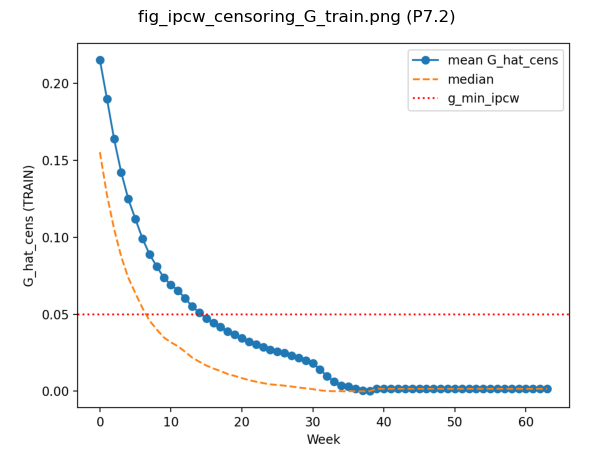

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_ipcw_censoring_G_train.csv | shape=(64, 5)
    columns (5 of 5): ['week', 'G_hat_mean', 'G_hat_median', 'G_hat_p10', 'G_hat_p90']


,week,G_hat_mean,G_hat_median,G_hat_p10,G_hat_p90
0,0,0.215104,0.155223,0.062922,0.426483
1,1,0.189774,0.127334,0.048456,0.406639
2,2,0.163814,0.105418,0.034620,0.365206
3,3,0.142176,0.087461,0.025278,0.325399
4,4,0.124841,0.073689,0.018502,0.293219


,feature,mean,std,min,max
0,week,31.500000,18.618987,0.000000e+00,63.000000
1,G_hat_mean,0.033815,0.048672,9.655357e-06,0.215104
2,G_hat_median,0.016698,0.031653,3.393405e-11,0.155223
3,G_hat_p10,0.004480,0.011056,1.380802e-15,0.062922
4,G_hat_p90,0.079703,0.109765,1.267880e-06,0.426483


  - in-memory object: dfG (DataFrame)
    shape=(39, 2)


,week,G_t
0,0,0.898957
1,1,0.894034
2,2,0.886963
3,3,0.879281
4,4,0.871820


## Figure 2: `fig_calibration_ipcw_reliability_test.png`
- **Export path:** `outputs_v2/figures/fig_calibration_ipcw_reliability_test.png`
- **Generating step:** `P7.3`
- **Subject:** IPCW reliability diagram on TEST
- **What it is:** Calibration curve by bins (mean prediction vs empirical event rate) for IPCW-calibrated hazard.
- **Used for:** Demonstrates probabilistic reliability before policy and fairness analyses.
- **Importance:** High for probability-quality claims.
- **Suggested paper location:** Calibration results (main text or short supplement).
- **Editorial recommendation:** Keep when calibrated probabilities are part of the core contribution.

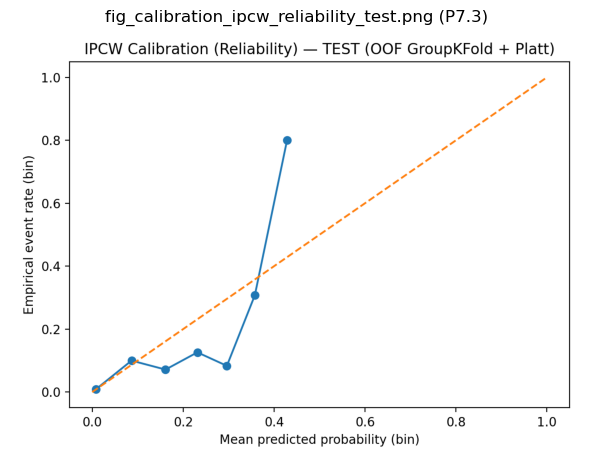

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_calibration_ipcw_bins_test.csv | shape=(15, 7)
    columns (7 of 7): ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap']


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap
0,0,230057,0.000000,0.066667,0.007989,0.008607,0.000618
1,1,1911,0.066667,0.133333,0.086572,0.099948,0.013375
2,2,280,0.133333,0.200000,0.161327,0.071429,0.089898
3,3,103,0.200000,0.266667,0.231359,0.126214,0.105146
4,4,48,0.266667,0.333333,0.296257,0.083333,0.212924


,feature,mean,std,min,max
0,bin,7.000000,4.472136,0.000000,14.000000
1,n,15494.466667,59358.949992,0.000000,230057.000000
2,p_min,0.466667,0.298142,0.000000,0.933333
3,p_max,0.533333,0.298142,0.066667,1.000000
4,mean_pred,0.224263,0.149718,0.007989,0.428566
5,empirical_rate,0.213889,0.274613,0.008607,0.800000
6,abs_gap,0.120496,0.131332,0.000618,0.371434


  - table: outputs_v2/tables/table_calibration_ipcw_metrics.csv | shape=(8, 2)
    columns (2 of 2): ['metric', 'value']


,metric,value
0,AUC_train,0.8354830684290305
1,AUC_test,0.8394664715157028
2,Brier_test,0.00920799703080096
3,ECE_test,0.0009308954558307907
4,n_bins,15.0


  - in-memory object: bins_df (DataFrame)
    shape=(30, 9)


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap,group_var,group
0,0,104100,0.000000,0.066667,0.007275,0.008463,0.001188,gender,F
1,1,501,0.066667,0.133333,0.088488,0.083832,0.004656,gender,F
2,2,128,0.133333,0.200000,0.162394,0.039062,0.123331,gender,F
3,3,67,0.200000,0.266667,0.234187,0.059701,0.174486,gender,F
4,4,50,0.266667,0.333333,0.297400,0.060000,0.237400,gender,F


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 3: `fig_ipcw_weights_distribution_train.png`
- **Export path:** `outputs_v2/figures/fig_ipcw_weights_distribution_train.png`
- **Generating step:** `P7.4`
- **Subject:** IPCW weight distribution on training set
- **What it is:** Histogram of IPCW weights after clipping/capping.
- **Used for:** Verifies numerical stability and guards against domination by a few rows.
- **Importance:** Medium-high as methodological quality control.
- **Suggested paper location:** Methodological supplement.
- **Editorial recommendation:** Prefer supplement; move to main text only if reviewers question weight stability.

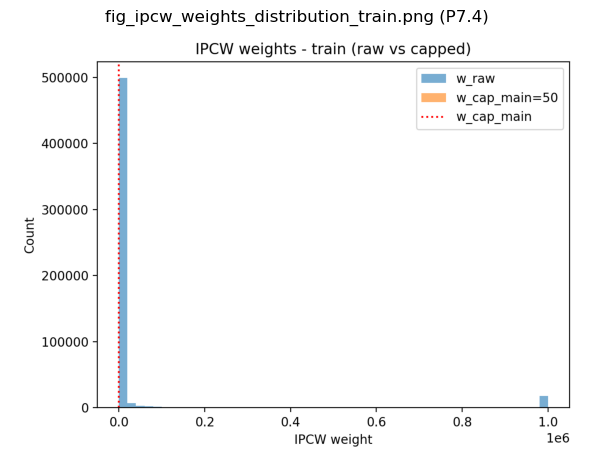

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_ipcw_weights_summary_train.csv | shape=(3, 12)
    columns (12 of 12): ['w_cap', 'eps_ipcw', 'n', 'min', 'median', 'p95', 'p99', 'max', 'frac_clipped', 'n_clipped', 'frac_G_lt_1e-3', 'frac_G_lt_1e-2']


,w_cap,eps_ipcw,n,min,median,p95,p99,max,frac_clipped,n_clipped,frac_G_lt_1e-3,frac_G_lt_1e-2
0,20.0,0.000001,542878,1.0,20.000000,20.0,20.0,20.0,0.656426,356359,0.18608,0.390937
1,50.0,0.000001,542878,1.0,47.436463,50.0,50.0,50.0,0.491713,266940,0.18608,0.390937
2,100.0,0.000001,542878,1.0,47.436463,100.0,100.0,100.0,0.390937,212231,0.18608,0.390937


,feature,mean,std,min,max
0,w_cap,56.666667,40.414519,20.000000,100.000000
1,eps_ipcw,0.000001,0.000000,0.000001,0.000001
2,n,542878.000000,0.000000,542878.000000,542878.000000
3,min,1.000000,0.000000,1.000000,1.000000
4,median,38.290975,15.840449,20.000000,47.436463
5,p95,56.666667,40.414519,20.000000,100.000000
6,p99,56.666667,40.414519,20.000000,100.000000
7,max,56.666667,40.414519,20.000000,100.000000
8,frac_clipped,0.513025,0.134021,0.390937,0.656426
9,n_clipped,278510.000000,72757.259232,212231.000000,356359.000000


  - table: outputs_v2/tables/table_model_comparison_ipcw_vs_noipcw.csv | shape=(4, 8)
    columns (8 of 8): ['model_label', 'w_cap', 'eps_ipcw', 'auc_train', 'auc_test', 'brier_test', 'ece_test', 'frac_clipped']


,model_label,w_cap,eps_ipcw,auc_train,auc_test,brier_test,ece_test,frac_clipped
0,baseline_no_ipcw,NaN,NaN,0.835849,0.839573,0.009323,0.001222,0.000000
1,ipcw_train_cap20,20.0,0.000001,0.836093,0.840916,0.009344,0.001662,0.656426
2,ipcw_train_cap50,50.0,0.000001,0.835015,0.840485,0.009381,0.001885,0.491713
3,ipcw_train_cap100,100.0,0.000001,0.833507,0.839377,0.009427,0.002128,0.390937


...

  - in-memory object: weights_df (DataFrame)
    shape=(3, 12)


,w_cap,eps_ipcw,n,min,median,p95,p99,max,frac_clipped,n_clipped,frac_G_lt_1e-3,frac_G_lt_1e-2
0,20.0,0.000001,542878,1.0,20.000000,20.0,20.0,20.0,0.656426,356359,0.18608,0.390937
1,50.0,0.000001,542878,1.0,47.436463,50.0,50.0,50.0,0.491713,266940,0.18608,0.390937
2,100.0,0.000001,542878,1.0,47.436463,100.0,100.0,100.0,0.390937,212231,0.18608,0.390937


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 4: `fig_calibration_reliability_test_ipcwtrain.png`
- **Export path:** `outputs_v2/figures/fig_calibration_reliability_test_ipcwtrain.png`
- **Generating step:** `P7.4`
- **Subject:** Reliability diagram for IPCW-trained hazard
- **What it is:** Calibration curve for the `ipcw_train` hazard variant on TEST.
- **Used for:** Compares probability quality between baseline and IPCW-trained variants.
- **Importance:** High when downstream model selection depends on this comparison.
- **Suggested paper location:** Robustness / model-variant comparison.
- **Editorial recommendation:** Keep if temporal-model variant selection is discussed explicitly.

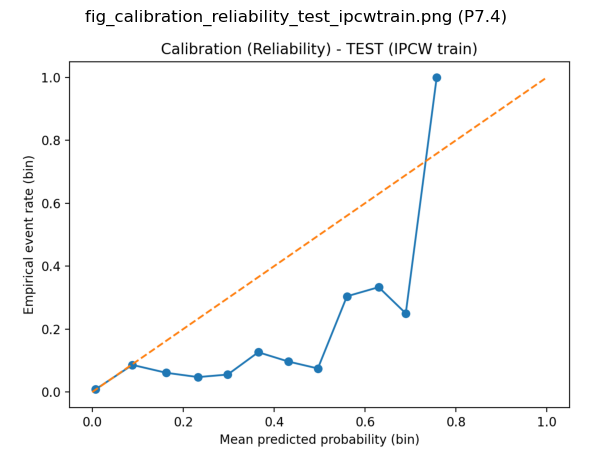

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_calibration_ipcwtrain_bins_test.csv | shape=(15, 7)
    columns (7 of 7): ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap']


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap
0,0,230311,0.000000,0.066667,0.007679,0.008858,0.001179
1,1,1263,0.066667,0.133333,0.088470,0.086302,0.002167
2,2,327,0.133333,0.200000,0.163167,0.061162,0.102004
3,3,168,0.200000,0.266667,0.232795,0.047619,0.185176
4,4,126,0.266667,0.333333,0.298039,0.055556,0.242484


,feature,mean,std,min,max
0,bin,7.000000,4.472136,0.000000,14.000000
1,n,15494.466667,59428.070460,0.000000,230311.000000
2,p_min,0.466667,0.298142,0.000000,0.933333
3,p_max,0.533333,0.298142,0.066667,1.000000
4,mean_pred,0.393483,0.242524,0.007679,0.757734
5,empirical_rate,0.203795,0.272278,0.008858,1.000000
6,abs_gap,0.230263,0.141377,0.001179,0.439716


  - table: outputs_v2/tables/table_calibration_ipcwtrain_metrics.csv | shape=(9, 2)
    columns (2 of 2): ['metric', 'value']


,metric,value
0,AUC_train,0.835015
1,AUC_test,0.840485
2,Brier_test,0.009381
3,ECE_test,0.001885
4,n_bins,15.000000


...

,model_label,w_cap,eps_ipcw,auc_train,auc_test,brier_test,ece_test,frac_clipped
0,baseline_no_ipcw,NaN,NaN,0.835849,0.839573,0.009323,0.001222,0.000000
1,ipcw_train_cap20,20.0,0.000001,0.836093,0.840916,0.009344,0.001662,0.656426
2,ipcw_train_cap50,50.0,0.000001,0.835015,0.840485,0.009381,0.001885,0.491713
3,ipcw_train_cap100,100.0,0.000001,0.833507,0.839377,0.009427,0.002128,0.390937


,feature,mean,std,min,max
0,w_cap,56.666667,40.414519,20.000000,100.000000
1,eps_ipcw,0.000001,0.000000,0.000001,0.000001
2,auc_train,0.835116,0.001168,0.833507,0.836093
3,auc_test,0.840088,0.000733,0.839377,0.840916
4,brier_test,0.009369,0.000046,0.009323,0.009427
5,ece_test,0.001724,0.000385,0.001222,0.002128
6,frac_clipped,0.384769,0.278878,0.000000,0.656426


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 5: `fig_non_temporal_rsf_calibration_teval.png`
- **Export path:** `outputs_v2/figures/fig_non_temporal_rsf_calibration_teval.png`
- **Generating step:** `P9.1`
- **Subject:** Non-temporal baseline calibration at T_eval
- **What it is:** Calibration curve for enrollment-level non-temporal RSF baseline at T_eval.
- **Used for:** Assesses probabilistic quality of the non-temporal comparator.
- **Importance:** High for temporal vs non-temporal benchmark credibility.
- **Suggested paper location:** Benchmark section (main result).
- **Editorial recommendation:** Keep in main text when benchmarking is central.

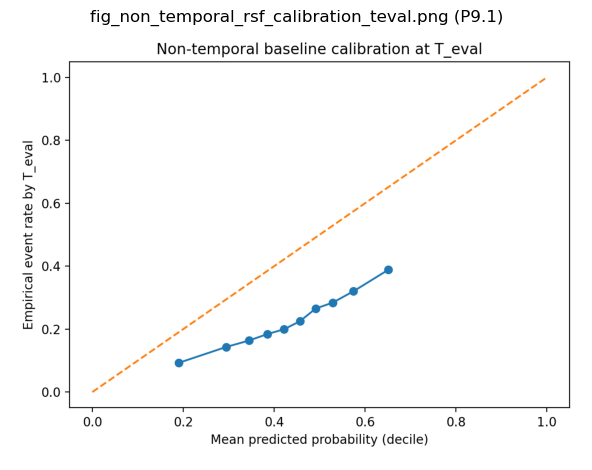

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_non_temporal_rsf_calibration_teval.csv | shape=(10, 5)
    columns (5 of 5): ['decile', 'n', 'mean_pred', 'empirical_rate', 'abs_gap']


,decile,n,mean_pred,empirical_rate,abs_gap
0,0,978,0.190525,0.093047,0.097478
1,1,978,0.294263,0.143149,0.151114
2,2,978,0.344404,0.163599,0.180805
3,3,977,0.385050,0.184237,0.200813
4,4,978,0.421521,0.199387,0.222134


,feature,mean,std,min,max
0,decile,4.500000,3.027650,0.000000,9.000000
1,n,977.800000,0.421637,977.000000,978.000000
2,mean_pred,0.433799,0.137036,0.190525,0.651163
3,empirical_rate,0.226631,0.088864,0.093047,0.388548
4,abs_gap,0.207168,0.051415,0.097478,0.262615


  - table: outputs_v2/tables/table_non_temporal_rsf_metrics.csv | shape=(12, 2)
    columns (2 of 2): ['metric', 'value']


,metric,value
0,model_name,rf_classifier_fallback
1,implementation,sklearn_fallback_no_sksurv (ModuleNotFoundError)
2,T_policy,18.0
3,T_eval_metrics,37.0
4,n_train_enrollments,22815.0


  - in-memory object: calib_df (DataFrame)
    shape=(1, 3)


,model,metric,value
0,Temporal hazard (selected),brier_row,0.110878


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 6: `fig_non_temporal_rsf_feature_importance_top15.png`
- **Export path:** `outputs_v2/figures/fig_non_temporal_rsf_feature_importance_top15.png`
- **Generating step:** `P9.1`
- **Subject:** Top features for non-temporal baseline
- **What it is:** Top-15 feature-importance plot for RSF (or fallback RF).
- **Used for:** Supports interpretability of static enrollment-level comparator.
- **Importance:** Medium for interpretation; low for causal claims.
- **Suggested paper location:** Interpretability supplement.
- **Editorial recommendation:** Prefer supplement unless feature-driver discussion is central.

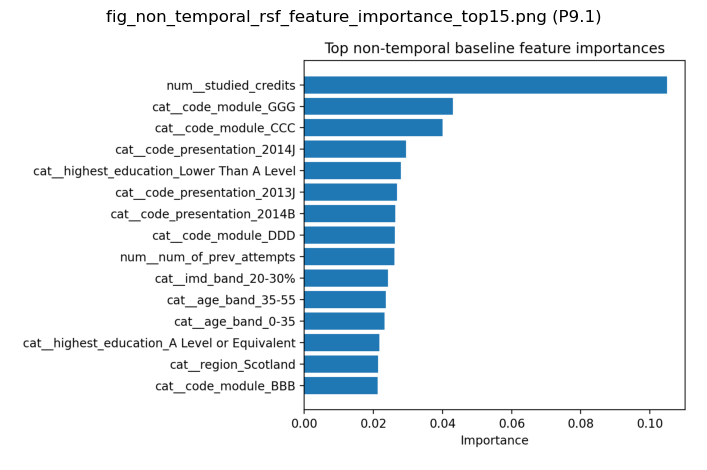

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_non_temporal_rsf_metrics.csv | shape=(12, 2)
    columns (2 of 2): ['metric', 'value']


,metric,value
0,model_name,rf_classifier_fallback
1,implementation,sklearn_fallback_no_sksurv (ModuleNotFoundError)
2,T_policy,18.0
3,T_eval_metrics,37.0
4,n_train_enrollments,22815.0


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 7: `fig_calibration_reliability_test.png`
- **Export path:** `outputs_v2/figures/fig_calibration_reliability_test.png`
- **Generating step:** `P11`
- **Subject:** Selected temporal hazard calibration
- **What it is:** Reliability diagram for the active temporal hazard (`hazard_hat`) on TEST.
- **Used for:** Validates probability quality for policy and fairness downstream analysis.
- **Importance:** Very high; central validation figure.
- **Suggested paper location:** Main model-validation results.
- **Editorial recommendation:** Keep in main text.

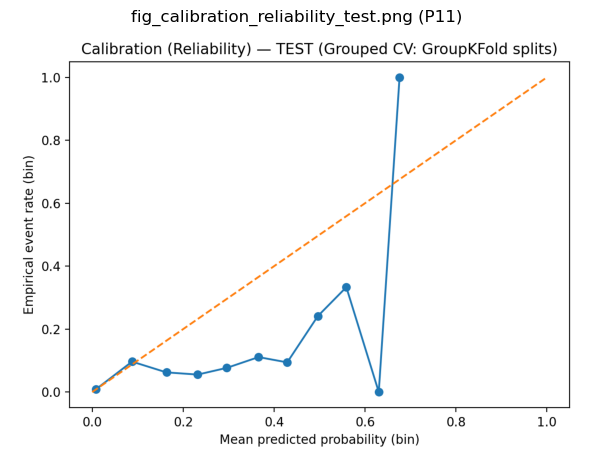

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_calibration_bins_test.csv | shape=(15, 7)
    columns (7 of 7): ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap']


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap
0,0,230157,0.000000,0.066667,0.008142,0.008724,0.000582
1,1,1499,0.066667,0.133333,0.087664,0.096731,0.009068
2,2,304,0.133333,0.200000,0.163386,0.062500,0.100886
3,3,180,0.200000,0.266667,0.232119,0.055556,0.176564
4,4,104,0.266667,0.333333,0.296277,0.076923,0.219354


,feature,mean,std,min,max
0,bin,7.000000,4.472136,0.000000,14.000000
1,n,15494.466667,59385.820094,0.000000,230157.000000
2,p_min,0.466667,0.298142,0.000000,0.933333
3,p_max,0.533333,0.298142,0.066667,1.000000
4,mean_pred,0.358569,0.222029,0.008142,0.676041
5,empirical_rate,0.189145,0.286257,0.000000,1.000000
6,abs_gap,0.230079,0.173895,0.000582,0.630336


  - table: outputs_v2/tables/table_calibration_metrics.csv | shape=(9, 2)
    columns (2 of 2): ['metric', 'value']


,metric,value
0,AUC_train,0.8358500884891436
1,AUC_test,0.8395774755908261
2,Brier_test,0.009323056385034438
3,ECE_test,0.001220699192687835
4,n_bins,15.0


  - in-memory object: bins_df (DataFrame)
    shape=(30, 9)


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap,group_var,group
0,0,104100,0.000000,0.066667,0.007275,0.008463,0.001188,gender,F
1,1,501,0.066667,0.133333,0.088488,0.083832,0.004656,gender,F
2,2,128,0.133333,0.200000,0.162394,0.039062,0.123331,gender,F
3,3,67,0.200000,0.266667,0.234187,0.059701,0.174486,gender,F
4,4,50,0.266667,0.333333,0.297400,0.060000,0.237400,gender,F


  - in-memory object: metrics_df (DataFrame)
    shape=(9, 2)


,metric,value
0,AUC_train,0.83585
1,AUC_test,0.839577
2,Brier_test,0.009323
3,ECE_test,0.001221
4,n_bins,15.0


## Figure 8: `fig_policy_covariate_deltas_by_week.png`
- **Export path:** `outputs_v2/figures/fig_policy_covariate_deltas_by_week.png`
- **Generating step:** `P13`
- **Subject:** Policy-induced covariate deltas by week
- **What it is:** Weekly deltas (counterfactual minus baseline) for key covariates such as clicks, recency, and streak.
- **Used for:** Explains intervention mechanism before survival-impact results.
- **Importance:** Medium-high for mechanistic interpretability.
- **Suggested paper location:** Policy mechanism section.
- **Editorial recommendation:** Keep if mechanism is part of the narrative; otherwise supplement.

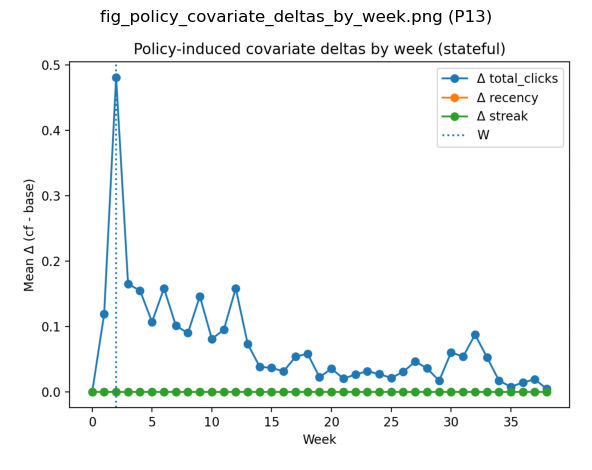

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_policy_covariate_deltas_by_week.csv | shape=(39, 7)
    columns (7 of 7): ['week', 'policy_active_rate', 'delta_total_clicks', 'delta_recency', 'delta_streak', 'n_rows', 'trigger_rate']


,week,policy_active_rate,delta_total_clicks,delta_recency,delta_streak,n_rows,trigger_rate
0,0,0.165883,0.000000,0.0,0.0,9778,0.857742
1,1,0.205872,0.119247,0.0,0.0,8583,0.872888
2,2,0.189219,0.481188,0.0,0.0,8218,0.885982
3,3,0.130413,0.165244,0.0,0.0,8082,0.891858
4,4,0.116641,0.155180,0.0,0.0,7896,0.895897


,feature,mean,std,min,max
0,week,19.000000,11.401754,0.000000,38.000000
1,policy_active_rate,0.055396,0.053778,0.011955,0.205872
2,delta_total_clicks,0.071592,0.082455,0.000000,0.481188
3,delta_recency,0.000000,0.000000,0.000000,0.000000
4,delta_streak,0.000000,0.000000,0.000000,0.000000
5,n_rows,5959.410256,2036.473328,425.000000,9778.000000
6,trigger_rate,0.886313,0.023892,0.781176,0.903849


  - table: outputs_v2/tables/table_policy_activation_summary.csv | shape=(1, 13)
    columns (12 of 13): ['effect_params_source', 'W', 'alpha_week0', 'alpha_week1', 'decay_type', 'window_exclusive_upper', 'delta_shock_ablation', 'n_enrollments_total', 'n_enrollments_triggered', 'trigger_rate_enrollment', 'n_rows_total', 'n_rows_active']


,effect_params_source,W,alpha_week0,alpha_week1,decay_type,window_exclusive_upper,delta_shock_ablation,n_enrollments_total,n_enrollments_triggered,trigger_rate_enrollment,n_rows_total,n_rows_active,active_rate_rows
0,policy_spec.effect,2,0.35,0.1,kb2023_step_2w,1,0.2,9778,8387,0.857742,232417,15190,0.065357


...

  - in-memory object: agg (DataFrame)
    shape=(39, 7)


,week,policy_active_rate,delta_total_clicks,delta_recency,delta_streak,n_rows,trigger_rate
0,0,0.165883,0.000000,0.0,0.0,9778,0.857742
1,1,0.205872,0.119247,0.0,0.0,8583,0.872888
2,2,0.189219,0.481188,0.0,0.0,8218,0.885982
3,3,0.130413,0.165244,0.0,0.0,8082,0.891858
4,4,0.116641,0.155180,0.0,0.0,7896,0.895897


  - in-memory object: df_act (DataFrame)
    shape=(1, 13)


,effect_params_source,W,alpha_week0,alpha_week1,decay_type,window_exclusive_upper,delta_shock_ablation,n_enrollments_total,n_enrollments_triggered,trigger_rate_enrollment,n_rows_total,n_rows_active,active_rate_rows
0,policy_spec.effect,2,0.35,0.1,kb2023_step_2w,1,0.2,9778,8387,0.857742,232417,15190,0.065357


## Figure 9: `fig_policy_deltaS_by_week_shock_vs_mech.png`
- **Export path:** `outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png`
- **Generating step:** `P14.3`
- **Subject:** Weekly survival gain: shock-only vs mechanism-aware
- **What it is:** Weekly delta-survival comparison between shock-only and mechanism-aware policy implementations.
- **Used for:** Quantifies magnitude and temporal profile of policy impact.
- **Importance:** Very high for policy-effect claims.
- **Suggested paper location:** Main policy results.
- **Editorial recommendation:** Keep in main text.

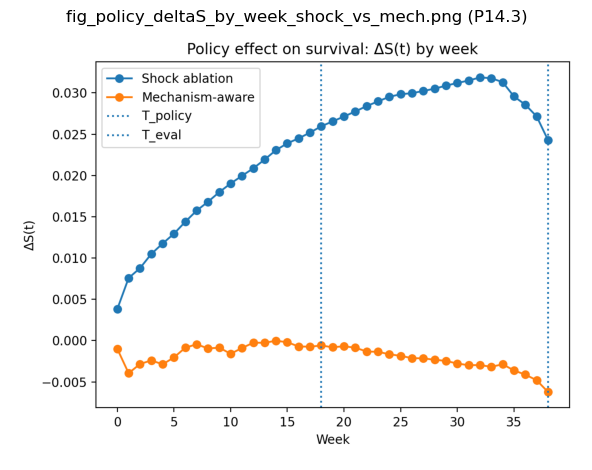

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_policy_deltaS_by_week_all.csv | shape=(39, 6)
    columns (6 of 6): ['week', 'S0_bar', 'S_shock_bar', 'S_mech_bar', 'deltaS_shock', 'deltaS_mech']


,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech
0,0,0.980959,0.984767,0.979963,0.003808,-0.000996
1,1,0.961694,0.969271,0.957739,0.007577,-0.003955
2,2,0.955457,0.964222,0.952613,0.008764,-0.002844
3,3,0.946368,0.956858,0.943968,0.010490,-0.002400
4,4,0.939606,0.951363,0.936730,0.011757,-0.002876


,feature,mean,std,min,max
0,week,19.000000,11.401754,0.000000,38.000000
1,S0_bar,0.870106,0.046875,0.818292,0.980959
2,S_shock_bar,0.893480,0.039095,0.850169,0.984767
3,S_mech_bar,0.868189,0.047104,0.815318,0.979963
4,deltaS_shock,0.023374,0.007793,0.003808,0.031877
5,deltaS_mech,-0.001917,0.001409,-0.006237,-0.000027


  - table: outputs_v2/tables/table_policy_deltaS_by_week_shock.csv | shape=(39, 2)
    columns (2 of 2): ['week', 'deltaS_shock']


,week,deltaS_shock
0,0,0.003808
1,1,0.007577
2,2,0.008764
3,3,0.010490
4,4,0.011757


...

  - in-memory object: weekly (DataFrame)
    shape=(39, 6)


,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech
0,0,0.980959,0.984767,0.979963,0.003808,-0.000996
1,1,0.961694,0.969271,0.957739,0.007577,-0.003955
2,2,0.955457,0.964222,0.952613,0.008764,-0.002844
3,3,0.946368,0.956858,0.943968,0.010490,-0.002400
4,4,0.939606,0.951363,0.936730,0.011757,-0.002876


  - in-memory object: horizons (DataFrame)
    shape=(2, 7)


,horizon_label,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech
0,T_policy,18,0.855433,0.881393,0.854830,0.025960,-0.000604
1,T_eval,38,0.867705,0.891978,0.861468,0.024273,-0.006237


## Figure 10: `fig_policy_survival_by_week_baseline_shock_mech.png`
- **Export path:** `outputs_v2/figures/fig_policy_survival_by_week_baseline_shock_mech.png`
- **Generating step:** `P14.3`
- **Subject:** Weekly survival curves under policy scenarios
- **What it is:** Average survival curves by week for baseline, shock-only, and mechanism-aware scenarios.
- **Used for:** Visualizes cumulative policy effect over time.
- **Importance:** High for intuitive communication of intervention dynamics.
- **Suggested paper location:** Main policy results (with deltaS figure).
- **Editorial recommendation:** Keep in main text.

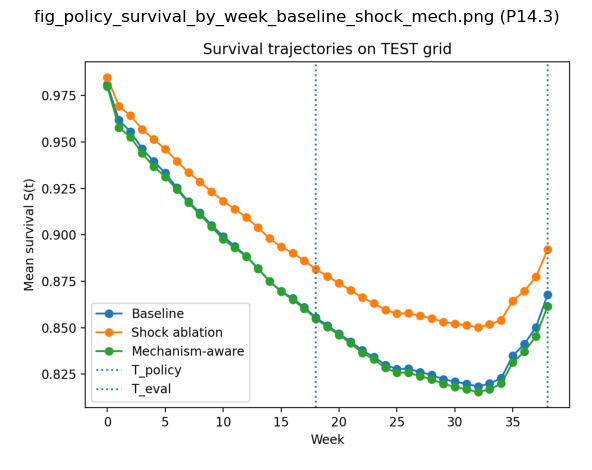

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_policy_deltaS_by_week_all.csv | shape=(39, 6)
    columns (6 of 6): ['week', 'S0_bar', 'S_shock_bar', 'S_mech_bar', 'deltaS_shock', 'deltaS_mech']


,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech
0,0,0.980959,0.984767,0.979963,0.003808,-0.000996
1,1,0.961694,0.969271,0.957739,0.007577,-0.003955
2,2,0.955457,0.964222,0.952613,0.008764,-0.002844
3,3,0.946368,0.956858,0.943968,0.010490,-0.002400
4,4,0.939606,0.951363,0.936730,0.011757,-0.002876


,feature,mean,std,min,max
0,week,19.000000,11.401754,0.000000,38.000000
1,S0_bar,0.870106,0.046875,0.818292,0.980959
2,S_shock_bar,0.893480,0.039095,0.850169,0.984767
3,S_mech_bar,0.868189,0.047104,0.815318,0.979963
4,deltaS_shock,0.023374,0.007793,0.003808,0.031877
5,deltaS_mech,-0.001917,0.001409,-0.006237,-0.000027


  - table: outputs_v2/tables/table_policy_deltaS_at_horizons.csv | shape=(2, 10)
    columns (10 of 10): ['horizon_label', 'week', 'S0_bar', 'S_shock_bar', 'S_mech_bar', 'deltaS_shock', 'deltaS_mech', 'n_events_at_week', 'n_events_cum_leq_week', 'n_at_risk_week']


,horizon_label,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech,n_events_at_week,n_events_cum_leq_week,n_at_risk_week
0,T_policy,18,0.855433,0.881393,0.854830,0.025960,-0.000604,167,5452,21255
1,T_eval,38,0.867705,0.891978,0.861468,0.024273,-0.006237,0,7386,1575


...

  - in-memory object: weekly (DataFrame)
    shape=(39, 6)


,week,S0_bar,S_shock_bar,S_mech_bar,deltaS_shock,deltaS_mech
0,0,0.980959,0.984767,0.979963,0.003808,-0.000996
1,1,0.961694,0.969271,0.957739,0.007577,-0.003955
2,2,0.955457,0.964222,0.952613,0.008764,-0.002844
3,3,0.946368,0.956858,0.943968,0.010490,-0.002400
4,4,0.939606,0.951363,0.936730,0.011757,-0.002876


  - in-memory object: pp_traj (DataFrame)
    shape=(232417, 11)


,id_student,code_module,code_presentation,week,hazard_0,hazard_1_mech,hazard_1_shock,t_final_week,S0_hat,S_mech_hat,S_shock_hat
0,8462,DDD,2013J,0,0.010328,0.013005,0.008262,17,0.989672,0.986995,0.991738
1,8462,DDD,2013J,1,0.011250,0.015645,0.009000,17,0.978538,0.971554,0.982812
2,8462,DDD,2013J,2,0.012585,0.013491,0.010068,17,0.966223,0.958447,0.972917
3,8462,DDD,2013J,3,0.012290,0.014247,0.009832,17,0.954349,0.944791,0.963352
4,8462,DDD,2013J,4,0.002419,0.003183,0.001935,17,0.952040,0.941784,0.961487


## Figure 11: `fig_censoring_survival_G_test.png`
- **Export path:** `outputs_v2/figures/fig_censoring_survival_G_test.png`
- **Generating step:** `P14.2`
- **Subject:** Test censoring survival with horizon markers
- **What it is:** G(t) curve on TEST with vertical markers for policy and evaluation horizons.
- **Used for:** Justifies horizon selection and IPCW stability for evaluation.
- **Importance:** High for validity of survival metrics.
- **Suggested paper location:** Methods/evaluation support.
- **Editorial recommendation:** Keep in technical supplement; promote to main text if horizon validity is challenged.

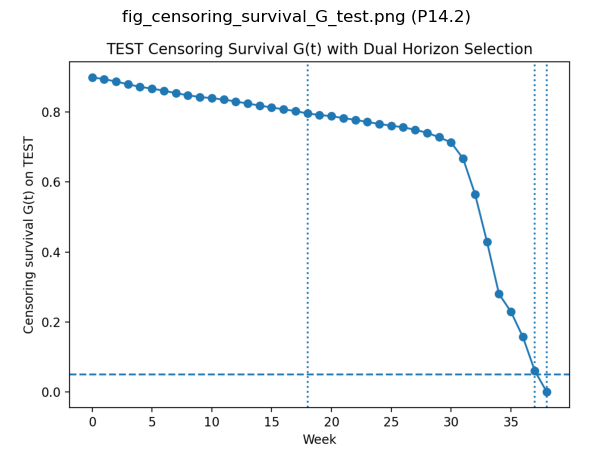

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_censoring_survival_G_test_by_week.csv | shape=(39, 2)
    columns (2 of 2): ['week', 'G_t']


,week,G_t
0,0,0.898957
1,1,0.894034
2,2,0.886963
3,3,0.879281
4,4,0.871820


,feature,mean,std,min,max
0,week,19.000000,11.401754,0.000000e+00,38.000000
1,G_t,0.707299,0.238108,1.000000e-12,0.898957


  - table: outputs_v2/tables/table_policy_horizons_dual.csv | shape=(3, 5)
    columns (5 of 5): ['horizon_label', 'week', 'G_t', 'n_at_risk_week', 'role']


,horizon_label,week,G_t,n_at_risk_week,role
0,T_policy,18,7.957980e-01,21255.0,policy_trigger_and_contrast
1,T_eval_policy,38,1.000000e-12,1575.0,trajectory_reporting_and_deltaS_tables
2,T_eval_metrics,37,6.007189e-02,3782.0,stable_IPCW_metrics_only


,feature,mean,std,min,max
0,week,31.000000,11.269428,1.800000e+01,38.000000
1,G_t,0.285290,0.443132,1.000000e-12,0.795798
2,n_at_risk_week,8870.666667,10781.766847,1.575000e+03,21255.000000


  - in-memory object: dfG (DataFrame)
    shape=(39, 2)


,week,G_t
0,0,0.898957
1,1,0.894034
2,2,0.886963
3,3,0.879281
4,4,0.871820


## Figure 12: `fig_benchmark_dual_panel_auc.png`
- **Export path:** `outputs_v2/figures/fig_benchmark_dual_panel_auc.png`
- **Generating step:** `P17.6`
- **Subject:** Unified benchmark: temporal vs non-temporal
- **What it is:** Dual-panel AUC figure with row-level and horizon-level comparisons.
- **Used for:** Summarizes comparative performance in a single paper-ready visual.
- **Importance:** Very high for benchmark conclusions.
- **Suggested paper location:** Main benchmark figure.
- **Editorial recommendation:** Keep in main text.

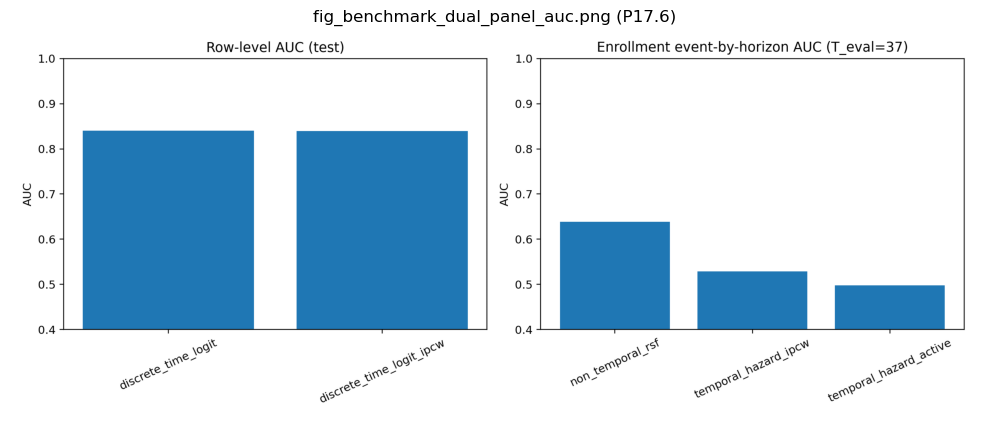

[Data summary used to compose the figure]
  - table: outputs_v2/tables/table_benchmark_horizon_auc.csv | shape=(3, 6)
    columns (6 of 6): ['model', 'family', 'AUC_event_by_T_policy', 'AUC_event_by_T_eval', 'n_test_enrollments', 'source']


,model,family,AUC_event_by_T_policy,AUC_event_by_T_eval,n_test_enrollments,source
0,temporal_hazard_active,discrete_time,0.480270,0.497923,9778,pp_test.hazard_hat
1,temporal_hazard_ipcw,discrete_time_ipcw,0.522024,0.529068,9778,pp_test.hazard_hat_ipcw
2,non_temporal_rsf,non_temporal_survival,0.645659,0.638836,9778,pred_df(in_memory)


,feature,mean,std,min,max
0,AUC_event_by_T_policy,0.549318,0.086006,0.480270,0.645659
1,AUC_event_by_T_eval,0.555276,0.074022,0.497923,0.638836
2,n_test_enrollments,9778.000000,0.000000,9778.000000,9778.000000


  - table: outputs_v2/tables/table_benchmark_row_level_auc.csv | shape=(2, 4)
    columns (4 of 4): ['model', 'family', 'AUC_row_test', 'source']


,model,family,AUC_row_test,source
0,discrete_time_logit,row_level_temporal,0.840485,pp_test.hazard_hat
1,discrete_time_logit_ipcw,row_level_temporal,0.839466,pp_test.hazard_hat_ipcw


...

  - in-memory object: row_df (DataFrame)
    shape=(2, 4)


,model,family,AUC_row_test,source
0,discrete_time_logit,row_level_temporal,0.840485,pp_test.hazard_hat
1,discrete_time_logit_ipcw,row_level_temporal,0.839466,pp_test.hazard_hat_ipcw


  - in-memory object: unified_df (DataFrame)
    shape=(5, 6)


,model,family,AUC_event_by_T_policy,AUC_event_by_T_eval,n_test_enrollments,source
0,temporal_hazard_active,discrete_time,0.480270,0.497923,9778.0,pp_test.hazard_hat
1,temporal_hazard_ipcw,discrete_time_ipcw,0.522024,0.529068,9778.0,pp_test.hazard_hat_ipcw
2,non_temporal_rsf,non_temporal_survival,0.645659,0.638836,9778.0,pred_df(in_memory)
3,discrete_time_logit,row_level_temporal,NaN,NaN,NaN,pp_test.hazard_hat
4,discrete_time_logit_ipcw,row_level_temporal,NaN,NaN,NaN,pp_test.hazard_hat_ipcw


## Figure 13: `fig_rq3_gap_Tpolicy.png`
- **Export path:** `outputs_v2/figures/fig_rq3_gap_Tpolicy.png`
- **Generating step:** `P28`
- **Subject:** Fairness delta-gap at T_policy
- **What it is:** Point estimate and bootstrap confidence interval for fairness delta-gap at policy horizon.
- **Used for:** Assesses disparity at policy-trigger horizon.
- **Importance:** Very high for fairness conclusions.
- **Suggested paper location:** Main fairness results.
- **Editorial recommendation:** Keep in main text.

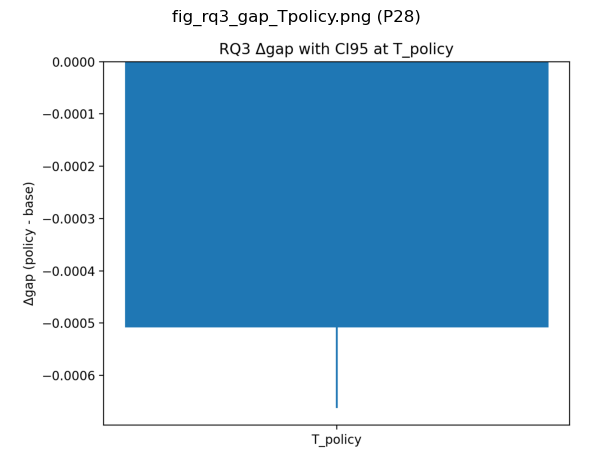

[Data summary used to compose the figure]
  - table: outputs_v2/tables/rq3_policy_gaps_unified.csv | shape=(1, 17)
    columns (12 of 17): ['group_var', 'group0', 'group1', 'T_policy', 'T_eval', 'r_star', 'W', 'alpha_week0', 'alpha_week1', 'decay_type', 'treated_enrollments', 'delta_gap_Tpolicy']


,group_var,group0,group1,T_policy,T_eval,r_star,W,alpha_week0,alpha_week1,decay_type,treated_enrollments,delta_gap_Tpolicy,delta_gap_Tpolicy_ci95_lo,delta_gap_Tpolicy_ci95_hi,delta_gap_Teval,delta_gap_Teval_ci95_lo,delta_gap_Teval_ci95_hi
0,gender,M,F,18,37,1,2,0.35,0.1,kb2023_step_2w,8387,-0.000508,-0.000662,-0.000329,-0.000567,-0.000715,-0.000407


,feature,mean,std,min,max
0,T_policy,18.000000,NaN,18.000000,18.000000
1,T_eval,37.000000,NaN,37.000000,37.000000
2,r_star,1.000000,NaN,1.000000,1.000000
3,W,2.000000,NaN,2.000000,2.000000
4,alpha_week0,0.350000,NaN,0.350000,0.350000
5,alpha_week1,0.100000,NaN,0.100000,0.100000
6,treated_enrollments,8387.000000,NaN,8387.000000,8387.000000
7,delta_gap_Tpolicy,-0.000508,NaN,-0.000508,-0.000508
8,delta_gap_Tpolicy_ci95_lo,-0.000662,NaN,-0.000662,-0.000662
9,delta_gap_Tpolicy_ci95_hi,-0.000329,NaN,-0.000329,-0.000329


  - table: outputs_v2/tables/rq3_policy_bootstrap_wide.csv | shape=(500, 2)
    columns (2 of 2): ['delta_gap_Tpolicy', 'delta_gap_Teval']


,delta_gap_Tpolicy,delta_gap_Teval
0,-0.000482,-0.000562
1,-0.000456,-0.000458
2,-0.000495,-0.000580
3,-0.000366,-0.000597
4,-0.000529,-0.000608


,feature,mean,std,min,max
0,delta_gap_Tpolicy,-0.000505,0.000087,-0.000762,-0.000260
1,delta_gap_Teval,-0.000566,0.000078,-0.000780,-0.000345


  - in-memory object: gap (dict)
    size=15




## Figure 14: `fig_rq3_gap_Teval.png`
- **Export path:** `outputs_v2/figures/fig_rq3_gap_Teval.png`
- **Generating step:** `P28`
- **Subject:** Fairness delta-gap at T_eval
- **What it is:** Point estimate and bootstrap confidence interval for fairness delta-gap at evaluation horizon.
- **Used for:** Assesses disparity at final evaluation horizon.
- **Importance:** Very high for fairness conclusions.
- **Suggested paper location:** Main fairness results.
- **Editorial recommendation:** Keep in main text.

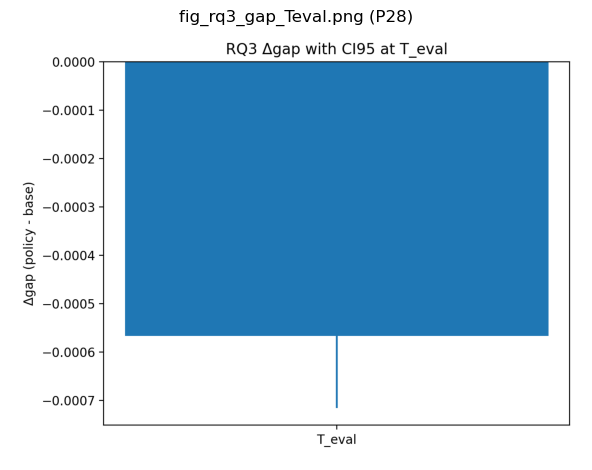

[Data summary used to compose the figure]
  - table: outputs_v2/tables/rq3_policy_gaps_unified.csv | shape=(1, 17)
    columns (12 of 17): ['group_var', 'group0', 'group1', 'T_policy', 'T_eval', 'r_star', 'W', 'alpha_week0', 'alpha_week1', 'decay_type', 'treated_enrollments', 'delta_gap_Tpolicy']


,group_var,group0,group1,T_policy,T_eval,r_star,W,alpha_week0,alpha_week1,decay_type,treated_enrollments,delta_gap_Tpolicy,delta_gap_Tpolicy_ci95_lo,delta_gap_Tpolicy_ci95_hi,delta_gap_Teval,delta_gap_Teval_ci95_lo,delta_gap_Teval_ci95_hi
0,gender,M,F,18,37,1,2,0.35,0.1,kb2023_step_2w,8387,-0.000508,-0.000662,-0.000329,-0.000567,-0.000715,-0.000407


,feature,mean,std,min,max
0,T_policy,18.000000,NaN,18.000000,18.000000
1,T_eval,37.000000,NaN,37.000000,37.000000
2,r_star,1.000000,NaN,1.000000,1.000000
3,W,2.000000,NaN,2.000000,2.000000
4,alpha_week0,0.350000,NaN,0.350000,0.350000
5,alpha_week1,0.100000,NaN,0.100000,0.100000
6,treated_enrollments,8387.000000,NaN,8387.000000,8387.000000
7,delta_gap_Tpolicy,-0.000508,NaN,-0.000508,-0.000508
8,delta_gap_Tpolicy_ci95_lo,-0.000662,NaN,-0.000662,-0.000662
9,delta_gap_Tpolicy_ci95_hi,-0.000329,NaN,-0.000329,-0.000329


  - table: outputs_v2/tables/rq3_policy_bootstrap_wide.csv | shape=(500, 2)
    columns (2 of 2): ['delta_gap_Tpolicy', 'delta_gap_Teval']


,delta_gap_Tpolicy,delta_gap_Teval
0,-0.000482,-0.000562
1,-0.000456,-0.000458
2,-0.000495,-0.000580
3,-0.000366,-0.000597
4,-0.000529,-0.000608


,feature,mean,std,min,max
0,delta_gap_Tpolicy,-0.000505,0.000087,-0.000762,-0.000260
1,delta_gap_Teval,-0.000566,0.000078,-0.000780,-0.000345


  - in-memory object: gap (dict)
    size=15




## Figure 15: `fig_rq3_bootstrap_hist_deltagap_Tpolicy.png`
- **Export path:** `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Tpolicy.png`
- **Generating step:** `P28`
- **Subject:** Bootstrap distribution at T_policy
- **What it is:** Histogram of bootstrap samples for fairness delta-gap at T_policy.
- **Used for:** Shows uncertainty distribution and robustness of fairness inference.
- **Importance:** Medium-high as inferential support.
- **Suggested paper location:** Fairness statistical supplement.
- **Editorial recommendation:** Prefer supplement; move to main text only if uncertainty discussion is central.

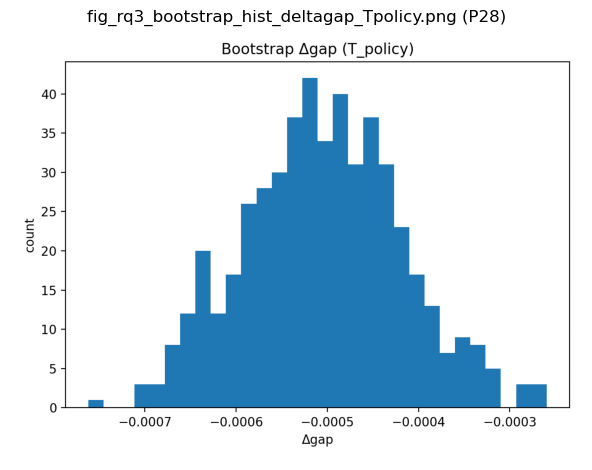

[Data summary used to compose the figure]
  - table: outputs_v2/tables/rq3_policy_bootstrap_long.csv | shape=(1000, 2)
    columns (2 of 2): ['horizon', 'delta_gap']


,horizon,delta_gap
0,T_policy,-0.000482
1,T_policy,-0.000456
2,T_policy,-0.000495
3,T_policy,-0.000366
4,T_policy,-0.000529


,feature,mean,std,min,max
0,delta_gap,-0.000535,0.000088,-0.00078,-0.00026


  - table: outputs_v2/tables/rq3_policy_bootstrap_wide.csv | shape=(500, 2)
    columns (2 of 2): ['delta_gap_Tpolicy', 'delta_gap_Teval']


,delta_gap_Tpolicy,delta_gap_Teval
0,-0.000482,-0.000562
1,-0.000456,-0.000458
2,-0.000495,-0.000580
3,-0.000366,-0.000597
4,-0.000529,-0.000608


,feature,mean,std,min,max
0,delta_gap_Tpolicy,-0.000505,0.000087,-0.000762,-0.000260
1,delta_gap_Teval,-0.000566,0.000078,-0.000780,-0.000345


## Figure 16: `fig_rq3_bootstrap_hist_deltagap_Teval.png`
- **Export path:** `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Teval.png`
- **Generating step:** `P28`
- **Subject:** Bootstrap distribution at T_eval
- **What it is:** Histogram of bootstrap samples for fairness delta-gap at T_eval.
- **Used for:** Shows uncertainty distribution and robustness at evaluation horizon.
- **Importance:** Medium-high as inferential support.
- **Suggested paper location:** Fairness statistical supplement.
- **Editorial recommendation:** Prefer supplement; move to main text only if uncertainty discussion is central.

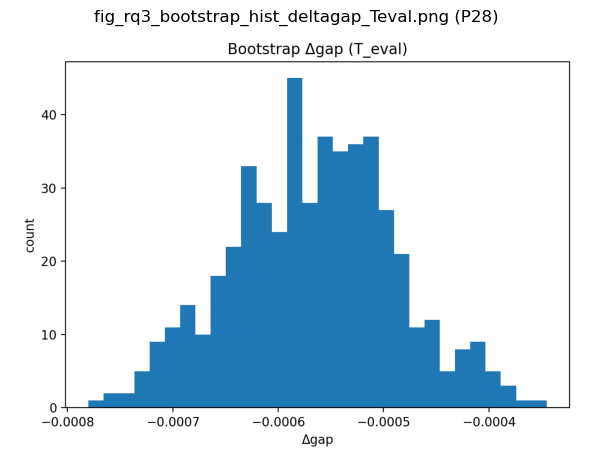

[Data summary used to compose the figure]
  - table: outputs_v2/tables/rq3_policy_bootstrap_long.csv | shape=(1000, 2)
    columns (2 of 2): ['horizon', 'delta_gap']


,horizon,delta_gap
0,T_policy,-0.000482
1,T_policy,-0.000456
2,T_policy,-0.000495
3,T_policy,-0.000366
4,T_policy,-0.000529


,feature,mean,std,min,max
0,delta_gap,-0.000535,0.000088,-0.00078,-0.00026


  - table: outputs_v2/tables/rq3_policy_bootstrap_wide.csv | shape=(500, 2)
    columns (2 of 2): ['delta_gap_Tpolicy', 'delta_gap_Teval']


,delta_gap_Tpolicy,delta_gap_Teval
0,-0.000482,-0.000562
1,-0.000456,-0.000458
2,-0.000495,-0.000580
3,-0.000366,-0.000597
4,-0.000529,-0.000608


,feature,mean,std,min,max
0,delta_gap_Tpolicy,-0.000505,0.000087,-0.000762,-0.000260
1,delta_gap_Teval,-0.000566,0.000078,-0.000780,-0.000345


## Figure 17: `fig_calibration_by_group.png`
- **Export path:** `outputs_v2/figures/fig_calibration_by_group.png`
- **Generating step:** `P28.1`
- **Subject:** Calibration by subgroup
- **What it is:** Calibration curves stratified by group for fairness diagnostics.
- **Used for:** Checks whether probability error differs systematically across groups.
- **Importance:** High for fairness completeness beyond AUC/gap metrics.
- **Suggested paper location:** Fairness results (main or supplement depending on space).
- **Editorial recommendation:** Keep at least in supplement; move to main text when subgroup differences are material.

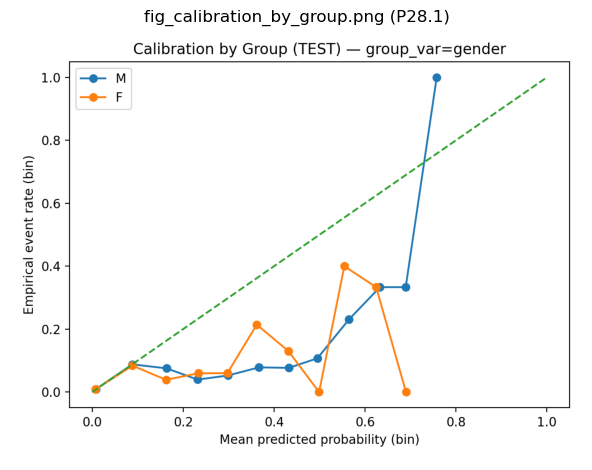

[Data summary used to compose the figure]
  - table: outputs_v2/tables/rq3_perf_by_group.csv | shape=(2, 8)
    columns (8 of 8): ['group_var', 'group', 'n_rows', 'pos_rate', 'AUC_row', 'Brier_row', 'ECE', 'n_bins']


,group_var,group,n_rows,pos_rate,AUC_row,Brier_row,ECE,n_bins
0,gender,M,127493,0.009938,0.840993,0.009798,0.001976,15
1,gender,F,104924,0.009045,0.839165,0.008875,0.001775,15


,feature,mean,std,min,max
0,n_rows,116208.500000,15958.692945,104924.000000,127493.000000
1,pos_rate,0.009491,0.000632,0.009045,0.009938
2,AUC_row,0.840079,0.001293,0.839165,0.840993
3,Brier_row,0.009336,0.000653,0.008875,0.009798
4,ECE,0.001875,0.000142,0.001775,0.001976
5,n_bins,15.000000,0.000000,15.000000,15.000000


  - table: outputs_v2/tables/rq3_calibration_bins_by_group.csv | shape=(30, 9)
    columns (9 of 9): ['bin', 'n', 'p_min', 'p_max', 'mean_pred', 'empirical_rate', 'abs_gap', 'group_var', 'group']


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap,group_var,group
0,0,104100,0.000000,0.066667,0.007275,0.008463,0.001188,gender,F
1,1,501,0.066667,0.133333,0.088488,0.083832,0.004656,gender,F
2,2,128,0.133333,0.200000,0.162394,0.039062,0.123331,gender,F
3,3,67,0.200000,0.266667,0.234187,0.059701,0.174486,gender,F
4,4,50,0.266667,0.333333,0.297400,0.060000,0.237400,gender,F


...

  - in-memory object: perf (DataFrame)
    shape=(2, 8)


,group_var,group,n_rows,pos_rate,AUC_row,Brier_row,ECE,n_bins
0,gender,M,127493,0.009938,0.840993,0.009798,0.001976,15
1,gender,F,104924,0.009045,0.839165,0.008875,0.001775,15


  - in-memory object: bins_df (DataFrame)
    shape=(30, 9)


,bin,n,p_min,p_max,mean_pred,empirical_rate,abs_gap,group_var,group
0,0,104100,0.000000,0.066667,0.007275,0.008463,0.001188,gender,F
1,1,501,0.066667,0.133333,0.088488,0.083832,0.004656,gender,F
2,2,128,0.133333,0.200000,0.162394,0.039062,0.123331,gender,F
3,3,67,0.200000,0.266667,0.234187,0.059701,0.174486,gender,F
4,4,50,0.266667,0.333333,0.297400,0.060000,0.237400,gender,F




=== Figure-by-figure analytical review DONE ===


In [289]:
# Figure-by-figure analytical pack: purpose, importance, article placement, and data summary

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Markdown

OUT_ROOT = Path("outputs_v2")

FIGURE_ANALYSIS = [
    {
        "file": "figures/fig_ipcw_censoring_G_train.png",
        "step": "P7.2",
        "subject": "Training censoring survival curve G(t)",
        "what": "Censoring-survival curve estimated on training data for IPCW diagnostics.",
        "used_for": "Checks whether IPCW weights are numerically stable and whether G(t) collapses too early.",
        "importance": "High for validating IPCW assumptions and usable horizons.",
        "paper_slot": "Methods / censoring diagnostics (supporting evidence).",
        "recommendation": "Keep if IPCW methodology is discussed; otherwise move to supplement.",
        "tables": ["tables/table_ipcw_censoring_G_train.csv"],
        "objects": ["dfG", "G_train_by_week"],
    },
    {
        "file": "figures/fig_calibration_ipcw_reliability_test.png",
        "step": "P7.3",
        "subject": "IPCW reliability diagram on TEST",
        "what": "Calibration curve by bins (mean prediction vs empirical event rate) for IPCW-calibrated hazard.",
        "used_for": "Demonstrates probabilistic reliability before policy and fairness analyses.",
        "importance": "High for probability-quality claims.",
        "paper_slot": "Calibration results (main text or short supplement).",
        "recommendation": "Keep when calibrated probabilities are part of the core contribution.",
        "tables": ["tables/table_calibration_ipcw_bins_test.csv", "tables/table_calibration_ipcw_metrics.csv"],
        "objects": ["bins_df", "metrics_df"],
    },
    {
        "file": "figures/fig_ipcw_weights_distribution_train.png",
        "step": "P7.4",
        "subject": "IPCW weight distribution on training set",
        "what": "Histogram of IPCW weights after clipping/capping.",
        "used_for": "Verifies numerical stability and guards against domination by a few rows.",
        "importance": "Medium-high as methodological quality control.",
        "paper_slot": "Methodological supplement.",
        "recommendation": "Prefer supplement; move to main text only if reviewers question weight stability.",
        "tables": ["tables/table_ipcw_weights_summary_train.csv", "tables/table_model_comparison_ipcw_vs_noipcw.csv"],
        "objects": ["weights_df", "metrics_df"],
    },
    {
        "file": "figures/fig_calibration_reliability_test_ipcwtrain.png",
        "step": "P7.4",
        "subject": "Reliability diagram for IPCW-trained hazard",
        "what": "Calibration curve for the `ipcw_train` hazard variant on TEST.",
        "used_for": "Compares probability quality between baseline and IPCW-trained variants.",
        "importance": "High when downstream model selection depends on this comparison.",
        "paper_slot": "Robustness / model-variant comparison.",
        "recommendation": "Keep if temporal-model variant selection is discussed explicitly.",
        "tables": ["tables/table_calibration_ipcwtrain_bins_test.csv", "tables/table_calibration_ipcwtrain_metrics.csv", "tables/table_model_comparison_ipcw_vs_noipcw.csv"],
        "objects": ["bins_te", "metrics_df"],
    },
    {
        "file": "figures/fig_non_temporal_rsf_calibration_teval.png",
        "step": "P9.1",
        "subject": "Non-temporal baseline calibration at T_eval",
        "what": "Calibration curve for enrollment-level non-temporal RSF baseline at T_eval.",
        "used_for": "Assesses probabilistic quality of the non-temporal comparator.",
        "importance": "High for temporal vs non-temporal benchmark credibility.",
        "paper_slot": "Benchmark section (main result).",
        "recommendation": "Keep in main text when benchmarking is central.",
        "tables": ["tables/table_non_temporal_rsf_calibration_teval.csv", "tables/table_non_temporal_rsf_metrics.csv"],
        "objects": ["calib_df", "metrics_df"],
    },
    {
        "file": "figures/fig_non_temporal_rsf_feature_importance_top15.png",
        "step": "P9.1",
        "subject": "Top features for non-temporal baseline",
        "what": "Top-15 feature-importance plot for RSF (or fallback RF).",
        "used_for": "Supports interpretability of static enrollment-level comparator.",
        "importance": "Medium for interpretation; low for causal claims.",
        "paper_slot": "Interpretability supplement.",
        "recommendation": "Prefer supplement unless feature-driver discussion is central.",
        "tables": ["tables/table_non_temporal_rsf_metrics.csv"],
        "objects": ["feat_imp_df", "metrics_df"],
    },
    {
        "file": "figures/fig_calibration_reliability_test.png",
        "step": "P11",
        "subject": "Selected temporal hazard calibration",
        "what": "Reliability diagram for the active temporal hazard (`hazard_hat`) on TEST.",
        "used_for": "Validates probability quality for policy and fairness downstream analysis.",
        "importance": "Very high; central validation figure.",
        "paper_slot": "Main model-validation results.",
        "recommendation": "Keep in main text.",
        "tables": ["tables/table_calibration_bins_test.csv", "tables/table_calibration_metrics.csv"],
        "objects": ["bins_df", "metrics_df"],
    },
    {
        "file": "figures/fig_policy_covariate_deltas_by_week.png",
        "step": "P13",
        "subject": "Policy-induced covariate deltas by week",
        "what": "Weekly deltas (counterfactual minus baseline) for key covariates such as clicks, recency, and streak.",
        "used_for": "Explains intervention mechanism before survival-impact results.",
        "importance": "Medium-high for mechanistic interpretability.",
        "paper_slot": "Policy mechanism section.",
        "recommendation": "Keep if mechanism is part of the narrative; otherwise supplement.",
        "tables": ["tables/table_policy_covariate_deltas_by_week.csv", "tables/table_policy_activation_summary.csv"],
        "objects": ["agg", "df_act"],
    },
    {
        "file": "figures/fig_policy_deltaS_by_week_shock_vs_mech.png",
        "step": "P14.3",
        "subject": "Weekly survival gain: shock-only vs mechanism-aware",
        "what": "Weekly delta-survival comparison between shock-only and mechanism-aware policy implementations.",
        "used_for": "Quantifies magnitude and temporal profile of policy impact.",
        "importance": "Very high for policy-effect claims.",
        "paper_slot": "Main policy results.",
        "recommendation": "Keep in main text.",
        "tables": ["tables/table_policy_deltaS_by_week_all.csv", "tables/table_policy_deltaS_by_week_shock.csv", "tables/table_policy_deltaS_by_week_mech.csv", "tables/table_policy_deltaS_at_horizons.csv"],
        "objects": ["weekly", "horizons"],
    },
    {
        "file": "figures/fig_policy_survival_by_week_baseline_shock_mech.png",
        "step": "P14.3",
        "subject": "Weekly survival curves under policy scenarios",
        "what": "Average survival curves by week for baseline, shock-only, and mechanism-aware scenarios.",
        "used_for": "Visualizes cumulative policy effect over time.",
        "importance": "High for intuitive communication of intervention dynamics.",
        "paper_slot": "Main policy results (with deltaS figure).",
        "recommendation": "Keep in main text.",
        "tables": ["tables/table_policy_deltaS_by_week_all.csv", "tables/table_policy_deltaS_at_horizons.csv"],
        "objects": ["weekly", "pp_traj"],
    },
    {
        "file": "figures/fig_censoring_survival_G_test.png",
        "step": "P14.2",
        "subject": "Test censoring survival with horizon markers",
        "what": "G(t) curve on TEST with vertical markers for policy and evaluation horizons.",
        "used_for": "Justifies horizon selection and IPCW stability for evaluation.",
        "importance": "High for validity of survival metrics.",
        "paper_slot": "Methods/evaluation support.",
        "recommendation": "Keep in technical supplement; promote to main text if horizon validity is challenged.",
        "tables": ["tables/table_censoring_survival_G_test_by_week.csv", "tables/table_policy_horizons_dual.csv"],
        "objects": ["dfG", "horizons_dual"],
    },
    {
        "file": "figures/fig_benchmark_dual_panel_auc.png",
        "step": "P17.6",
        "subject": "Unified benchmark: temporal vs non-temporal",
        "what": "Dual-panel AUC figure with row-level and horizon-level comparisons.",
        "used_for": "Summarizes comparative performance in a single paper-ready visual.",
        "importance": "Very high for benchmark conclusions.",
        "paper_slot": "Main benchmark figure.",
        "recommendation": "Keep in main text.",
        "tables": ["tables/table_benchmark_horizon_auc.csv", "tables/table_benchmark_row_level_auc.csv", "tables/table_benchmark_unified.csv"],
        "objects": ["horizon_df", "row_df", "unified_df"],
    },
    {
        "file": "figures/fig_rq3_gap_Tpolicy.png",
        "step": "P28",
        "subject": "Fairness delta-gap at T_policy",
        "what": "Point estimate and bootstrap confidence interval for fairness delta-gap at policy horizon.",
        "used_for": "Assesses disparity at policy-trigger horizon.",
        "importance": "Very high for fairness conclusions.",
        "paper_slot": "Main fairness results.",
        "recommendation": "Keep in main text.",
        "tables": ["tables/rq3_policy_gaps_unified.csv", "tables/rq3_policy_bootstrap_wide.csv"],
        "objects": ["gap", "boot"],
    },
    {
        "file": "figures/fig_rq3_gap_Teval.png",
        "step": "P28",
        "subject": "Fairness delta-gap at T_eval",
        "what": "Point estimate and bootstrap confidence interval for fairness delta-gap at evaluation horizon.",
        "used_for": "Assesses disparity at final evaluation horizon.",
        "importance": "Very high for fairness conclusions.",
        "paper_slot": "Main fairness results.",
        "recommendation": "Keep in main text.",
        "tables": ["tables/rq3_policy_gaps_unified.csv", "tables/rq3_policy_bootstrap_wide.csv"],
        "objects": ["gap", "boot"],
    },
    {
        "file": "figures/fig_rq3_bootstrap_hist_deltagap_Tpolicy.png",
        "step": "P28",
        "subject": "Bootstrap distribution at T_policy",
        "what": "Histogram of bootstrap samples for fairness delta-gap at T_policy.",
        "used_for": "Shows uncertainty distribution and robustness of fairness inference.",
        "importance": "Medium-high as inferential support.",
        "paper_slot": "Fairness statistical supplement.",
        "recommendation": "Prefer supplement; move to main text only if uncertainty discussion is central.",
        "tables": ["tables/rq3_policy_bootstrap_long.csv", "tables/rq3_policy_bootstrap_wide.csv"],
        "objects": ["boot"],
    },
    {
        "file": "figures/fig_rq3_bootstrap_hist_deltagap_Teval.png",
        "step": "P28",
        "subject": "Bootstrap distribution at T_eval",
        "what": "Histogram of bootstrap samples for fairness delta-gap at T_eval.",
        "used_for": "Shows uncertainty distribution and robustness at evaluation horizon.",
        "importance": "Medium-high as inferential support.",
        "paper_slot": "Fairness statistical supplement.",
        "recommendation": "Prefer supplement; move to main text only if uncertainty discussion is central.",
        "tables": ["tables/rq3_policy_bootstrap_long.csv", "tables/rq3_policy_bootstrap_wide.csv"],
        "objects": ["boot"],
    },
    {
        "file": "figures/fig_calibration_by_group.png",
        "step": "P28.1",
        "subject": "Calibration by subgroup",
        "what": "Calibration curves stratified by group for fairness diagnostics.",
        "used_for": "Checks whether probability error differs systematically across groups.",
        "importance": "High for fairness completeness beyond AUC/gap metrics.",
        "paper_slot": "Fairness results (main or supplement depending on space).",
        "recommendation": "Keep at least in supplement; move to main text when subgroup differences are material.",
        "tables": ["tables/rq3_perf_by_group.csv", "tables/rq3_calibration_bins_by_group.csv", "tables/rq3_fairness_extended.csv"],
        "objects": ["perf", "bins_df", "fe"],
    },
]


def _read_table(p: Path):
    ext = p.suffix.lower()
    if ext == ".csv":
        return pd.read_csv(p)
    if ext == ".parquet":
        return pd.read_parquet(p)
    if ext == ".feather":
        return pd.read_feather(p)
    if ext == ".pkl":
        return pd.read_pickle(p)
    return None


def _summarize_table(p: Path, max_cols: int = 12, max_rows: int = 5):
    if not p.exists():
        print(f"  - table not found: {p}")
        return False

    try:
        df = _read_table(p)
    except Exception as e:
        print(f"  - failed to read table {p}: {e}")
        return False

    if df is None:
        print(f"  - unsupported table format for automatic summary: {p}")
        return False

    print(f"  - table: {p} | shape={df.shape}")
    cols = list(df.columns)
    print(f"    columns ({min(len(cols), max_cols)} of {len(cols)}): {cols[:max_cols]}")

    if len(df) > 0:
        display(df.head(max_rows))
        num = df.select_dtypes(include=[np.number])
        if not num.empty:
            desc = num.describe().T[["mean", "std", "min", "max"]].reset_index().rename(columns={"index": "feature"})
            display(desc.head(10))

    return True


def _summarize_object(obj_name: str, max_rows: int = 5):
    if obj_name not in globals():
        return False

    obj = globals()[obj_name]
    print(f"  - in-memory object: {obj_name} ({type(obj).__name__})")

    if isinstance(obj, pd.DataFrame):
        print(f"    shape={obj.shape}")
        display(obj.head(max_rows))
        return True

    if isinstance(obj, pd.Series):
        print(f"    length={len(obj)}")
        display(obj.head(max_rows))
        return True

    if isinstance(obj, np.ndarray):
        print(f"    shape={obj.shape}, dtype={obj.dtype}")
        return True

    if isinstance(obj, (list, tuple, dict)):
        print(f"    size={len(obj)}")
        return True

    return True


summary_rows = []
for spec in FIGURE_ANALYSIS:
    p = OUT_ROOT / spec["file"]
    summary_rows.append(
        {
            "figure_path": f"outputs_v2/{spec['file']}",
            "step": spec["step"],
            "subject": spec["subject"],
            "paper_slot": spec["paper_slot"],
            "recommendation": spec["recommendation"],
            "figure_available_now": p.exists(),
        }
    )

figure_analytic_catalog_df = pd.DataFrame(summary_rows)
print("=== Figure Analytical Catalog (for article decisions) ===")
display(figure_analytic_catalog_df)

for i, spec in enumerate(FIGURE_ANALYSIS, start=1):
    rel = spec["file"]
    fig_path = OUT_ROOT / rel

    display(
        Markdown(
            f"## Figure {i}: `{Path(rel).name}`\n"
            f"- **Export path:** `outputs_v2/{rel}`\n"
            f"- **Generating step:** `{spec['step']}`\n"
            f"- **Subject:** {spec['subject']}\n"
            f"- **What it is:** {spec['what']}\n"
            f"- **Used for:** {spec['used_for']}\n"
            f"- **Importance:** {spec['importance']}\n"
            f"- **Suggested paper location:** {spec['paper_slot']}\n"
            f"- **Editorial recommendation:** {spec['recommendation']}"
        )
    )

    if fig_path.exists():
        img = mpimg.imread(fig_path)
        plt.figure(figsize=(10, 4.8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{Path(rel).name} ({spec['step']})")
        plt.tight_layout()
        plt.show()
    else:
        print(f"[WARN] image not found on disk: {fig_path}")
        print(f"       Run step {spec['step']} to materialize this file.")

    print("[Data summary used to compose the figure]")
    found_any = False

    for t_rel in spec.get("tables", []):
        found_any = _summarize_table(OUT_ROOT / t_rel) or found_any

    for obj_name in spec.get("objects", []):
        found_any = _summarize_object(obj_name) or found_any

    if not found_any:
        print("  - no data summary available in the current state (table/object missing).")

    print("\n" + "=" * 90 + "\n")

print("=== Figure-by-figure analytical review DONE ===")

# Appendix: Diagnostics & Reading Guide
- Calibration and IPCW diagnostics live in P17.* (and P14.2 for dual horizons); cite the exact horizons and model variant used.
- Non-temporal benchmark diagnostics live in P9.1 (RSF-first). Report whether the run used true RSF (scikit-survival) or fallback RandomForestClassifier.
- Unified temporal vs non-temporal comparison lives in P17.6. Use its unified tables and dual-panel AUC figure as the benchmark source of truth for the paper.
- Notebook-only canonical evidence lives in P21c (`paper_notebook_evidence`), built from in-memory objects without CSV reads.
- Figure-by-figure editorial analysis is in the new appendix section right after Artifact Inventory; use it to decide if each figure belongs in main text or supplement.
- Horizon alignment and policy contracts are set in P14/P14.1/P14.2 and P13-P15; restate chosen horizons, triggers, and effect parameters when citing results.
- Fairness results (P22-P28) should be read with attribute definition, subgroup labels, operating point, and bootstrap settings made explicit in text or prints.
- When drafting the paper, pair each cited figure/table with: purpose, cohort/split, horizon, metric, policy variant (if any), and decision/parameter values used to produce it.

# Appendix: Analise Critica por Imagem (sem reexecucao)

## Escopo
Esta avaliacao foi feita sem executar novamente o notebook. A leitura abaixo conecta cada analise ao arquivo de imagem gerado (`fig_*.png`) e aos numeros reportados nas tabelas/outputs salvos.

## Mapa direto: imagem -> interpretacao -> decisao

| Imagem | O que o grafico mostra | Leitura do movimento | Decisao para paper |
|---|---|---|---|
| `outputs_v2/figures/fig_calibration_reliability_test.png` | Curva de calibracao principal (baseline) | No agregado esta boa (`AUC_test=0.839577`, `Brier=0.009323`, `ECE=0.001221`), mas bins altos tem baixa amostra e gaps grandes | Main text (com nota sobre instabilidade da cauda) |
| `outputs_v2/figures/fig_calibration_ipcw_reliability_test.png` | Curva de calibracao com IPCW + Platt | Melhora leve vs baseline (`Brier=0.009208`, `ECE=0.000931`), ganho pequeno em magnitude pratica | Apendice forte |
| `outputs_v2/figures/fig_ipcw_censoring_G_train.png` | G(t) de censura no treino | Queda de G(t) e esperada; truncamento de peso em 20 controla variancia (`ipcw_w min/med/max ~ 1/20/20`) | Main text (suporte metodologico) |
| `outputs_v2/figures/fig_censoring_survival_G_test.png` | G(t) de censura no teste com horizontes | Mostra por que separar horizontes: `G(T_eval_policy=38)=1e-12` (instavel) vs `G(T_eval_metrics=37)=0.06007` (estavel) | Main text (justificativa de horizonte) |
| `outputs_v2/figures/fig_policy_covariate_deltas_by_week.png` | Deltas de covariaveis apos politica | Politica ativa em poucas linhas (`active_rate_rows=0.065357`), efeito concentrado em `total_clicks`; `recency/streak` quase sem mudanca no resumo salvo | Apendice forte |
| `outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png` | Delta de sobrevivencia por semana (shock vs mech) | Shock tem efeito claro (`deltaS_shock ~ 0.026`); mechanism-aware quase nulo (`deltaS_mech ~ 0.00006`) | Main text (resultado central) |
| `outputs_v2/figures/fig_rq3_gap_Tpolicy.png` | Gap de politica entre grupos em `T_policy` | Gap consistente, mas pequeno (`delta_gap_Tpolicy=-0.000508`, CI95 nao cruza zero) | Apendice |
| `outputs_v2/figures/fig_rq3_gap_Teval.png` | Gap de politica entre grupos em `T_eval` | Mesmo padrao: efeito detectavel e pequeno (`delta_gap_Teval=-0.000567`) | Apendice |
| `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Tpolicy.png` | Distribuicao bootstrap do gap em `T_policy` | Distribuicao concentrada em valores negativos pequenos; sustenta consistencia estatistica | Apendice |
| `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Teval.png` | Distribuicao bootstrap do gap em `T_eval` | Mesmo comportamento: sinal estavel, magnitude baixa | Apendice |
| `outputs_v2/figures/fig_calibration_by_group.png` | Calibracao por grupo (genero) | Performance semelhante entre grupos (`AUC M=0.841260`, `AUC F=0.836656`, ECE baixo em ambos) | Apendice forte |

## Leitura final por imagem (resumo executivo)

1. `fig_policy_deltaS_by_week_shock_vs_mech.png` e a figura mais forte para argumento de efeito de politica.
2. `fig_censoring_survival_G_test.png` e essencial para defender tecnicamente os horizontes de avaliacao.
3. `fig_calibration_reliability_test.png` sustenta qualidade preditiva, com ressalva na cauda de alto risco.
4. `fig_calibration_ipcw_reliability_test.png` confirma robustez, com ganho pequeno.
5. `fig_policy_covariate_deltas_by_week.png` ajuda a explicar mecanismo, mas mostra efeito comportamental fraco no setup default.
6. Pacote fairness (`fig_rq3_*` + `fig_calibration_by_group.png`) e tecnicamente bom, porem mais apropriado para apendice se o foco principal do artigo for politica/sobrevivencia.

## O que evitar no texto principal

- Evitar claim forte de calibracao uniforme em toda a faixa sem mencionar baixa contagem dos bins altos.
- Evitar interpretar `T_eval_policy` como horizonte adequado para metricas IPCW (`G(t)` colapsa em 38).
- Evitar vender mecanismo comportamental como efeito grande no cenario default, porque o grafico mostra efeito pequeno vs shock.

## Recomendacao final (imagem por imagem)

### Main text
- `outputs_v2/figures/fig_policy_deltaS_by_week_shock_vs_mech.png`
- `outputs_v2/figures/fig_censoring_survival_G_test.png`
- `outputs_v2/figures/fig_calibration_reliability_test.png`

### Apendice
- `outputs_v2/figures/fig_calibration_ipcw_reliability_test.png`
- `outputs_v2/figures/fig_policy_covariate_deltas_by_week.png`
- `outputs_v2/figures/fig_rq3_gap_Tpolicy.png`
- `outputs_v2/figures/fig_rq3_gap_Teval.png`
- `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Tpolicy.png`
- `outputs_v2/figures/fig_rq3_bootstrap_hist_deltagap_Teval.png`
- `outputs_v2/figures/fig_calibration_by_group.png`

### Segurar por enquanto
- Figuras/tabelas de endpoint sensitivity (P20) sem explicacao adicional da escala das metricas ponderadas.

